# Comprehensive Test Suite for Covariance Plotting Wrapper Functions

This notebook systematically tests all wrapper functions in `kika.plotting.covariance`:
- `plot_covariance_heatmap()` - CovMat heatmaps with various options
- `plot_mf34_covariance_heatmap()` - MF34 angular distribution covariances
- `plot_uncertainties()` - Uncertainty plots
- `plot_multigroup_xs()` - Cross section plots with optional uncertainty bands

**Test Coverage:**
- Matrix types: correlation vs covariance
- Scales: log vs linear
- Energy range filtering
- Single vs multiple blocks
- Diagonal vs off-diagonal blocks
- Title customization
- Display options (uncertainties, ticks, labels, colorbar)
- Font size customization

## Setup and Imports

In [1]:
# Reload modules to ensure latest code is loaded
import sys
modules_to_reload = [
    'kika.cov.covmat',
    'kika.cov.mf34_covmat',
    'kika.plotting.covariance',
    'kika.plotting.plot_builder',
    'kika.plotting.heatmap_builder',
    'kika.plotting.plot_data',
]
for mod in modules_to_reload:
    if mod in sys.modules:
        del sys.modules[mod]

import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import covariance classes
from kika.cov.covmat import CovMat
from kika.cov.mf34_covmat import MF34CovMat

# Import plotting functions to test
from kika.plotting.covariance import (
    plot_covariance_heatmap,
    plot_mf34_covariance_heatmap,
    plot_uncertainties,
    plot_multigroup_xs,
)

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.max_open_warning'] = 50

print("✓ Imports successful!")

✓ Imports successful!


## Load Test Data

In [2]:
# Load CovMat test file (GENDF format)
covmat_file = "/soft_snc/lib/cov/40/293.6/260560_40.02.xs.gendf"
covmat = CovMat.from_gendf(covmat_file)

print(f"Loaded CovMat with {covmat.num_matrices} matrices")
print(f"Number of energy groups: {covmat.num_groups}")
print(f"\nAvailable (ZAID, MT) pairs:")
pairs = covmat._get_param_pairs()
for zaid, mt in sorted(set(pairs))[:10]:  # Show first 10
    print(f"  ZAID={zaid}, MT={mt}")
if len(set(pairs)) > 10:
    print(f"  ... and {len(set(pairs)) - 10} more")

# Extract test parameters
test_zaid = pairs[0][0]  # First available ZAID
test_mts = sorted(set(p[1] for p in pairs if p[0] == test_zaid))[:4]  # First 4 MTs
print(f"\nTest ZAID: {test_zaid}")
print(f"Test MTs: {test_mts}")

Loaded CovMat with 7 matrices
Number of energy groups: 56

Available (ZAID, MT) pairs:
  ZAID=26056, MT=1
  ZAID=26056, MT=2
  ZAID=26056, MT=4
  ZAID=26056, MT=5
  ZAID=26056, MT=16
  ZAID=26056, MT=102
  ZAID=26056, MT=103

Test ZAID: 26056
Test MTs: [1, 2, 4, 5]


In [3]:
# Load MF34CovMat test file (ENDF format with angular distribution covariances)
mf34_file = Path(r"c:\Users\Usuario\BaradDur\Dev\kika\files\endf\26-Fe-56g.txt")
mf34_covmat = MF34CovMat.from_endf(mf34_file)

print(f"Loaded MF34CovMat with {mf34_covmat.num_matrices} matrices")
print(f"\nAvailable isotopes: {sorted(set(mf34_covmat.isotope_rows))}")
print(f"Available MTs: {sorted(set(mf34_covmat.reaction_rows))}")
print(f"Available Legendre coefficients (L): {sorted(set(mf34_covmat.l_rows))}")

# Extract test parameters
mf34_test_zaid = mf34_covmat.isotope_rows[0]
mf34_test_mt = mf34_covmat.reaction_rows[0]
mf34_test_legendre = sorted(set(mf34_covmat.l_rows))[:3]  # First 3 Legendre orders
print(f"\nMF34 Test ZAID: {mf34_test_zaid}")
print(f"MF34 Test MT: {mf34_test_mt}")
print(f"MF34 Test Legendre coeffs: {mf34_test_legendre}")

FileNotFoundError: ENDF file not found: c:\Users\Usuario\BaradDur\Dev\kika\files\endf\26-Fe-56g.txt

---
# Part 1: `plot_covariance_heatmap()` Tests

Testing CovMat heatmap plotting with various parameter combinations.

## Test 1.1: Single MT Diagonal Block - Correlation (default)

✓ Test 1.1 passed: Single MT=1, correlation, log scale


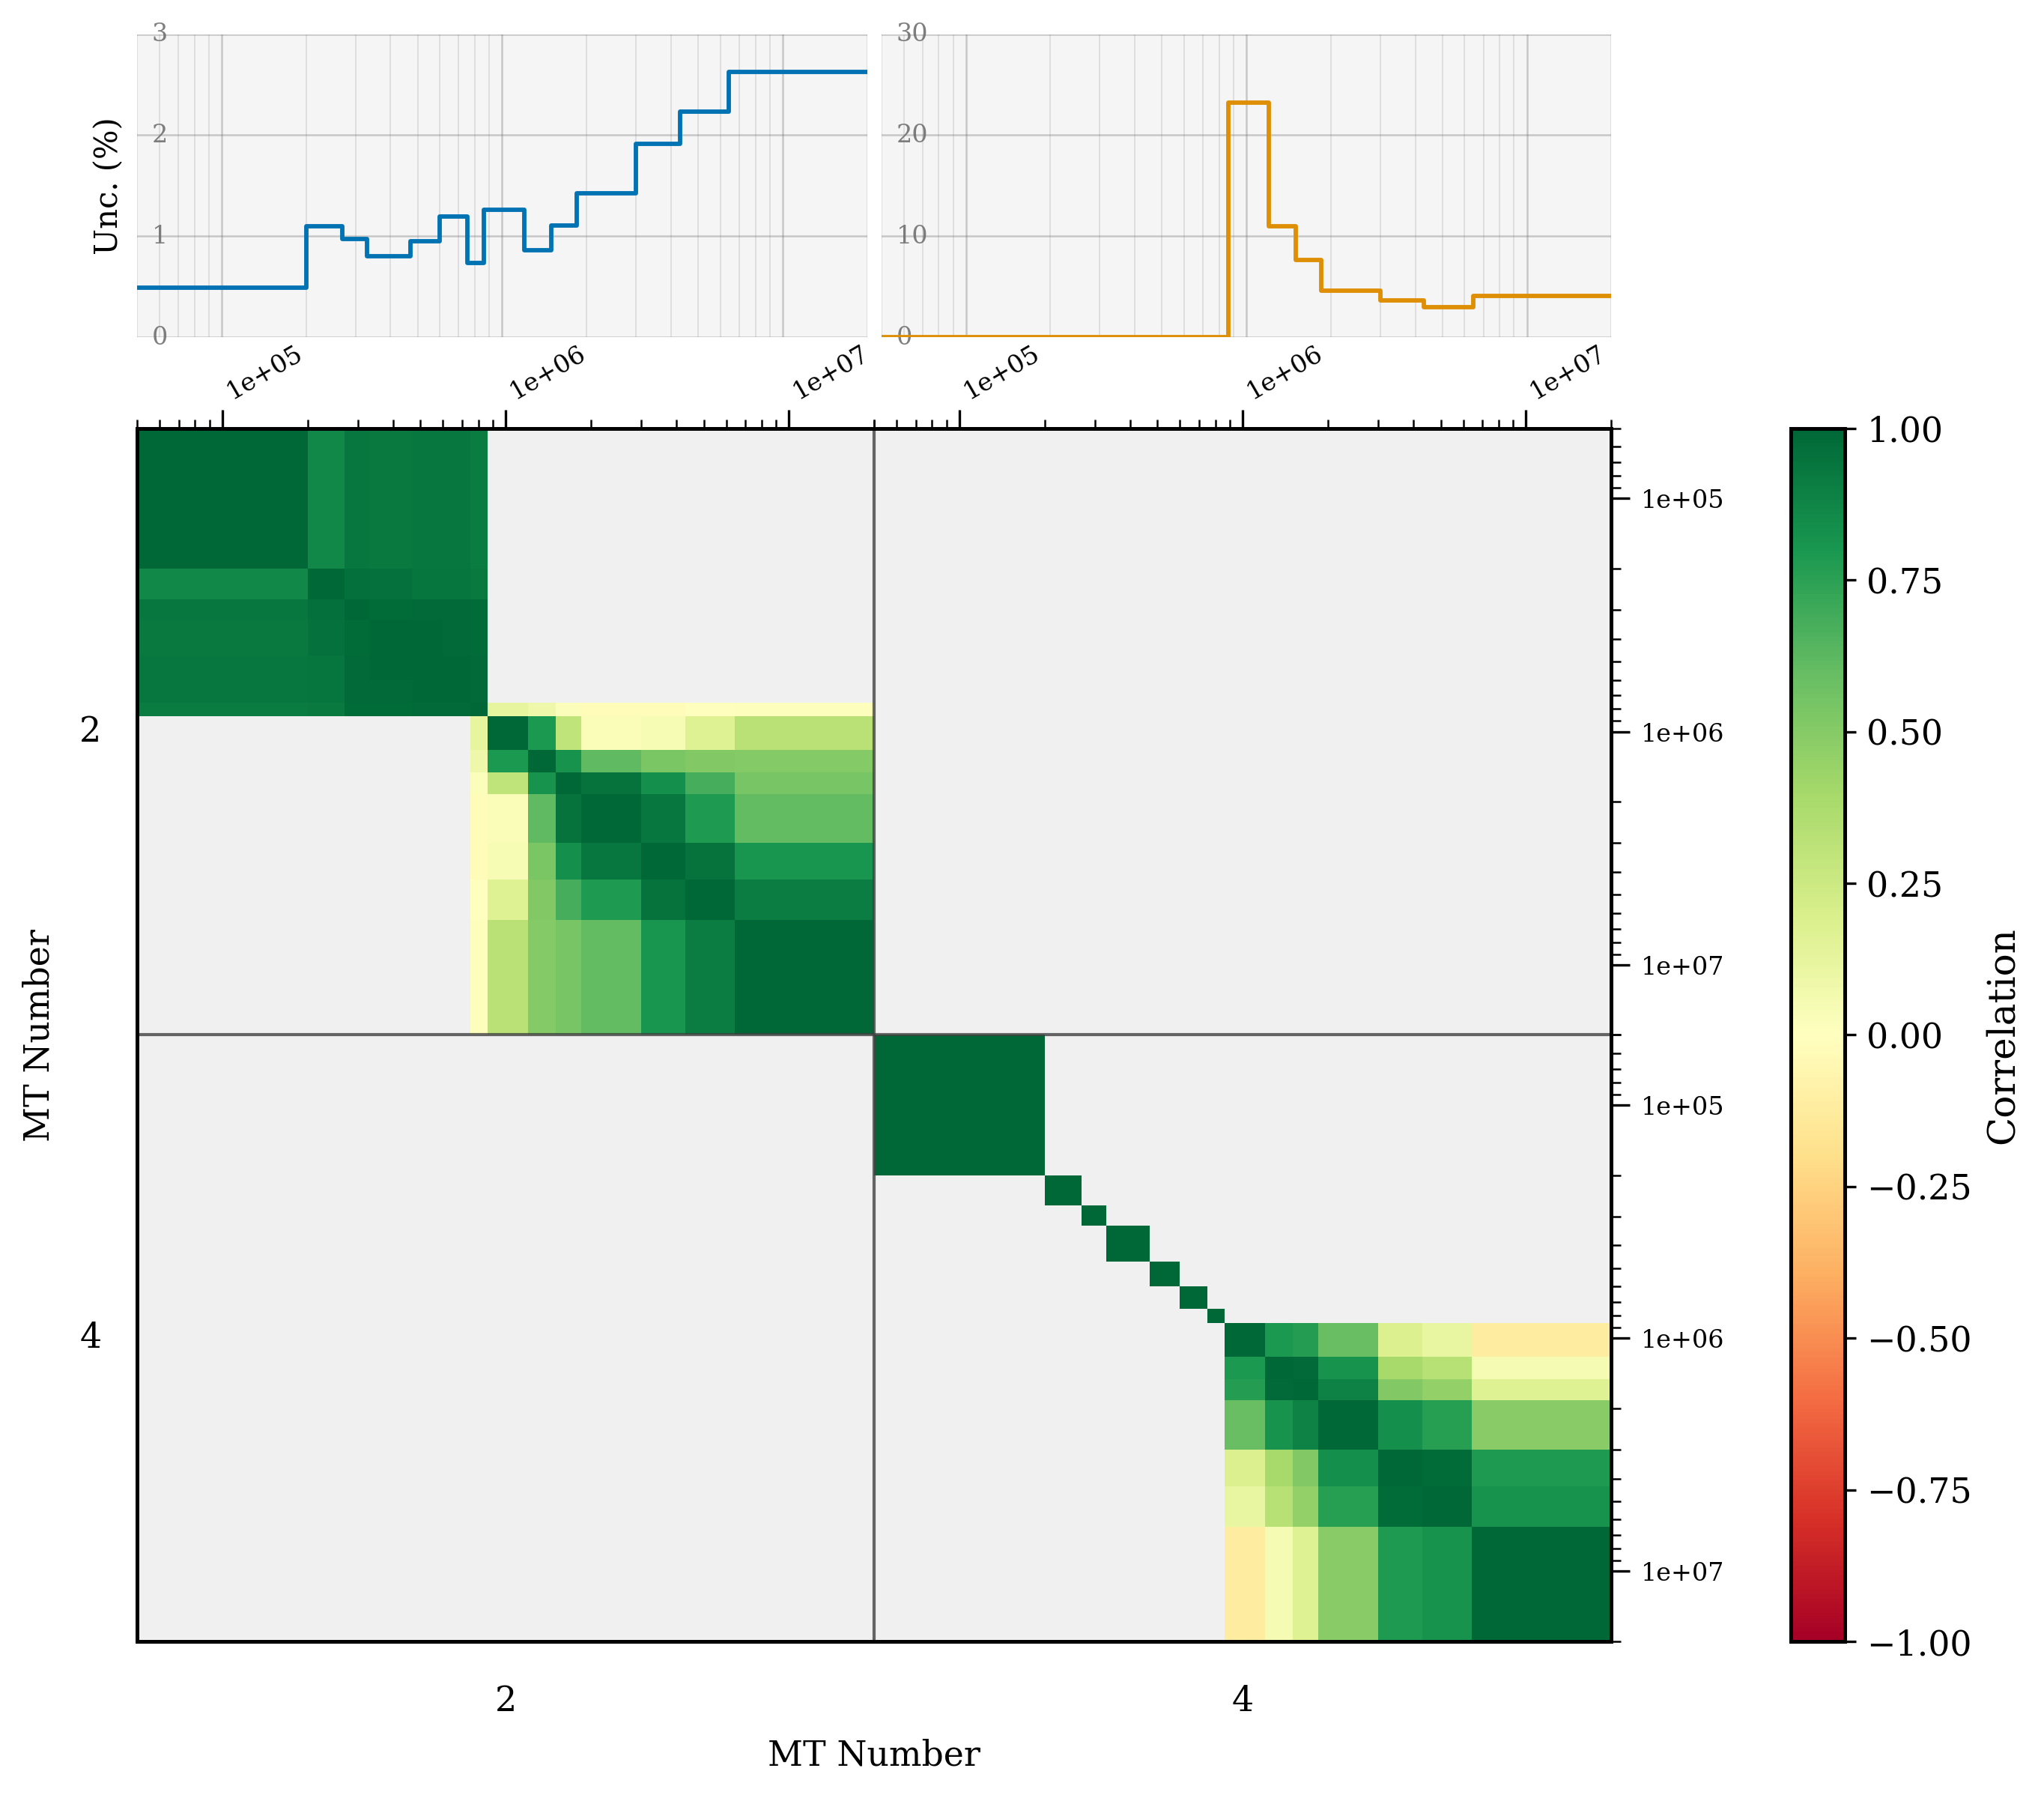

In [9]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[1:3],
    matrix_type="corr",
    scale="log",
    show_uncertainties=True,
    show_energy_ticks=True,
    show_block_labels=True,
    show_colorbar=True,
    title="",
    energy_range=(1e5, 20e6)
)
print(f"✓ Test 1.1 passed: Single MT={test_mts[0]}, correlation, log scale")

## Test 1.2: Single MT Diagonal Block - Covariance

✓ Test 1.2 passed: Single MT=1, covariance matrix


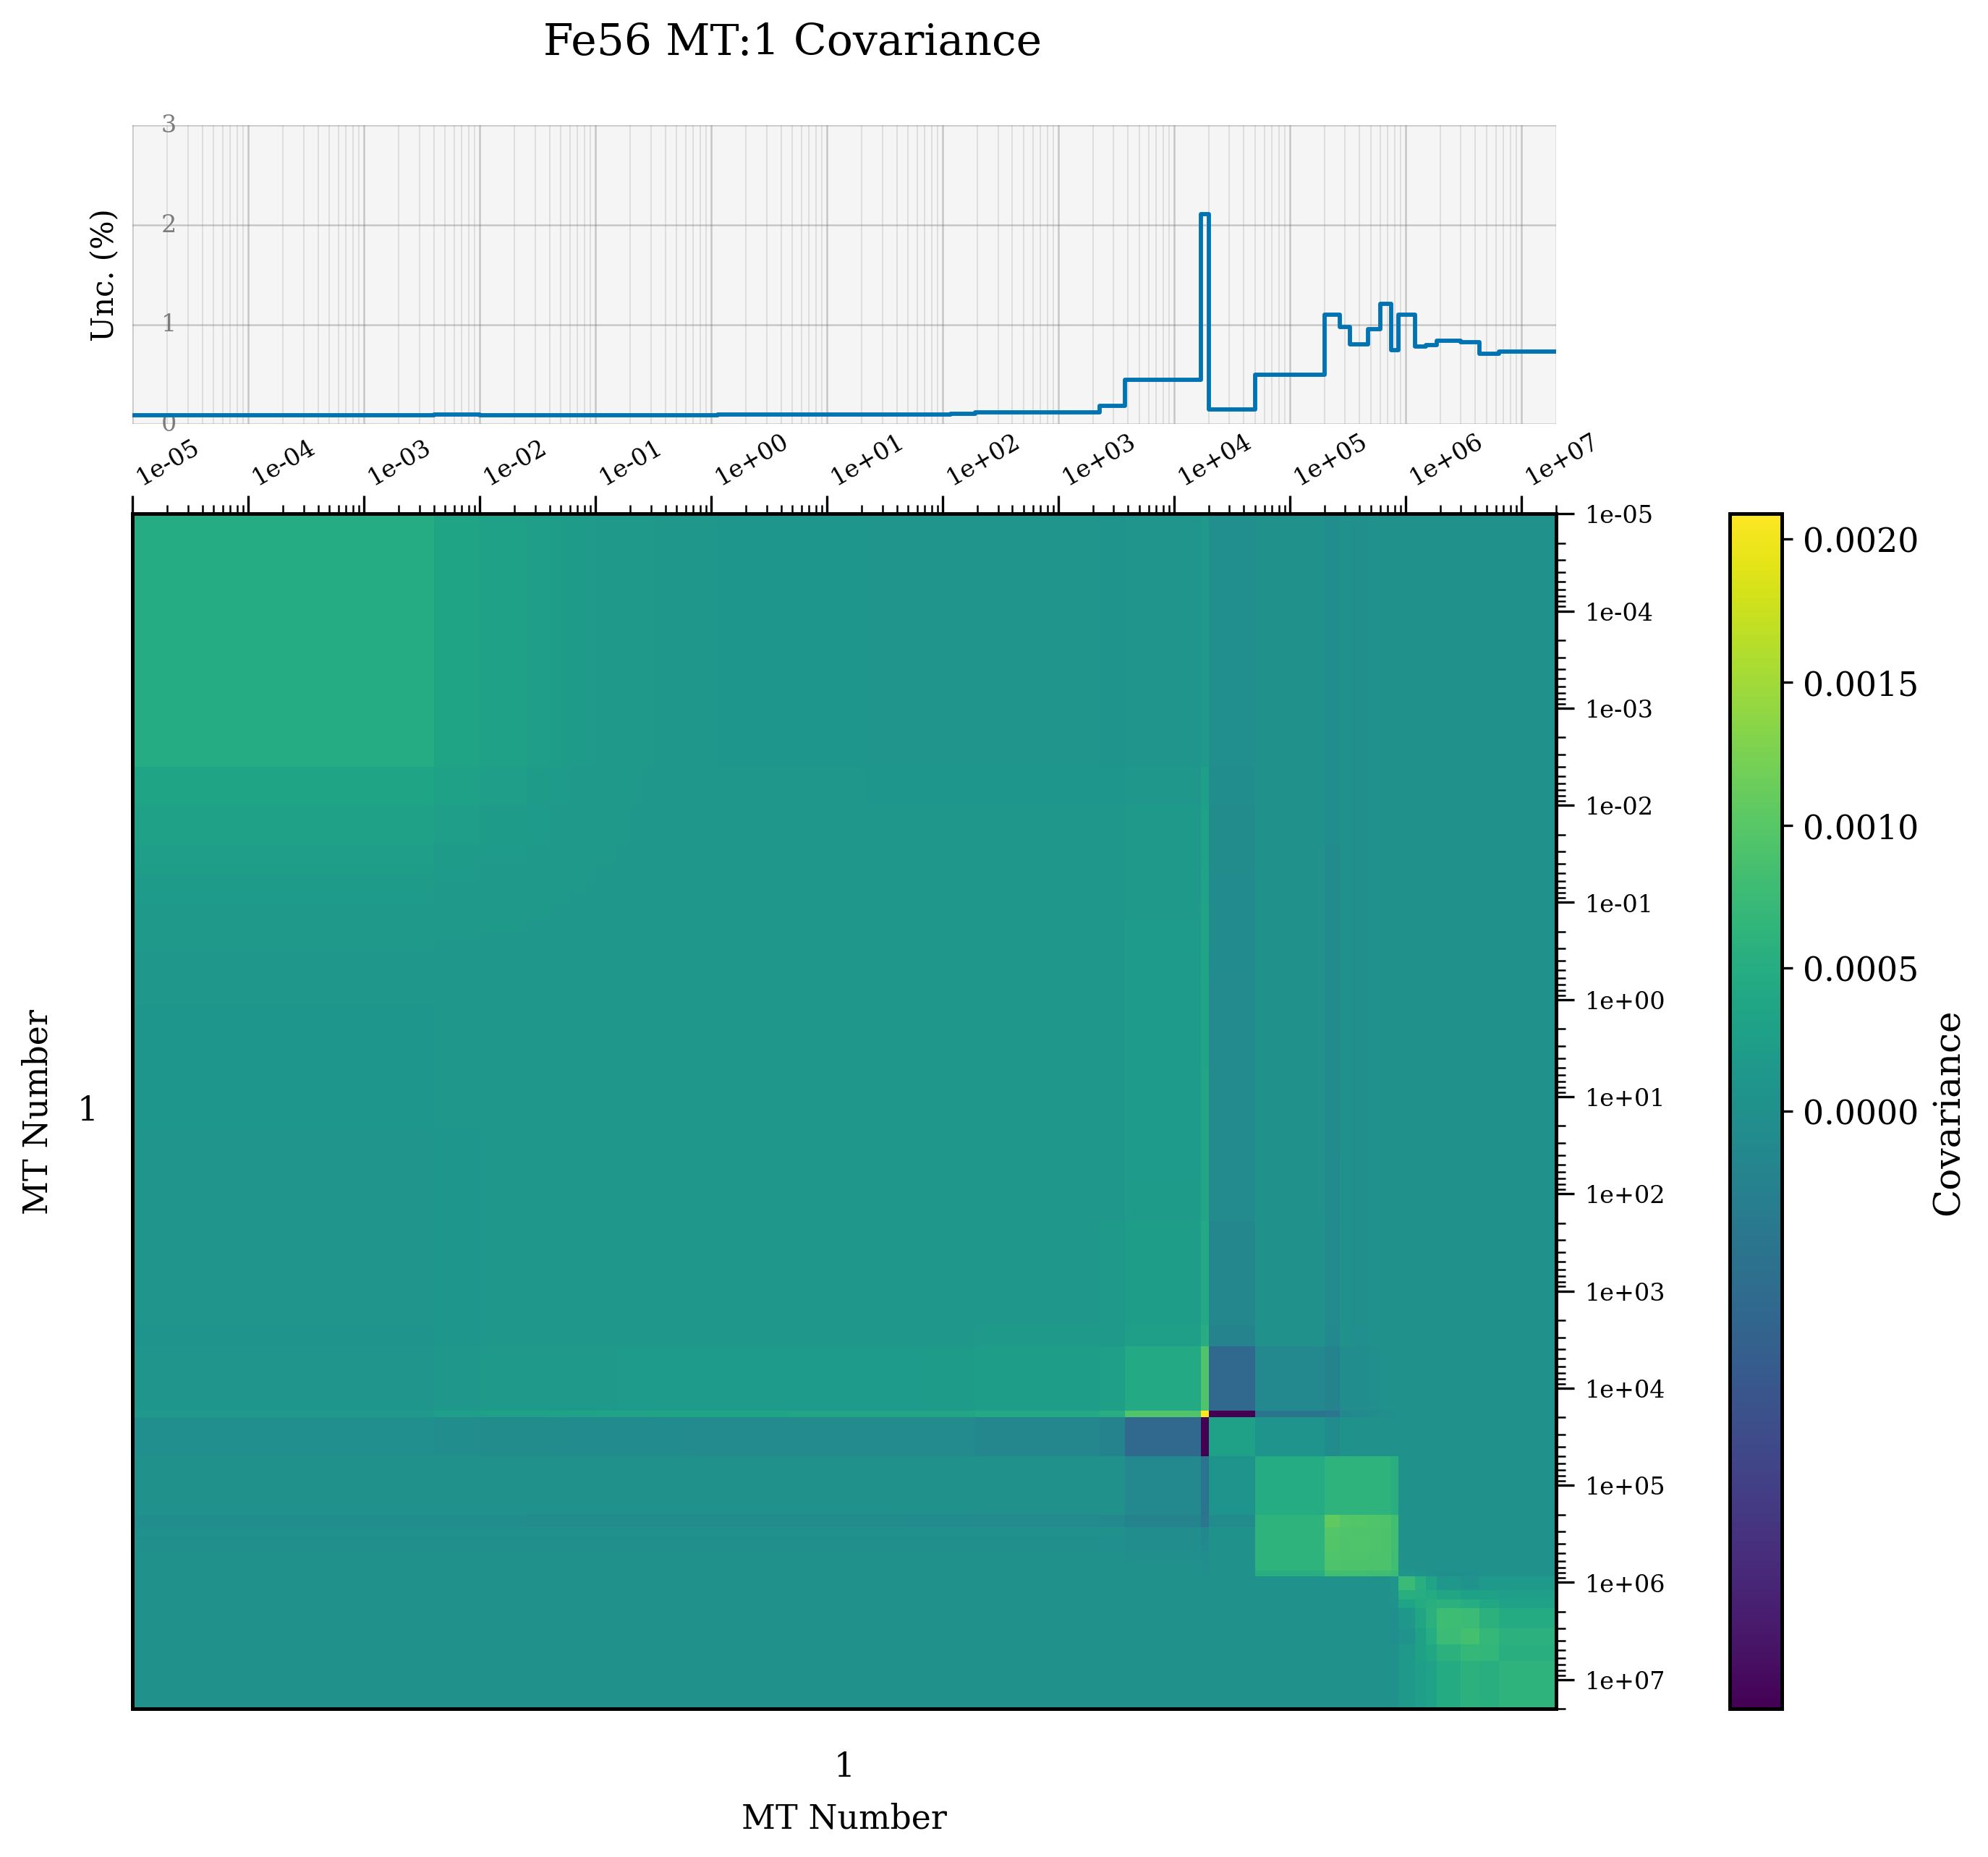

In [5]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    matrix_type="cov",  # Covariance instead of correlation
    scale="log",
    show_uncertainties=True,
)
print(f"✓ Test 1.2 passed: Single MT={test_mts[0]}, covariance matrix")

## Test 1.3: Single MT - Linear Scale

✓ Test 1.3 passed: Single MT=1, linear scale


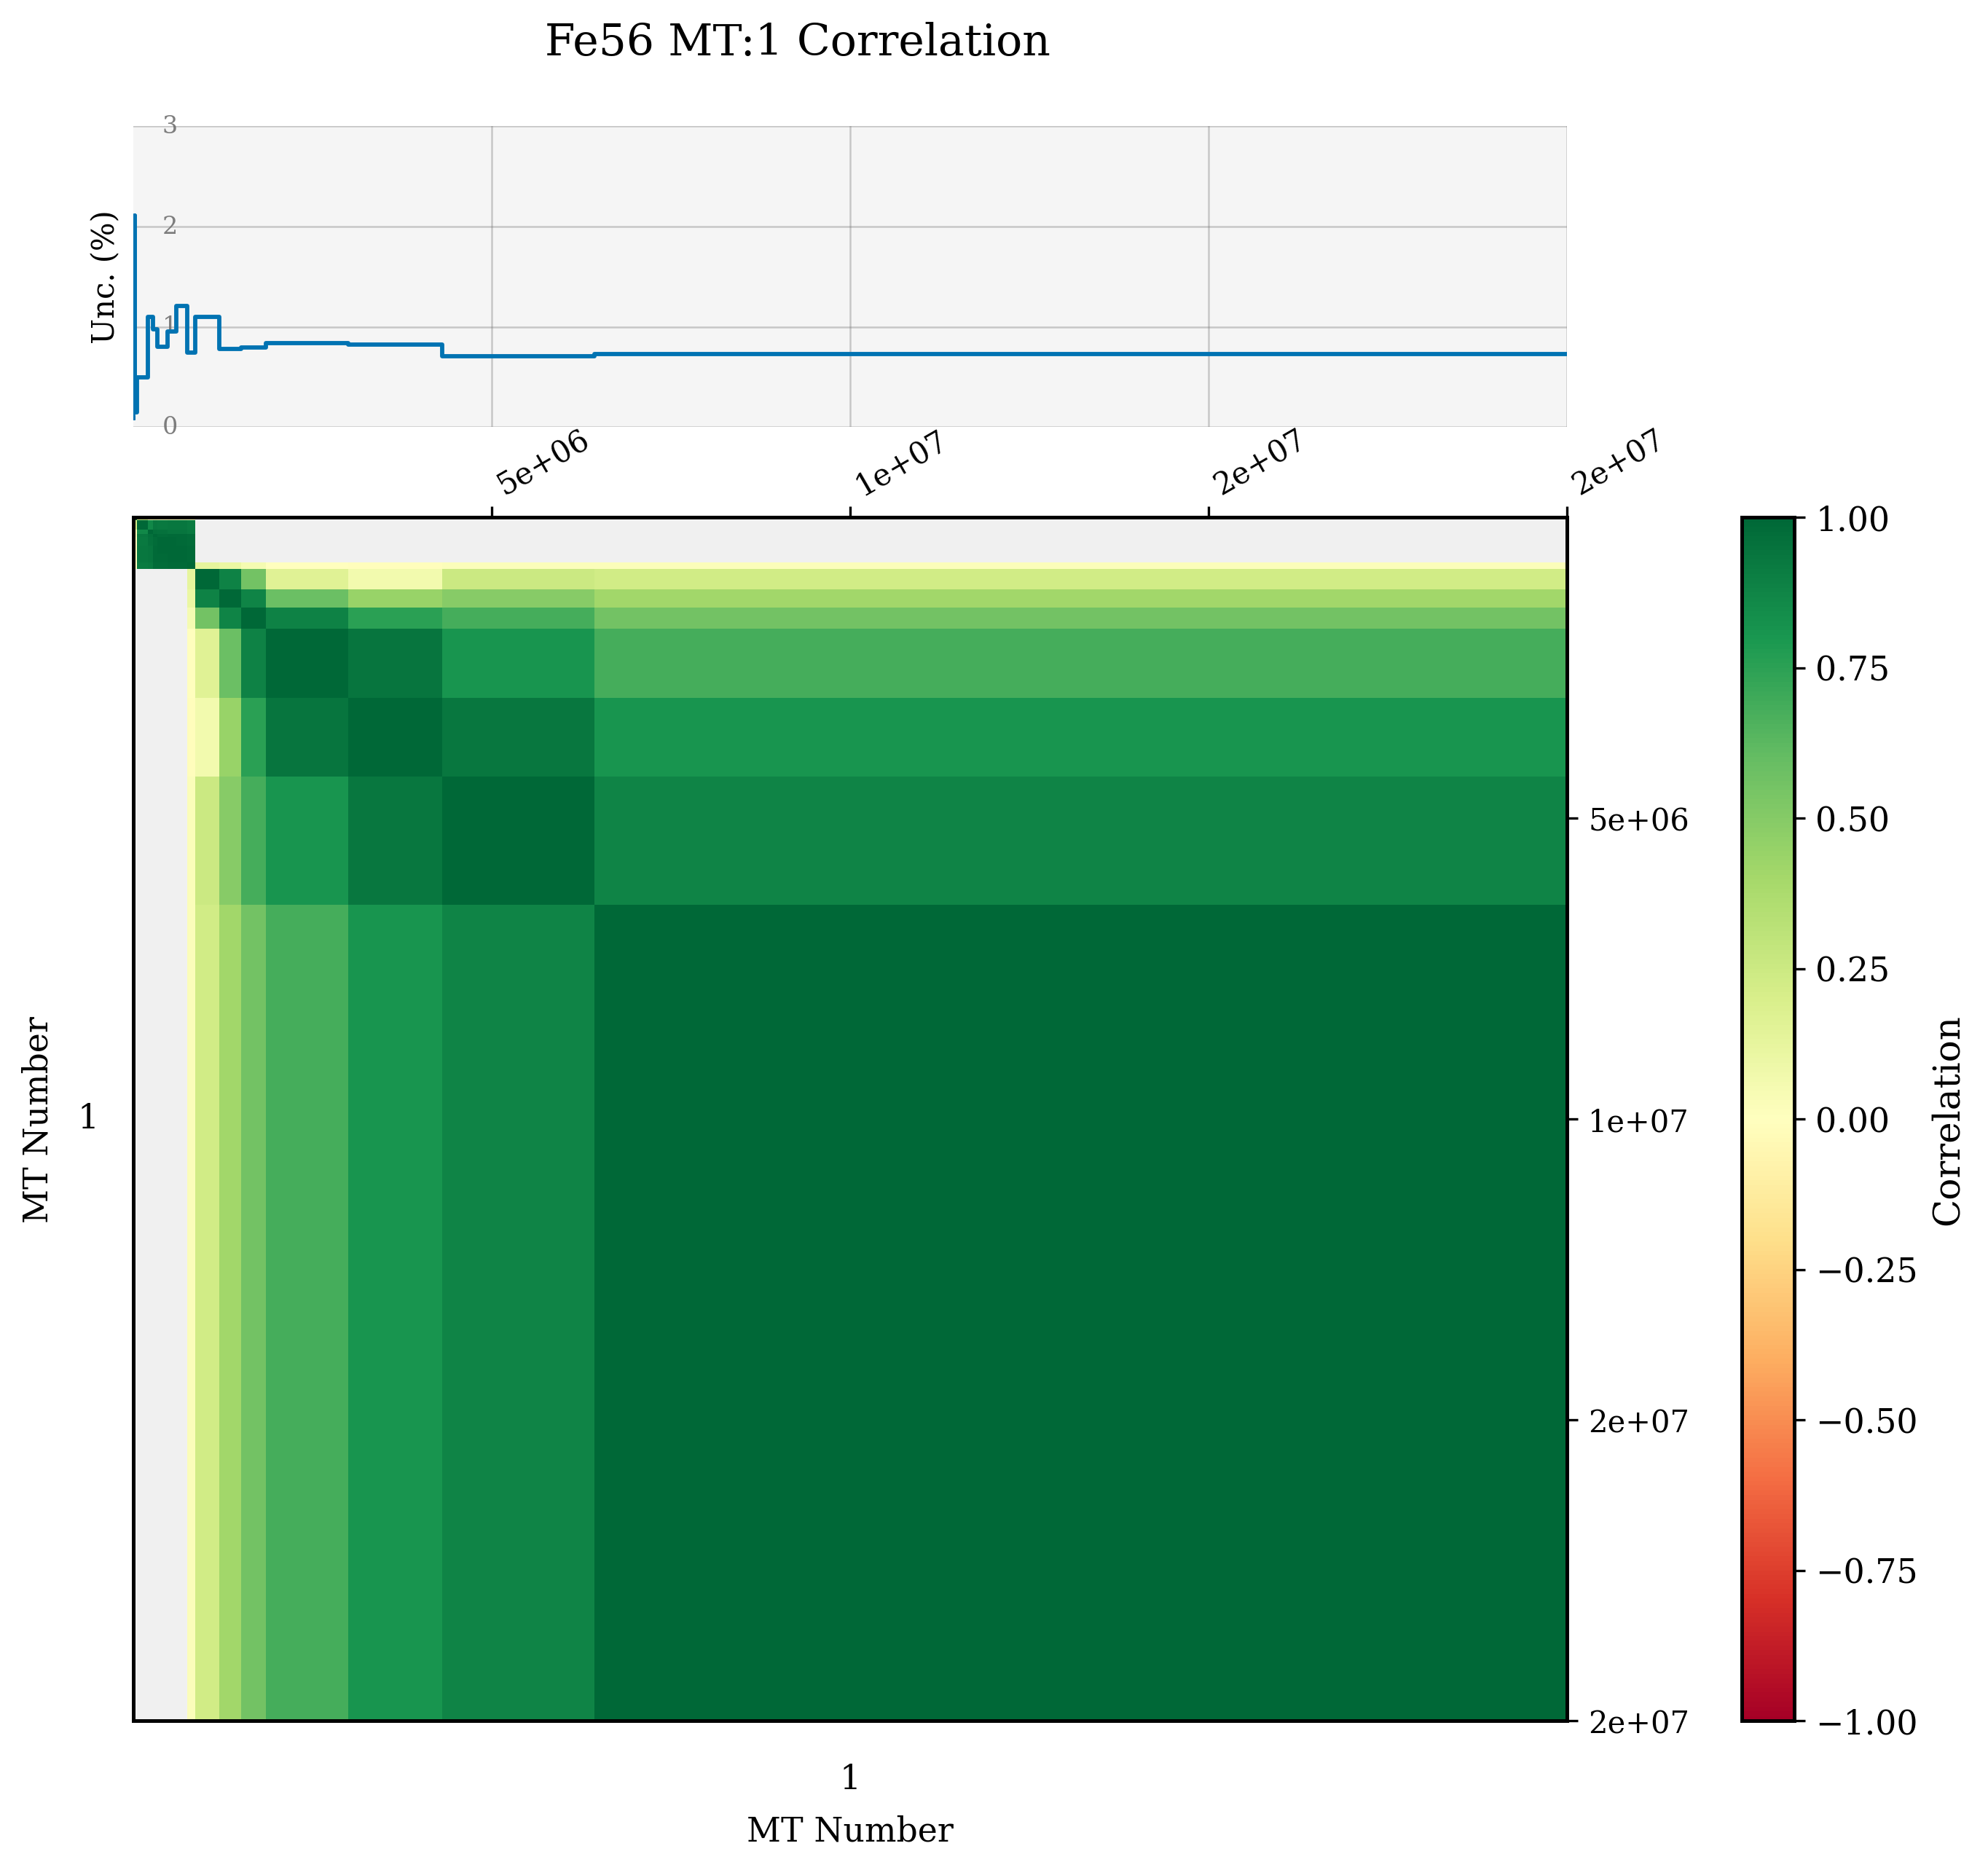

In [6]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    matrix_type="corr",
    scale="linear",  # Linear scale instead of log
    show_uncertainties=True,
)
print(f"✓ Test 1.3 passed: Single MT={test_mts[0]}, linear scale")

## Test 1.4: Single MT - Without Uncertainties

✓ Test 1.4 passed: Single MT without uncertainties


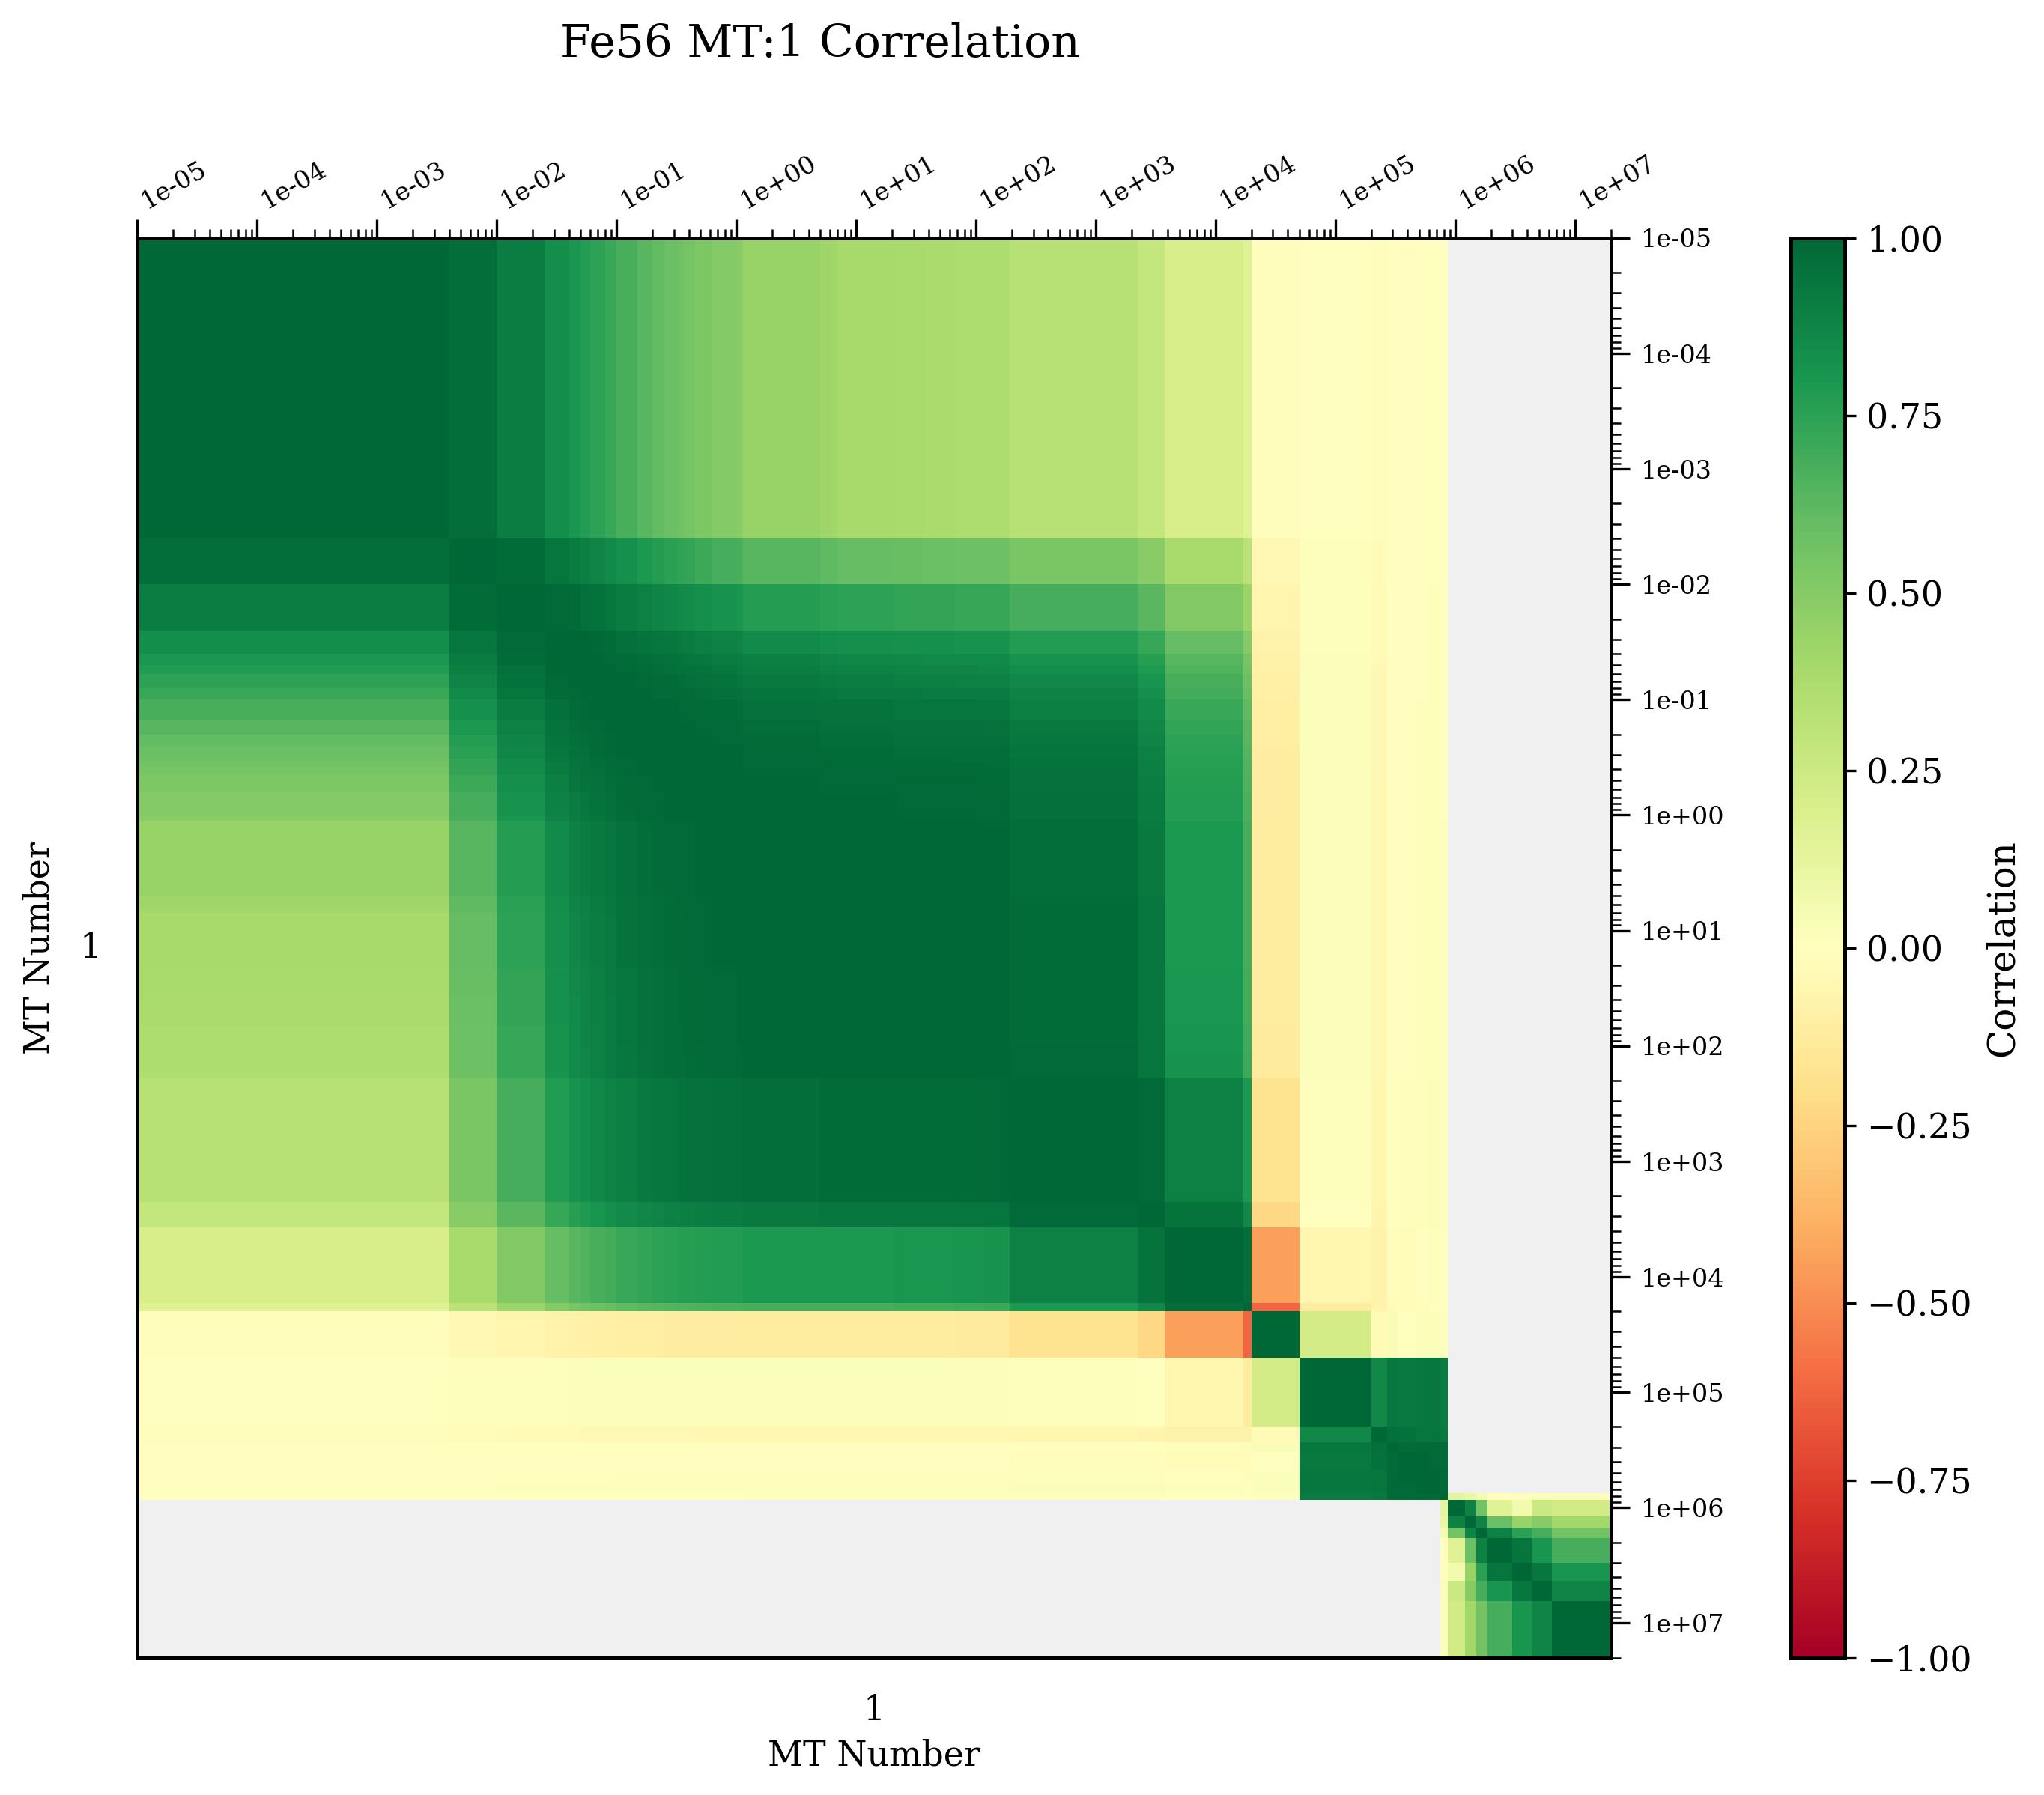

In [7]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    show_uncertainties=False,  # Hide uncertainty panel
)
print(f"✓ Test 1.4 passed: Single MT without uncertainties")

## Test 1.5: Single MT - Without Energy Ticks

✓ Test 1.5 passed: Single MT without energy ticks


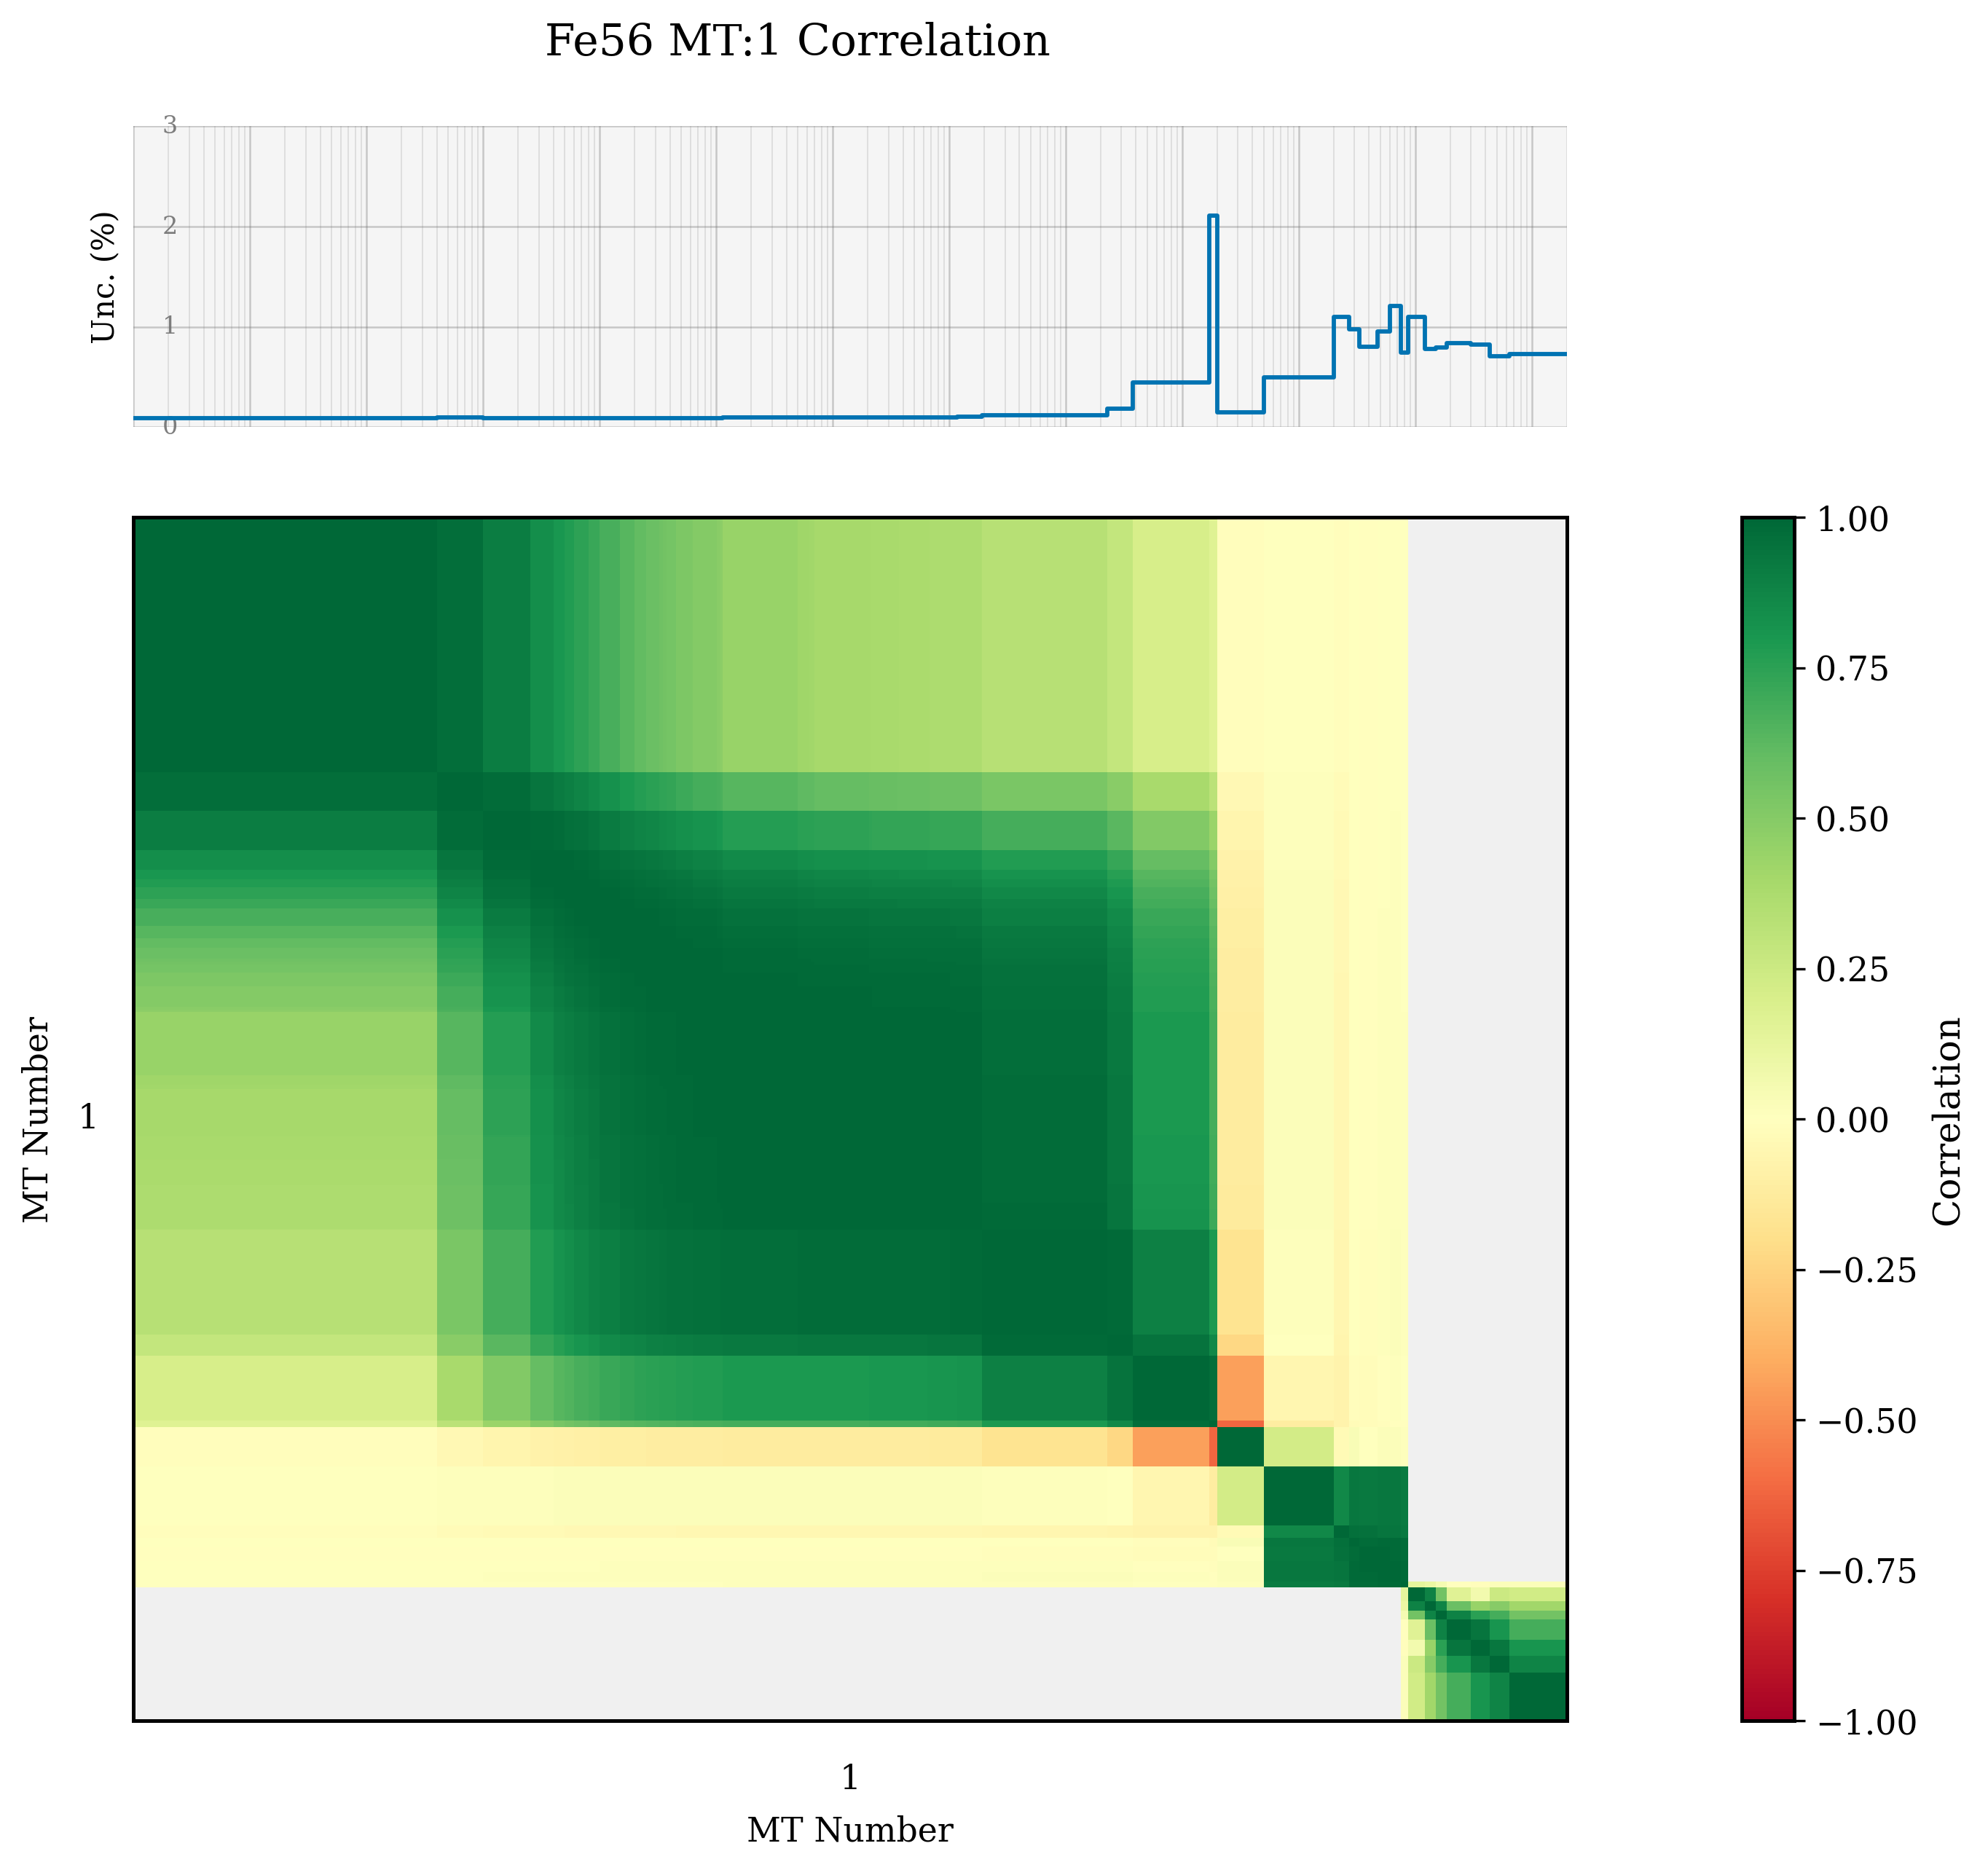

In [8]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    show_energy_ticks=False,  # Hide energy tick marks
)
print(f"✓ Test 1.5 passed: Single MT without energy ticks")

## Test 1.6: Single MT - Without Colorbar

✓ Test 1.6 passed: Single MT without colorbar


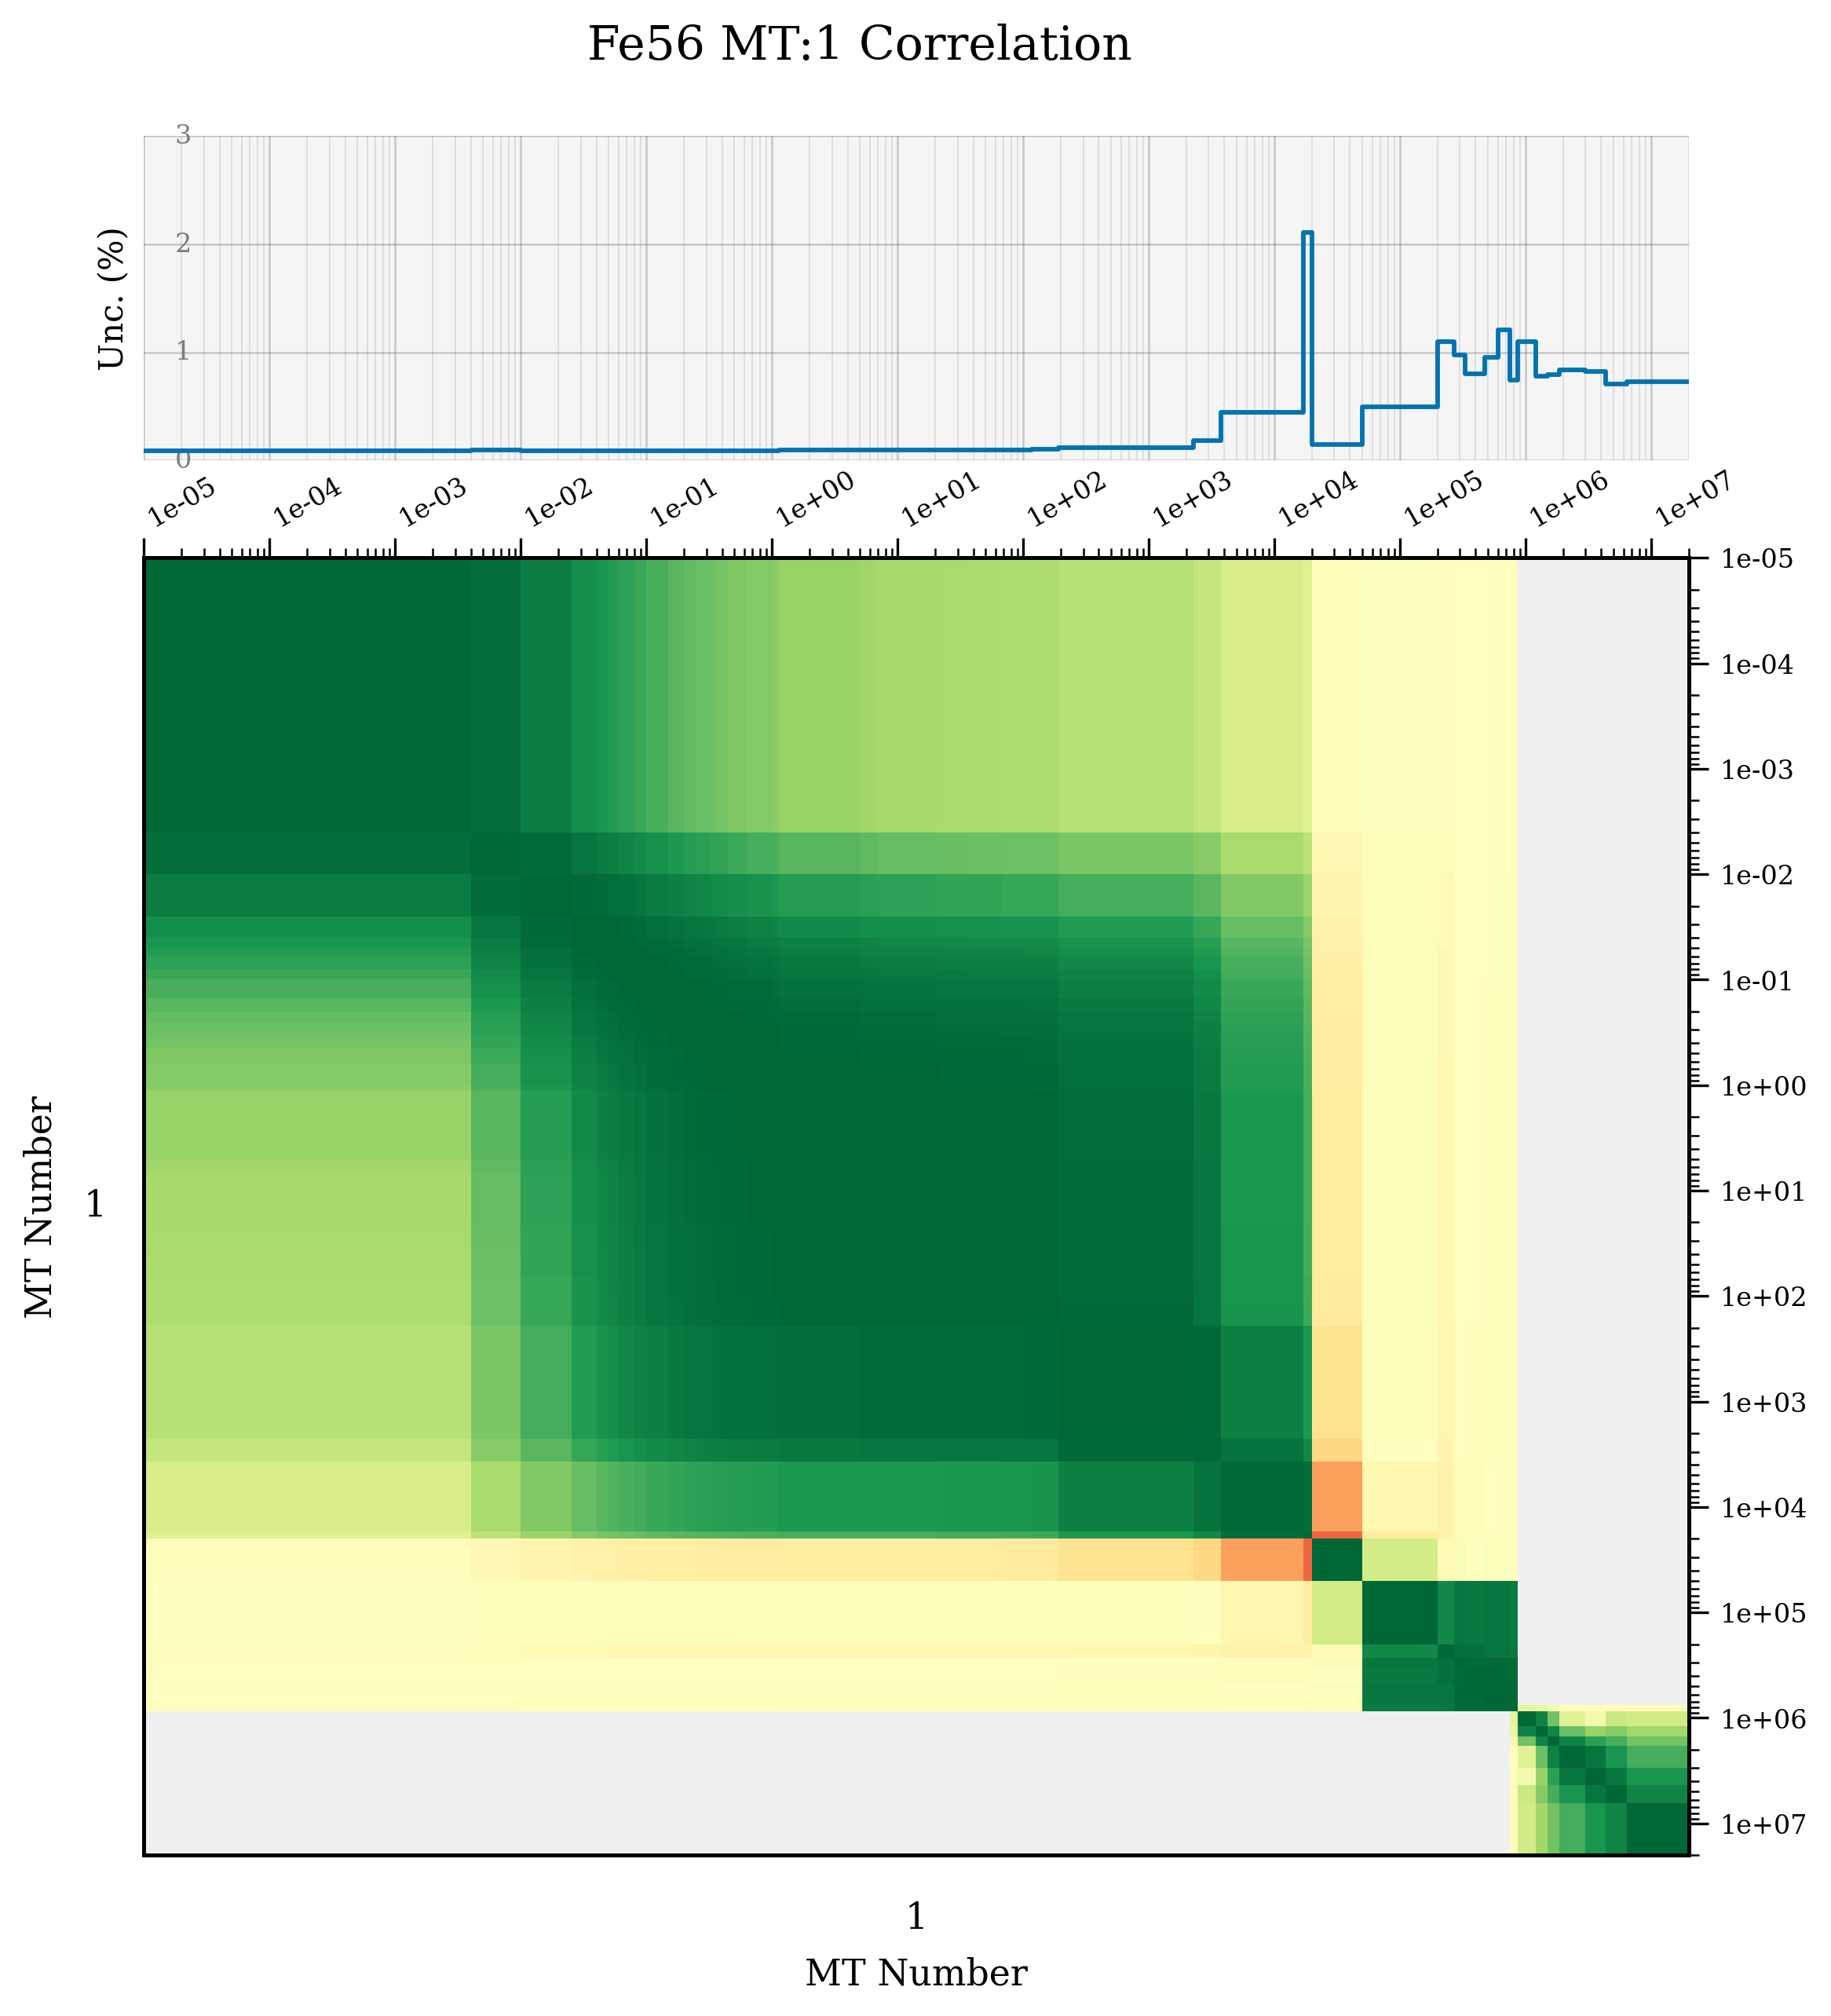

In [9]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    show_colorbar=False,  # Hide colorbar
)
print(f"✓ Test 1.6 passed: Single MT without colorbar")

## Test 1.7: Single MT - Energy Range Filtering

✓ Test 1.7 passed: Single MT with energy range filtering (1 keV - 10 MeV)


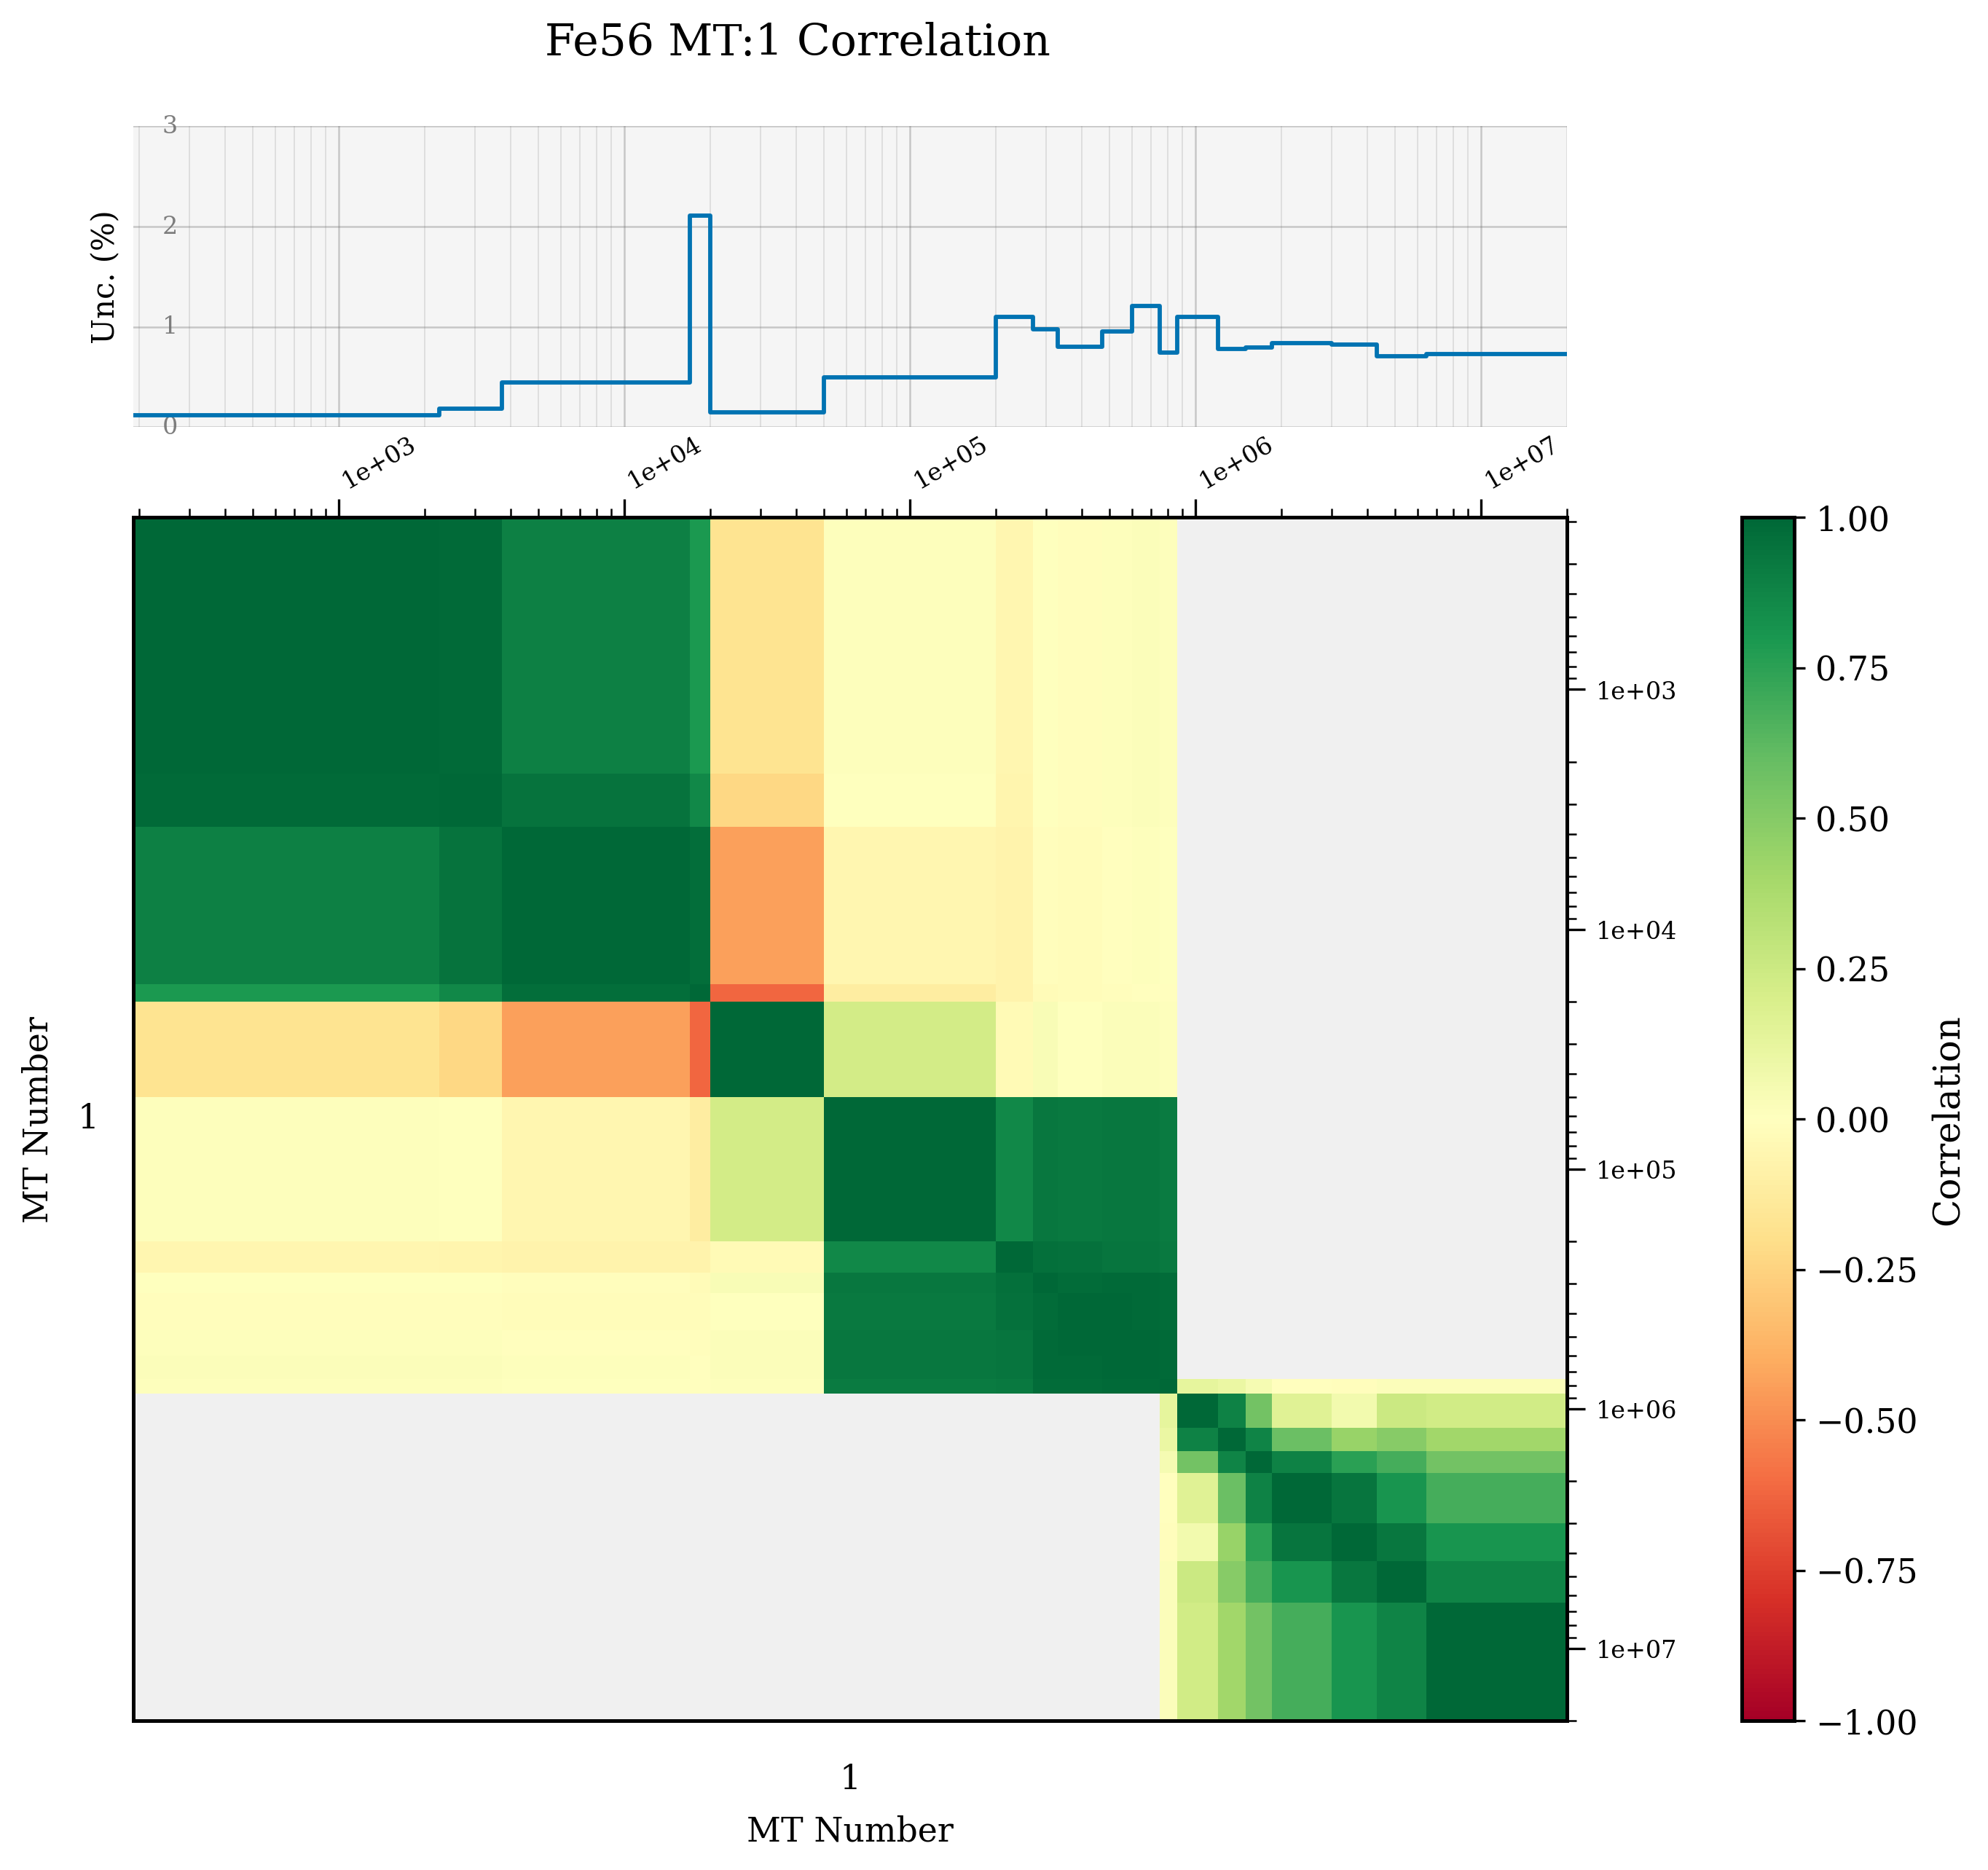

In [10]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    energy_range=(1e3, 1e7),  # Filter to 1 keV - 10 MeV (in eV)
    show_uncertainties=True,
)
print(f"✓ Test 1.7 passed: Single MT with energy range filtering (1 keV - 10 MeV)")

## Test 1.8: Single MT - Custom Title

✓ Test 1.8 passed: Single MT with custom title


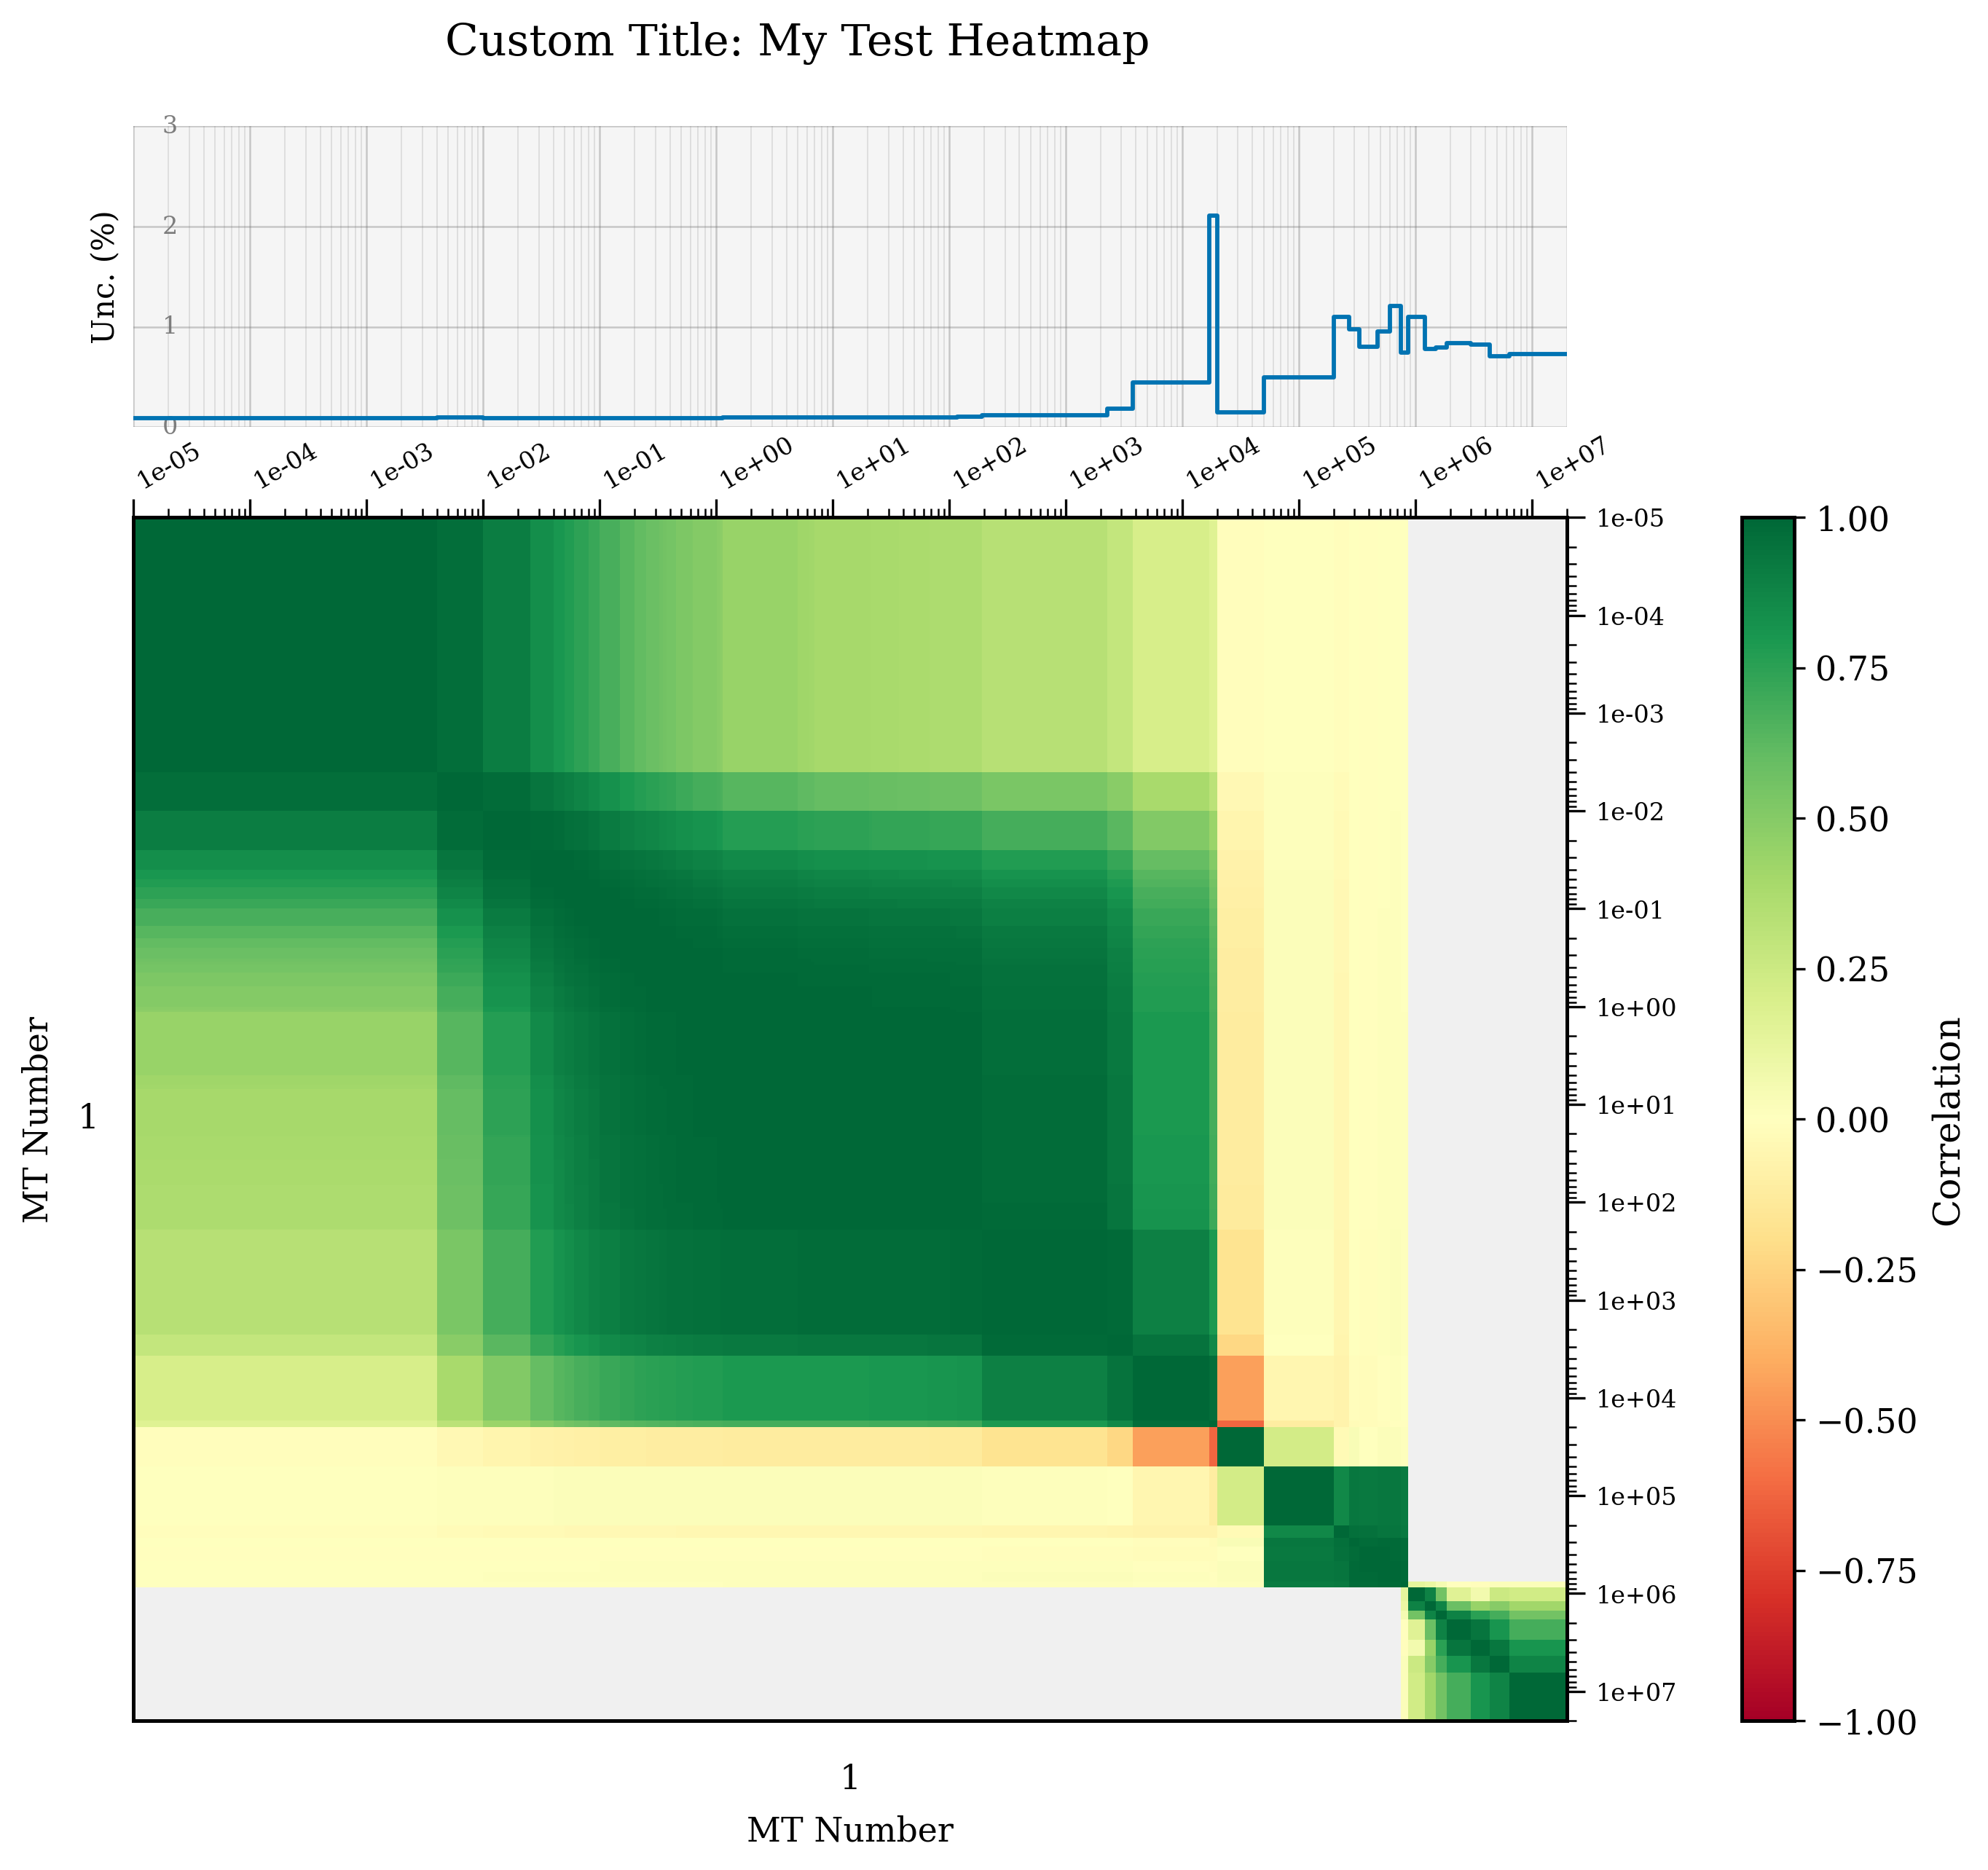

In [11]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title="Custom Title: My Test Heatmap",  # Custom title
)
print(f"✓ Test 1.8 passed: Single MT with custom title")

## Test 1.9: Single MT - No Title

✓ Test 1.9 passed: Single MT without title


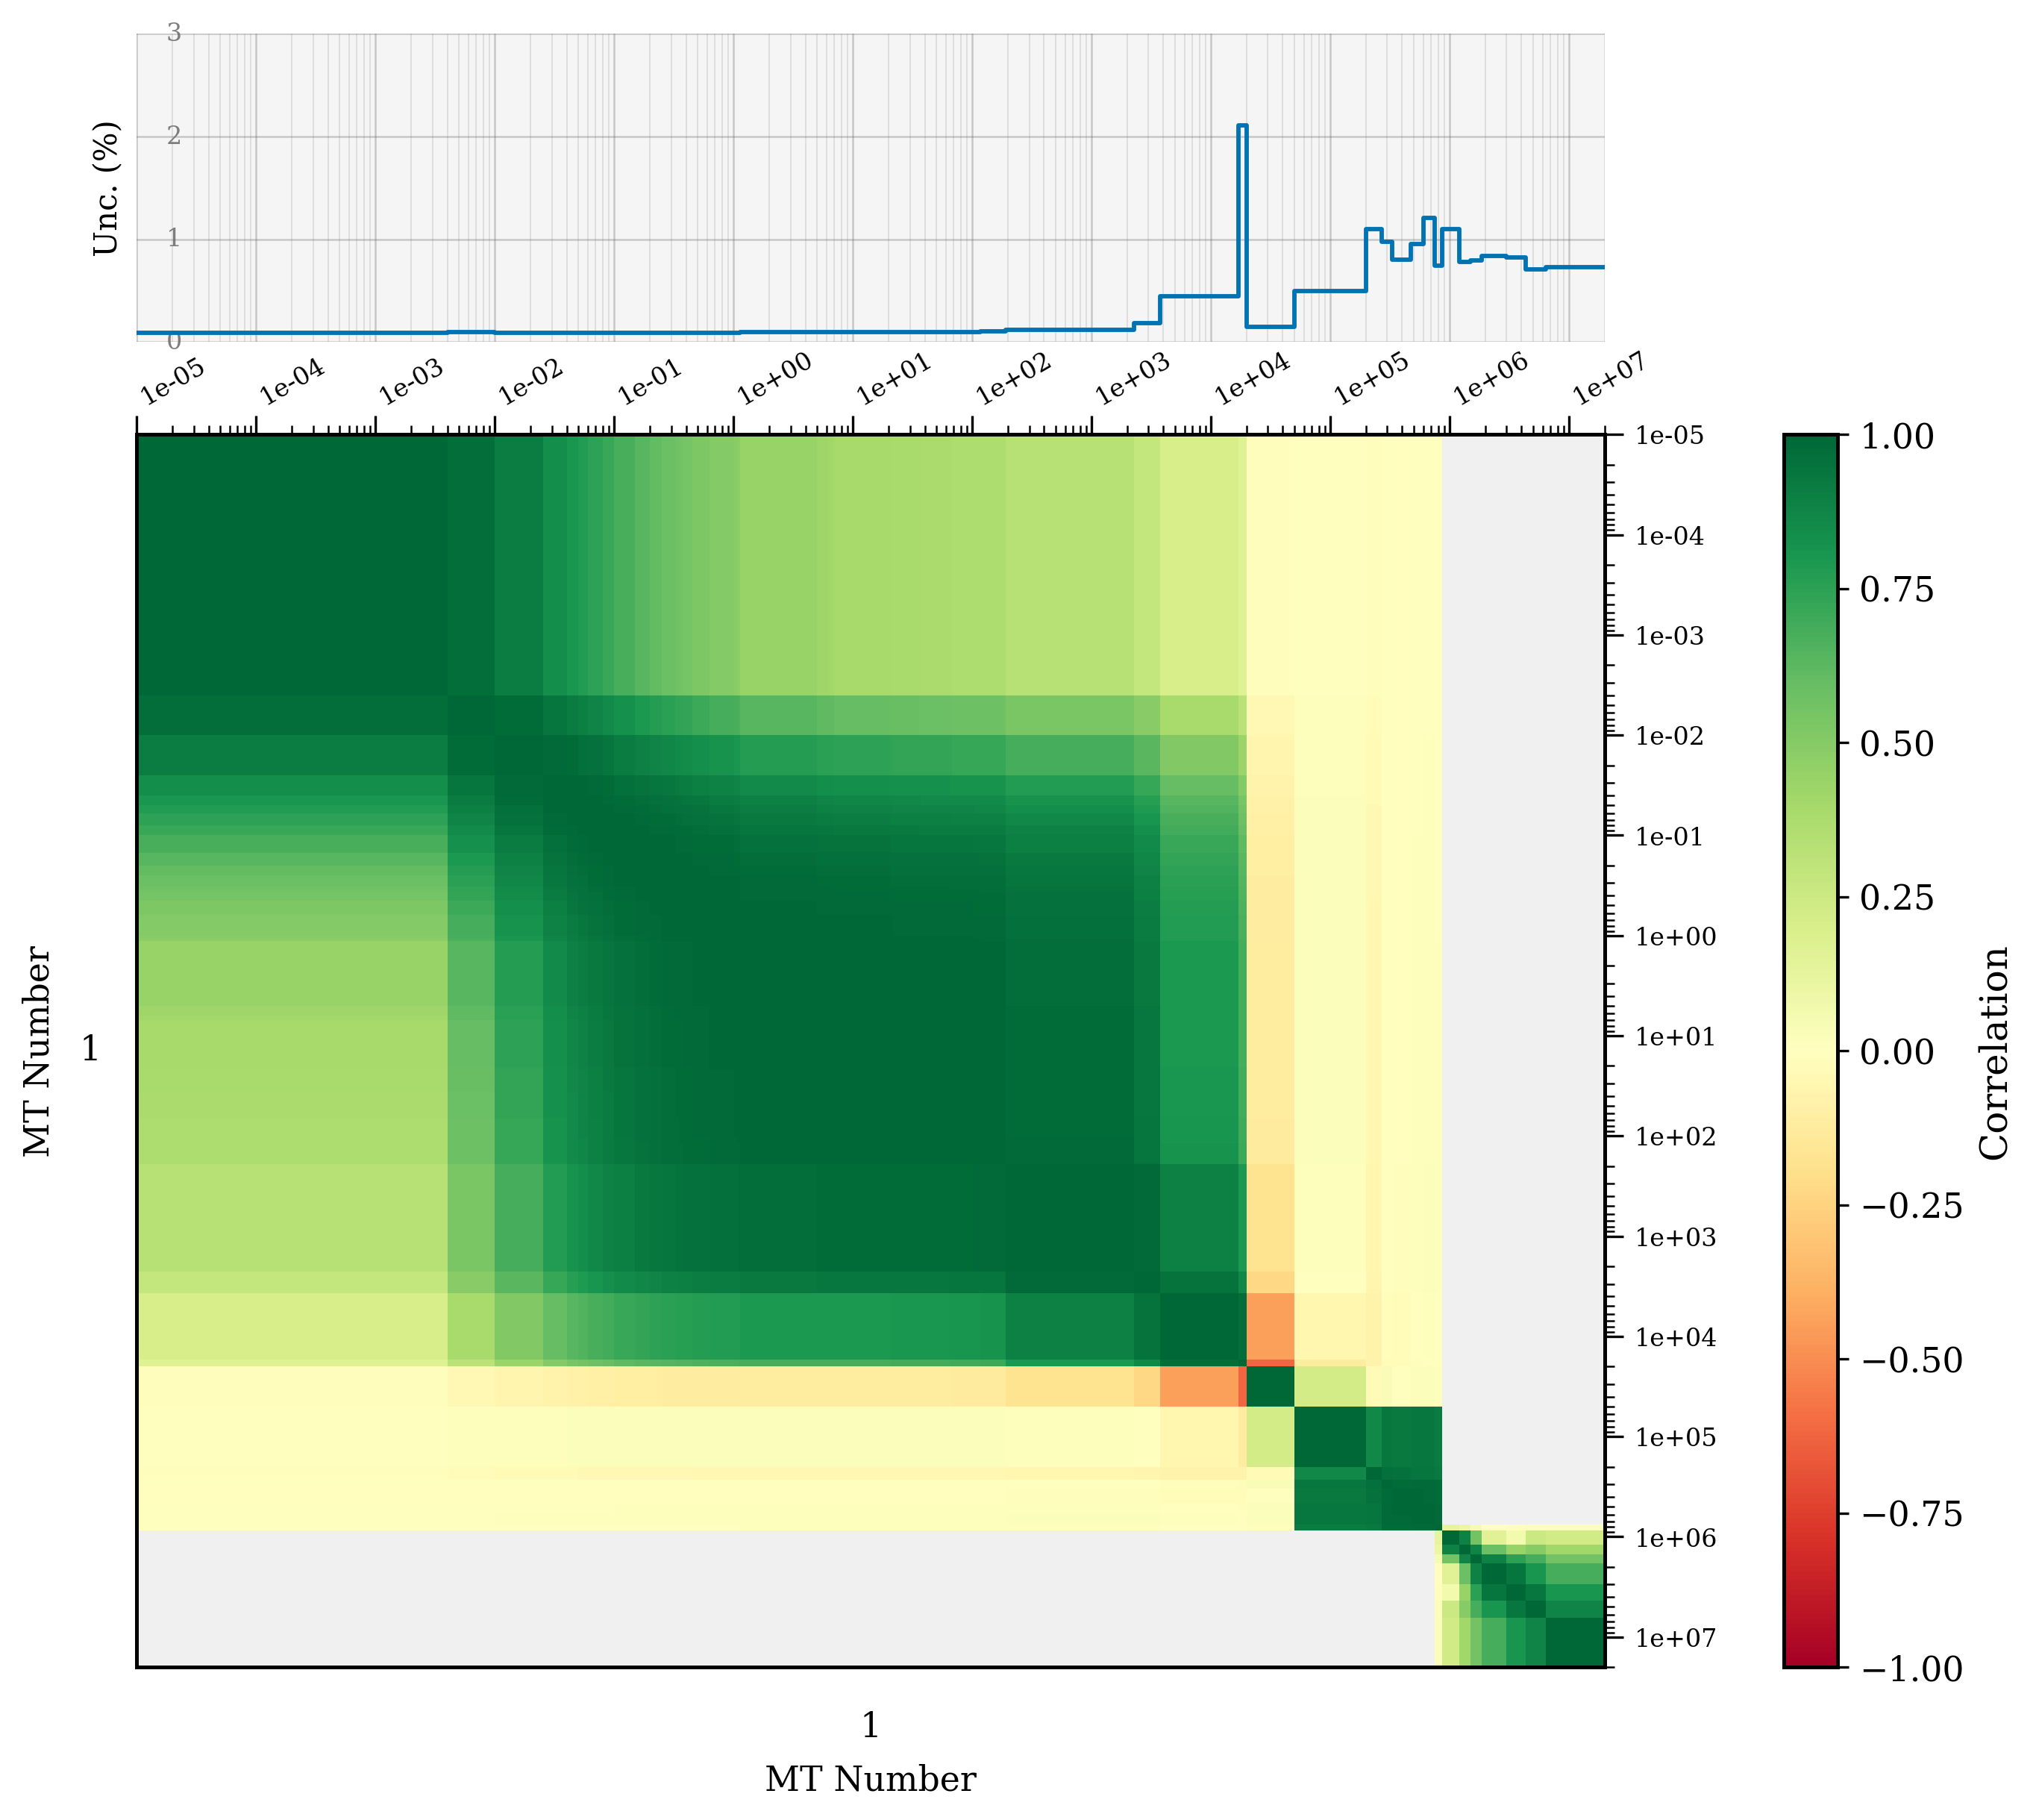

In [12]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title=None,  # Hide title
)
print(f"✓ Test 1.9 passed: Single MT without title")

## Test 1.10: Single MT - Custom Font Sizes

✓ Test 1.10 passed: Single MT with custom font sizes


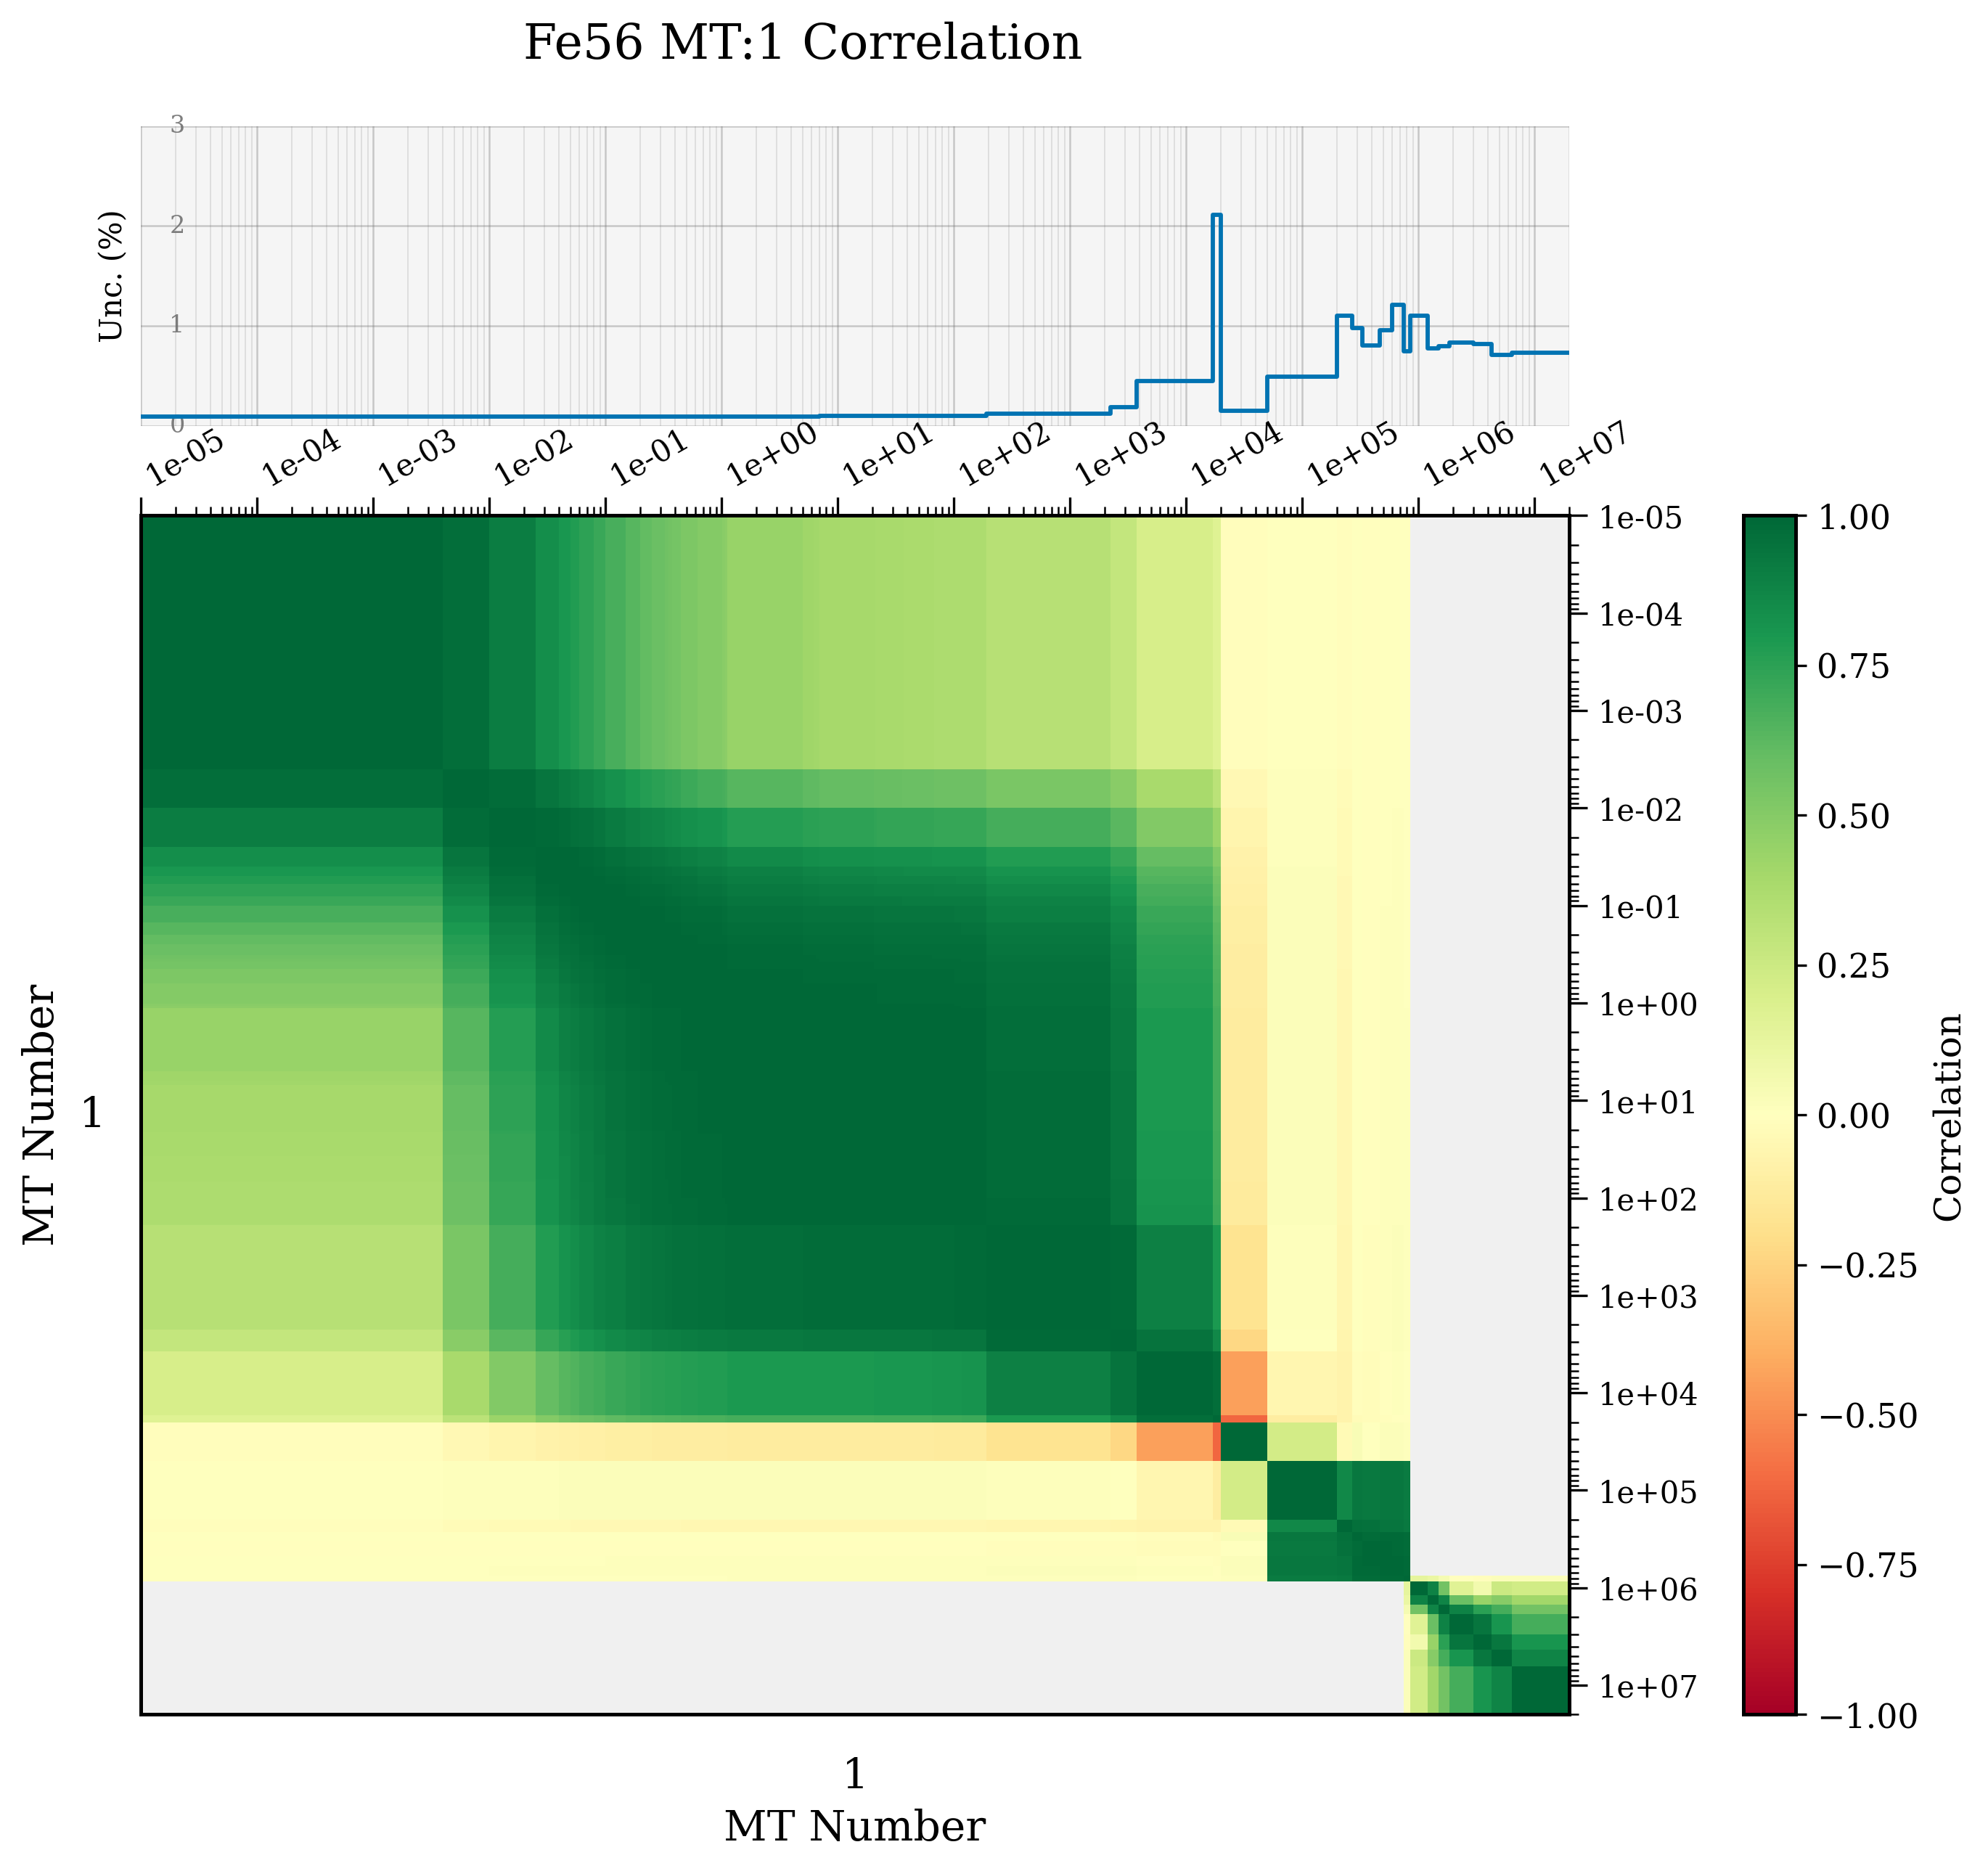

In [13]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title_fontsize=16,
    tick_fontsize=12,
    energy_tick_fontsize=10,
    block_label_fontsize=14,
    colorbar_fontsize=12,
)
print(f"✓ Test 1.10 passed: Single MT with custom font sizes")

## Test 1.11: Multiple MT Diagonal Blocks

✓ Test 1.11 passed: Multiple MTs [1, 2, 4]


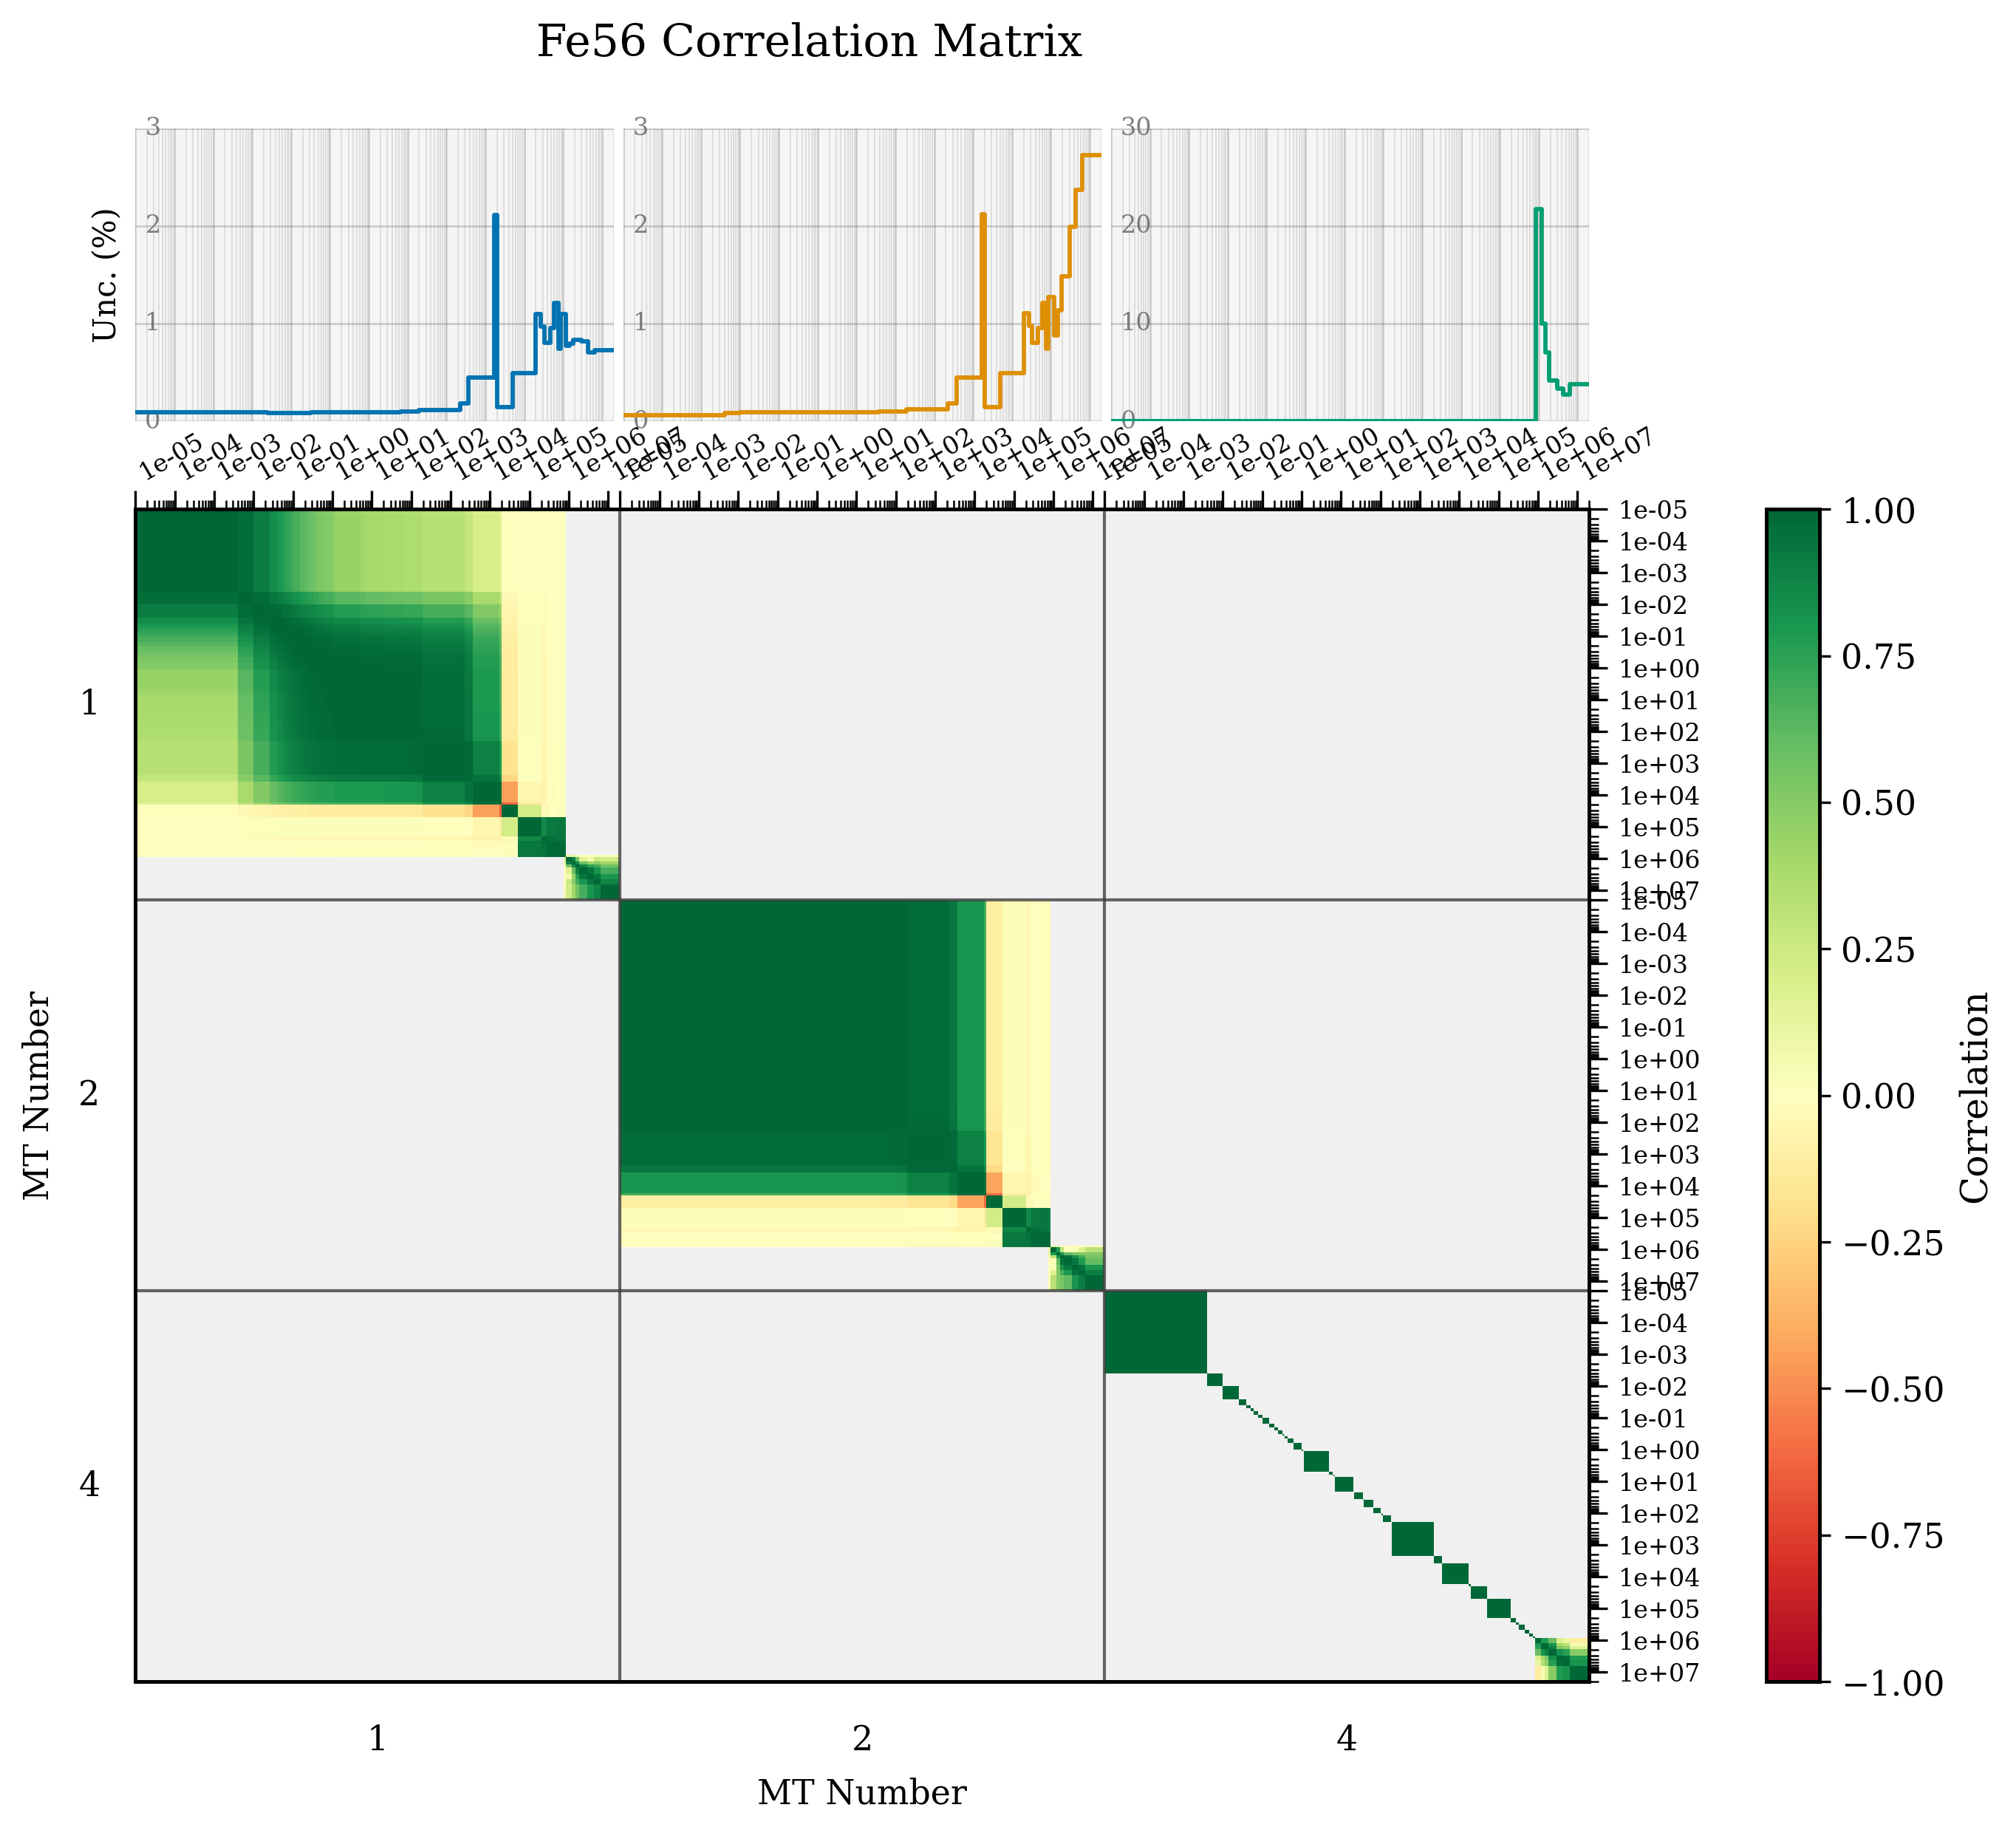

In [14]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],  # First 3 MTs
    show_uncertainties=True,
    show_block_labels=True,
)
print(f"✓ Test 1.11 passed: Multiple MTs {test_mts[:3]}")

## Test 1.12: Multiple MT - Covariance Matrix

✓ Test 1.12 passed: Multiple MTs with covariance matrix


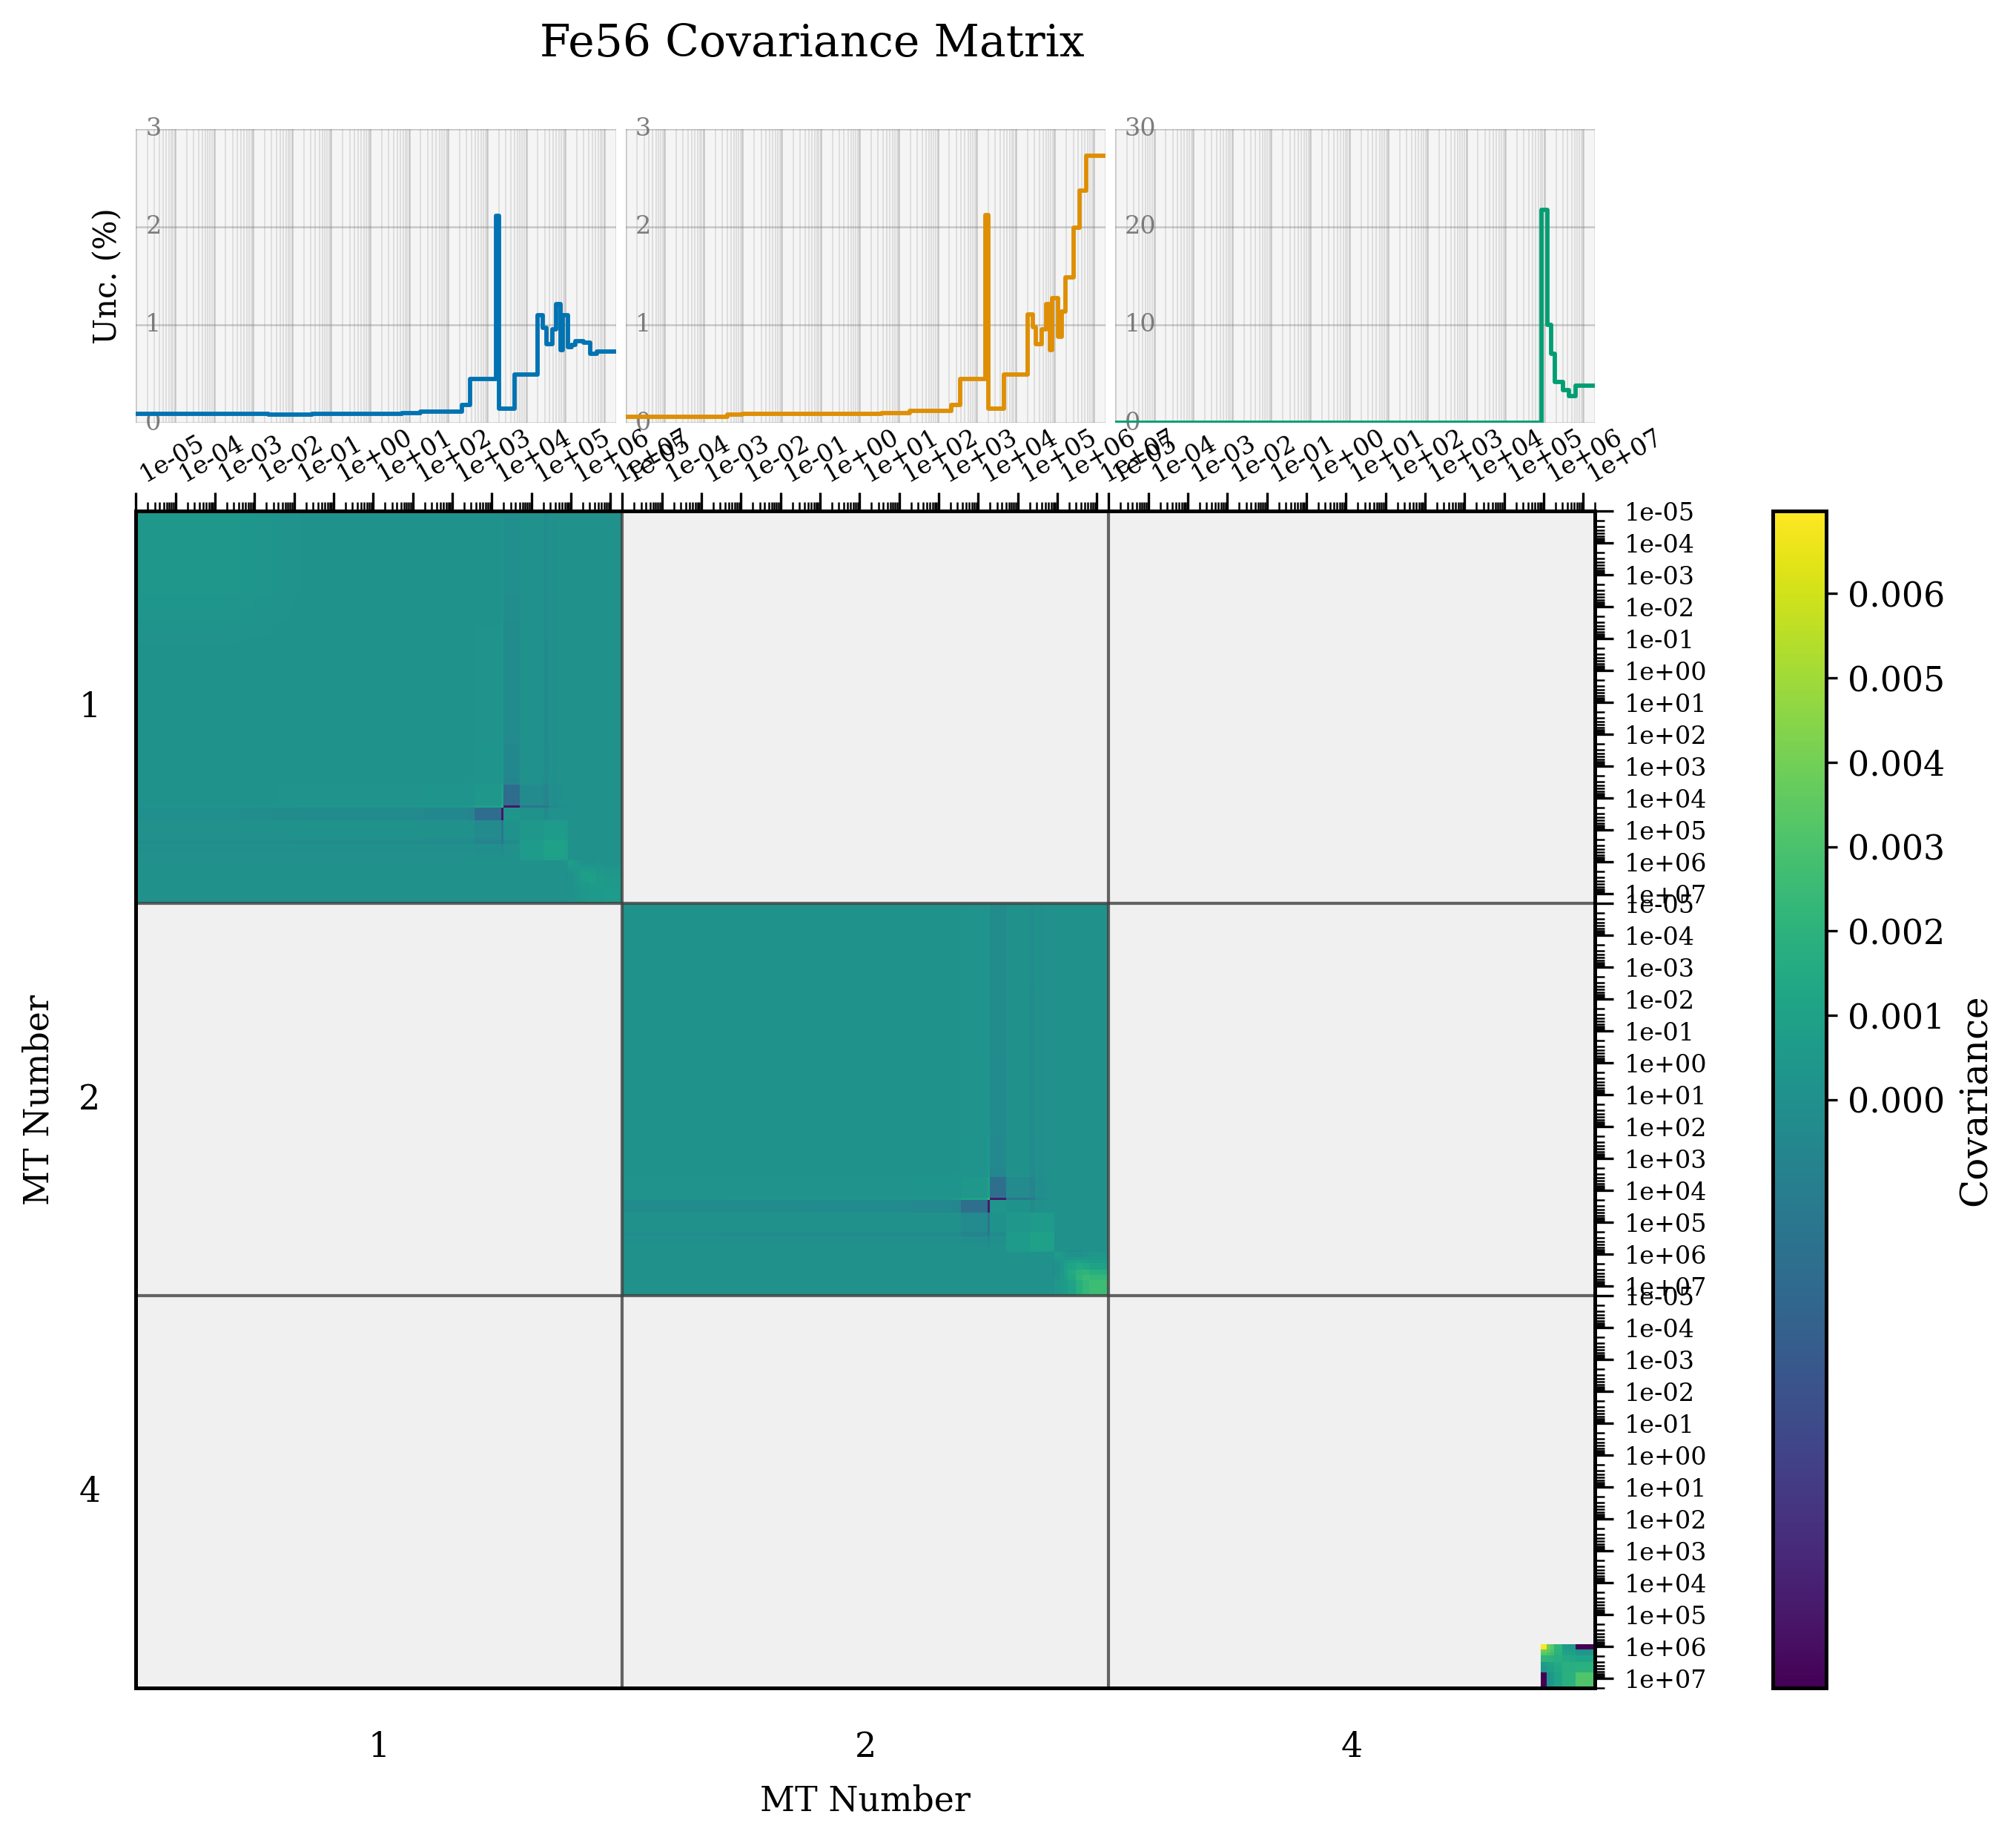

In [15]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],
    matrix_type="covariance",  # Full spelling
    show_uncertainties=True,
)
print(f"✓ Test 1.12 passed: Multiple MTs with covariance matrix")

## Test 1.13: Multiple MT - Linear Scale

✓ Test 1.13 passed: Multiple MTs with linear scale


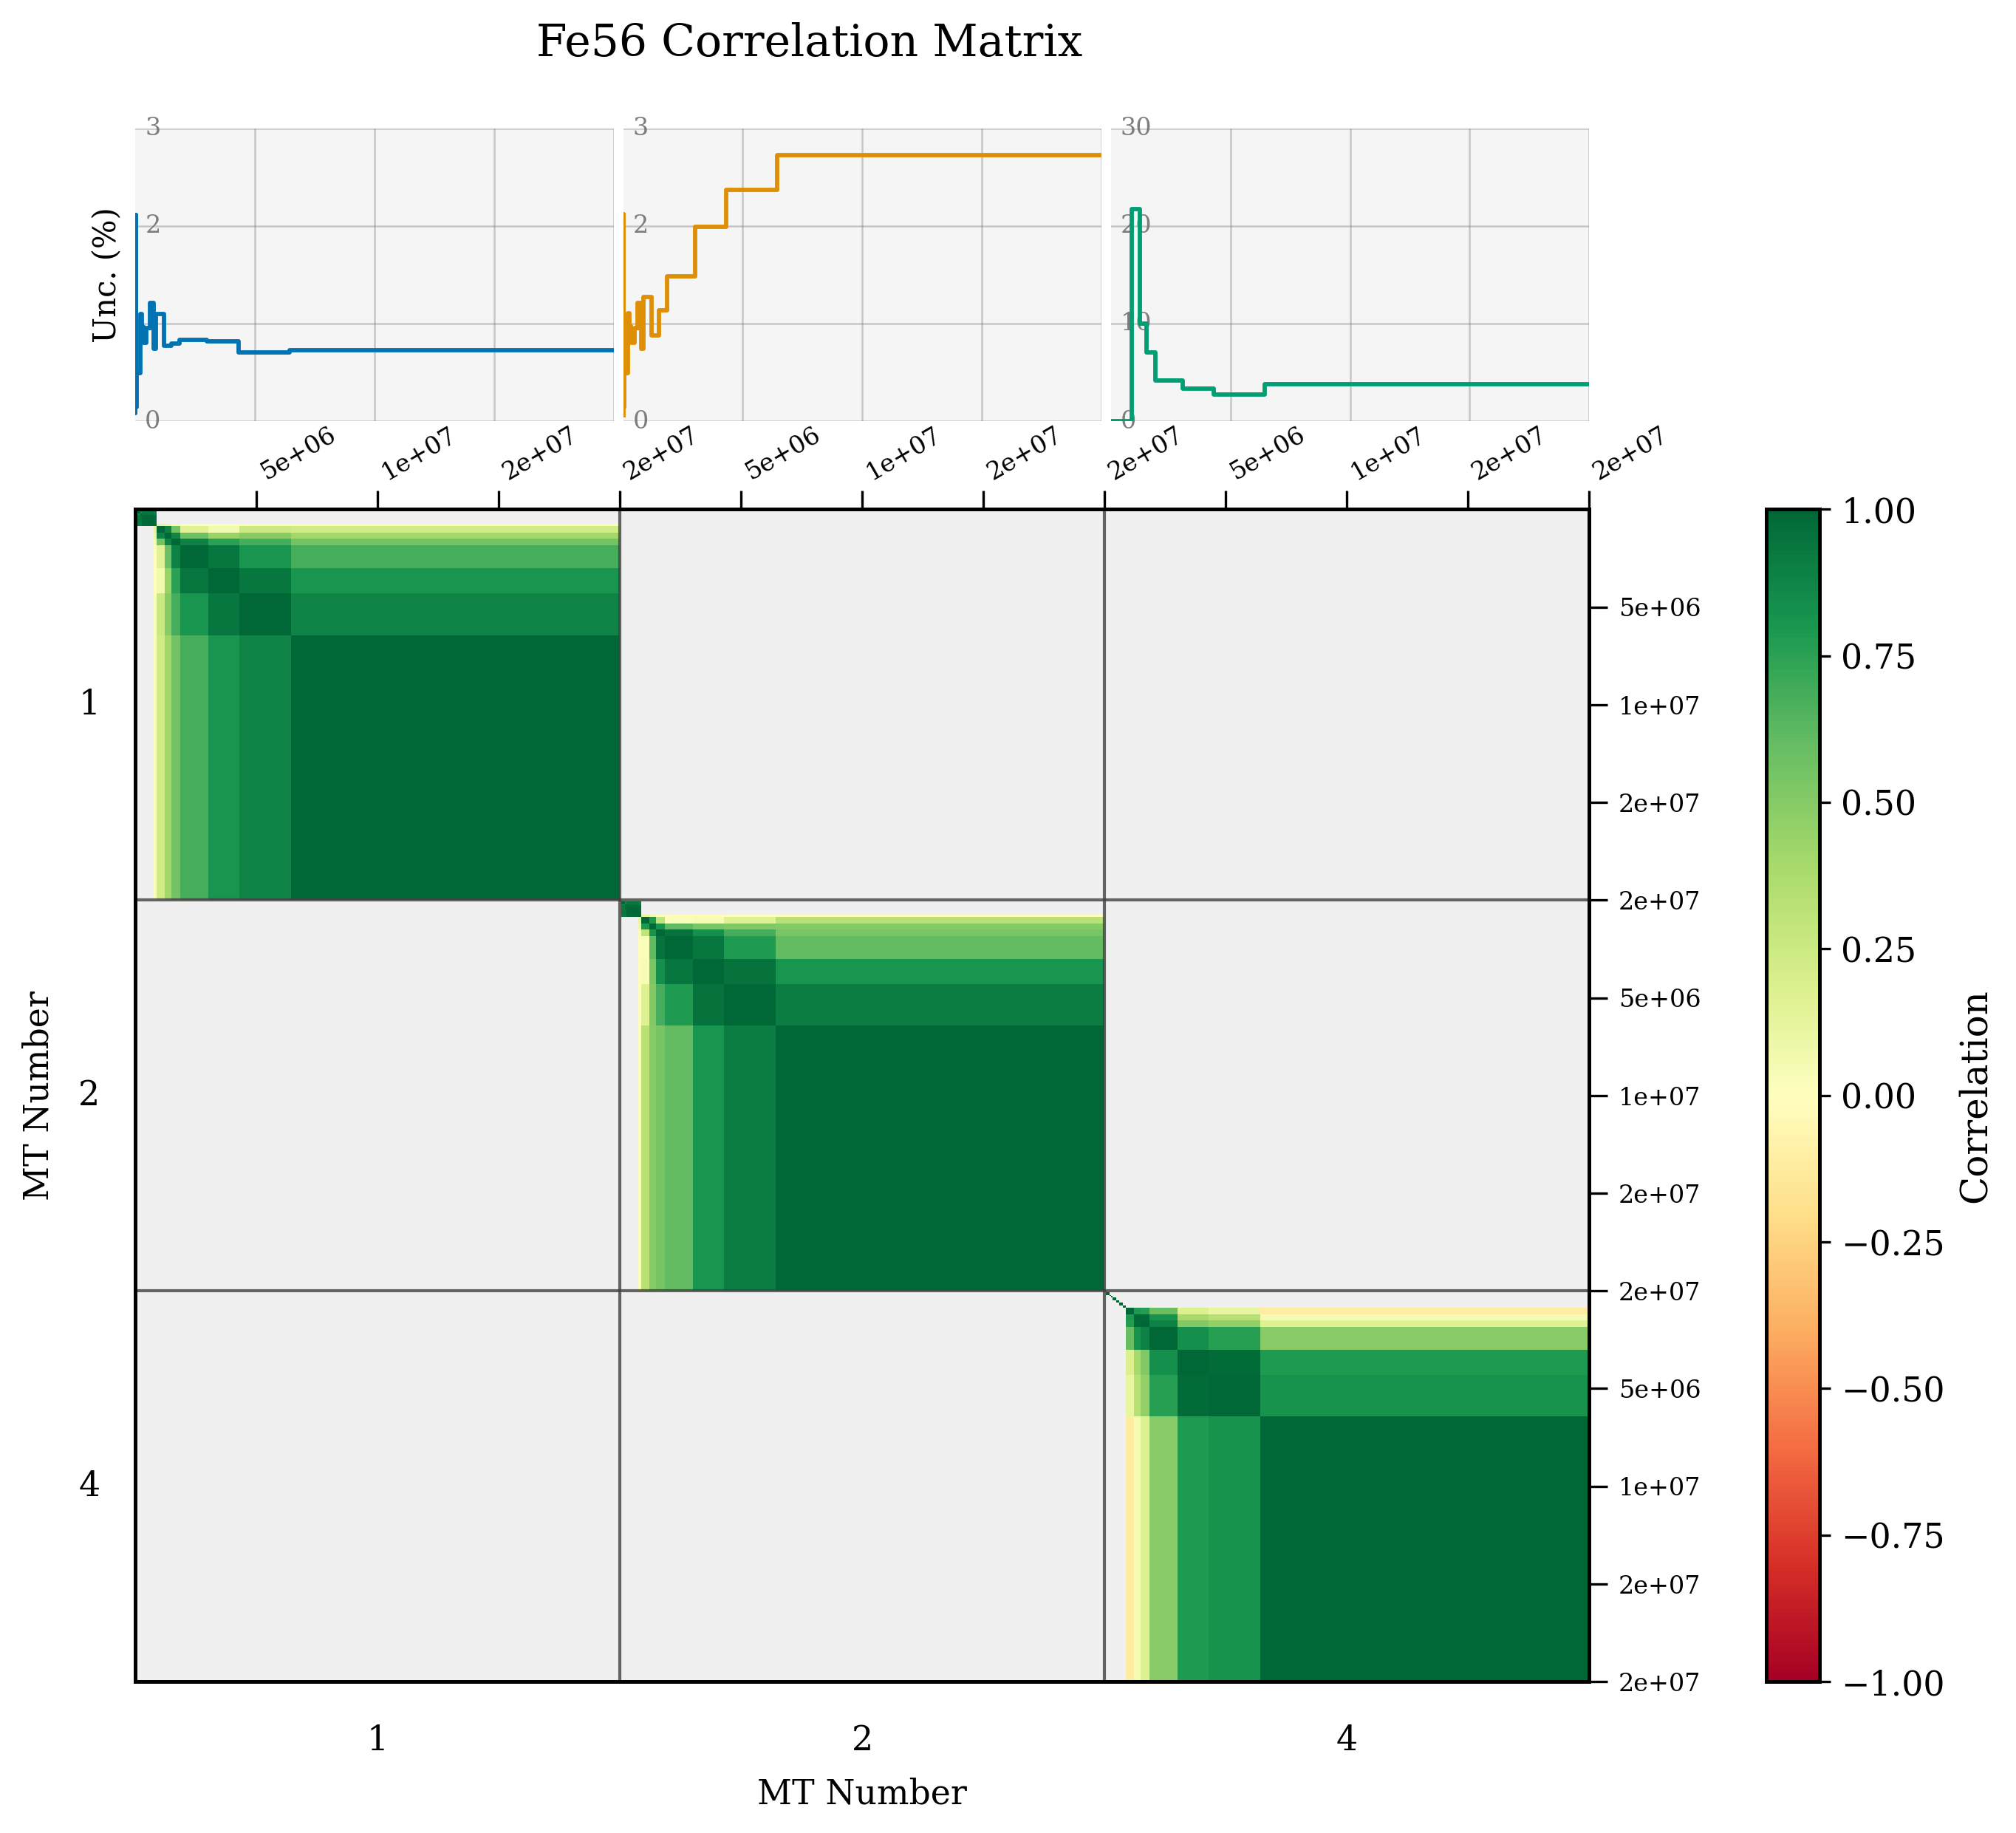

In [16]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],
    scale="lin",  # Short form
    show_uncertainties=True,
)
print(f"✓ Test 1.13 passed: Multiple MTs with linear scale")

## Test 1.14: Multiple MT - Energy Filtering

✓ Test 1.14 passed: Multiple MTs with energy filtering


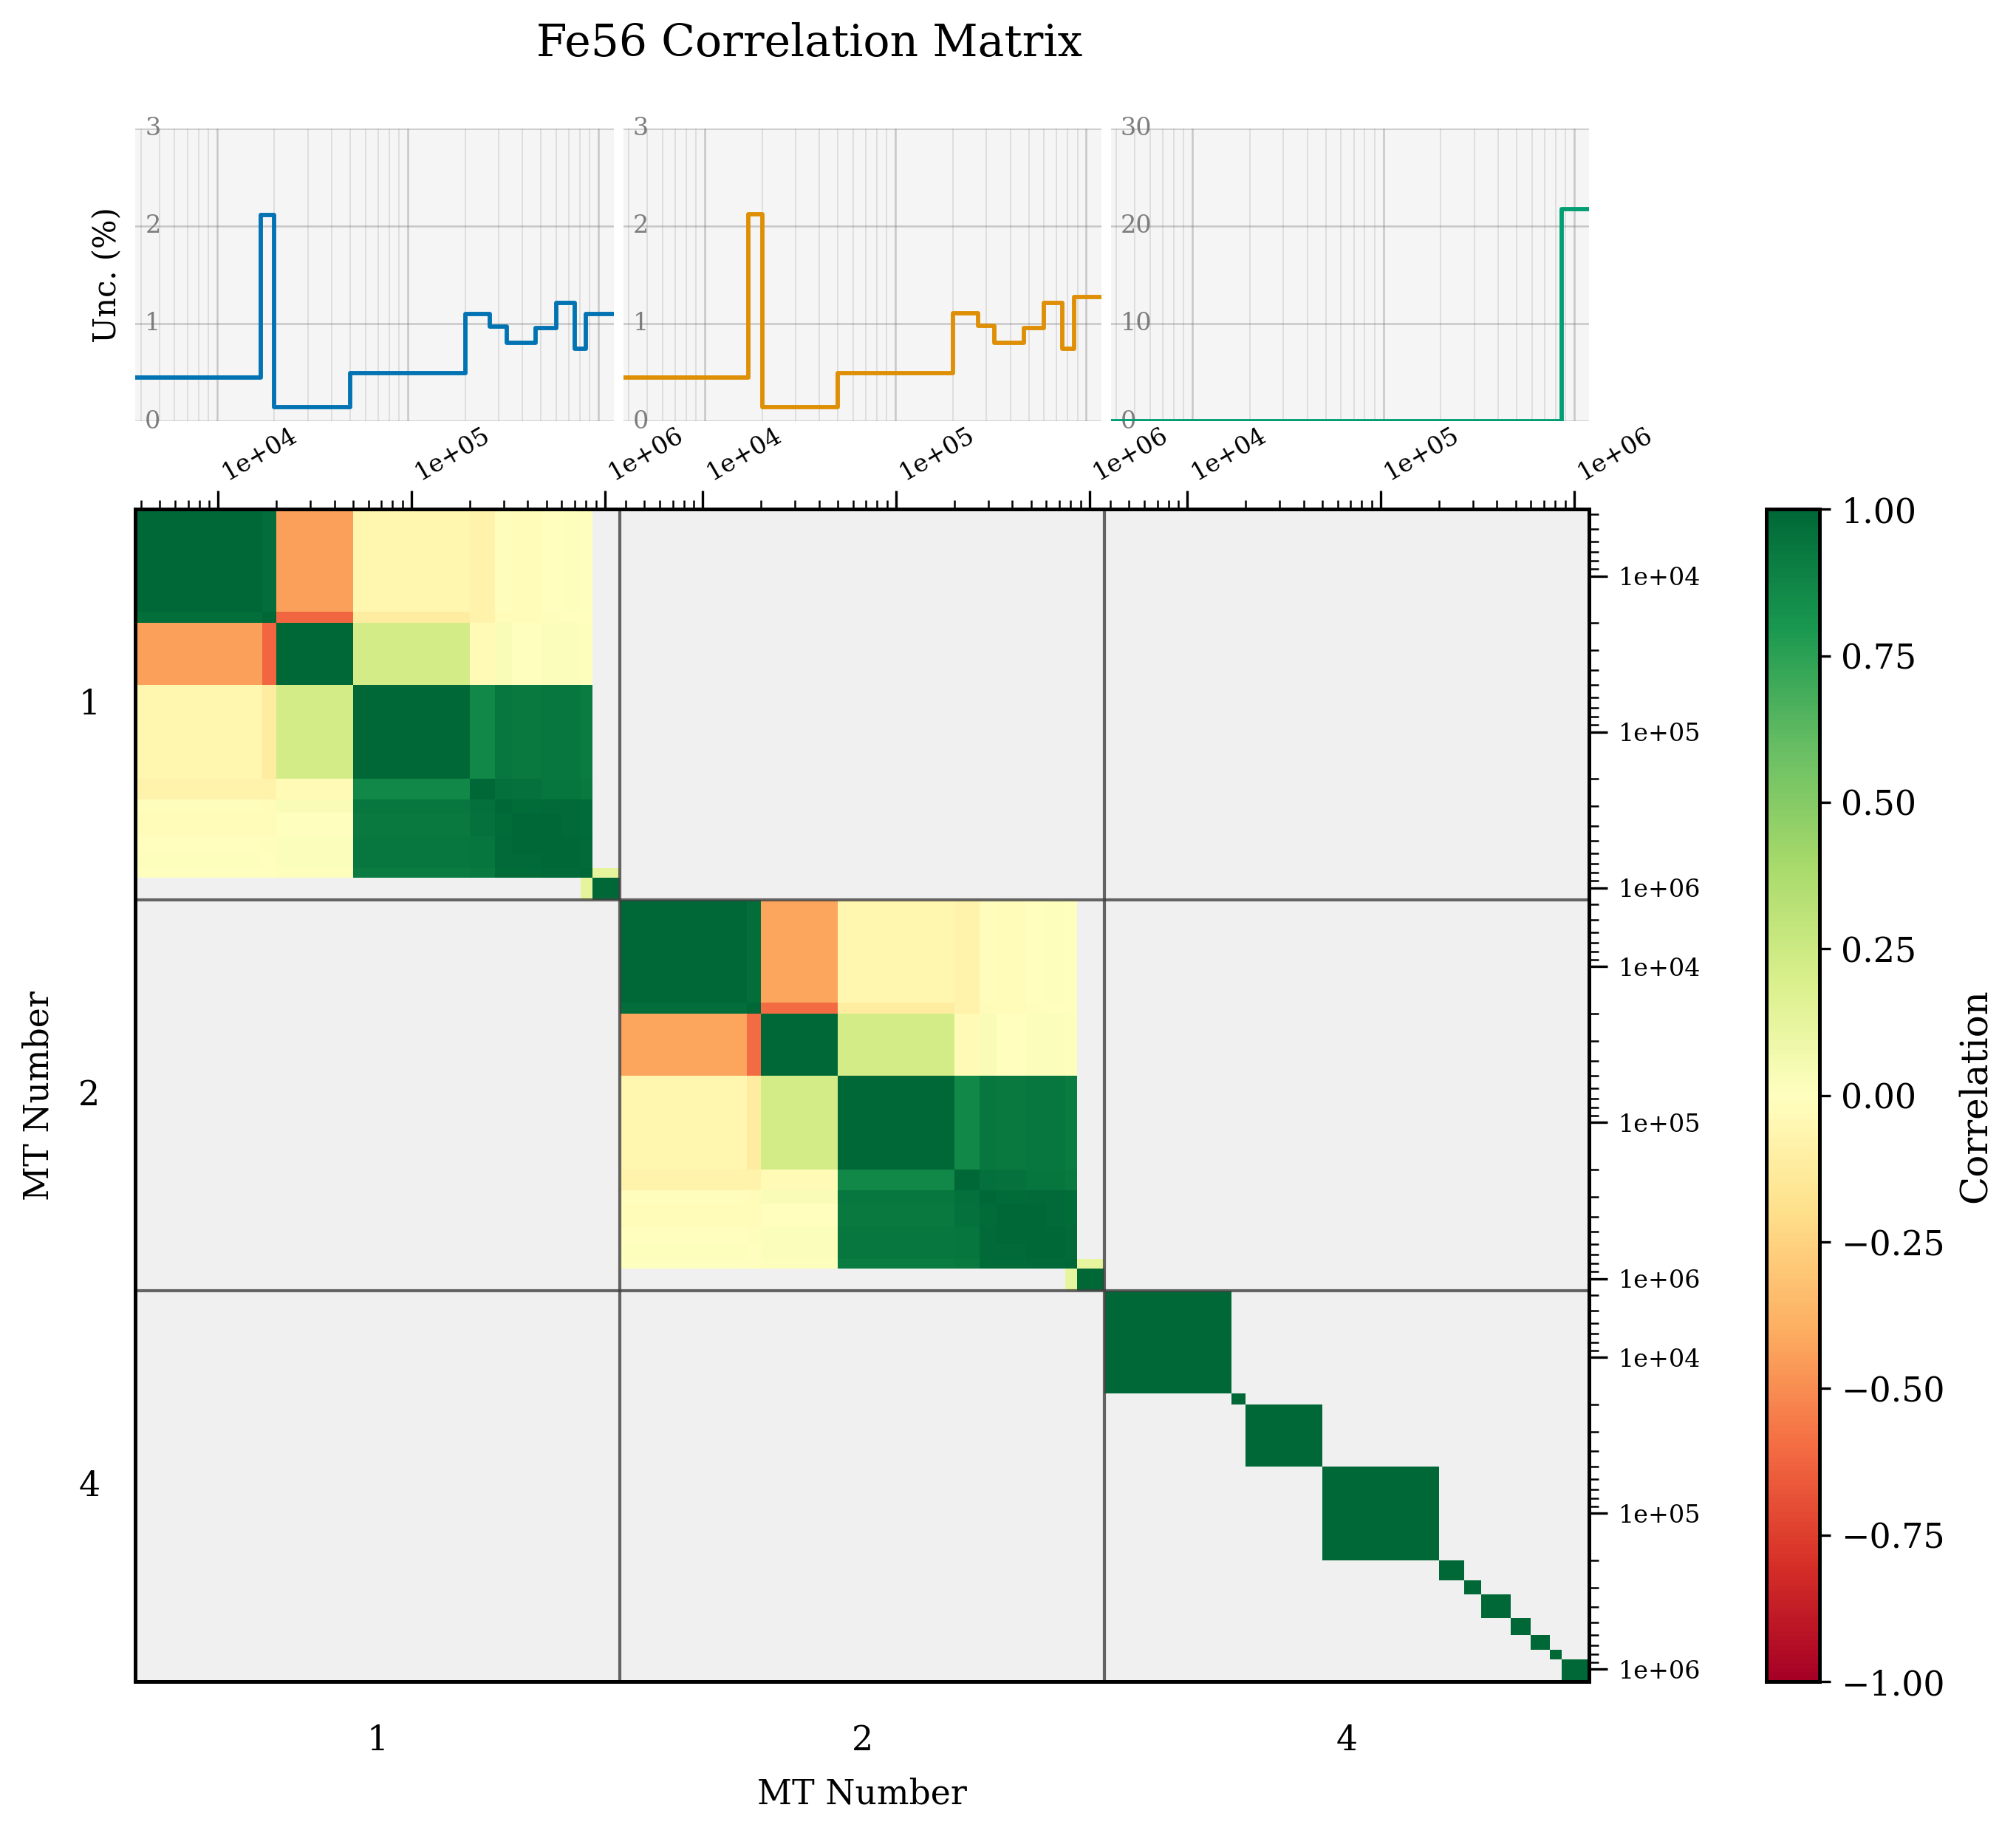

In [17]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],
    energy_range=(1e4, 1e6),  # 10 keV - 1 MeV
    show_uncertainties=True,
)
print(f"✓ Test 1.14 passed: Multiple MTs with energy filtering")

## Test 1.15: Multiple MT - Without Block Labels

✓ Test 1.15 passed: Multiple MTs without block labels


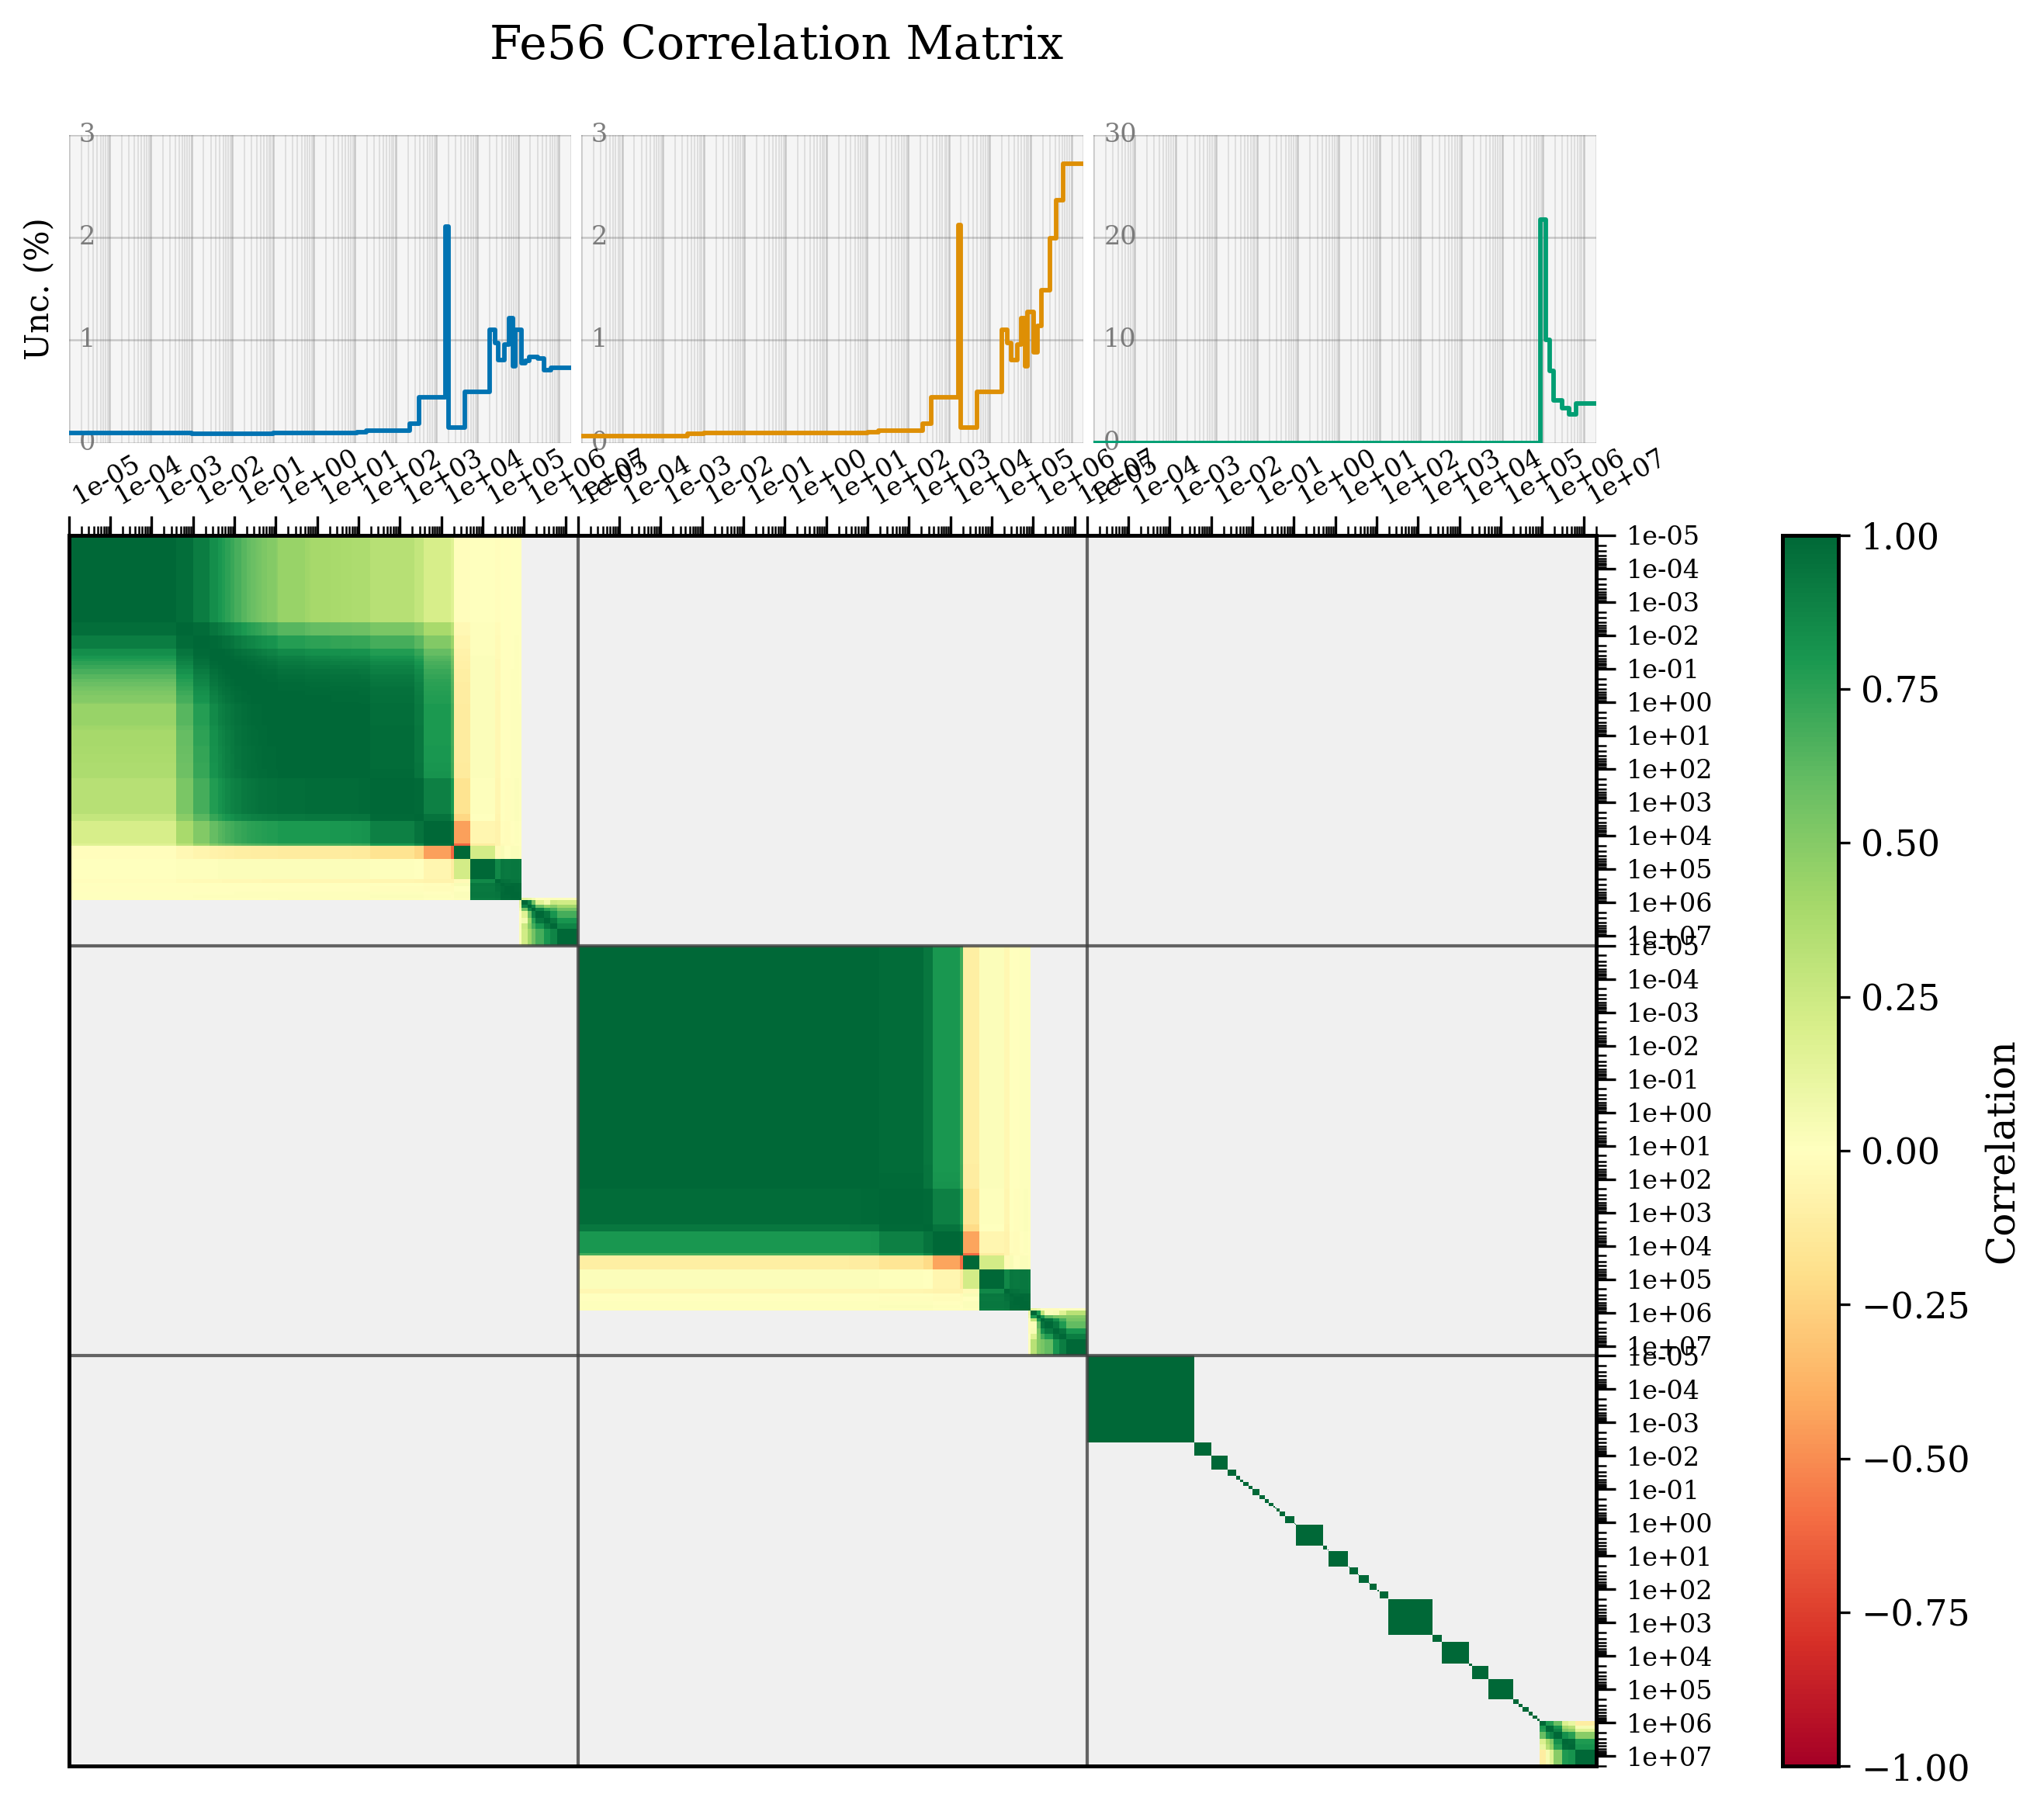

In [18]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],
    show_block_labels=False,  # Hide MT labels
)
print(f"✓ Test 1.15 passed: Multiple MTs without block labels")

## Test 1.16: Off-Diagonal Block (Two Different MTs)

✓ Test 1.16 passed: Off-diagonal block MT 1 vs 2


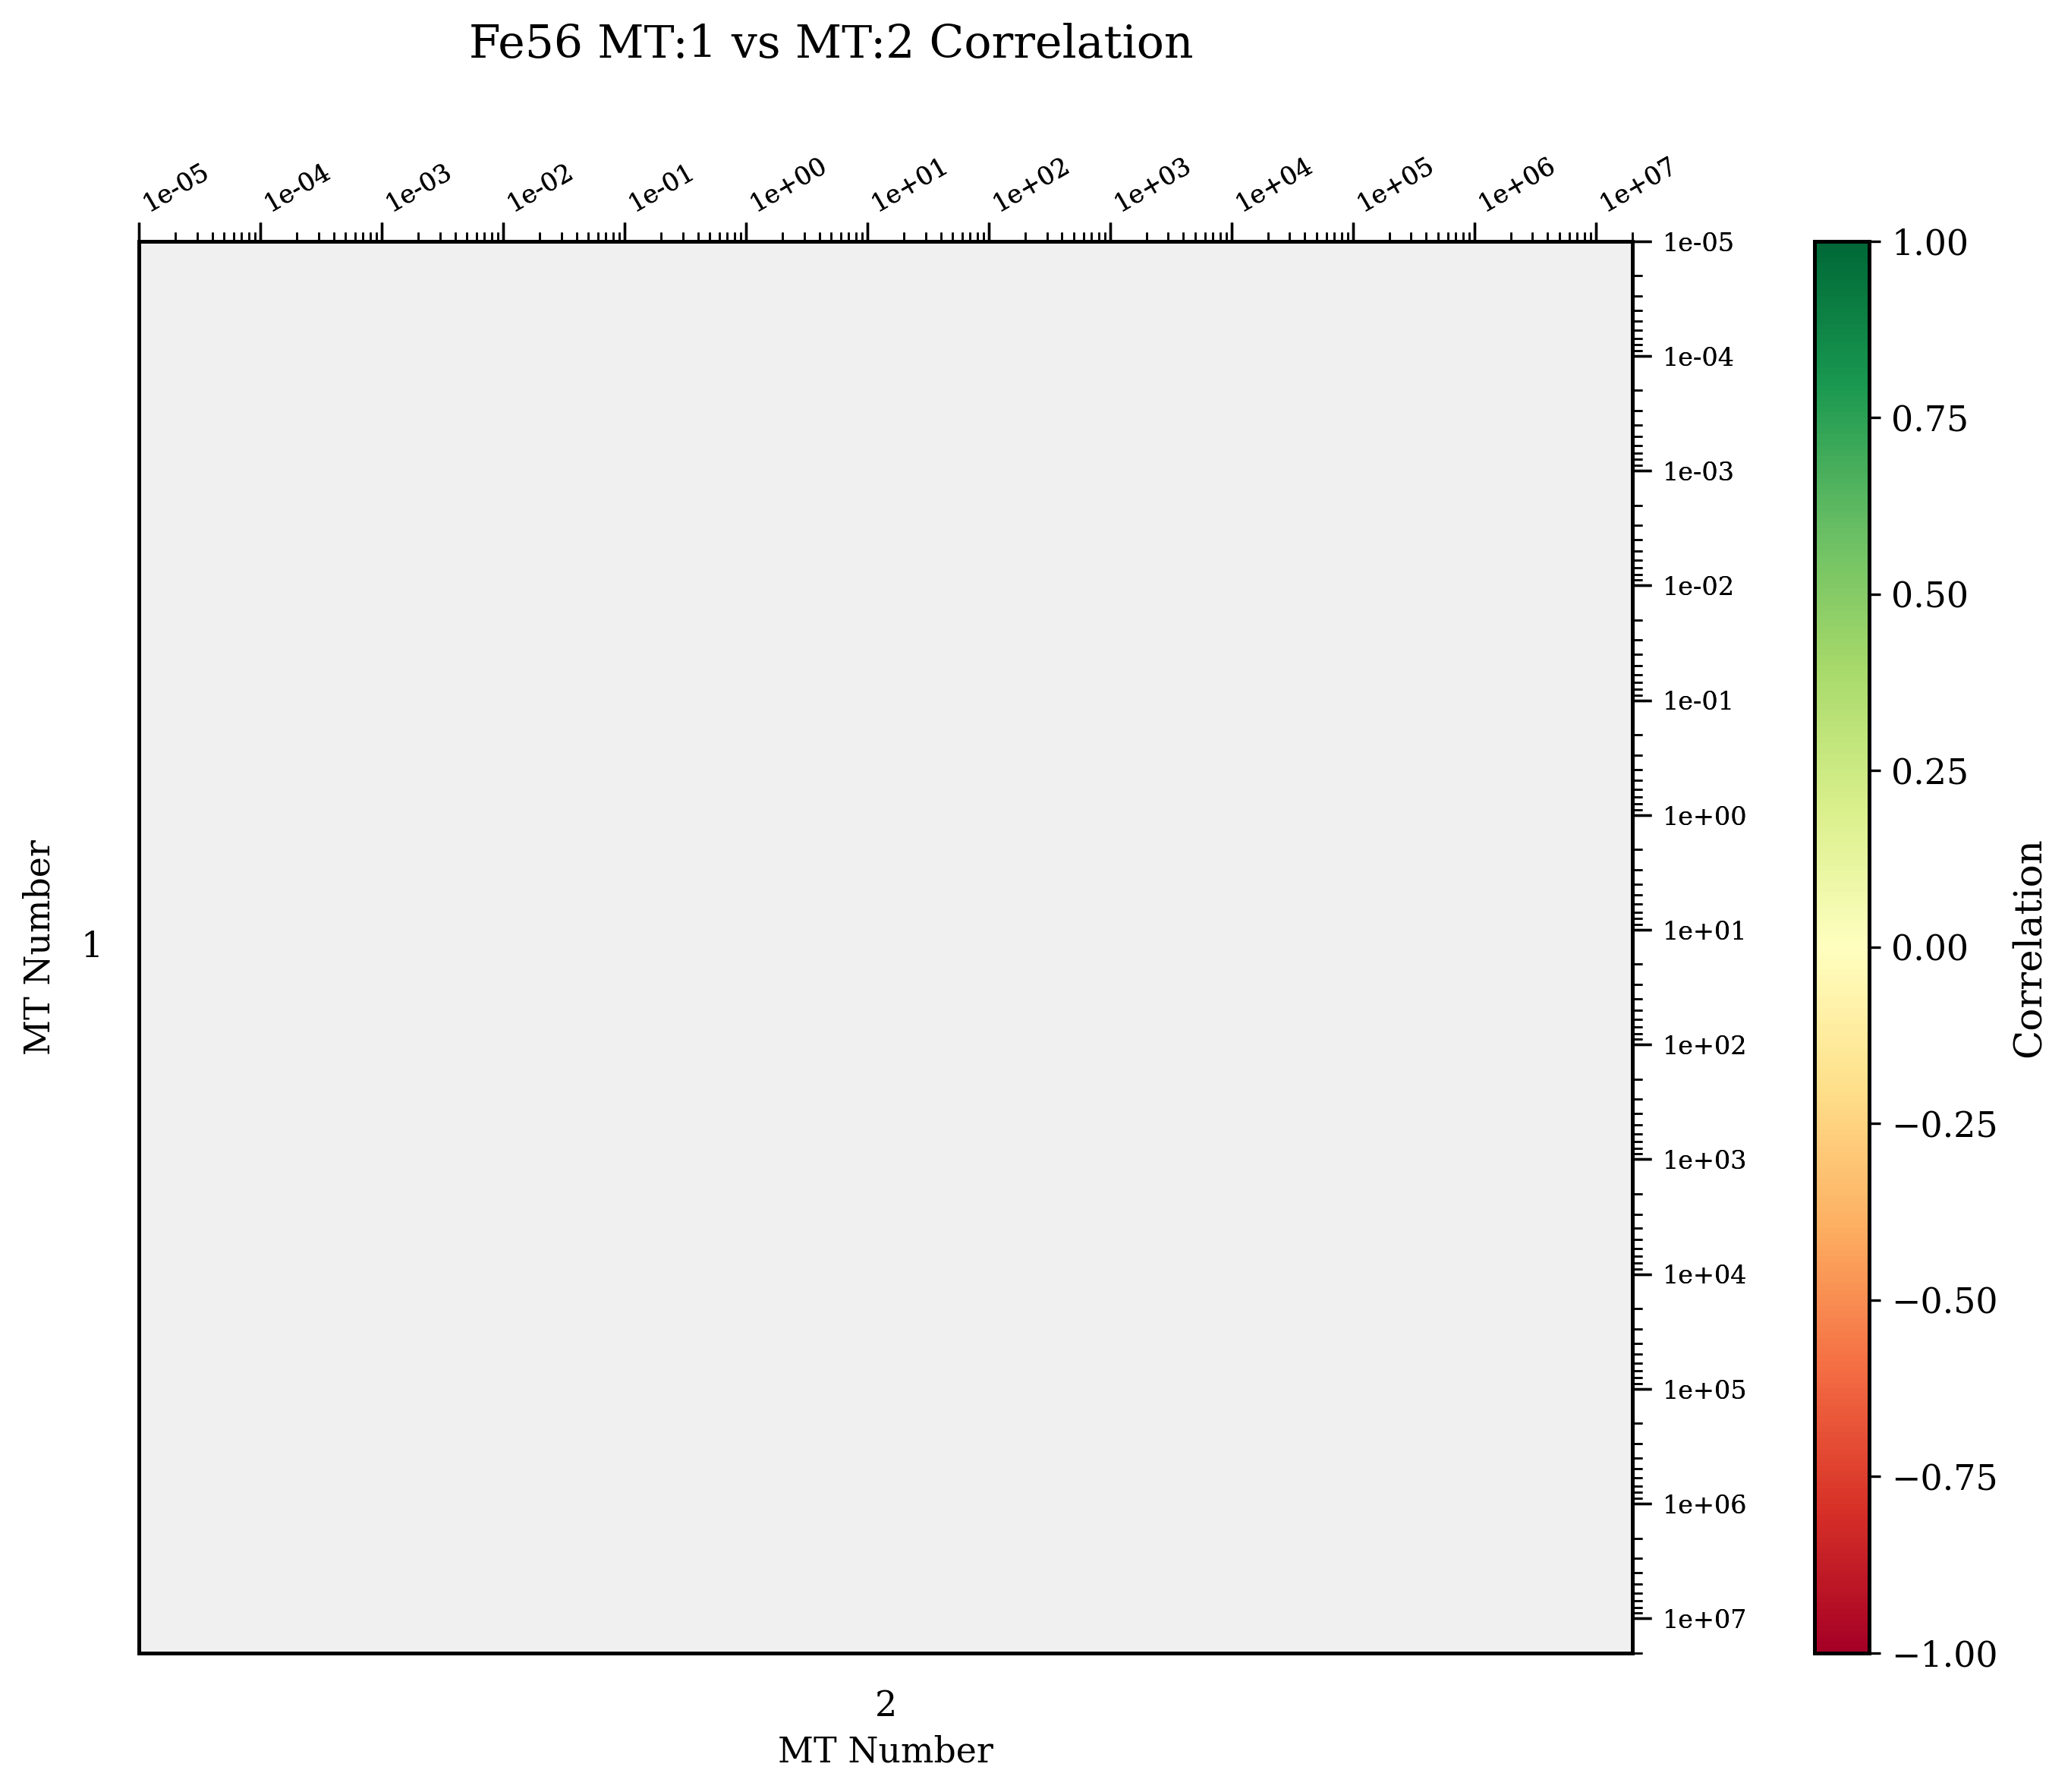

In [19]:
if len(test_mts) >= 2:
    fig = plot_covariance_heatmap(
        covmat,
        nuclide=test_zaid,
        mt=(test_mts[0], test_mts[1]),  # Tuple for off-diagonal
        show_uncertainties=False,  # No uncertainties for off-diagonal
    )
    print(f"✓ Test 1.16 passed: Off-diagonal block MT {test_mts[0]} vs {test_mts[1]}")
else:
    print("⊘ Test 1.16 skipped: Need at least 2 MTs for off-diagonal test")

## Test 1.17: Off-Diagonal Block - Covariance

✓ Test 1.17 passed: Off-diagonal covariance block


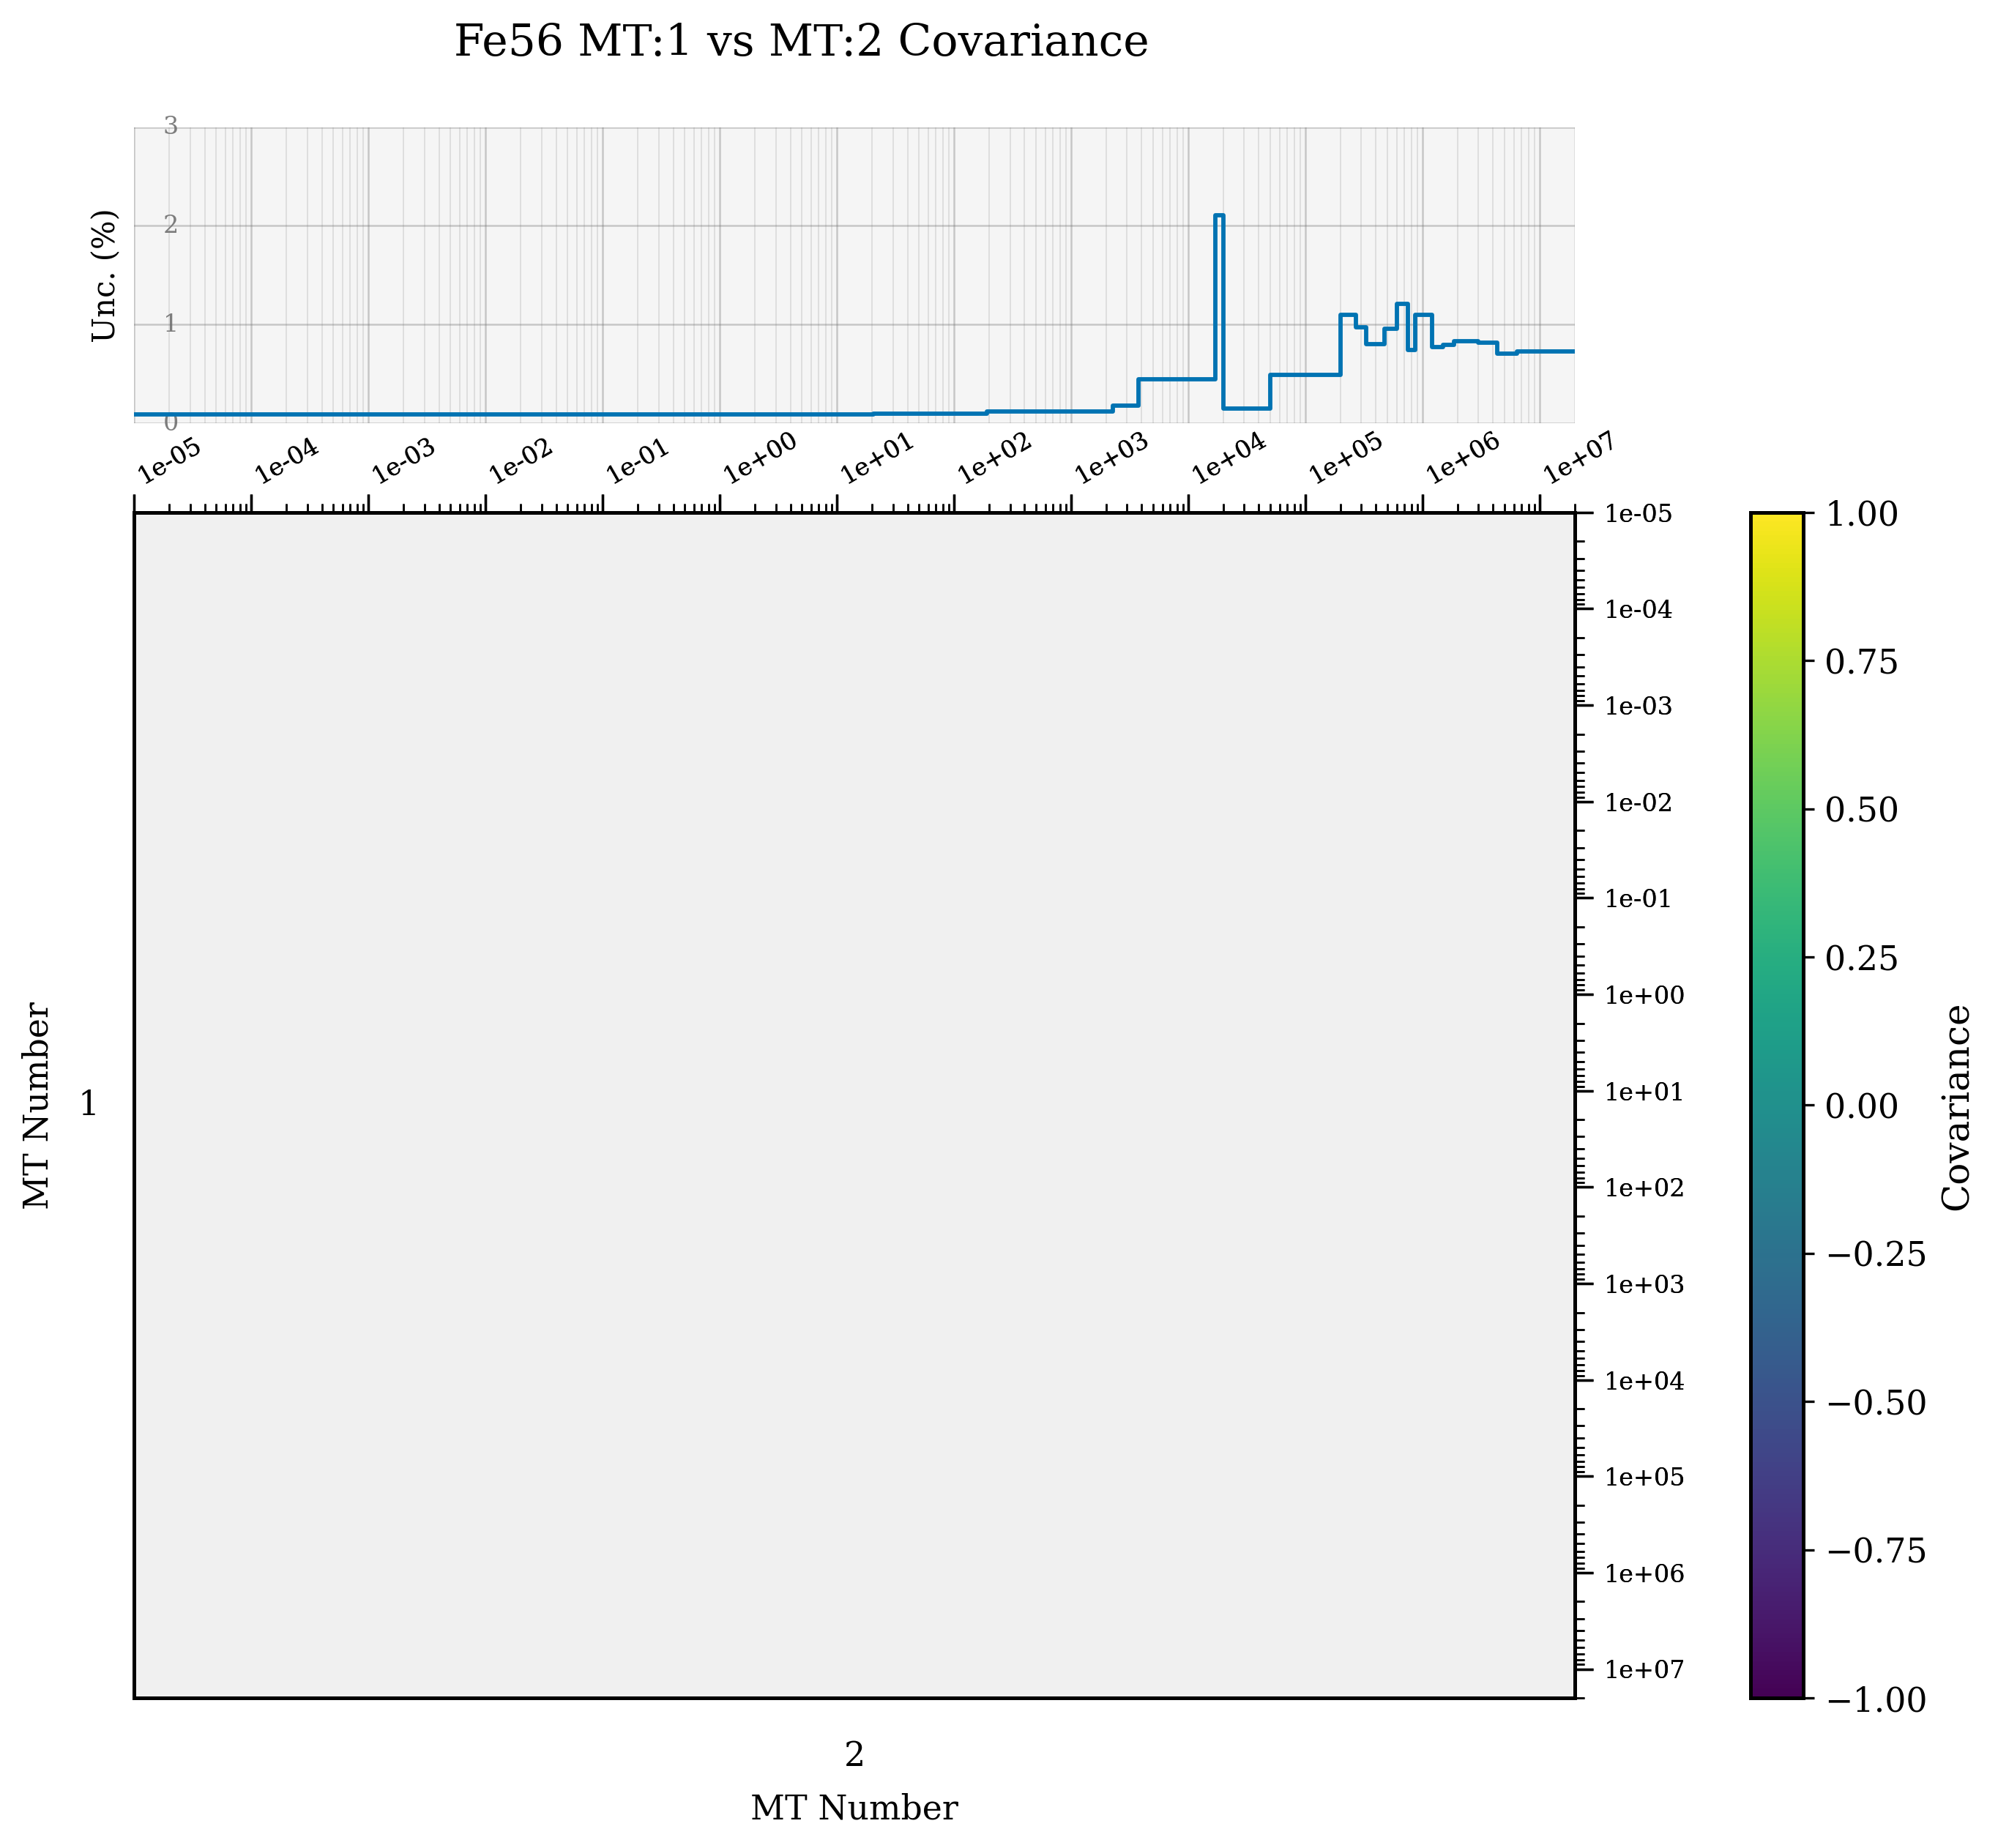

In [20]:
if len(test_mts) >= 2:
    fig = plot_covariance_heatmap(
        covmat,
        nuclide=test_zaid,
        mt=(test_mts[0], test_mts[1]),
        matrix_type="cov",
    )
    print(f"✓ Test 1.17 passed: Off-diagonal covariance block")
else:
    print("⊘ Test 1.17 skipped: Need at least 2 MTs")

## Test 1.18: Using Nuclide String Identifier

✓ Test 1.18 passed: Using nuclide string 'Fe56'


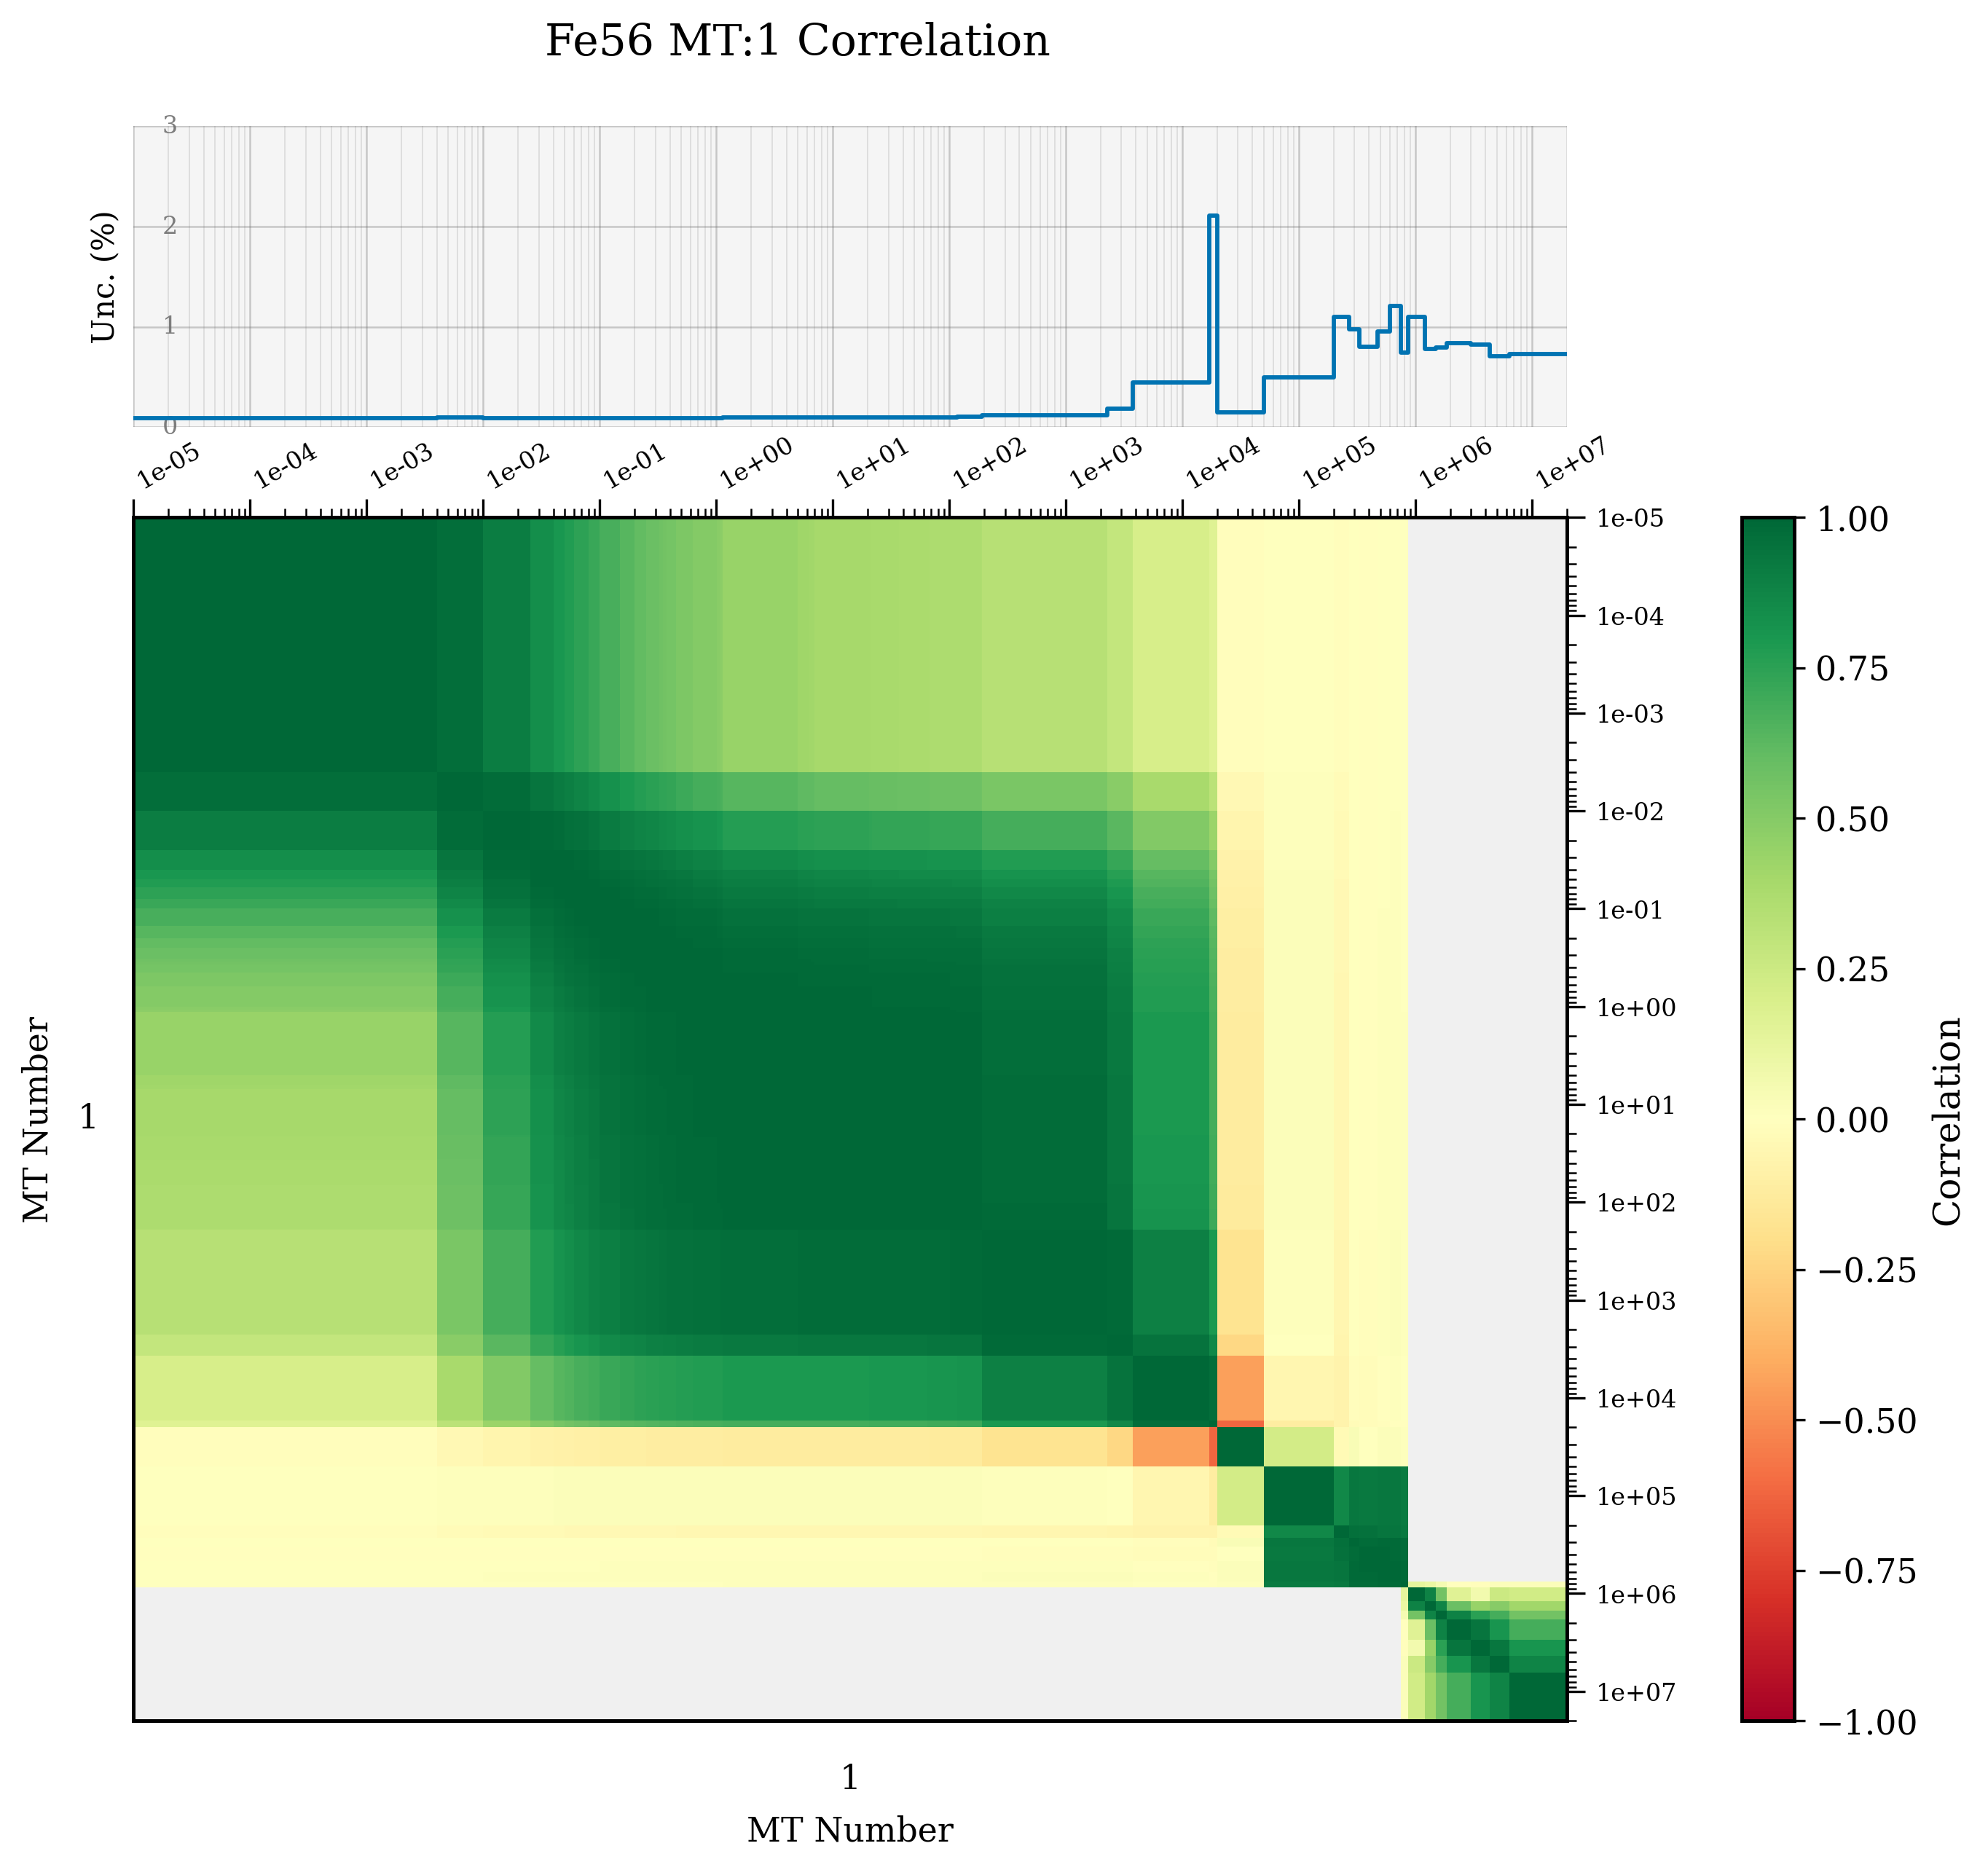

In [21]:
# Convert ZAID to symbol (Fe56 for 26056)
fig = plot_covariance_heatmap(
    covmat,
    nuclide='Fe56',  # String instead of ZAID
    mt=test_mts[0],
    show_uncertainties=True,
)
print(f"✓ Test 1.18 passed: Using nuclide string 'Fe56'")

## Test 1.19: Custom Colormap

✓ Test 1.19 passed: Custom colormap 'RdYlGn'


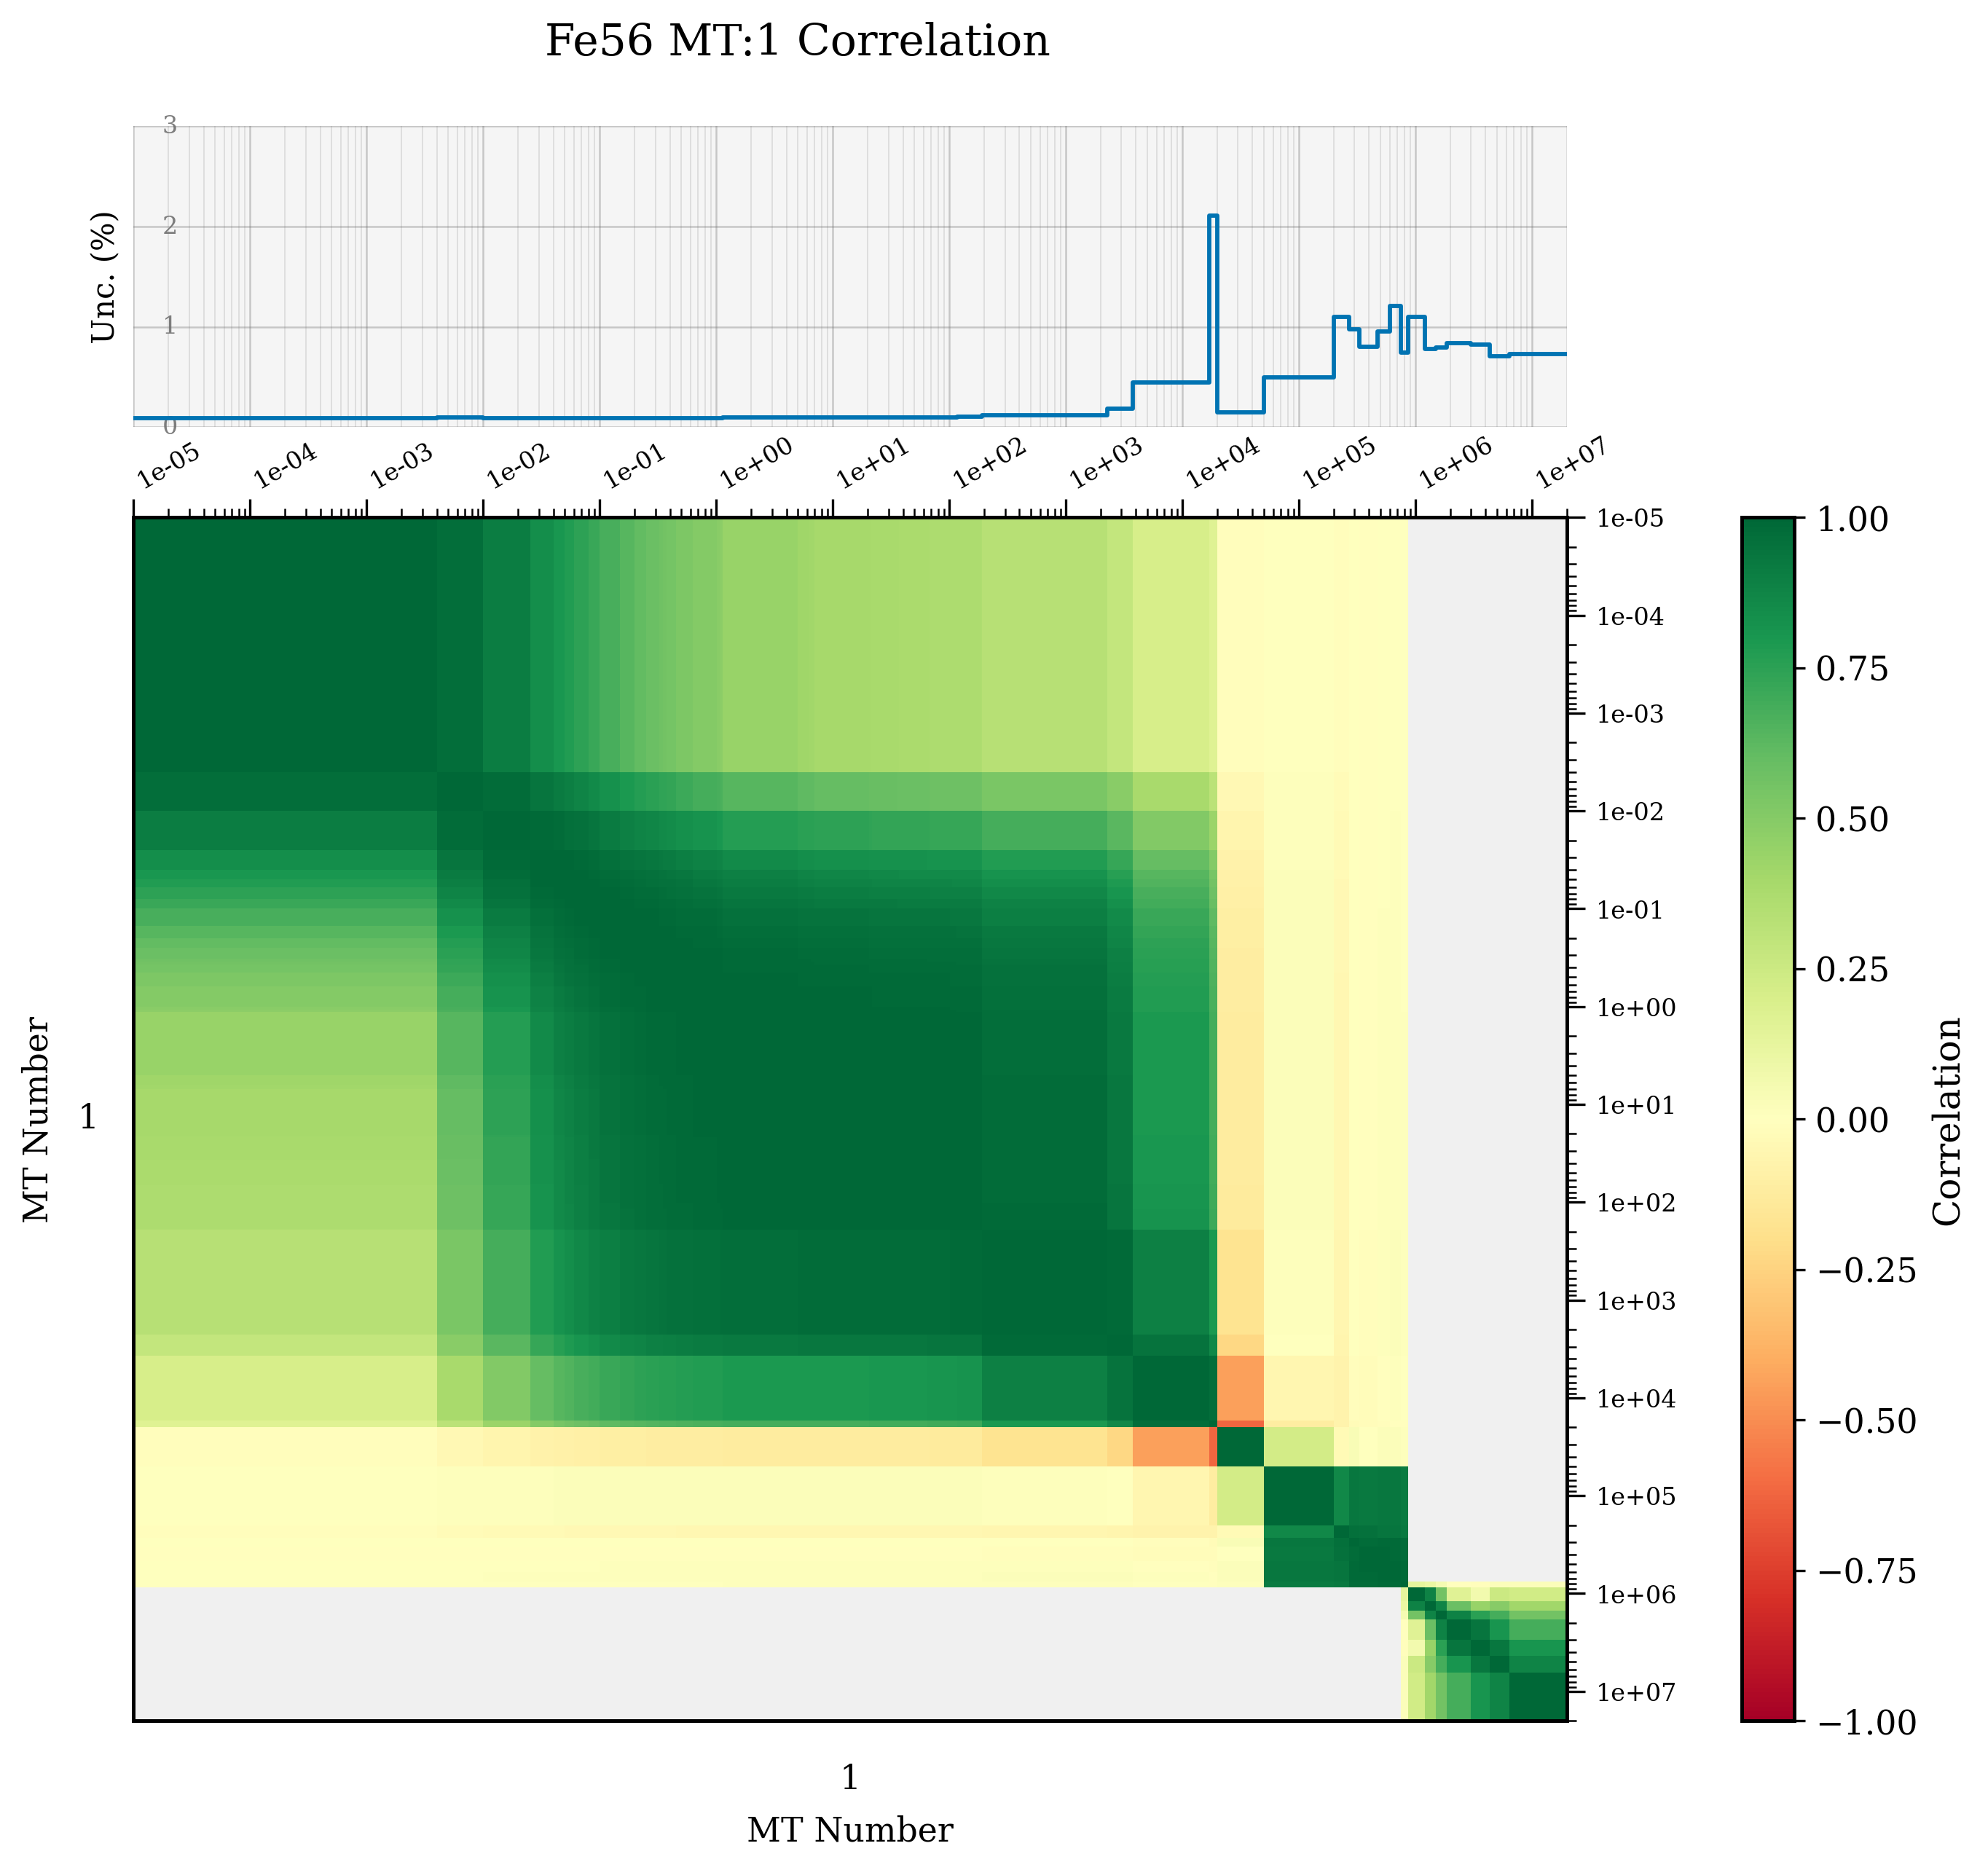

In [22]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    cmap='RdYlGn',  # Custom colormap
)
print(f"✓ Test 1.19 passed: Custom colormap 'RdYlGn'")

## Test 1.20: Custom Colorbar Label

✓ Test 1.20 passed: Custom colorbar label


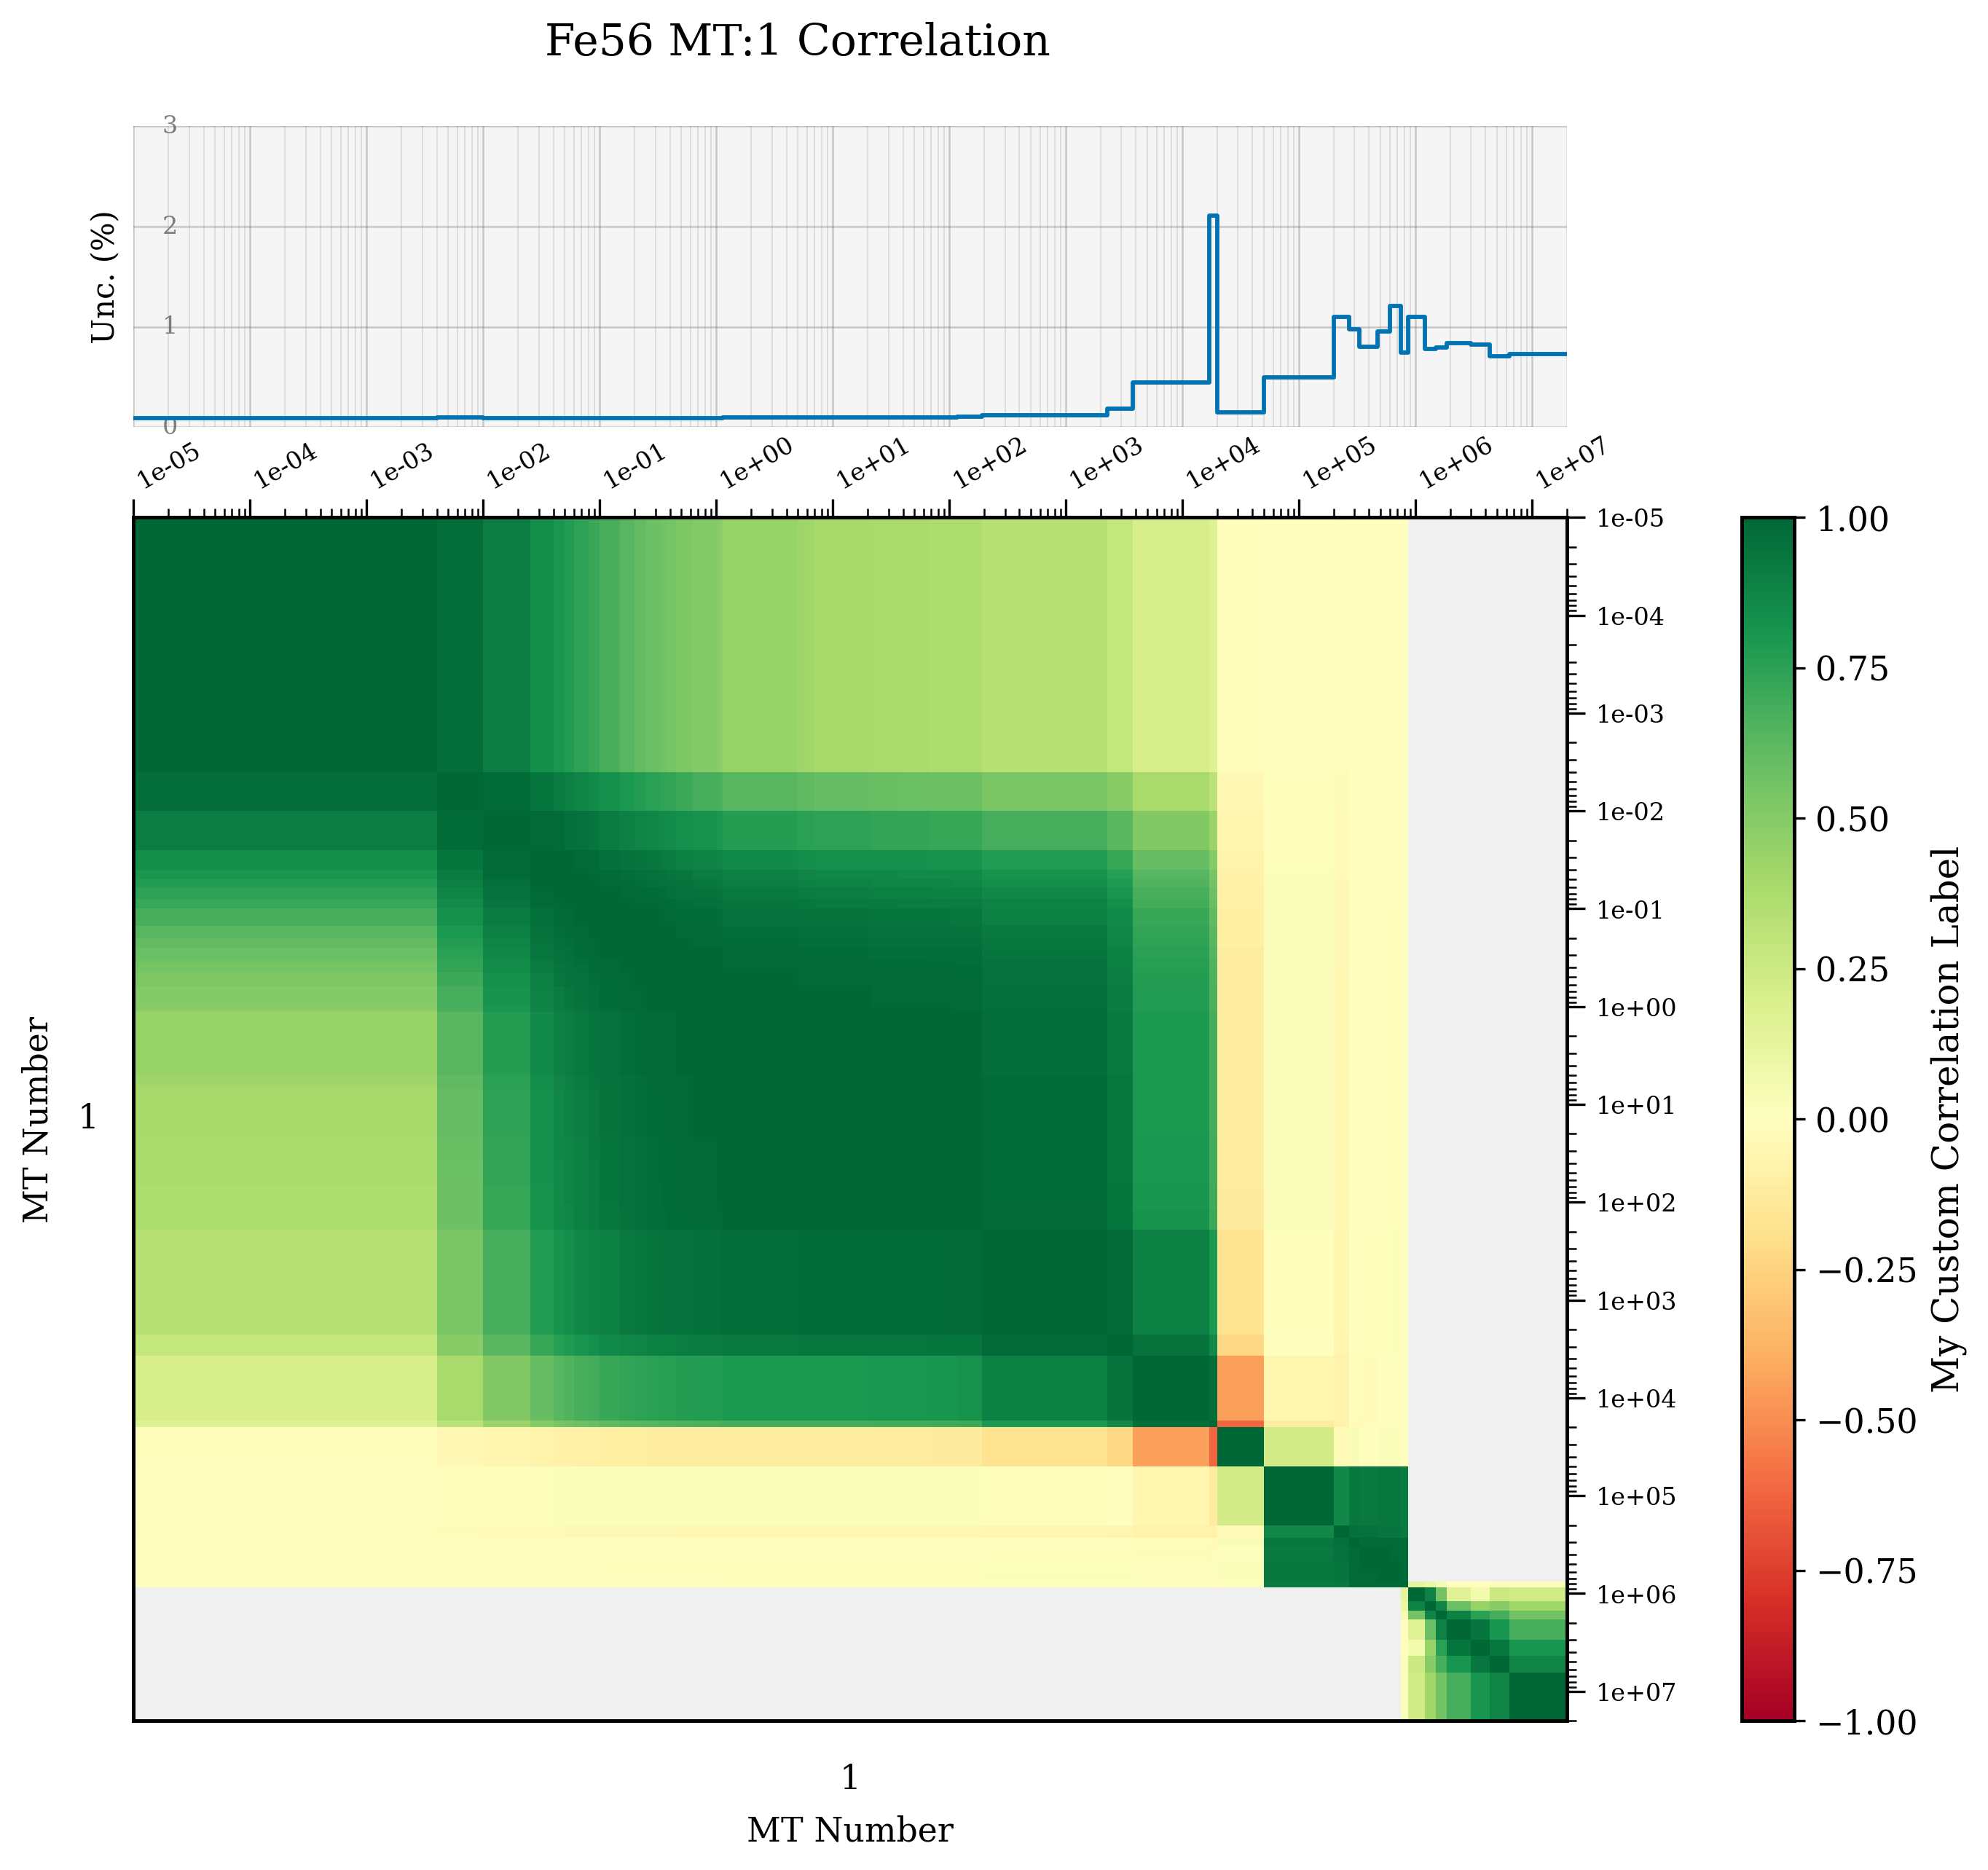

In [23]:
fig = plot_covariance_heatmap(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    colorbar_label="My Custom Correlation Label",
)
print(f"✓ Test 1.20 passed: Custom colorbar label")

---
# Part 2: `plot_mf34_covariance_heatmap()` Tests

Testing MF34 angular distribution covariance heatmaps.

## Test 2.1: Single Legendre Coefficient - Correlation

✓ Test 2.1 passed: Single Legendre L=1, correlation


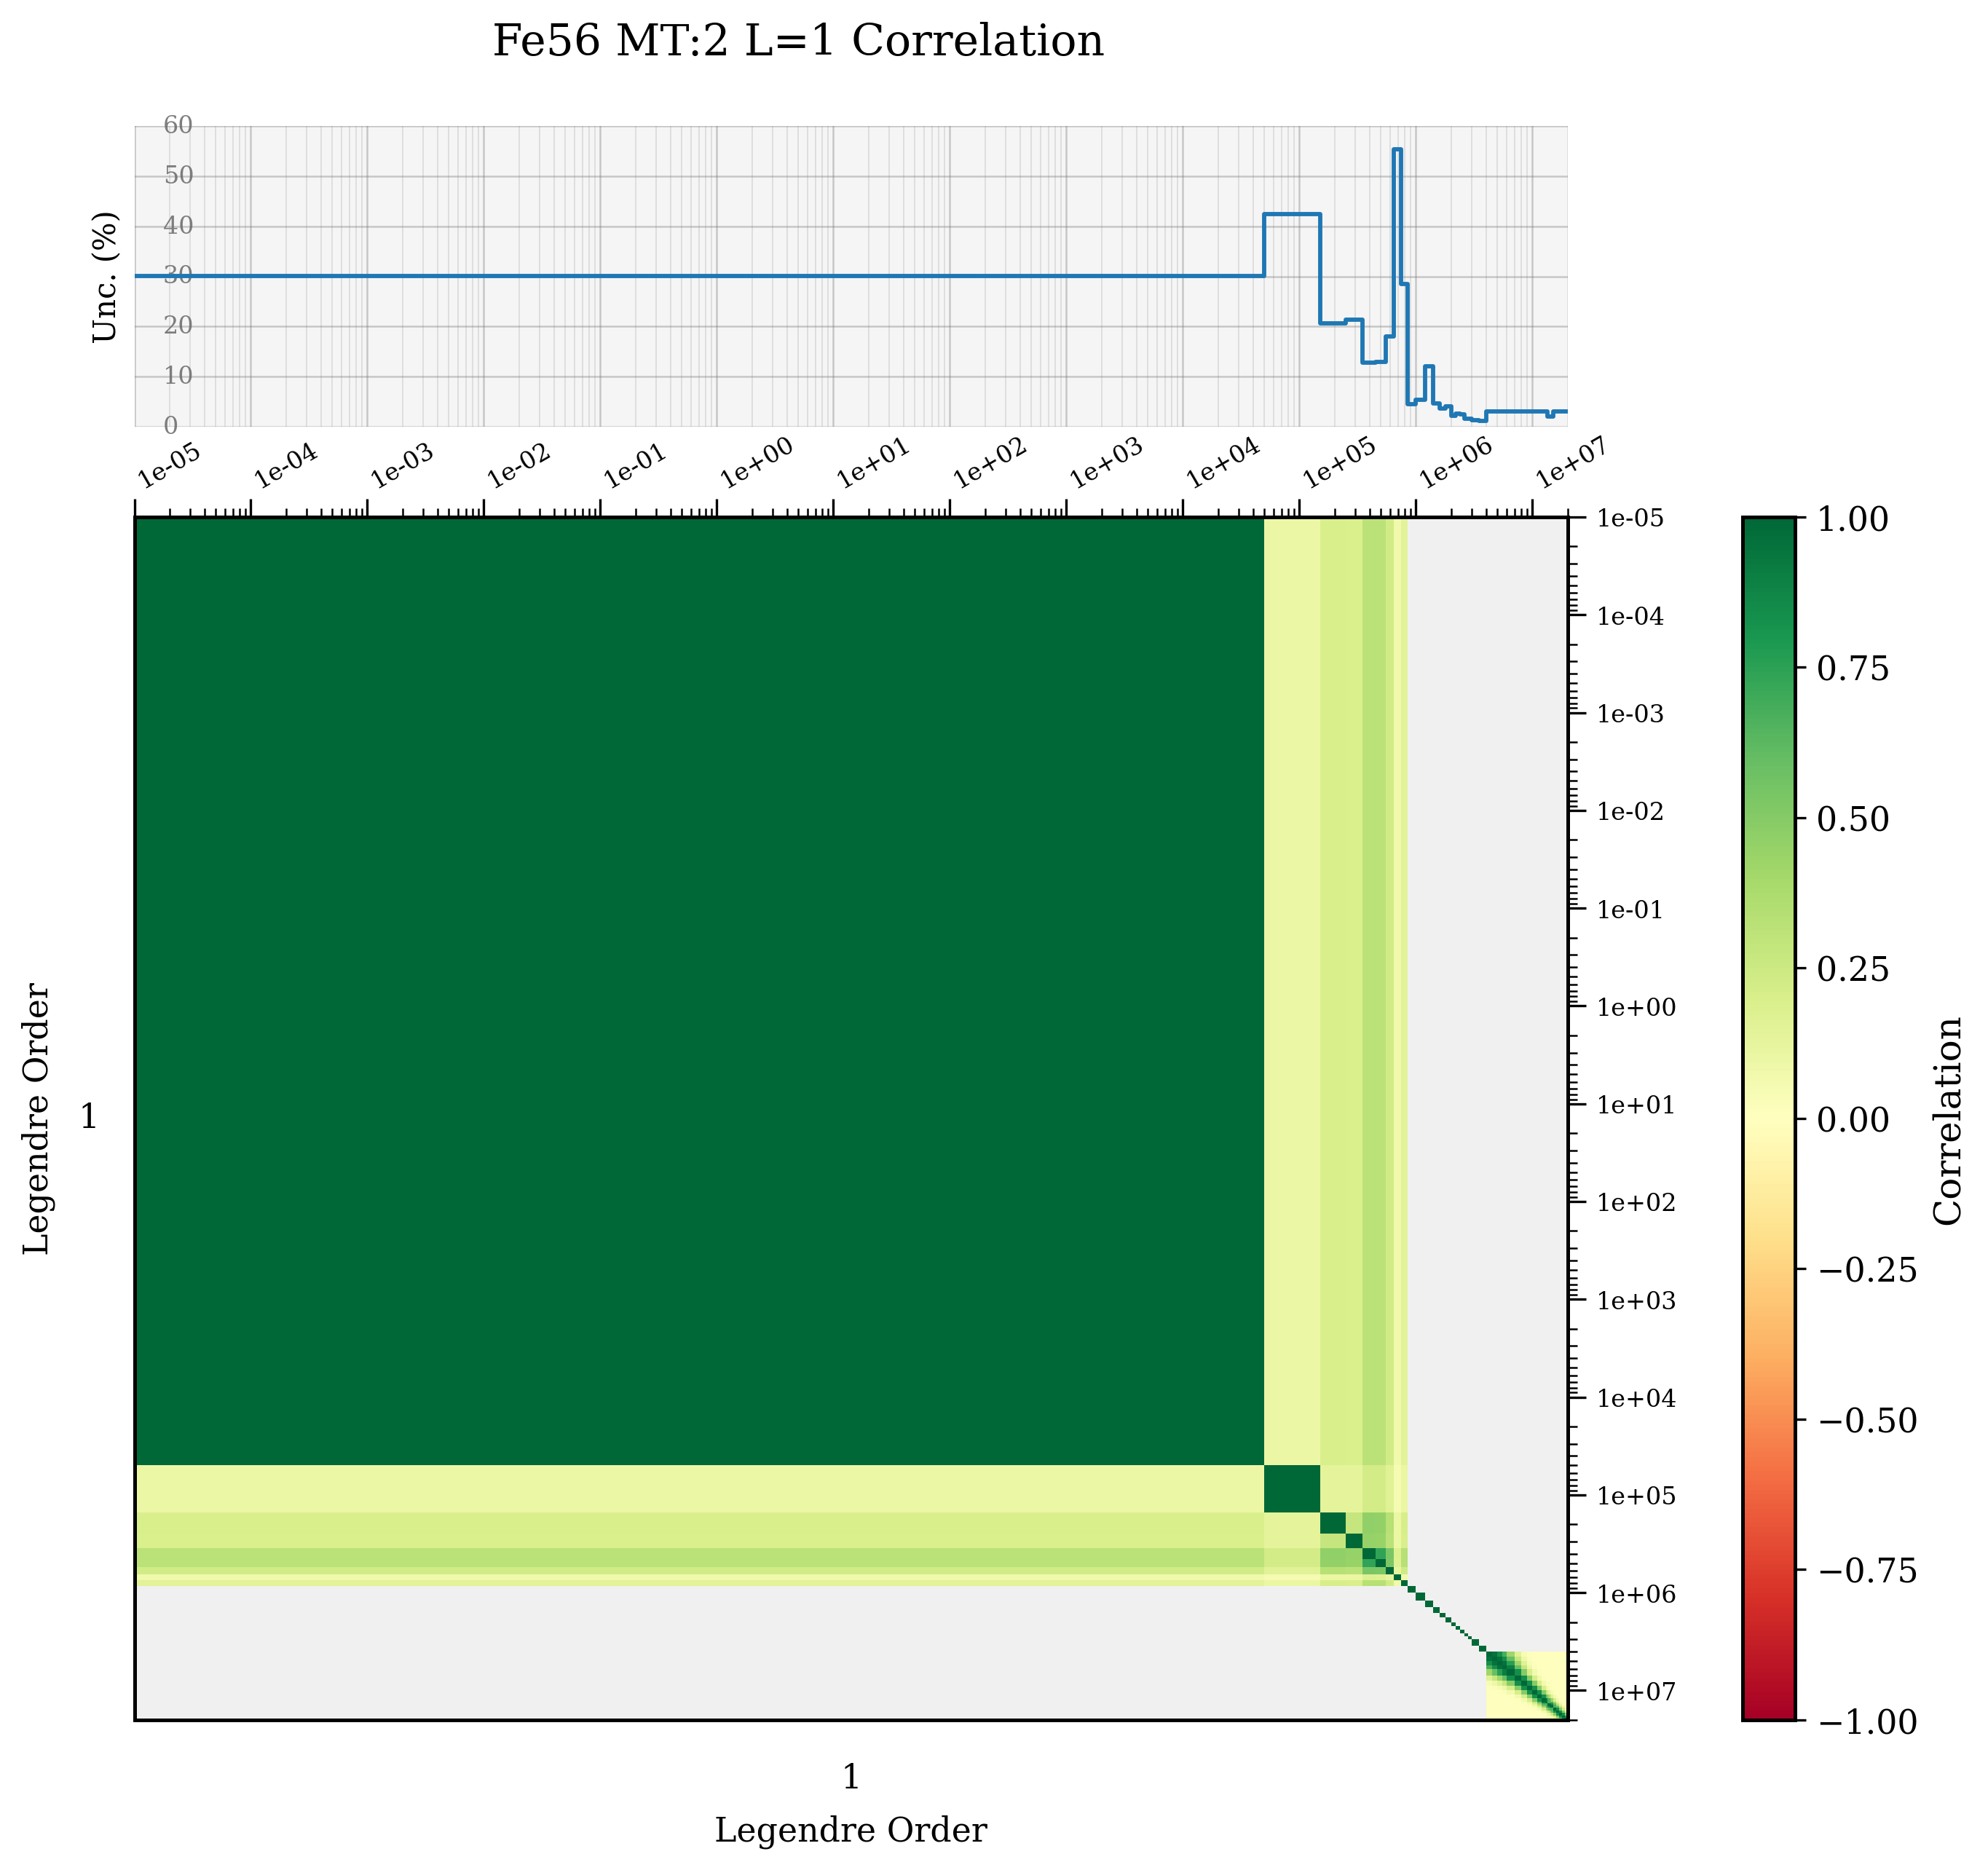

In [24]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],  # Single L
    matrix_type="corr",
    scale="log",
    show_uncertainties=True,
    show_energy_ticks=True,
    show_block_labels=True,
    show_colorbar=True,
)
print(f"✓ Test 2.1 passed: Single Legendre L={mf34_test_legendre[0]}, correlation")

## Test 2.2: Single Legendre Coefficient - Covariance

✓ Test 2.2 passed: Single Legendre L=1, covariance


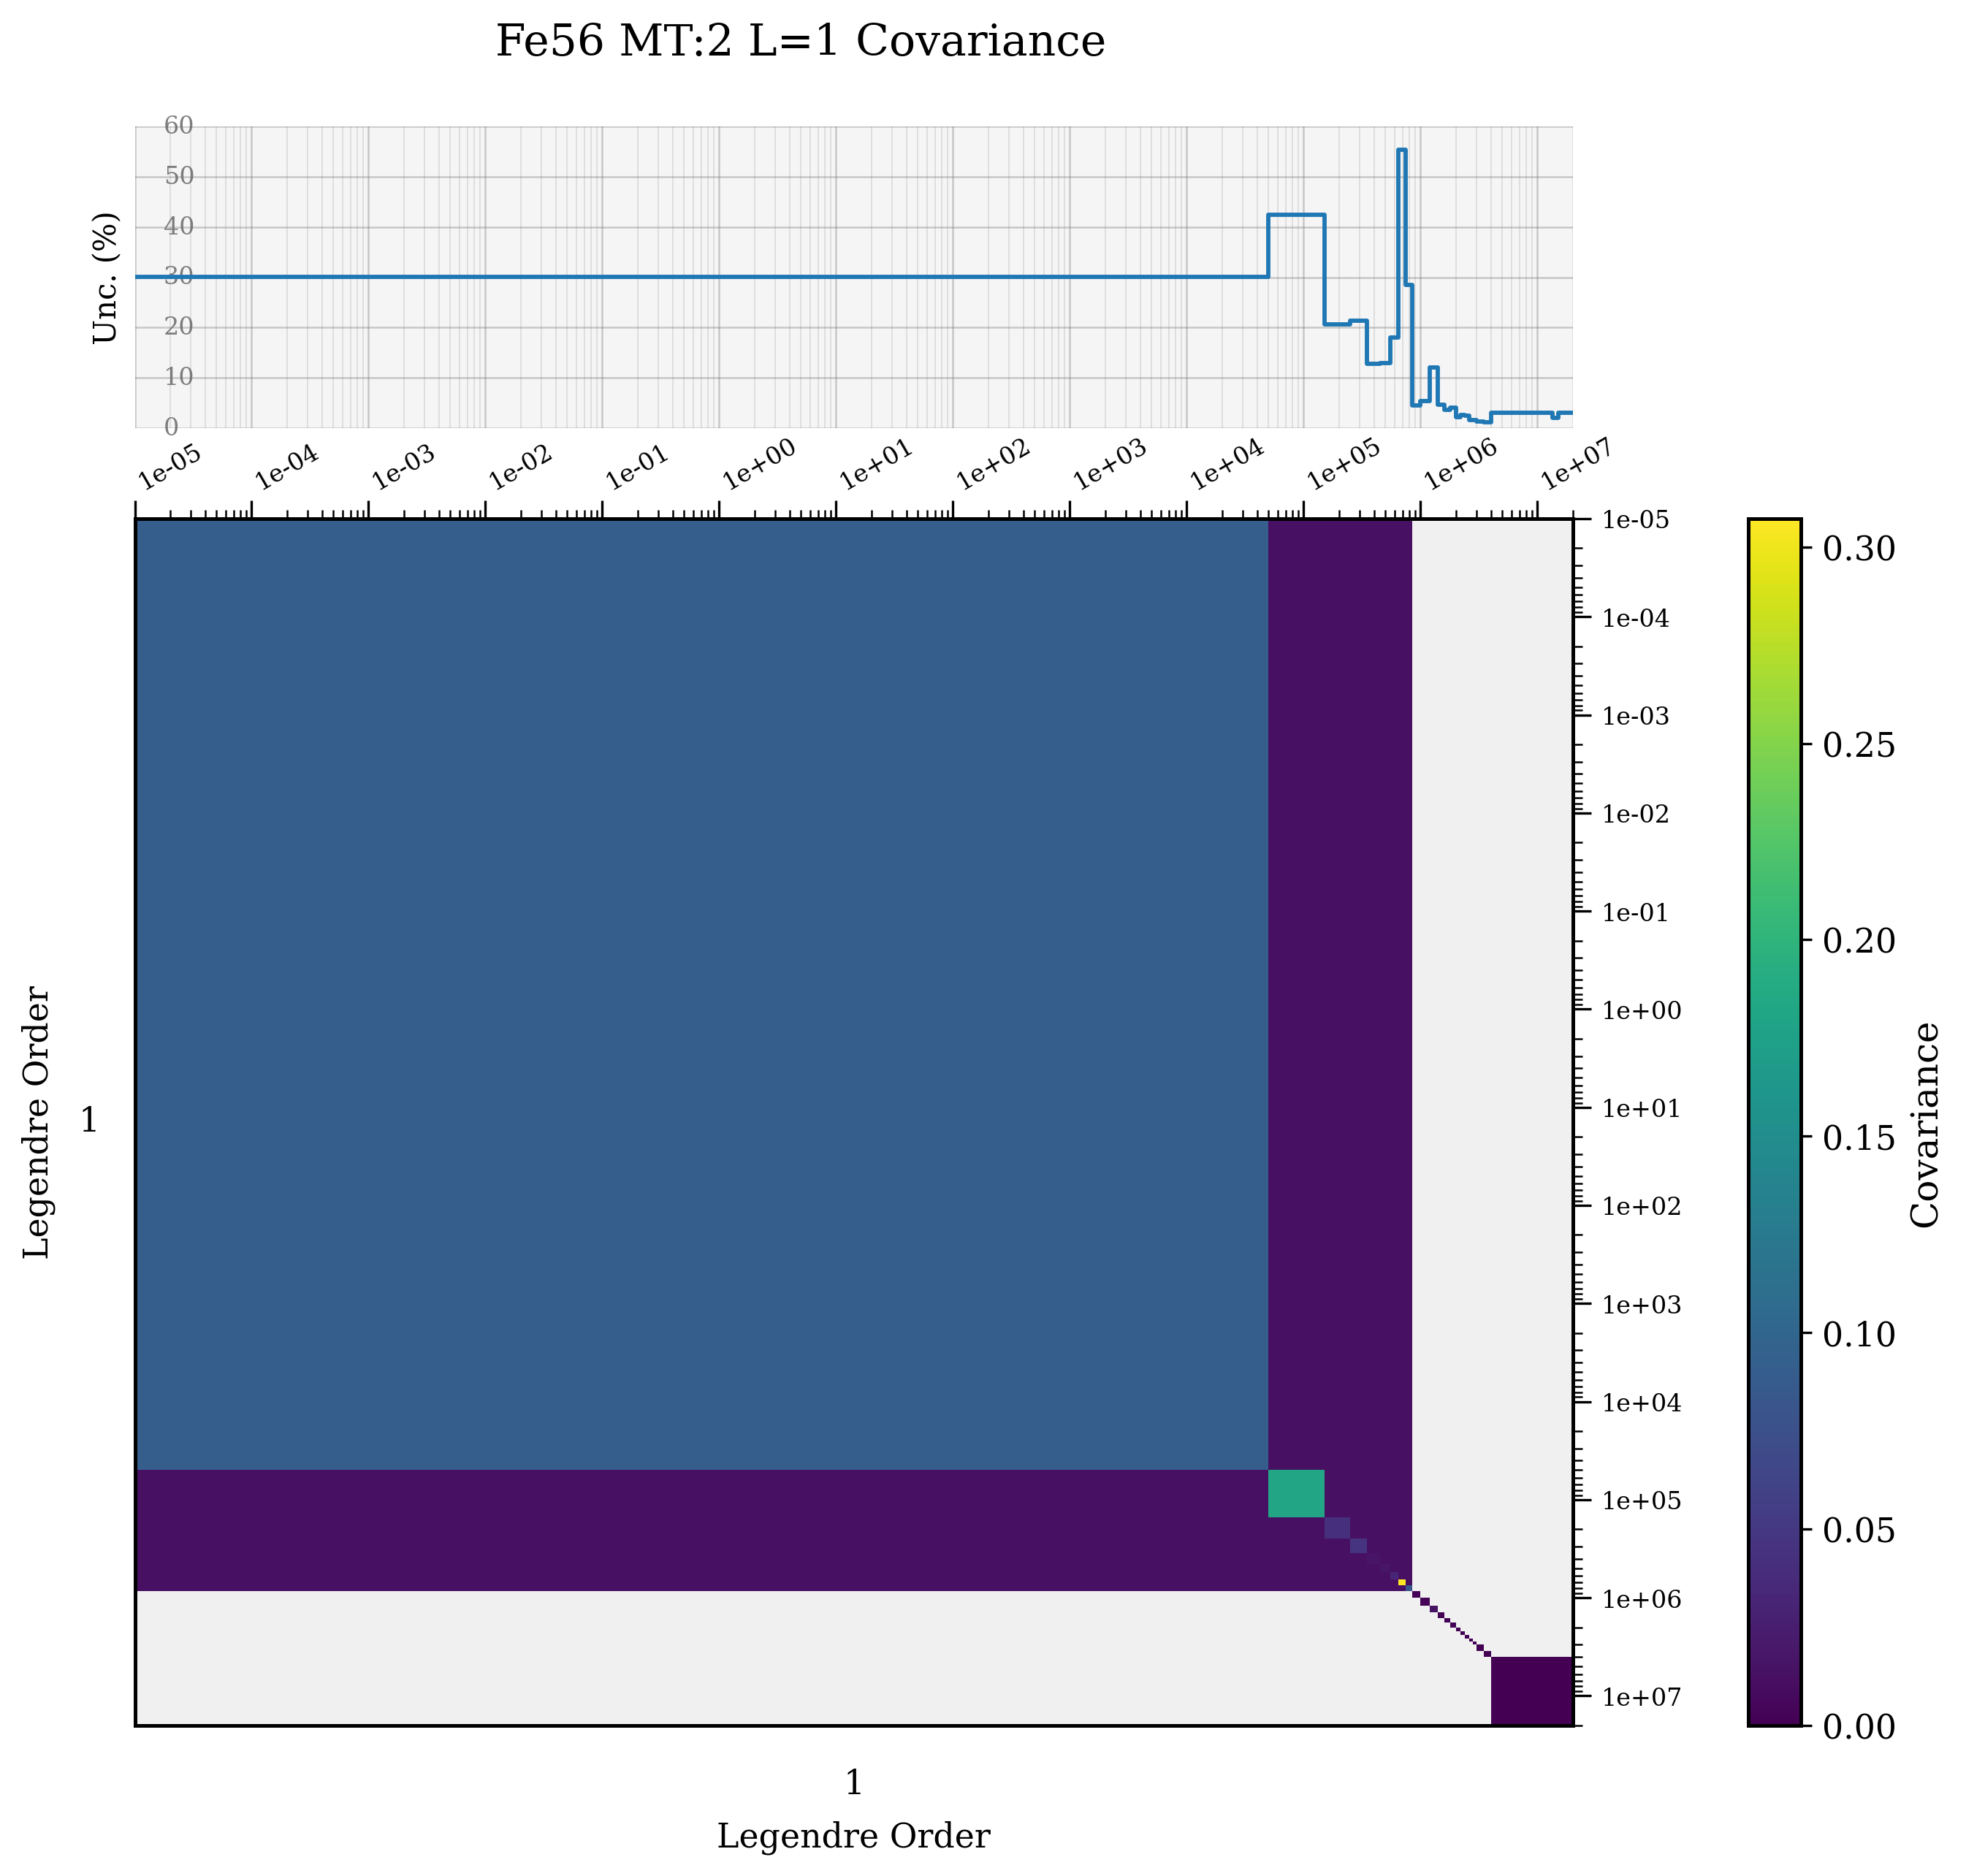

In [25]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    matrix_type="covariance",  # Full spelling
    show_uncertainties=True,
)
print(f"✓ Test 2.2 passed: Single Legendre L={mf34_test_legendre[0]}, covariance")

## Test 2.3: Single Legendre - Linear Scale

✓ Test 2.3 passed: Single Legendre, linear scale


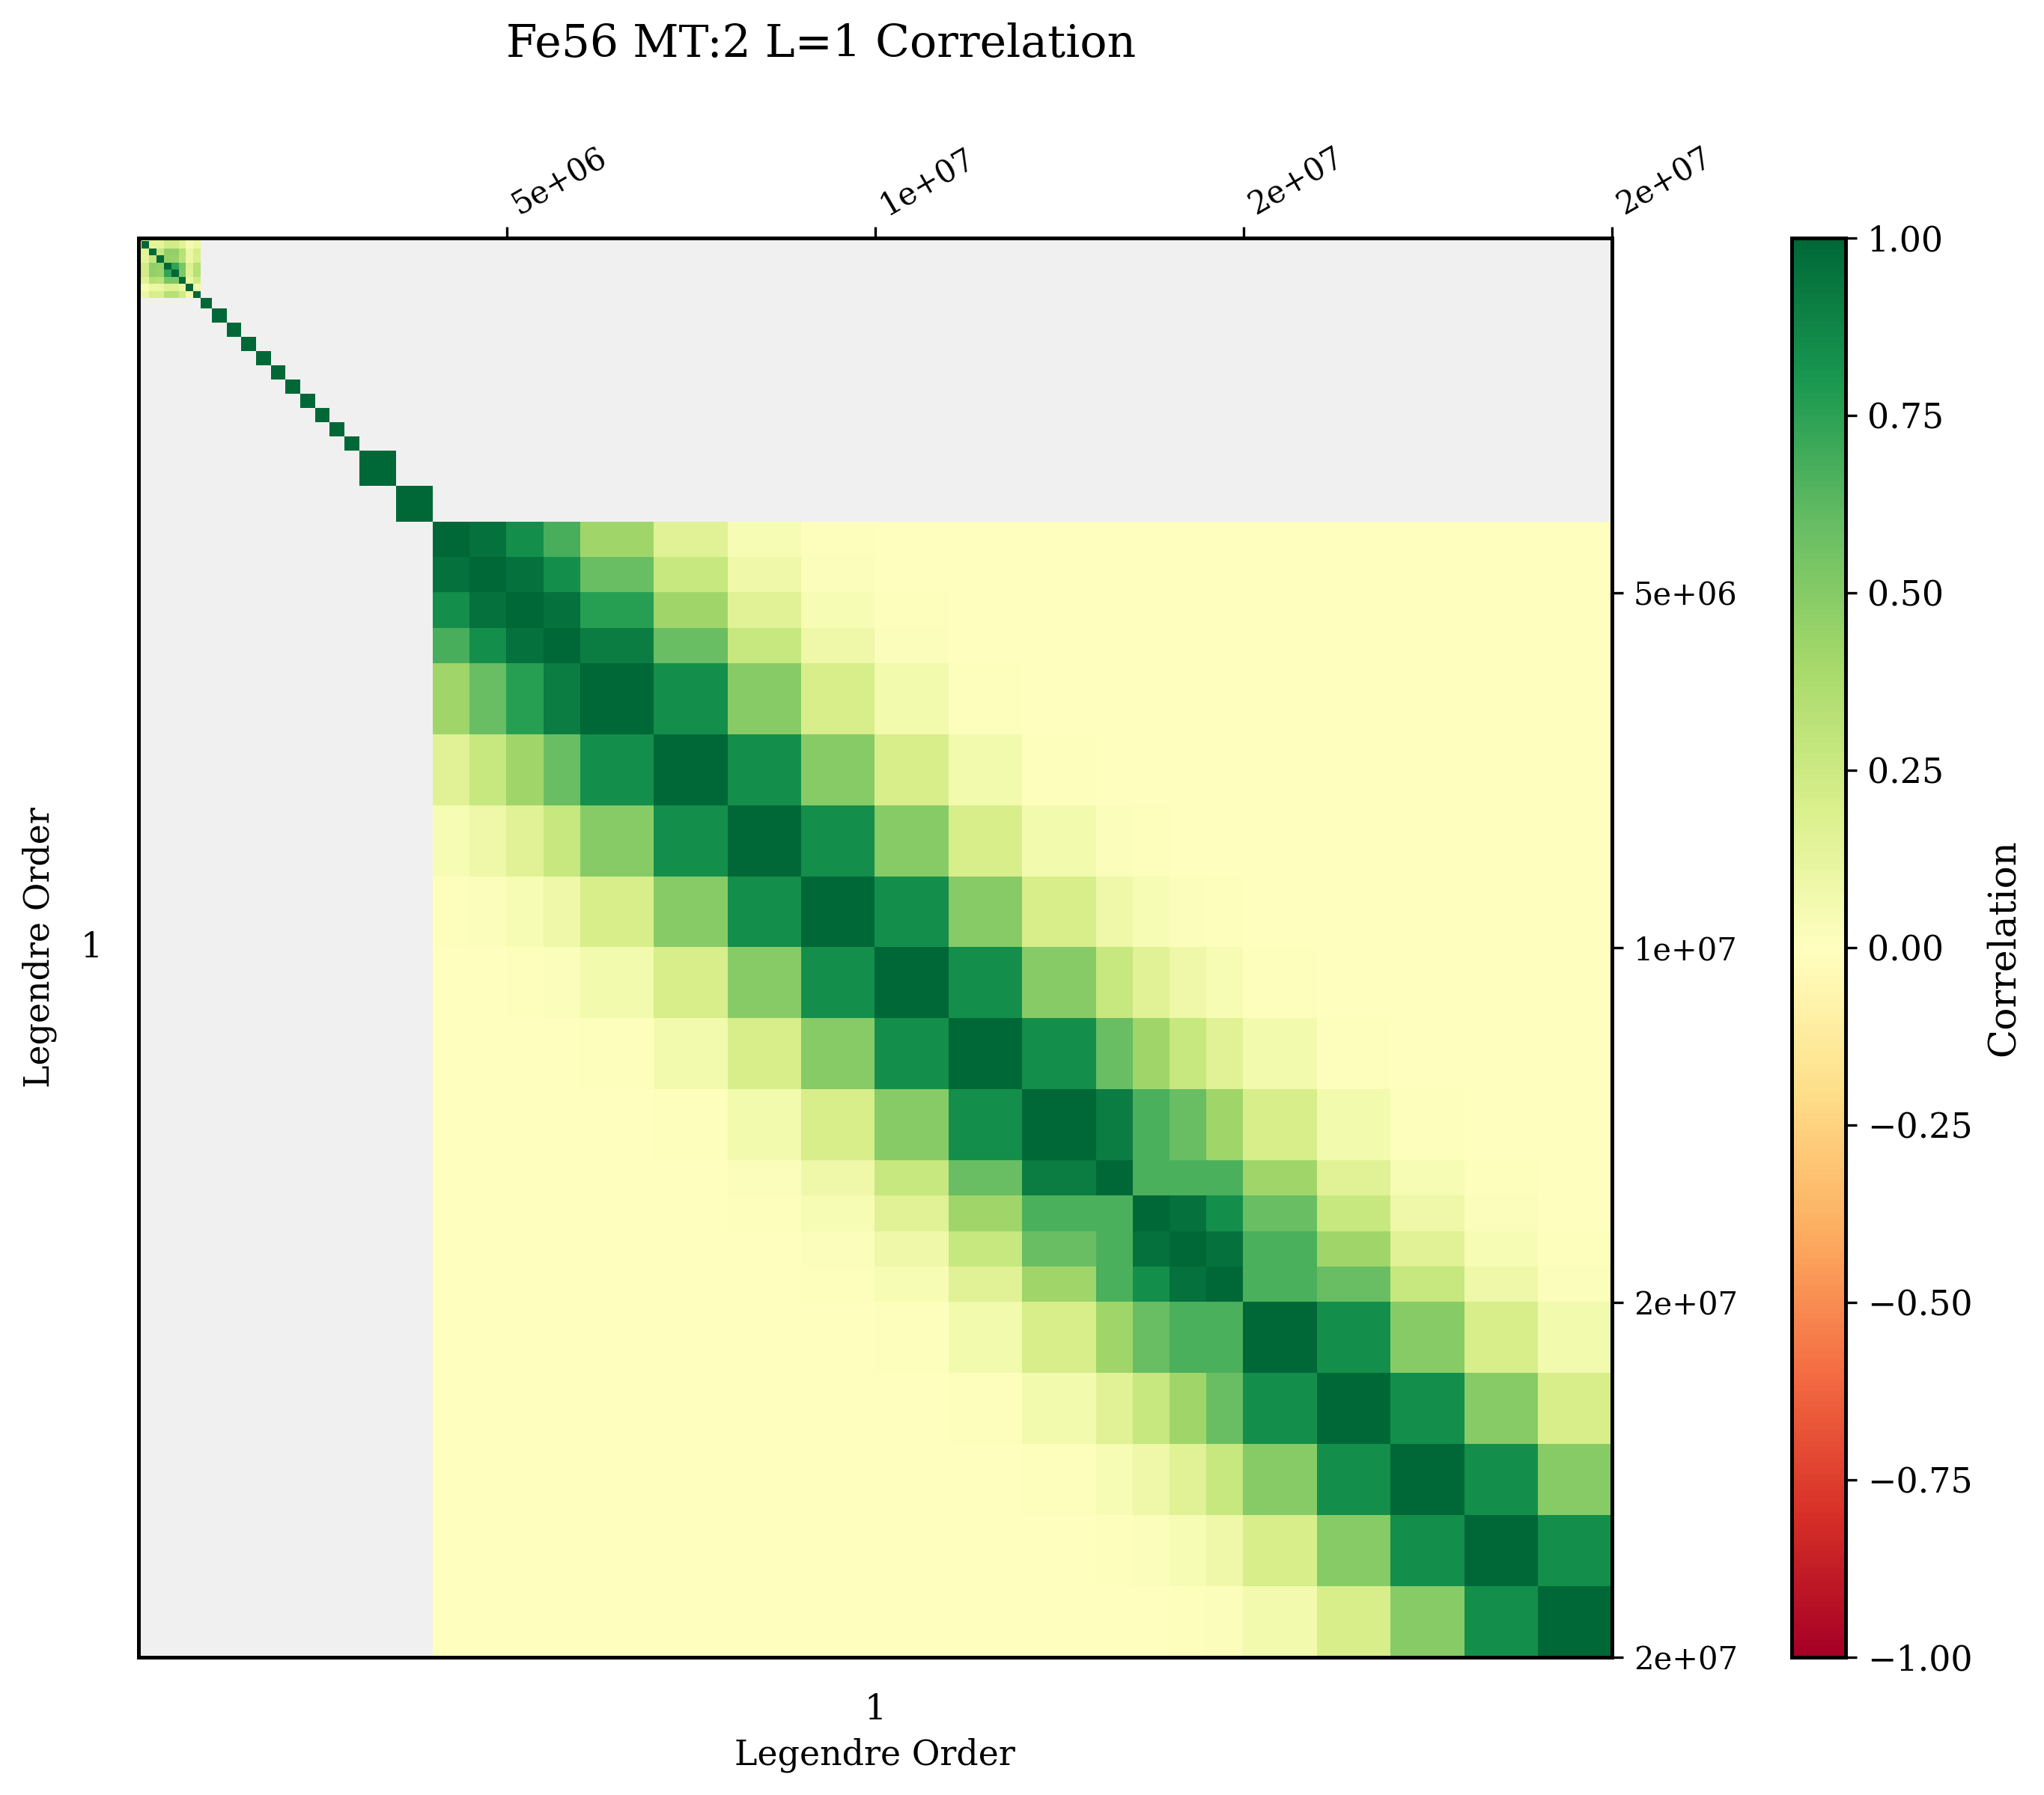

In [26]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    scale="linear",
)
print(f"✓ Test 2.3 passed: Single Legendre, linear scale")

## Test 2.4: Single Legendre - Without Uncertainties

✓ Test 2.4 passed: Single Legendre without uncertainties


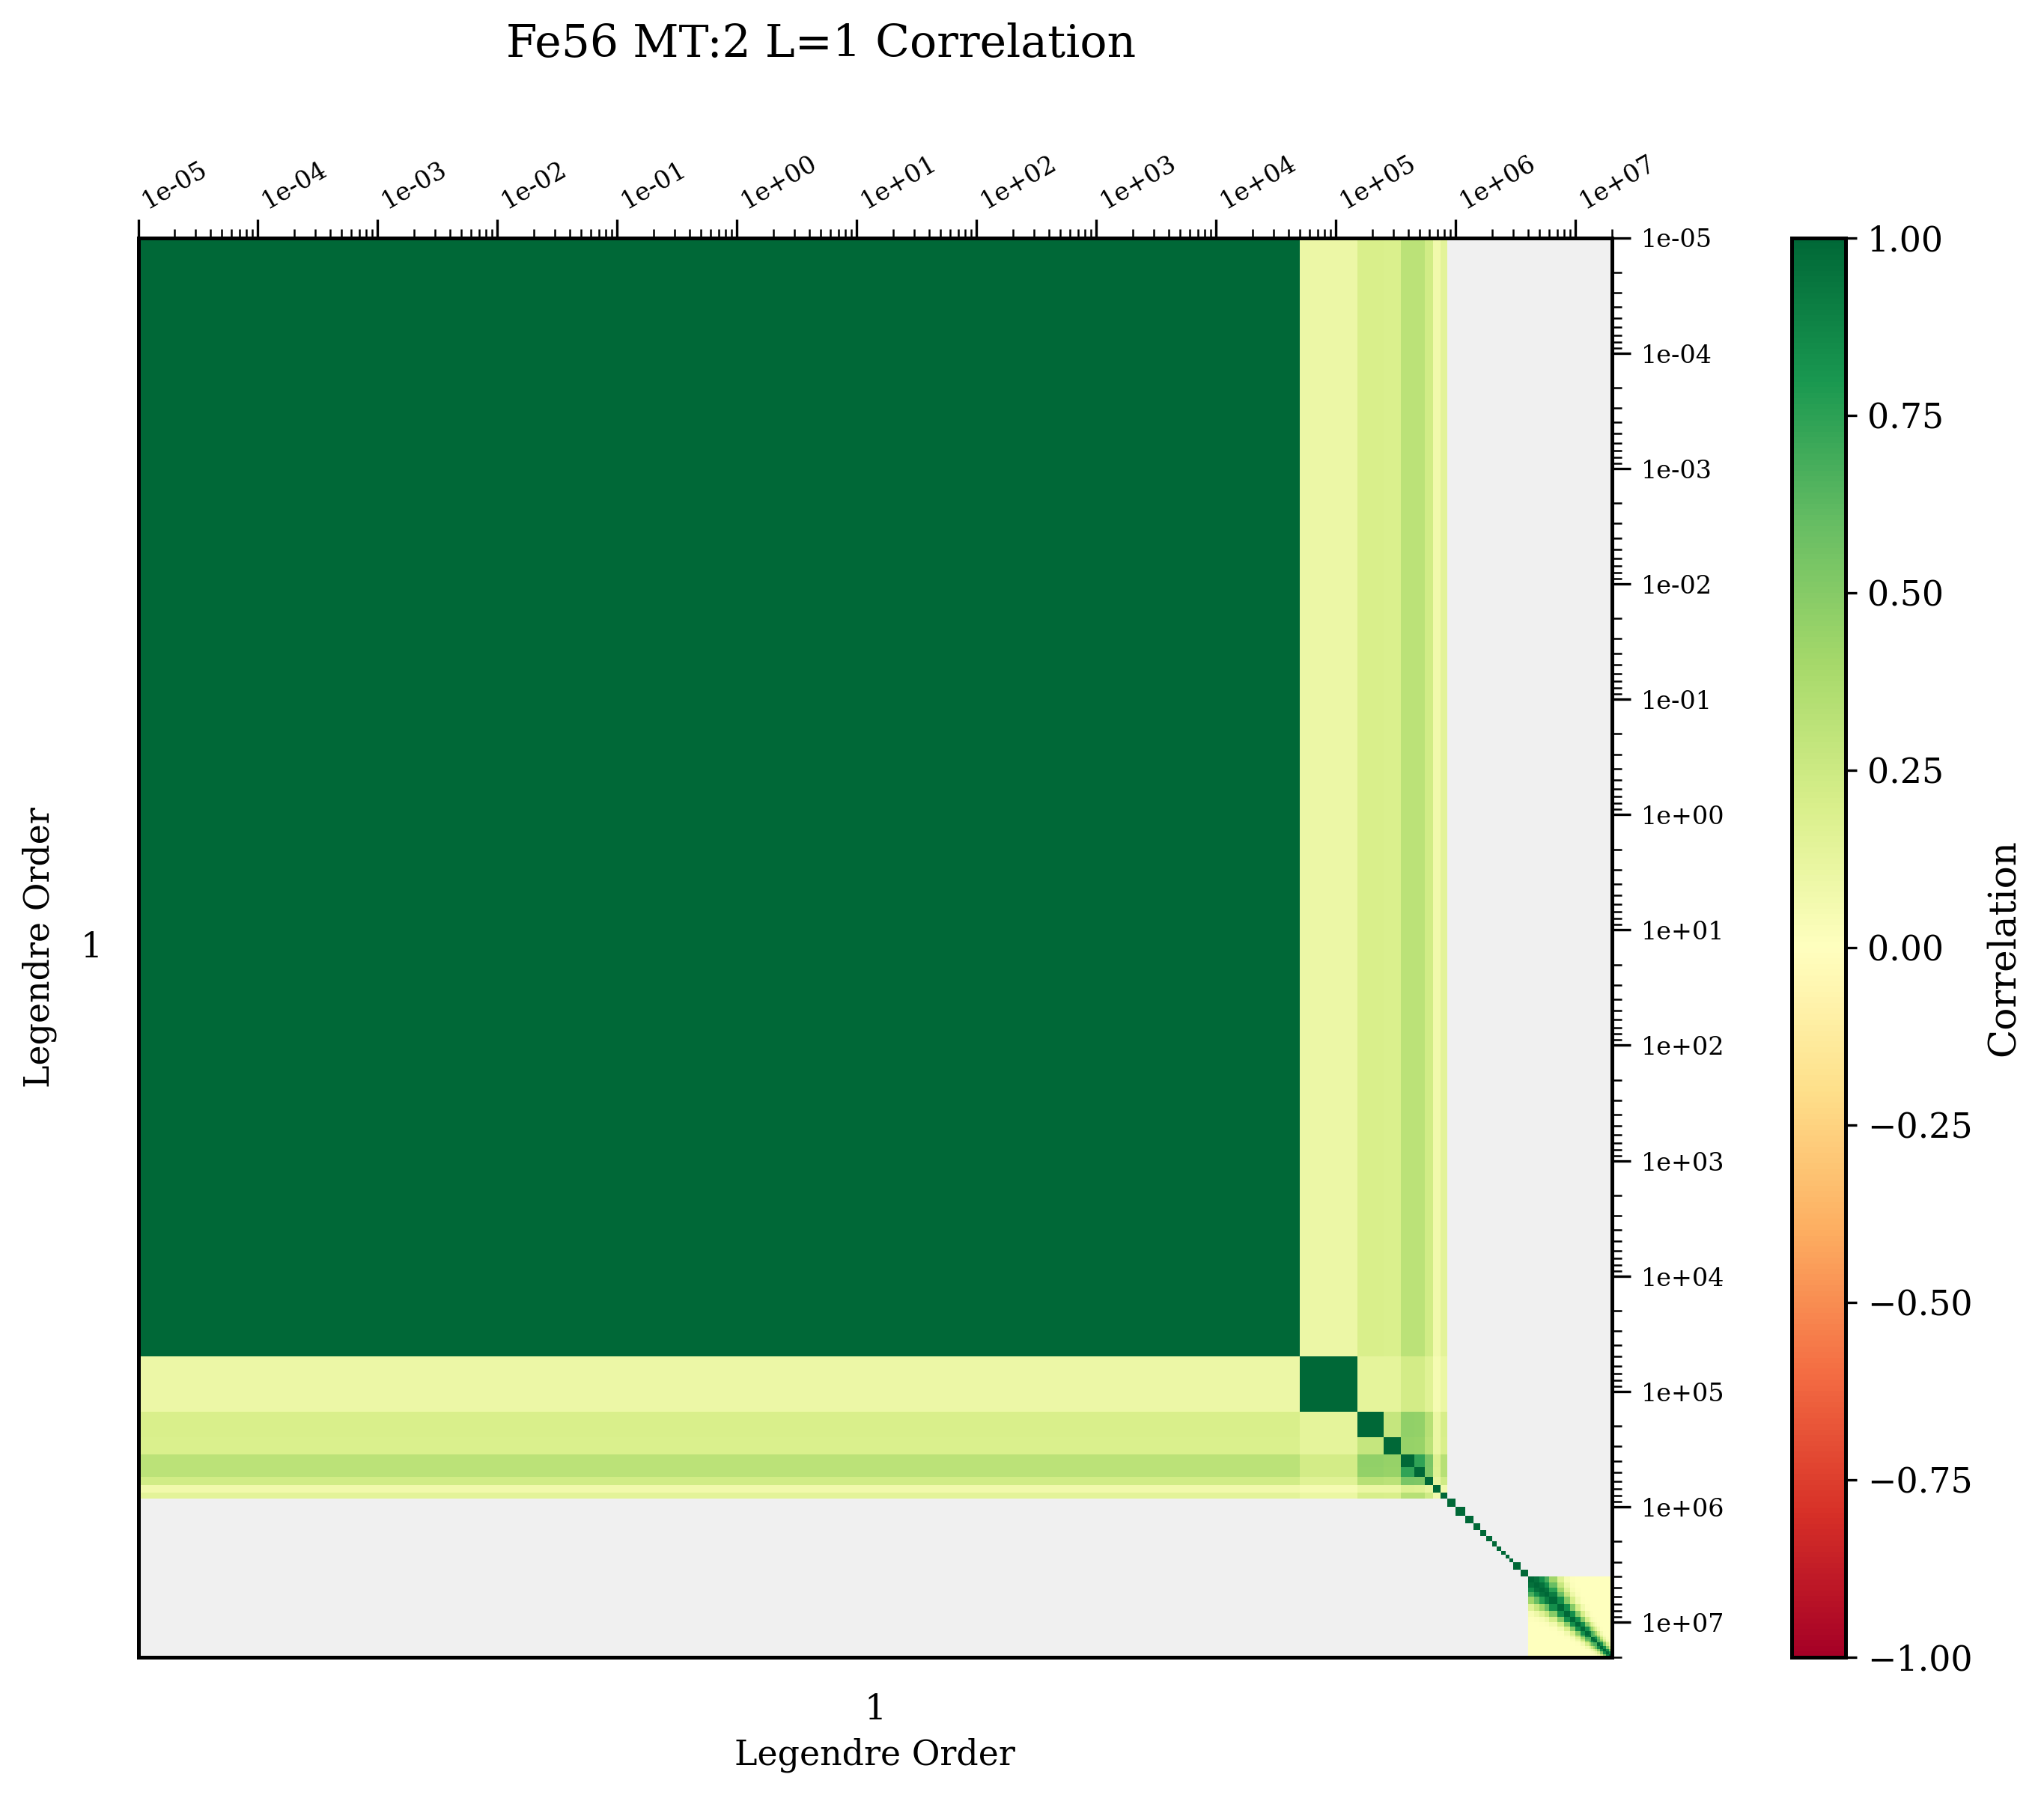

In [27]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    show_uncertainties=False,
)
print(f"✓ Test 2.4 passed: Single Legendre without uncertainties")

## Test 2.5: Single Legendre - Energy Range Filtering

✓ Test 2.5 passed: Single Legendre with energy filtering


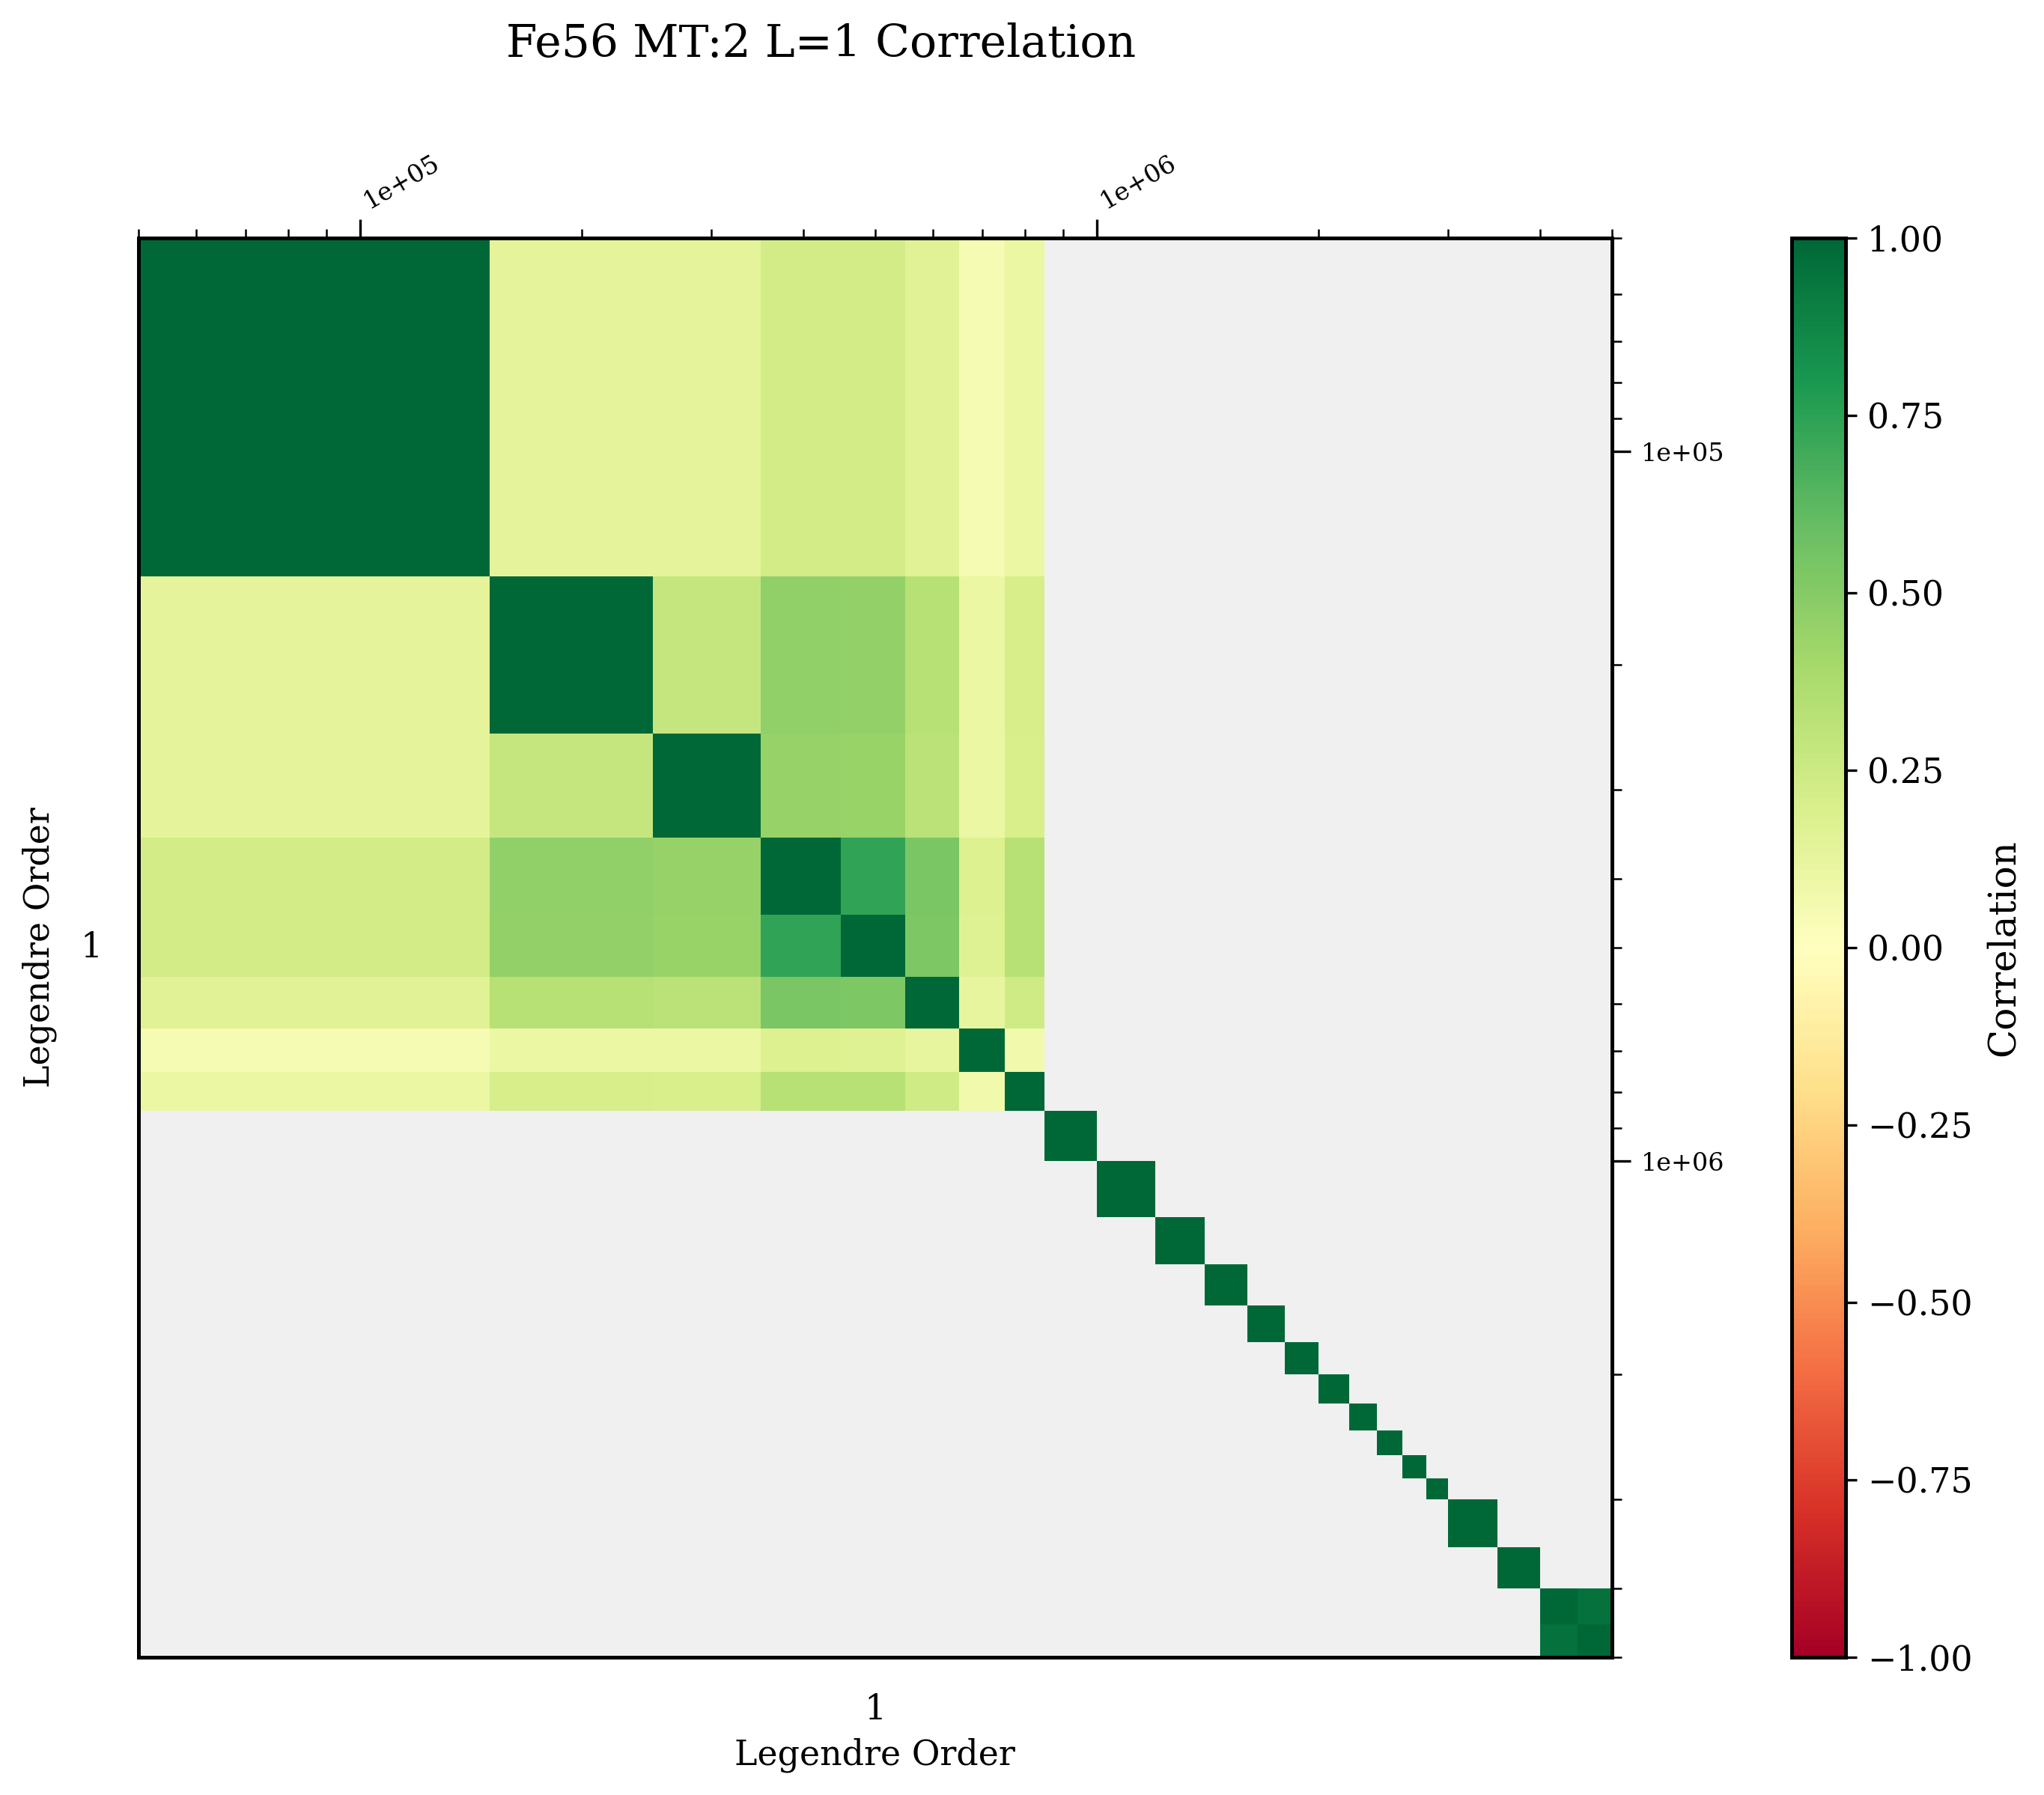

In [28]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    energy_range=(1e5, 5e6),  # 100 keV - 5 MeV
)
print(f"✓ Test 2.5 passed: Single Legendre with energy filtering")

## Test 2.6: Single Legendre - Custom Title

✓ Test 2.6 passed: Single Legendre with custom title


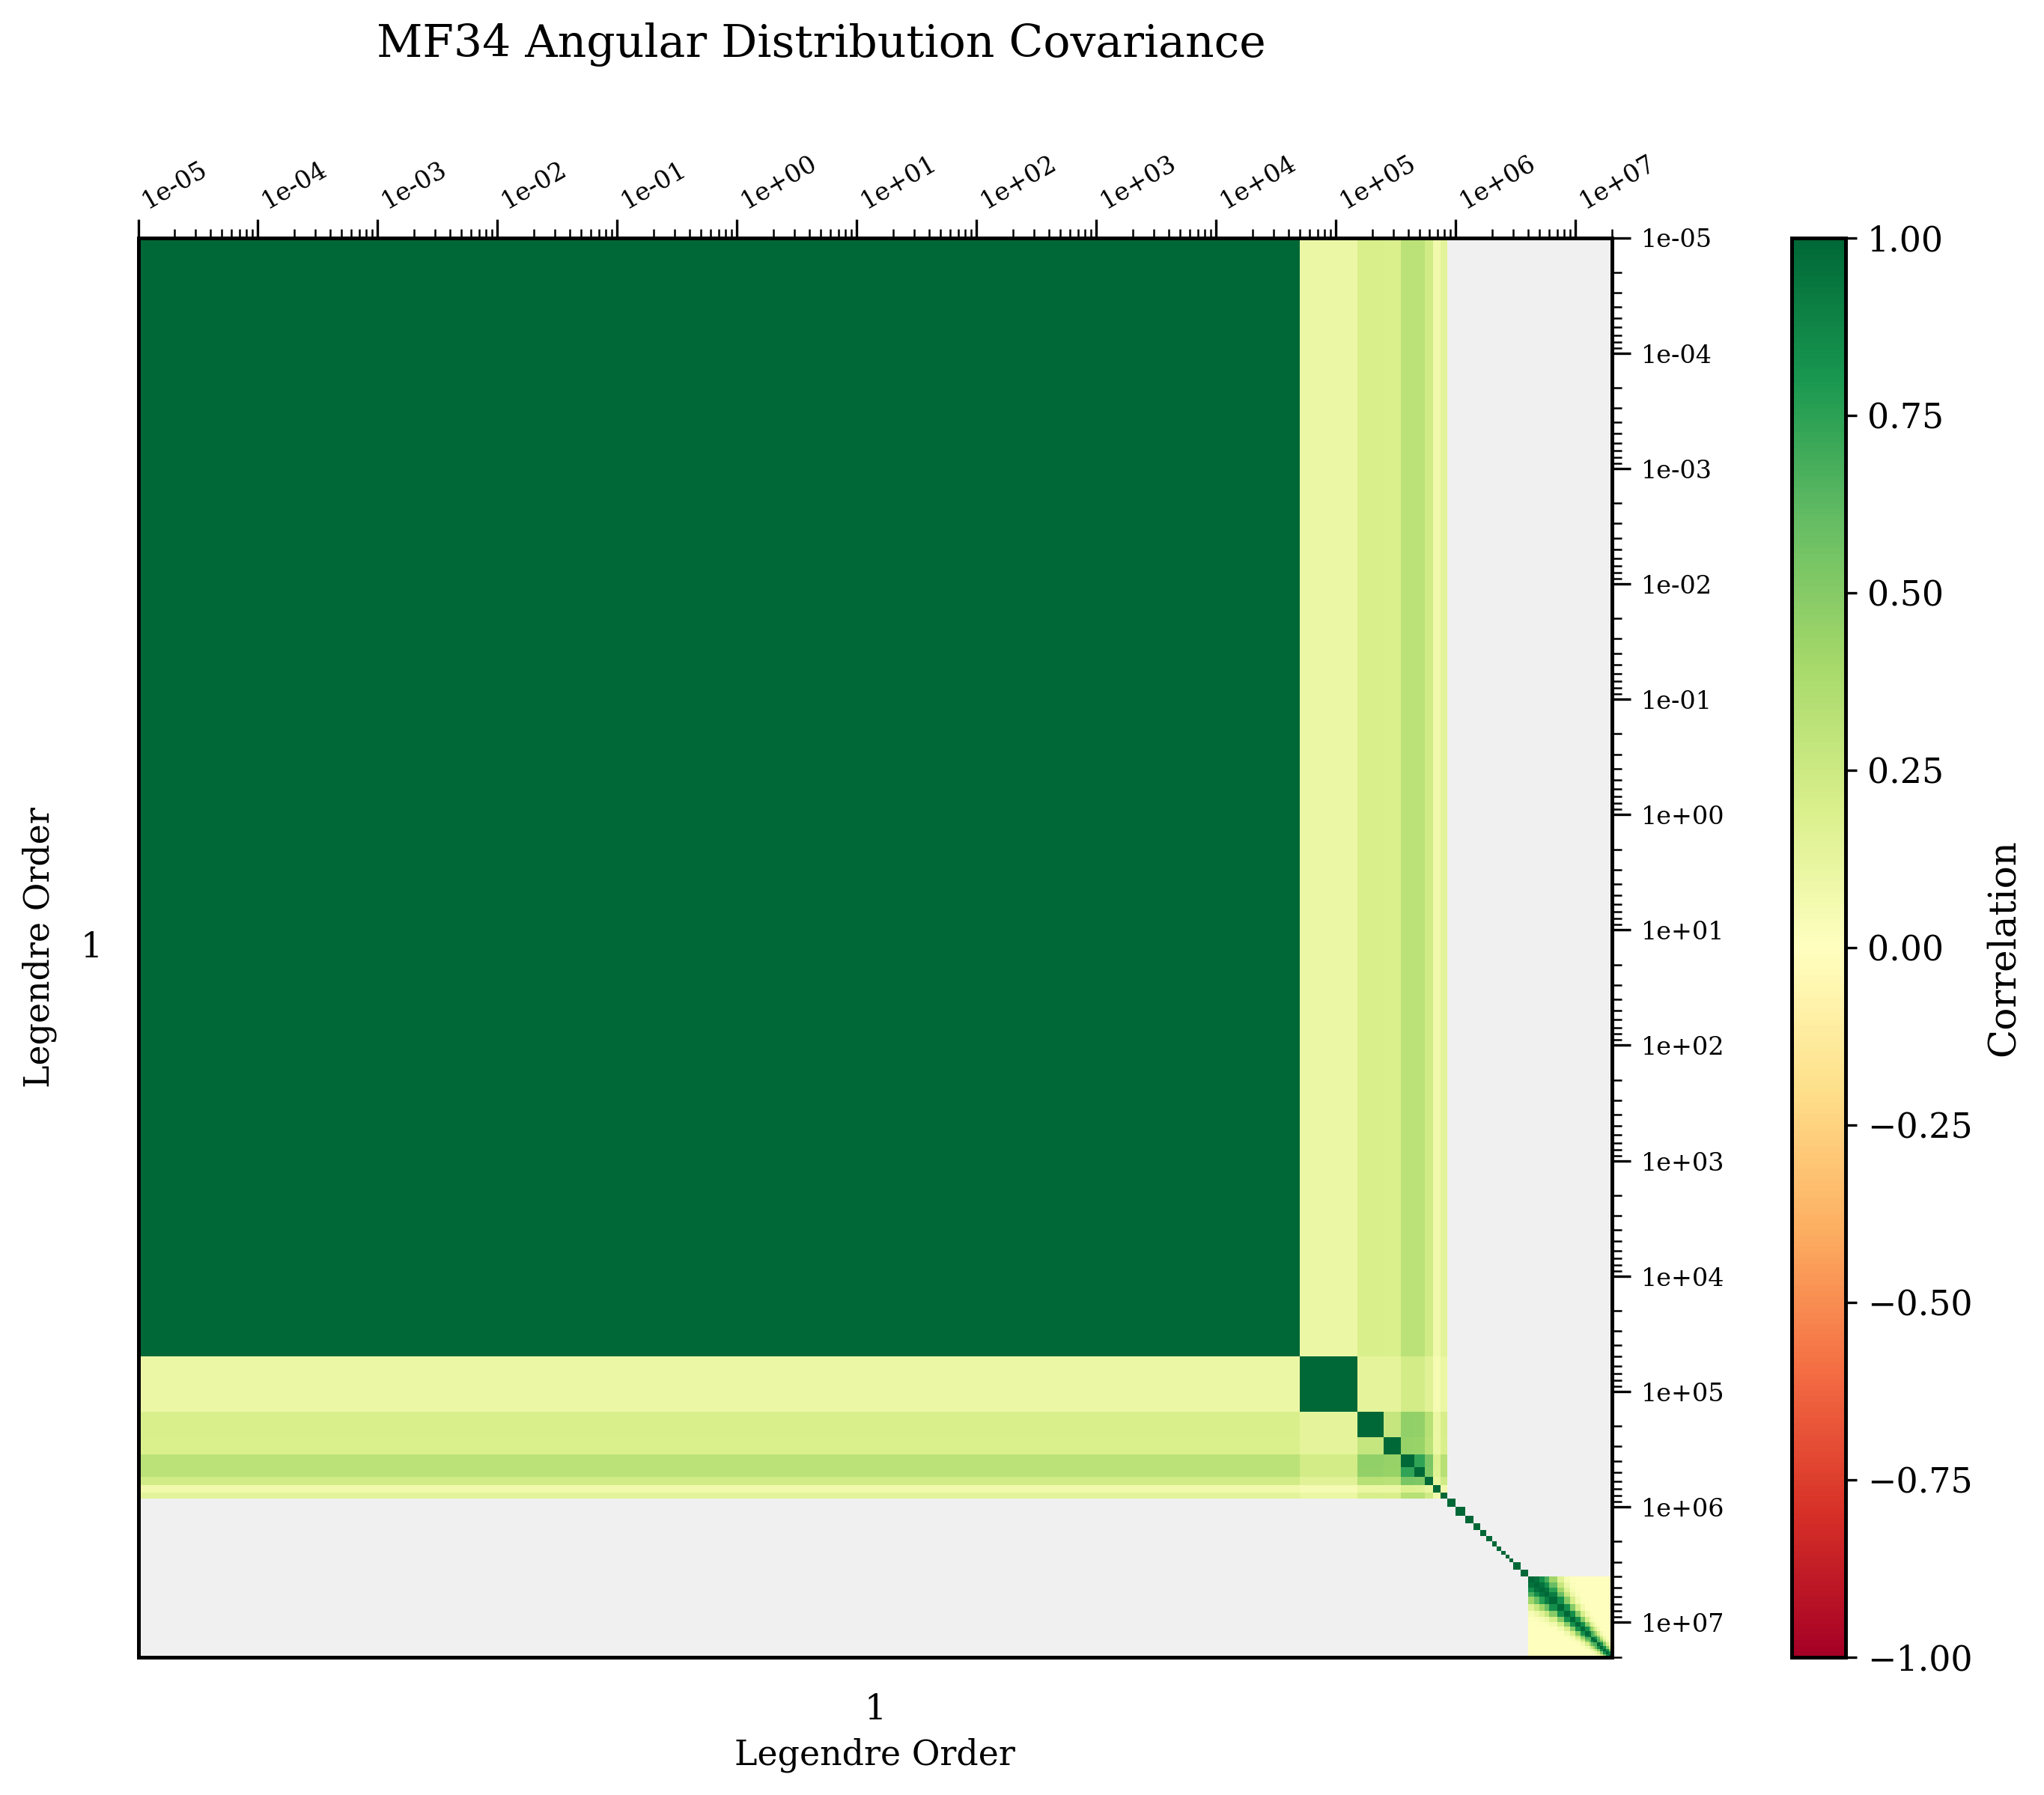

In [29]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    title="MF34 Angular Distribution Covariance",
)
print(f"✓ Test 2.6 passed: Single Legendre with custom title")

## Test 2.7: Single Legendre - No Title

✓ Test 2.7 passed: Single Legendre without title


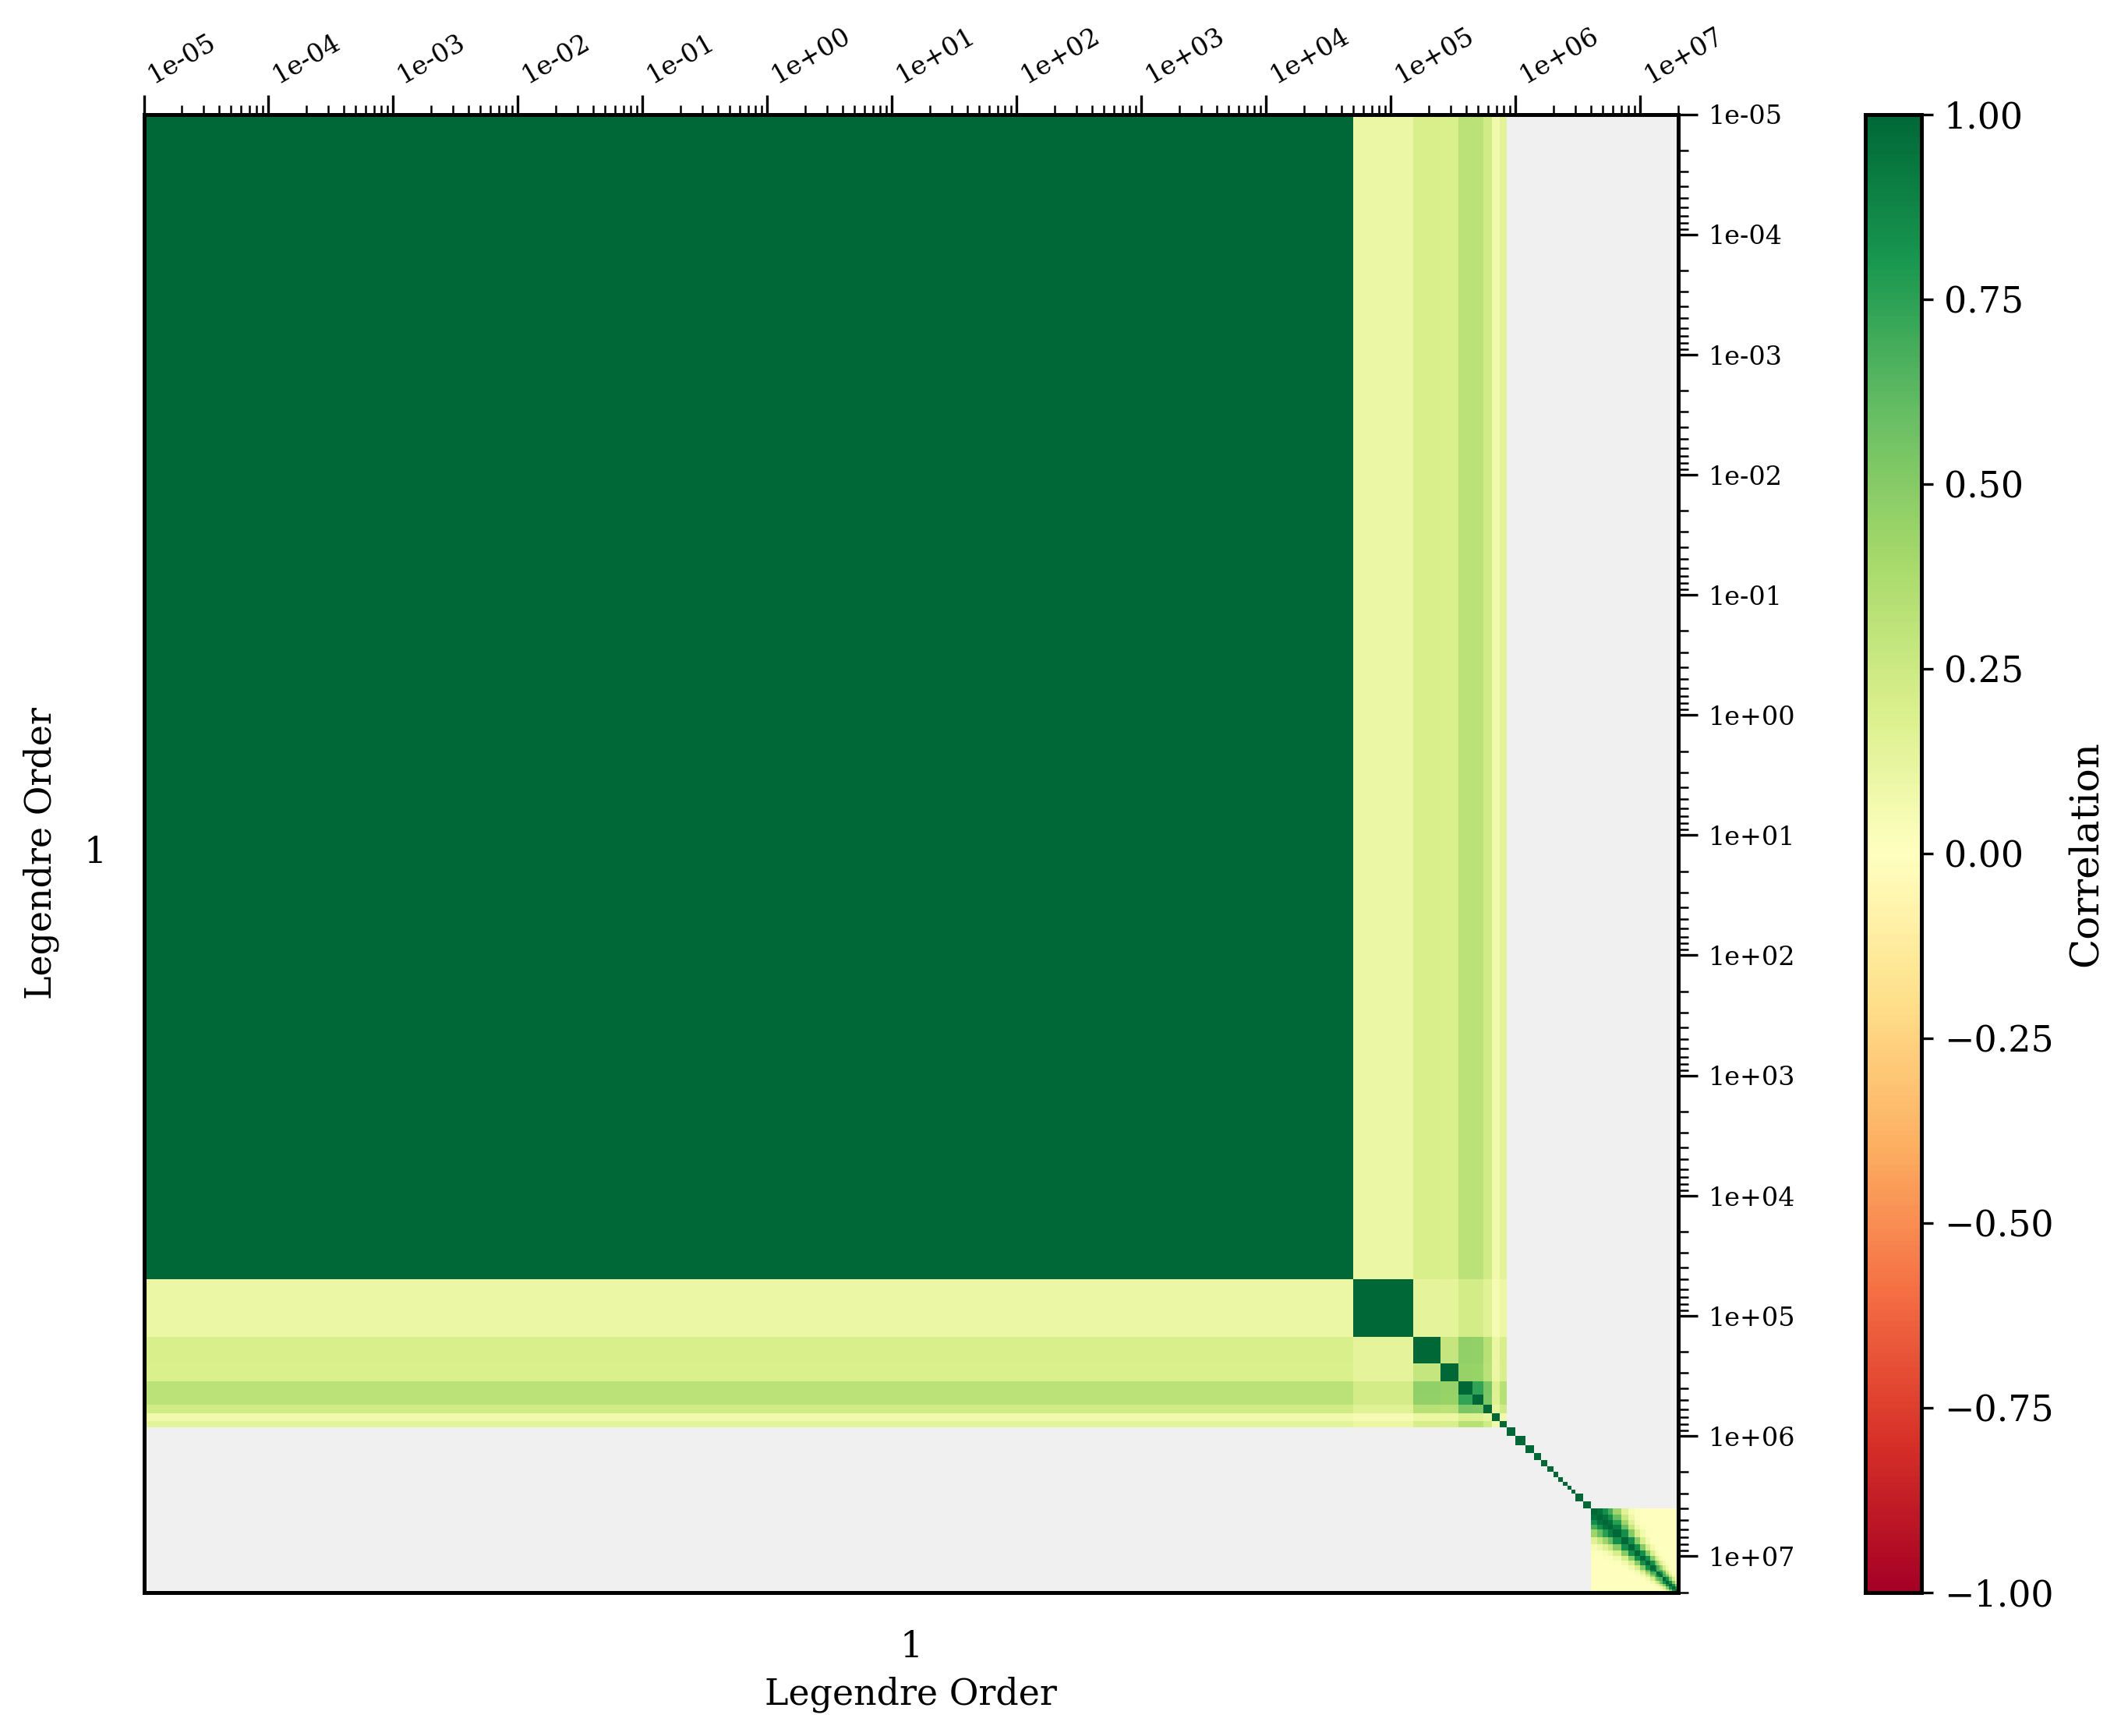

In [30]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    title=None,
)
print(f"✓ Test 2.7 passed: Single Legendre without title")

## Test 2.8: Multiple Legendre Coefficients

✓ Test 2.8 passed: Multiple Legendre coefficients [1, 2, 3]


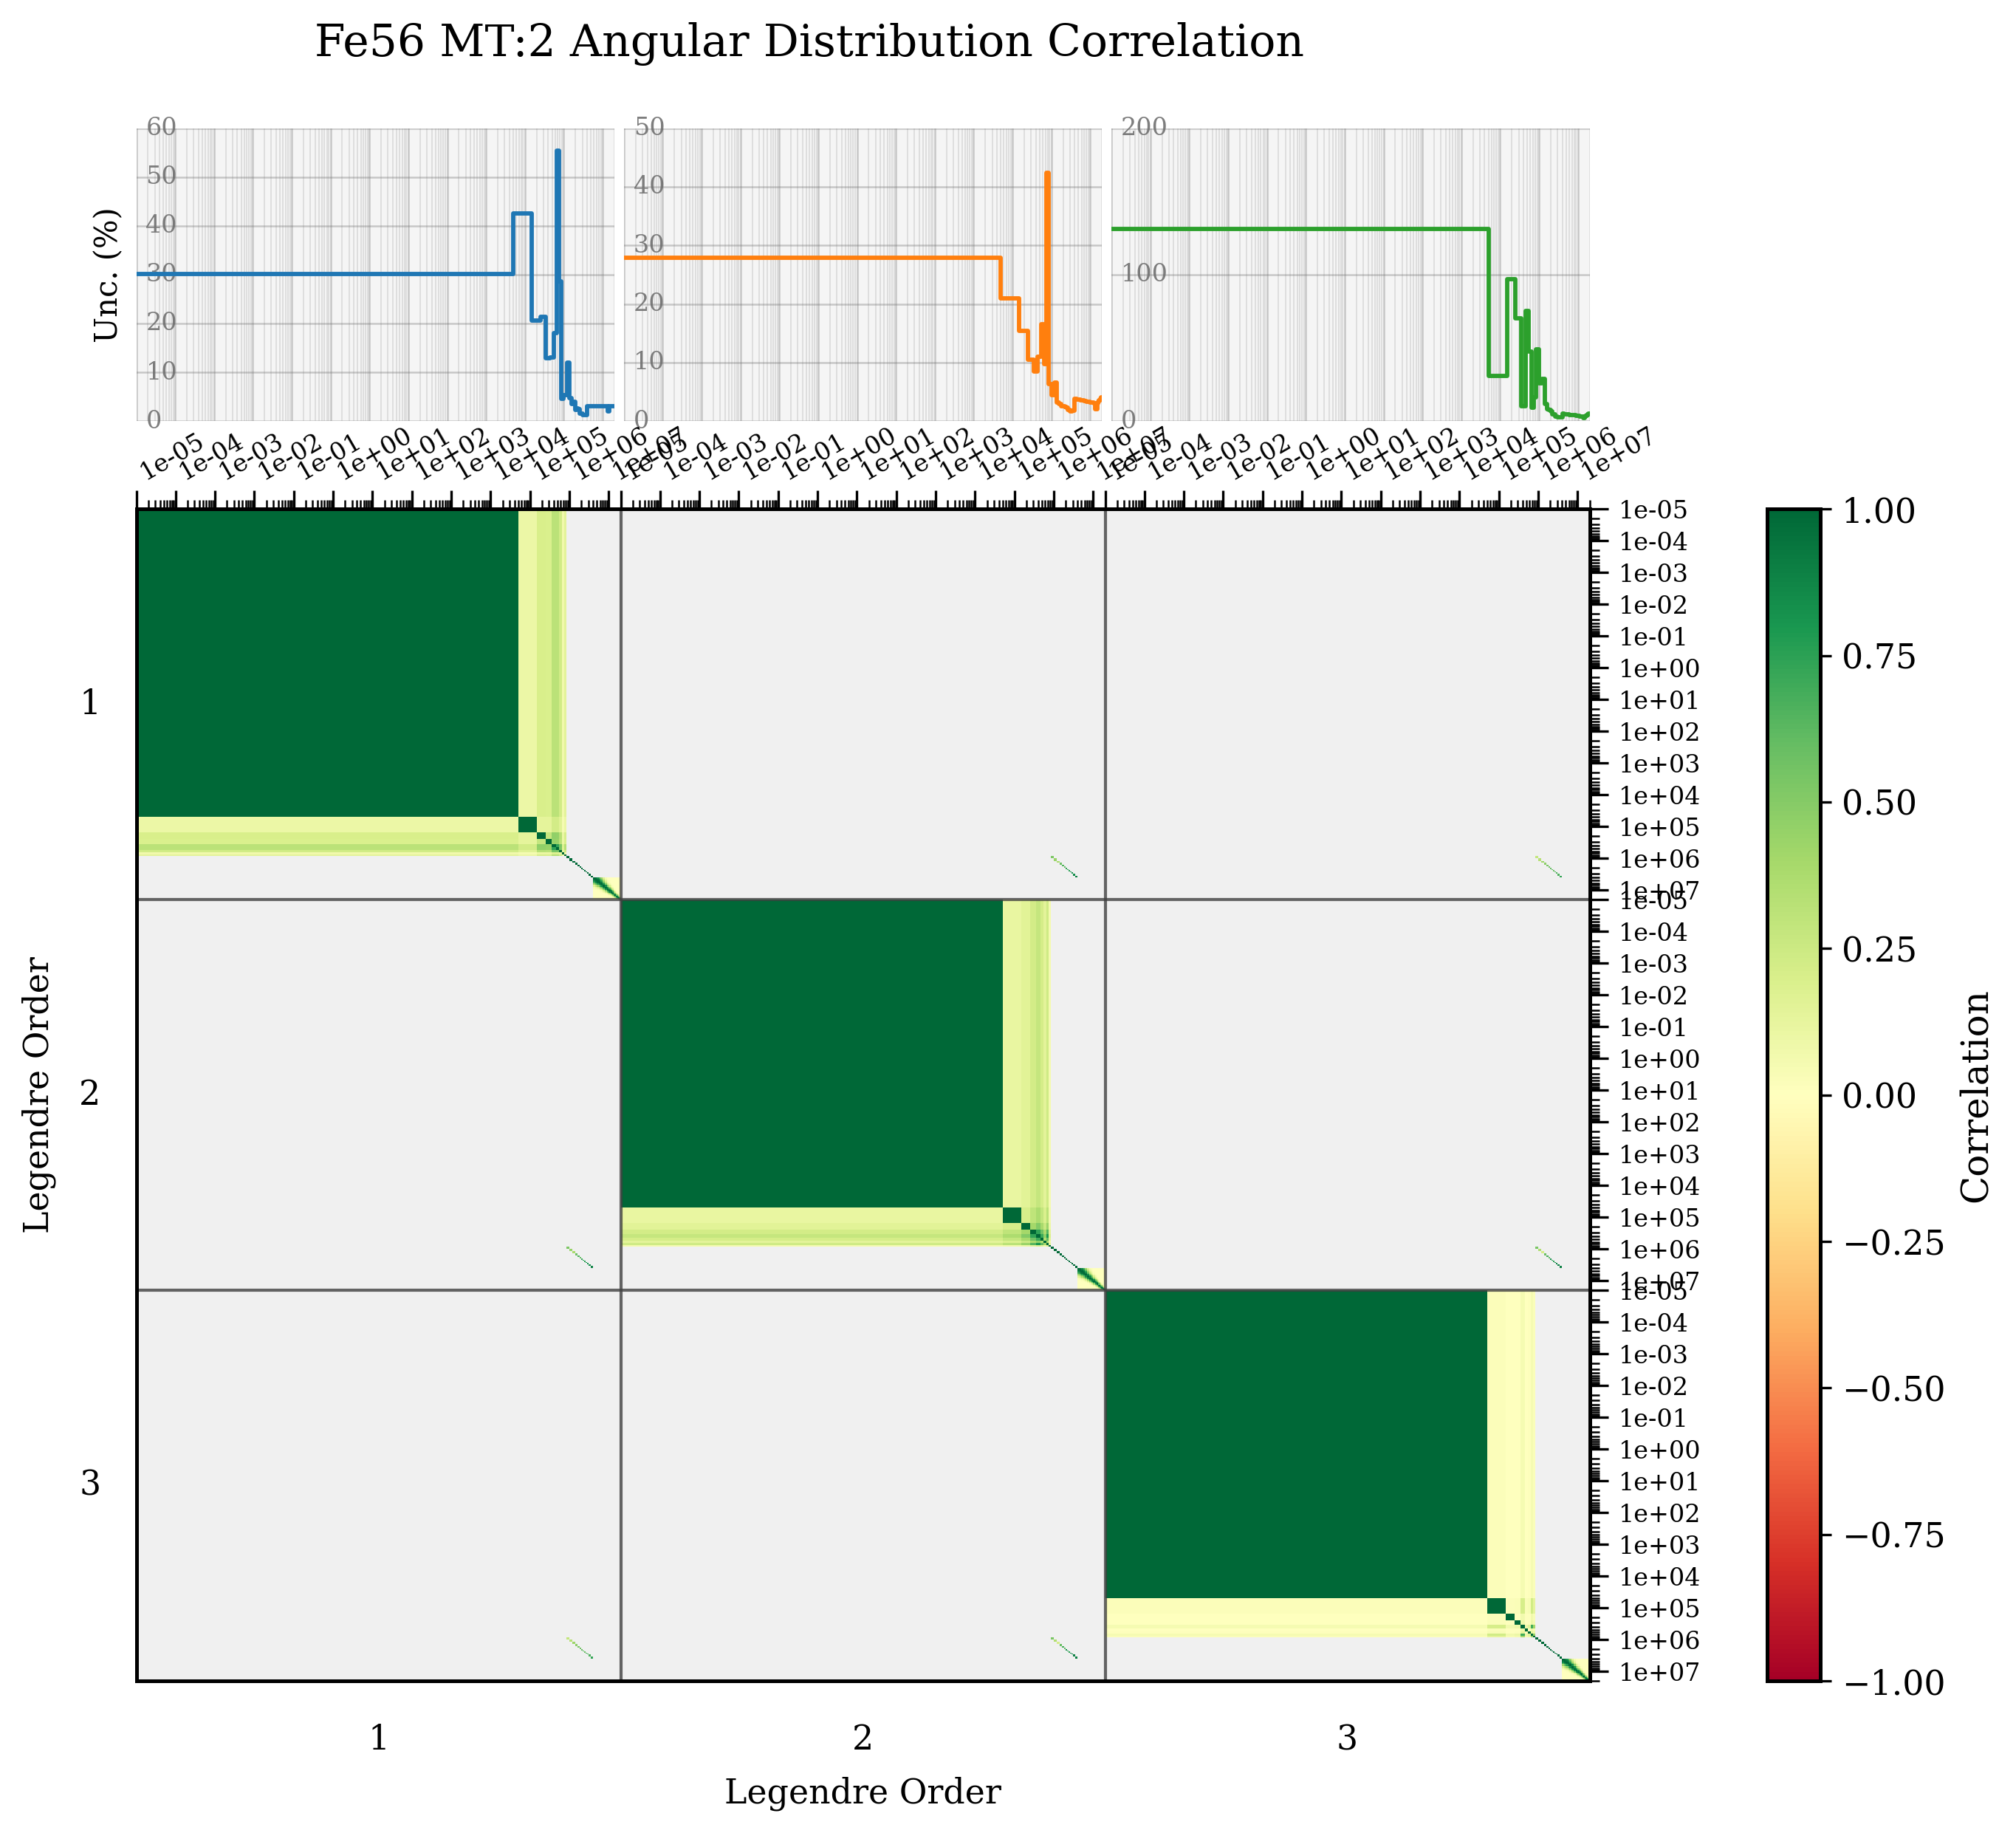

In [31]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre,  # Multiple L values
    show_uncertainties=True,
    show_block_labels=True,
)
print(f"✓ Test 2.8 passed: Multiple Legendre coefficients {mf34_test_legendre}")

## Test 2.9: Multiple Legendre - Covariance Matrix

✓ Test 2.9 passed: Multiple Legendre with covariance matrix


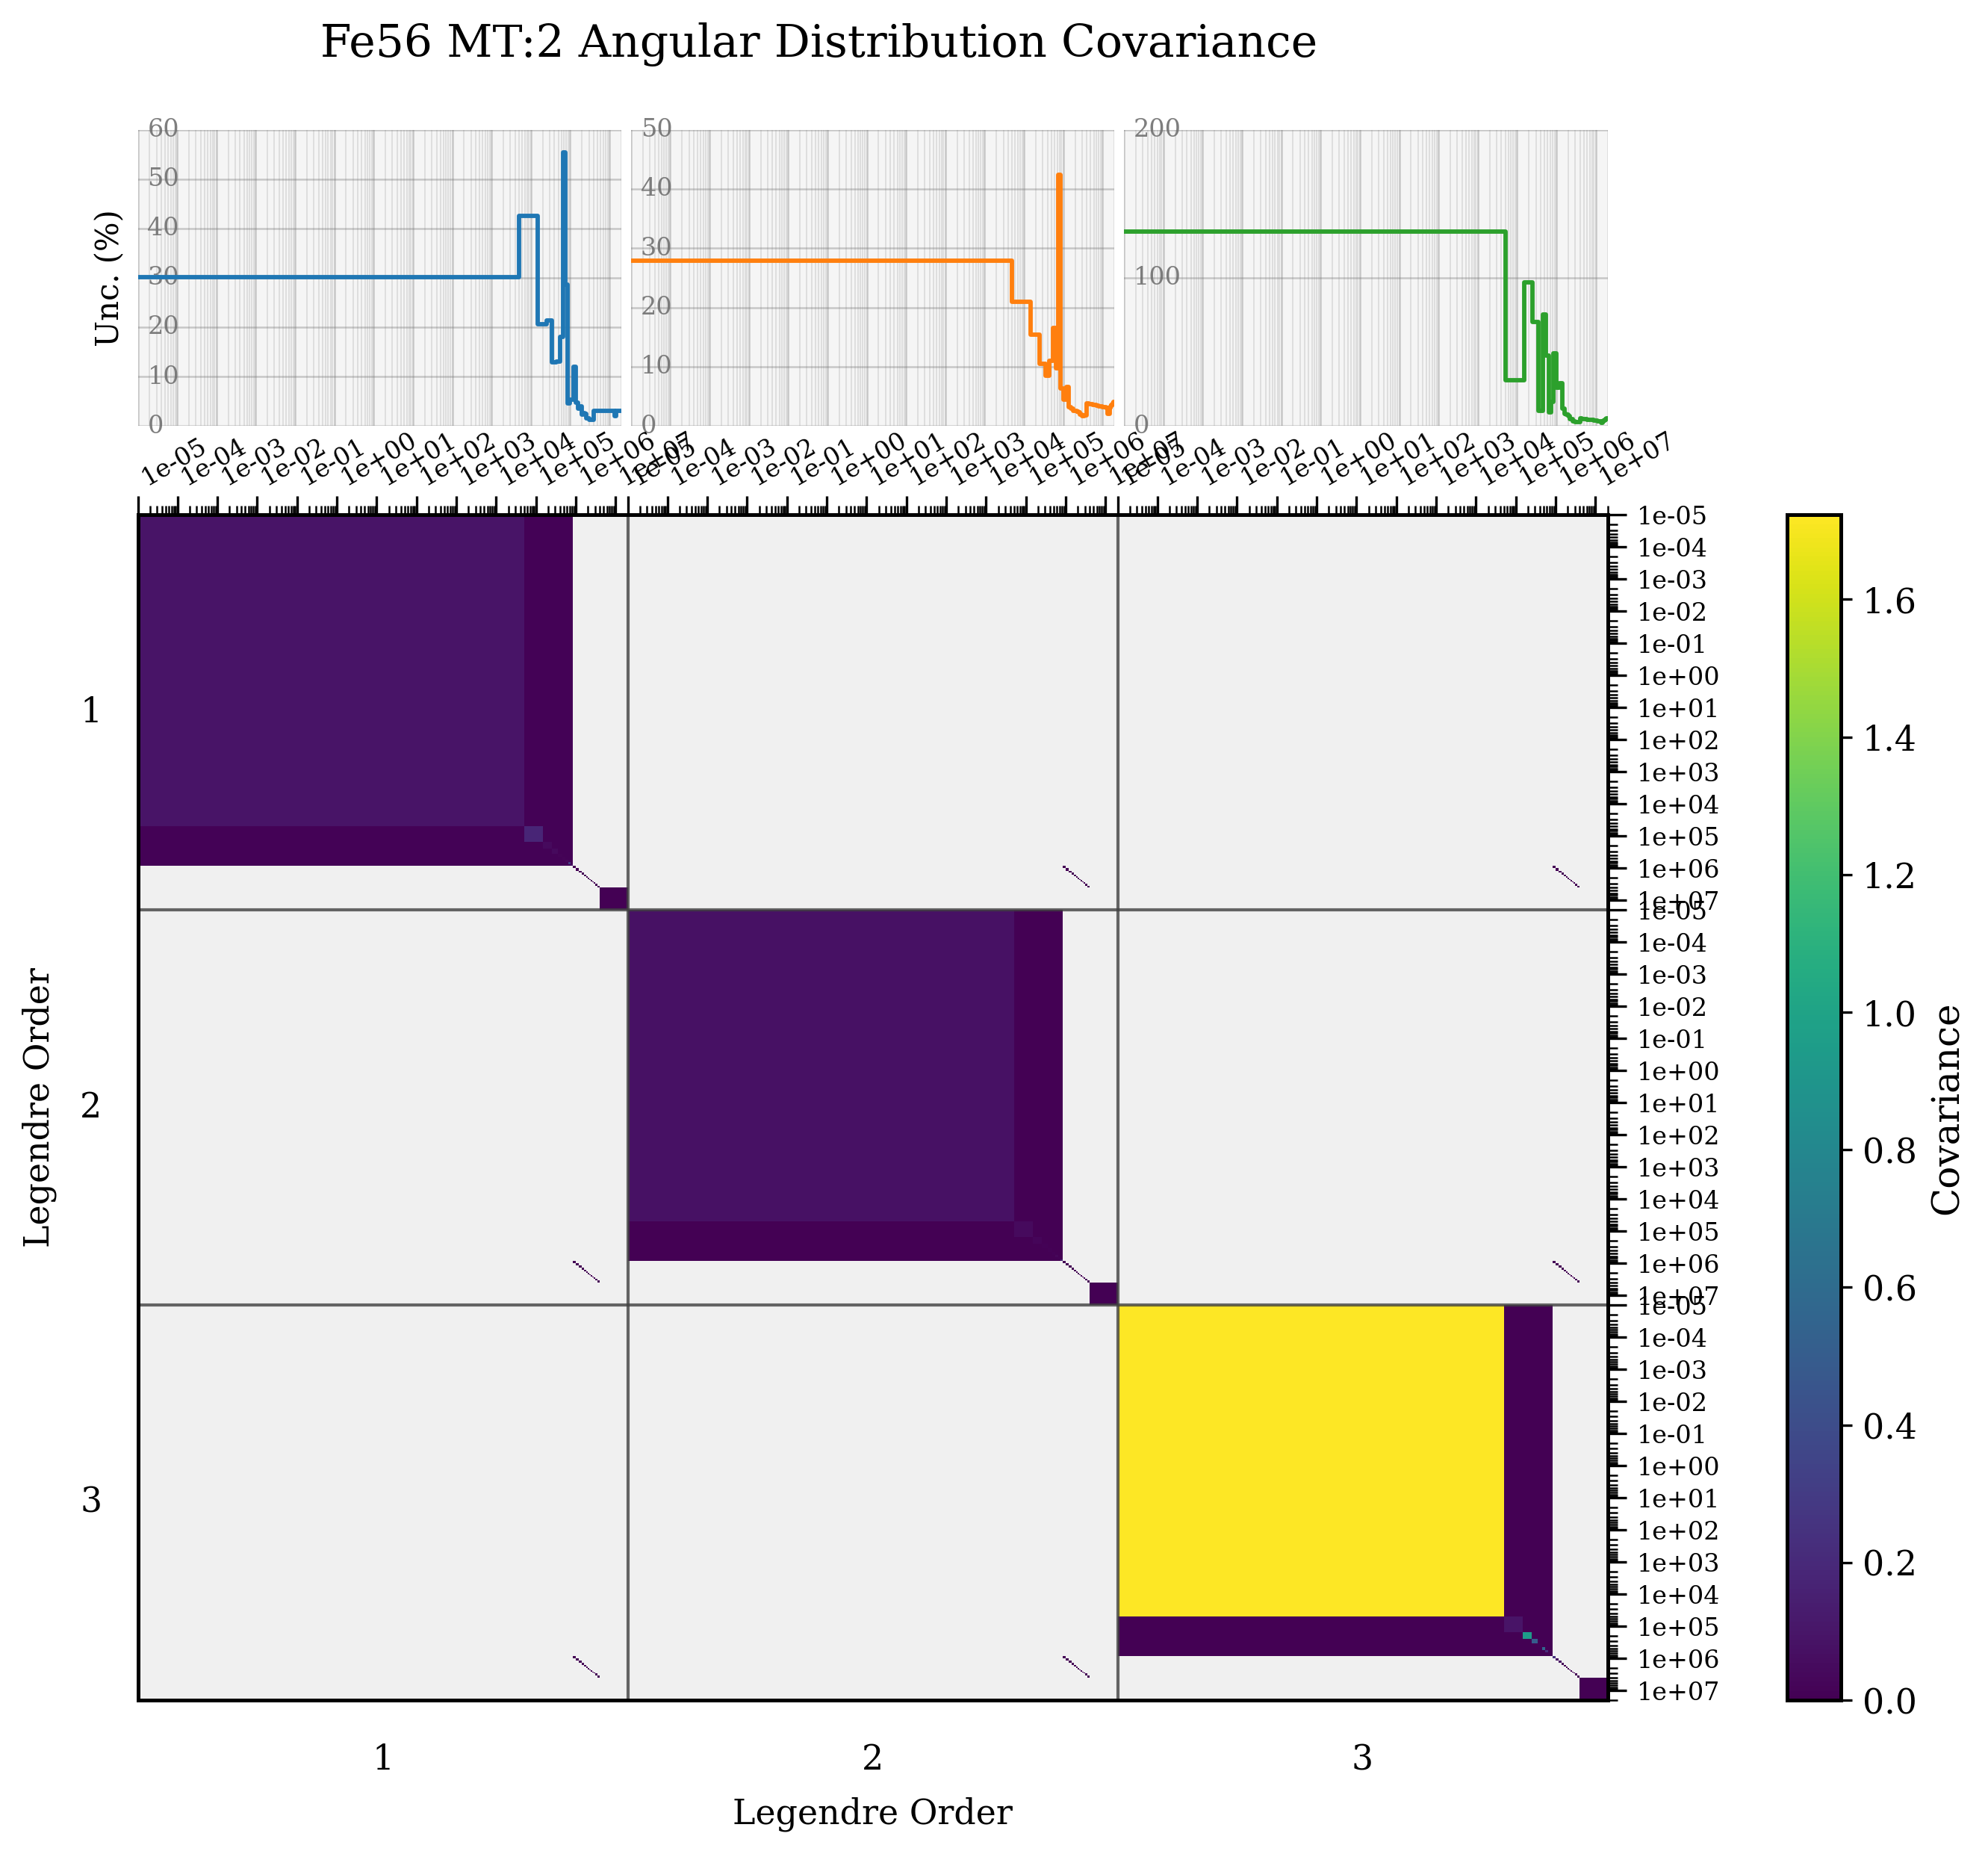

In [32]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre,
    matrix_type="cov",
    show_uncertainties=True,
)
print(f"✓ Test 2.9 passed: Multiple Legendre with covariance matrix")

## Test 2.10: Multiple Legendre - Linear Scale

✓ Test 2.10 passed: Multiple Legendre with linear scale


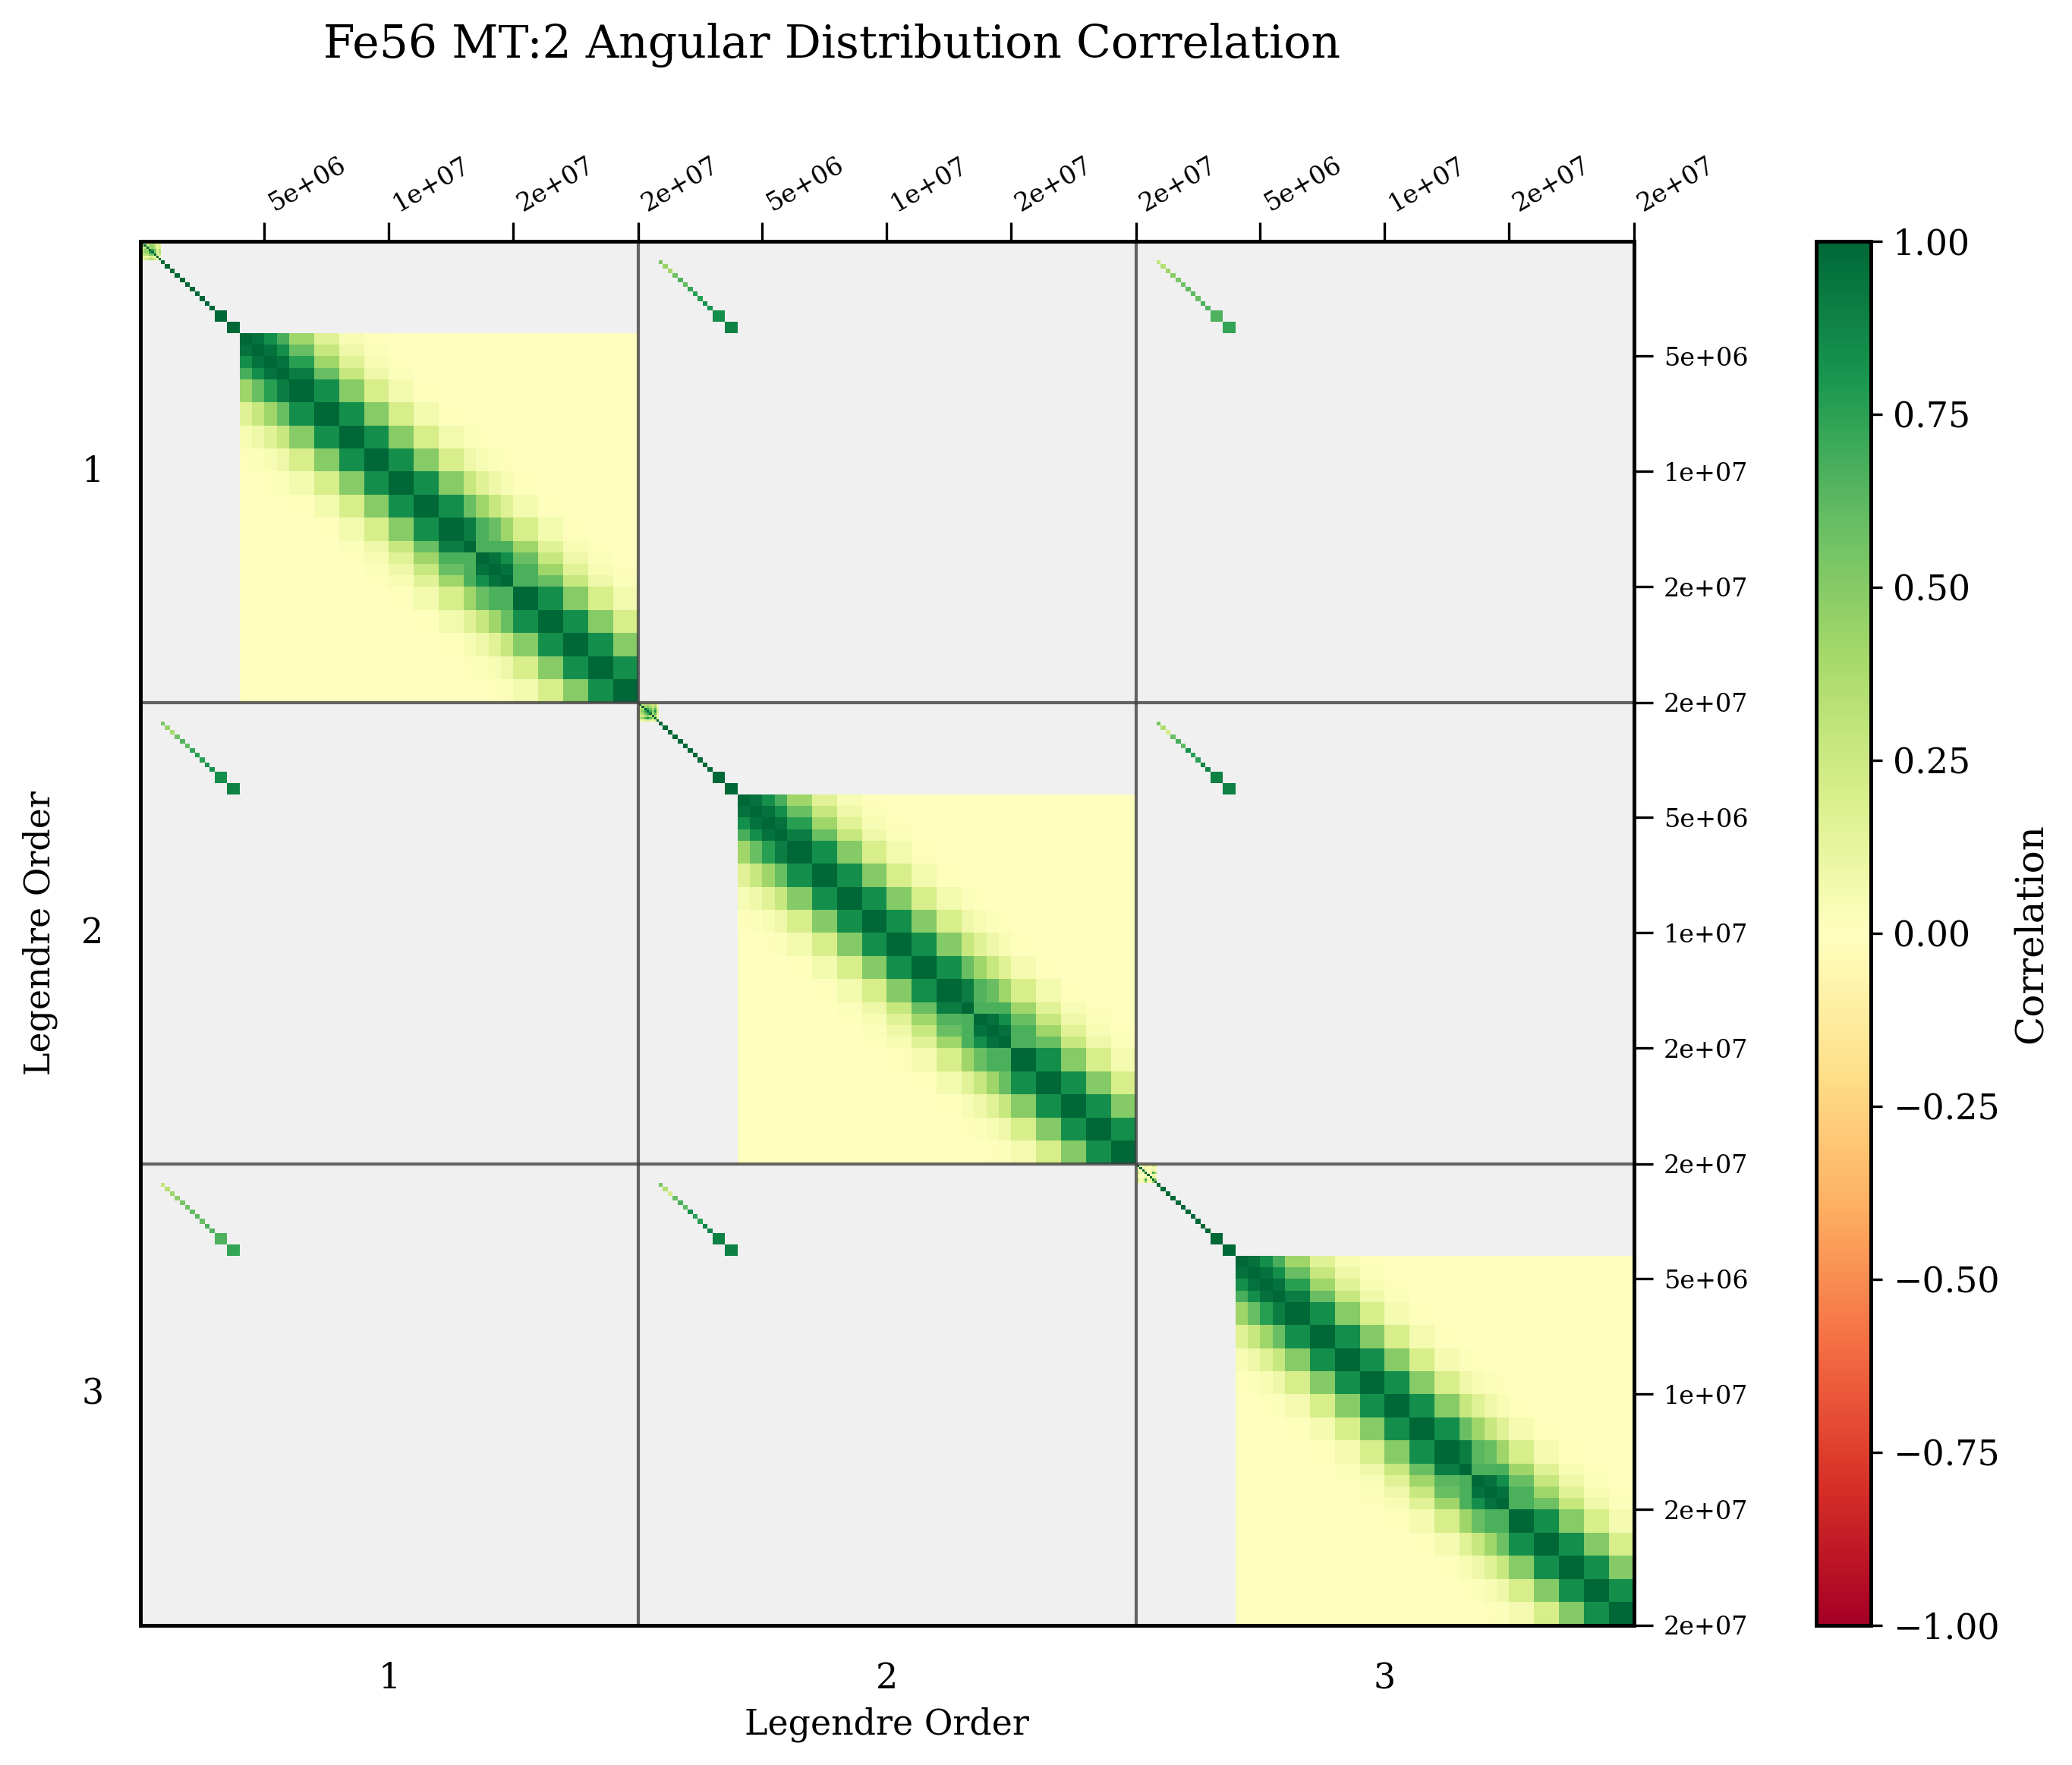

In [33]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre,
    scale="lin",
)
print(f"✓ Test 2.10 passed: Multiple Legendre with linear scale")

## Test 2.11: Multiple Legendre - Energy Filtering

✓ Test 2.11 passed: Multiple Legendre with energy filtering


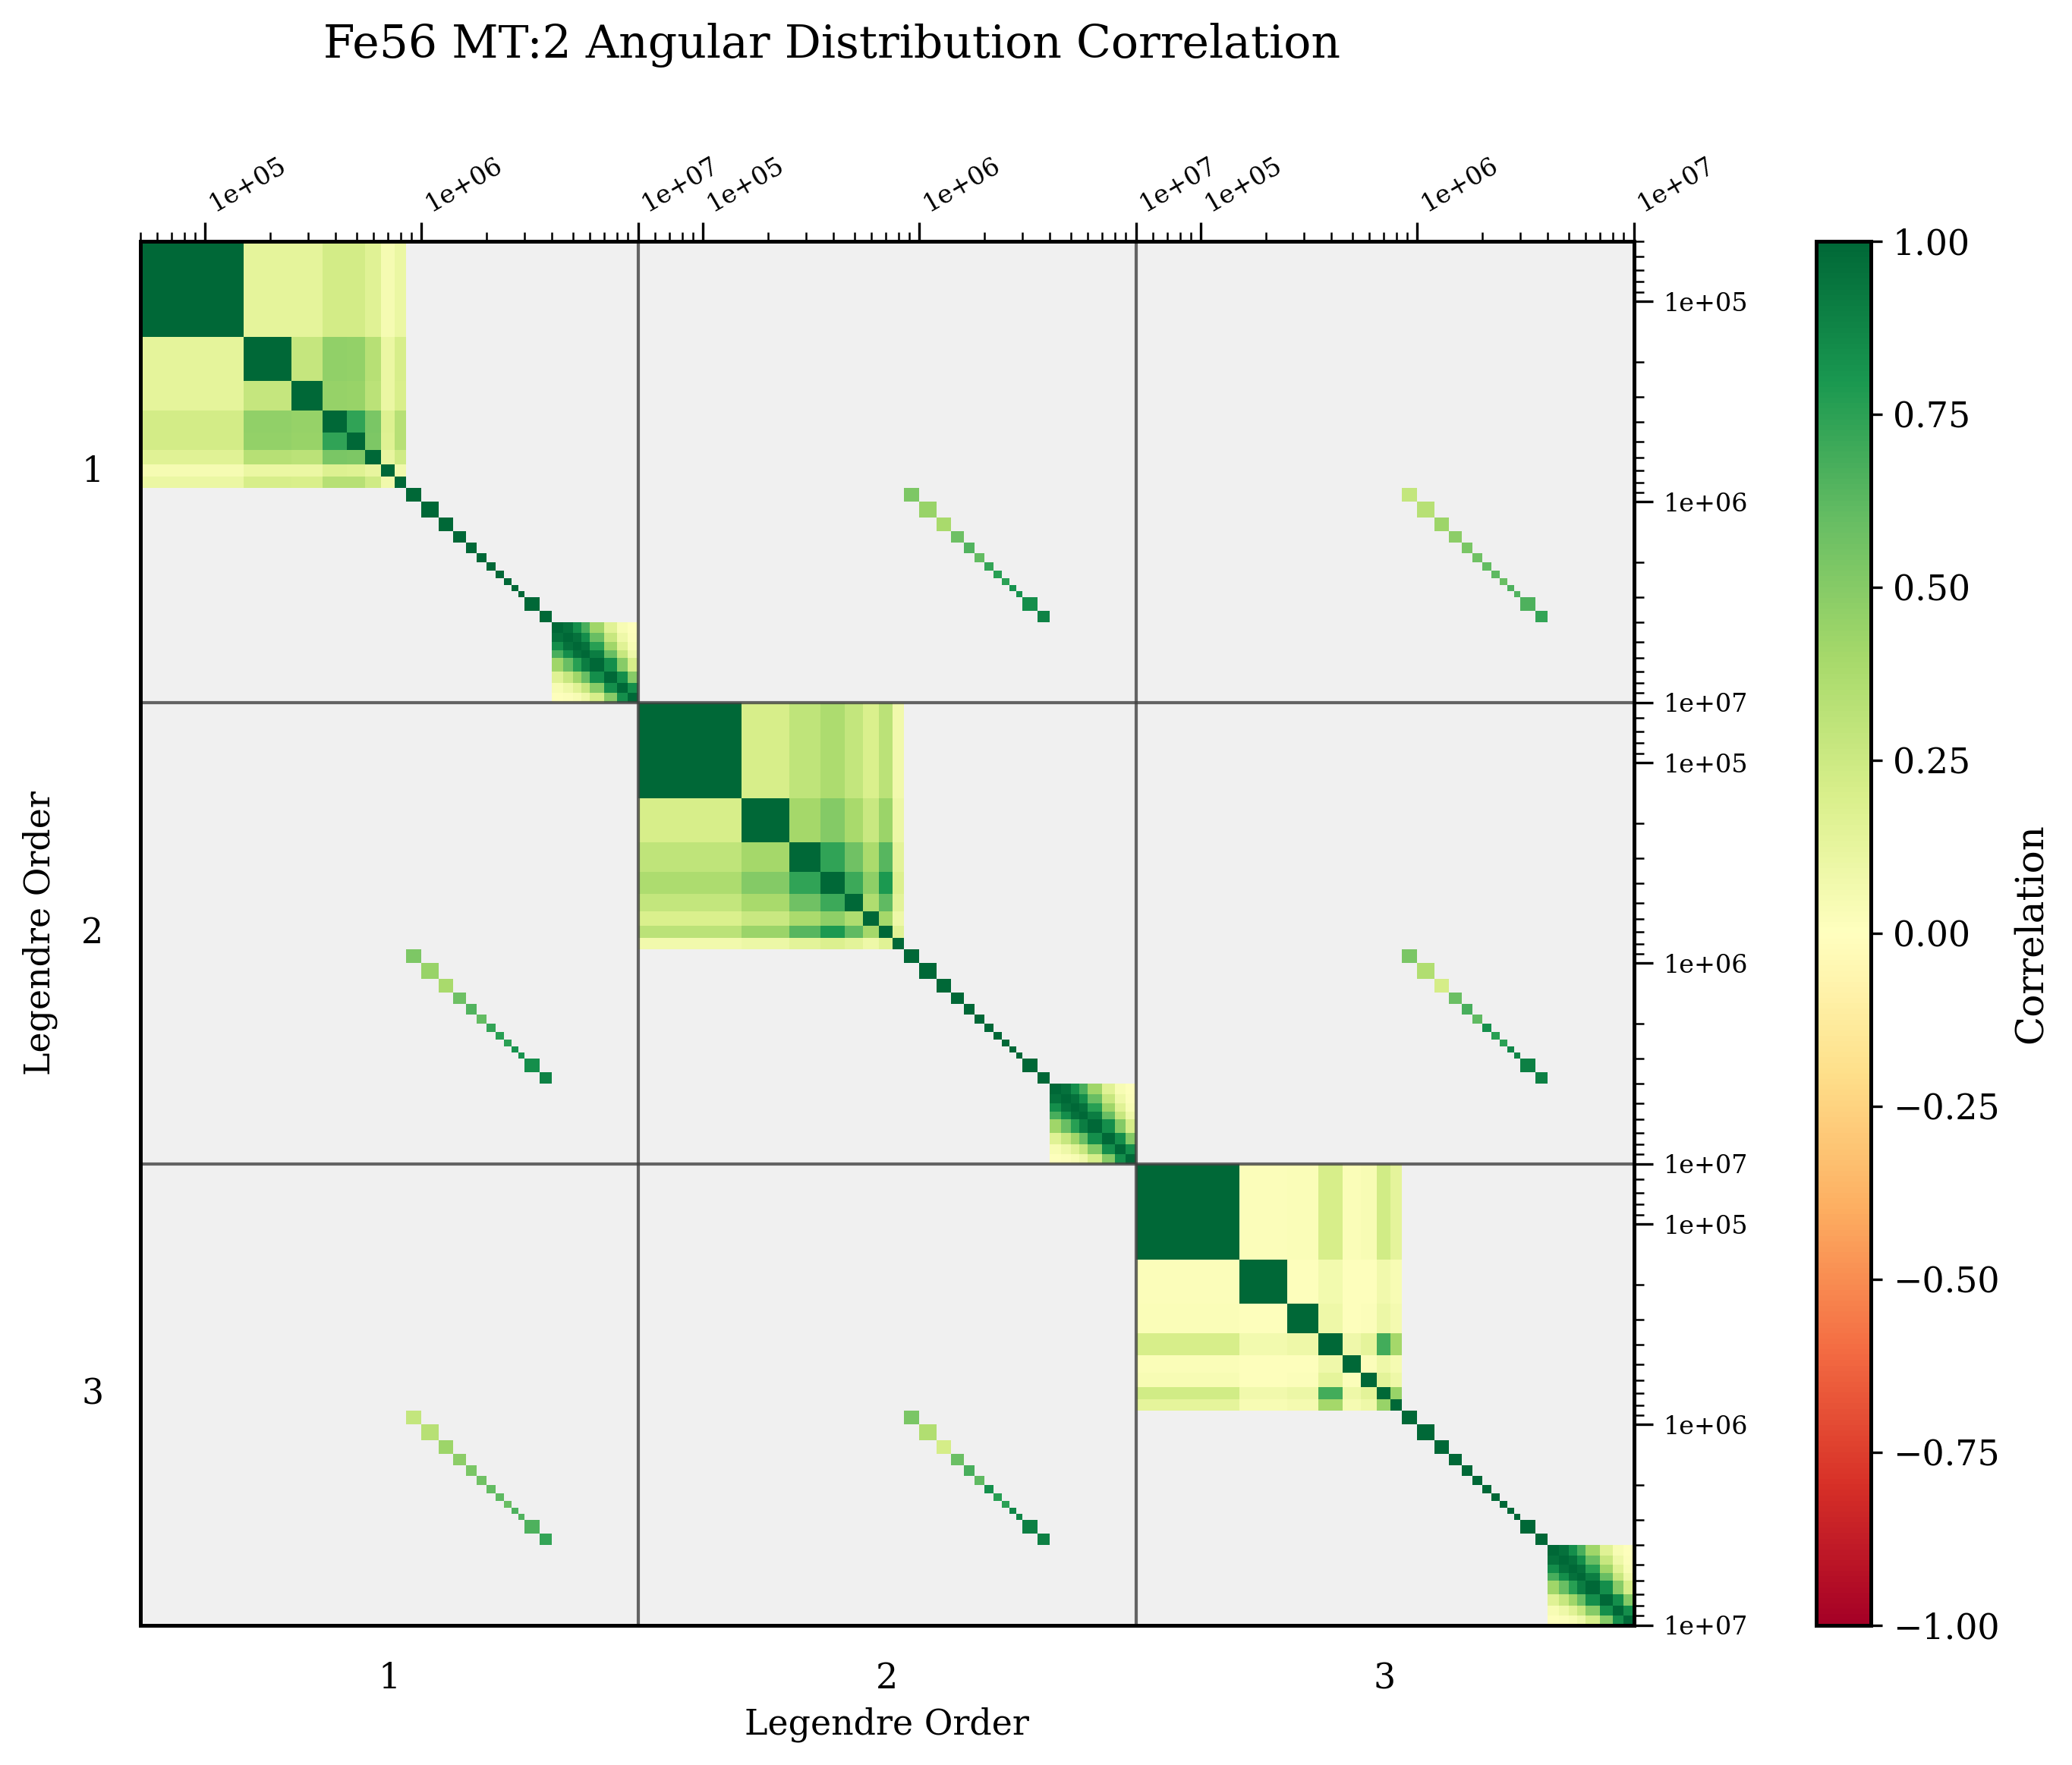

In [34]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre,
    energy_range=(1e5, 1e7),
)
print(f"✓ Test 2.11 passed: Multiple Legendre with energy filtering")

## Test 2.12: Multiple Legendre - Without Block Labels

✓ Test 2.12 passed: Multiple Legendre without block labels


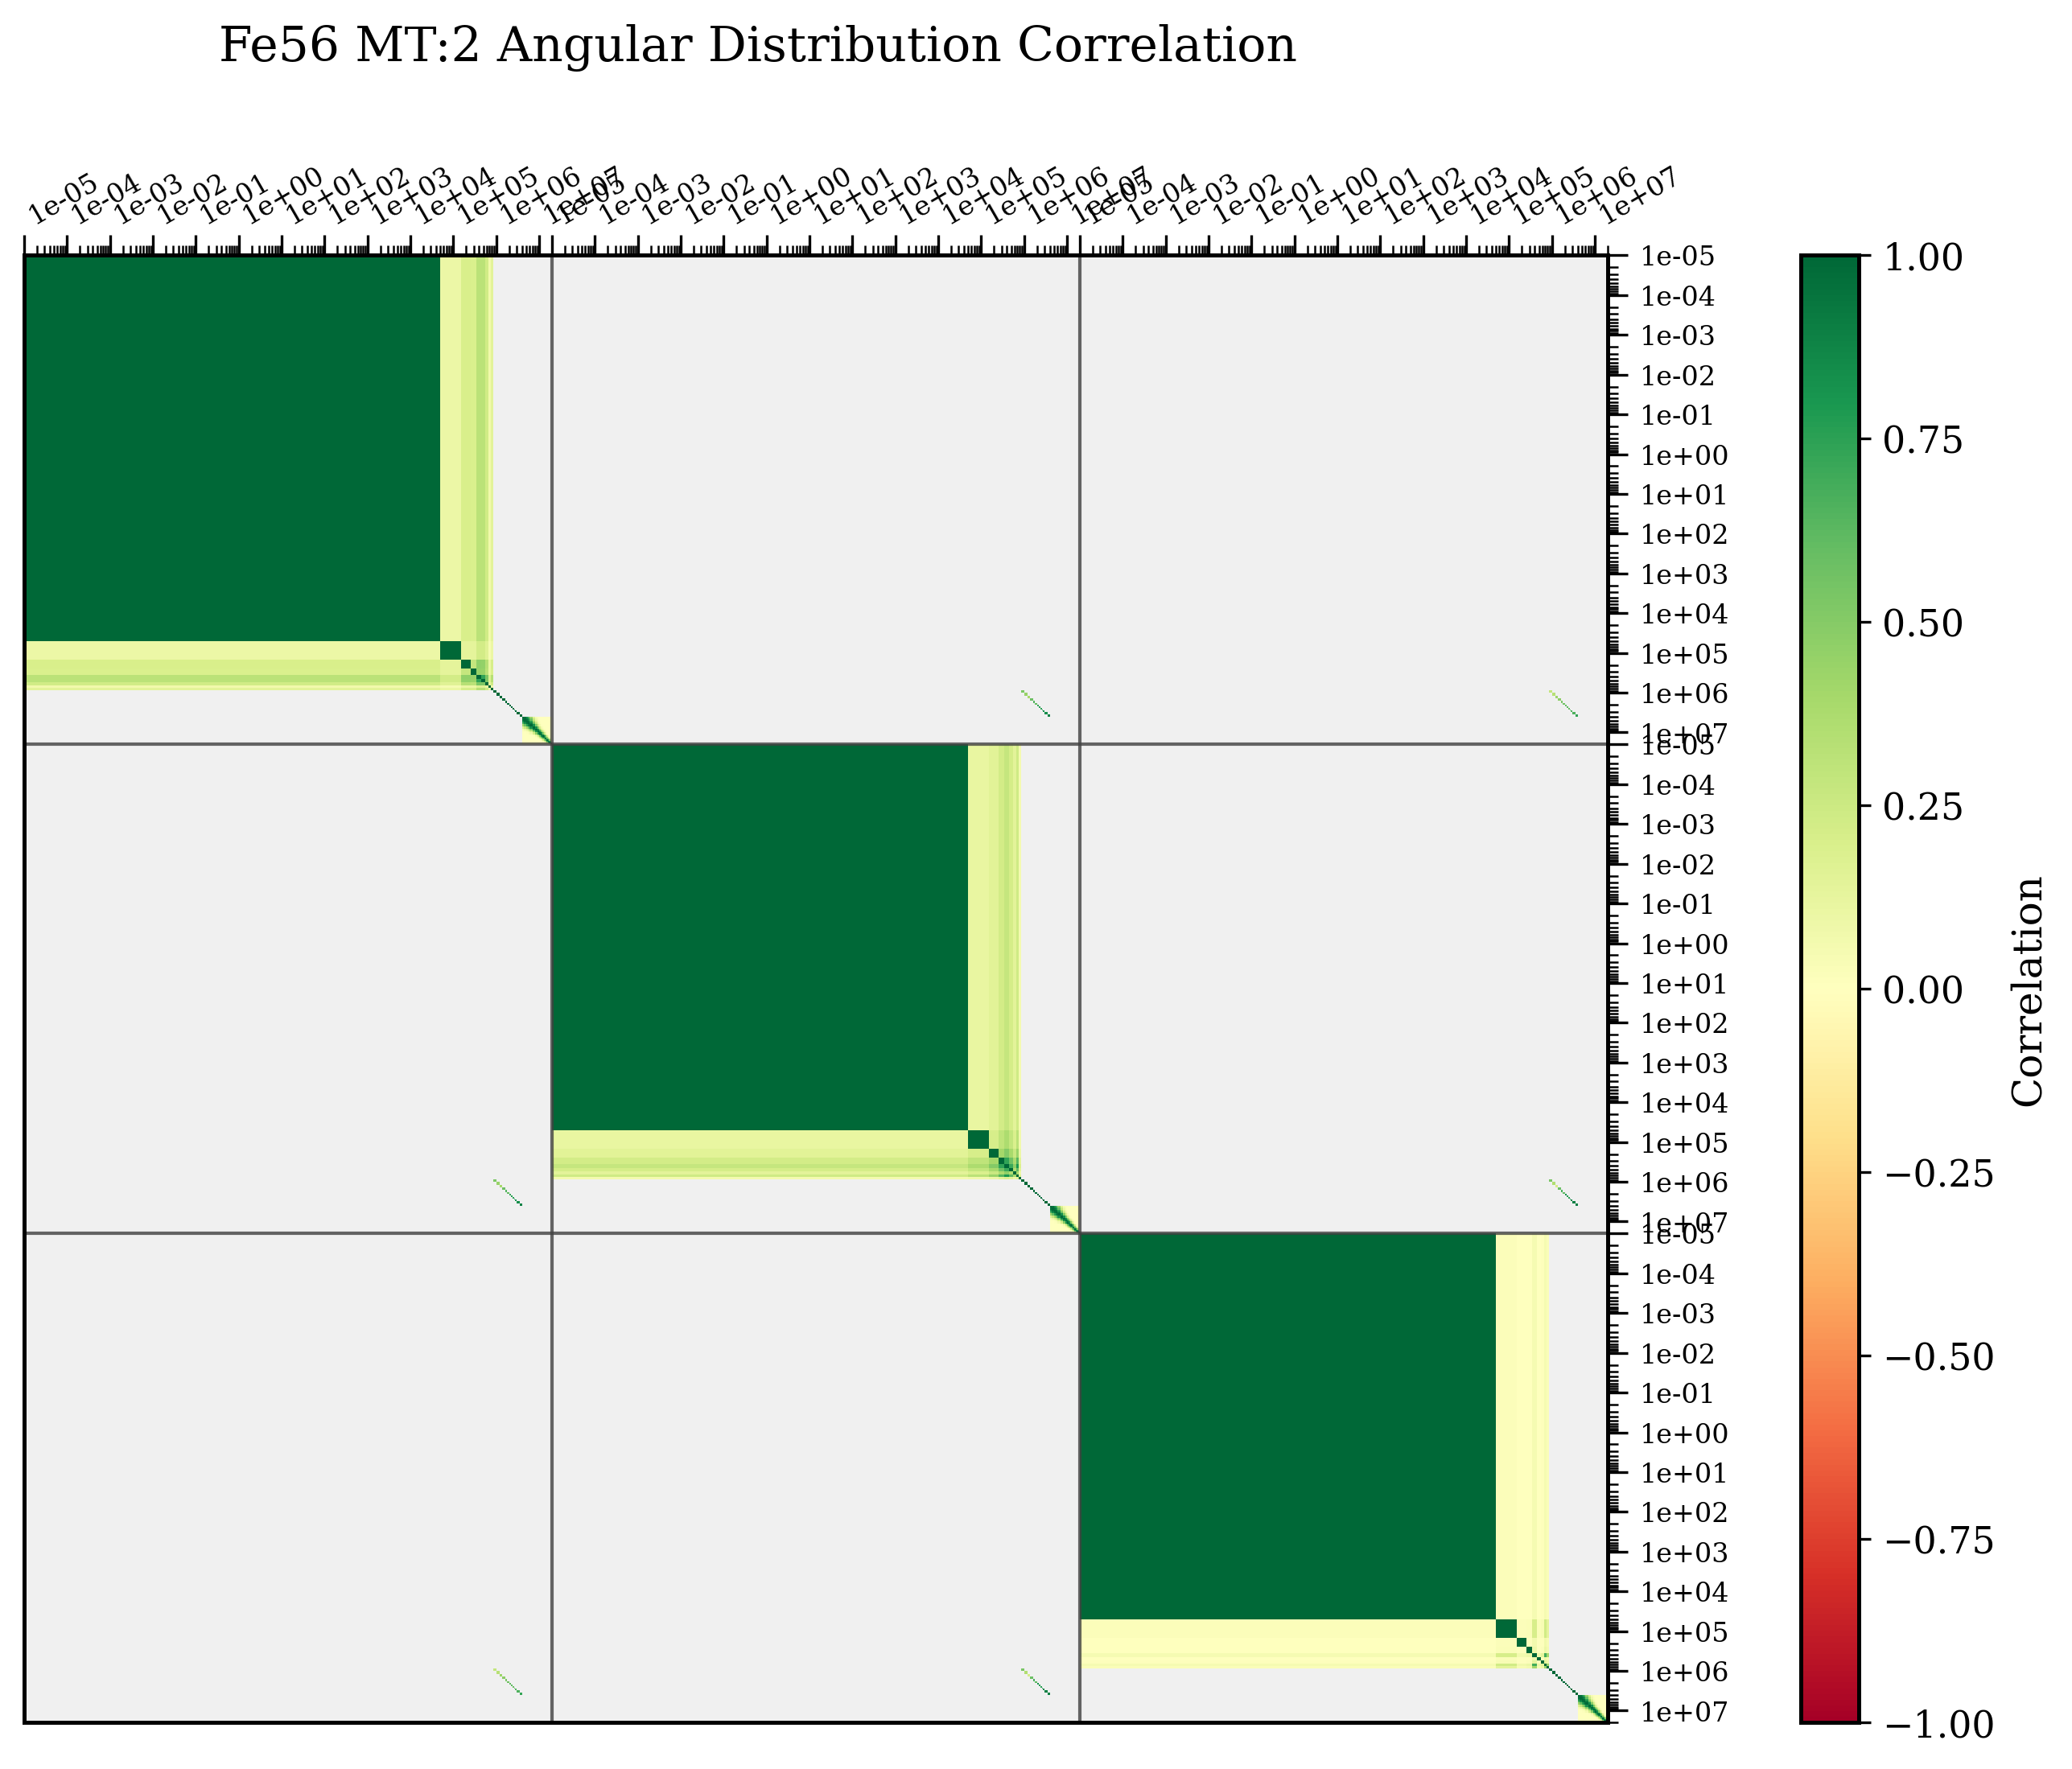

In [35]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre,
    show_block_labels=False,
)
print(f"✓ Test 2.12 passed: Multiple Legendre without block labels")

## Test 2.13: Off-Diagonal Legendre Block

✓ Test 2.13 passed: Off-diagonal Legendre block L=1 vs L=2


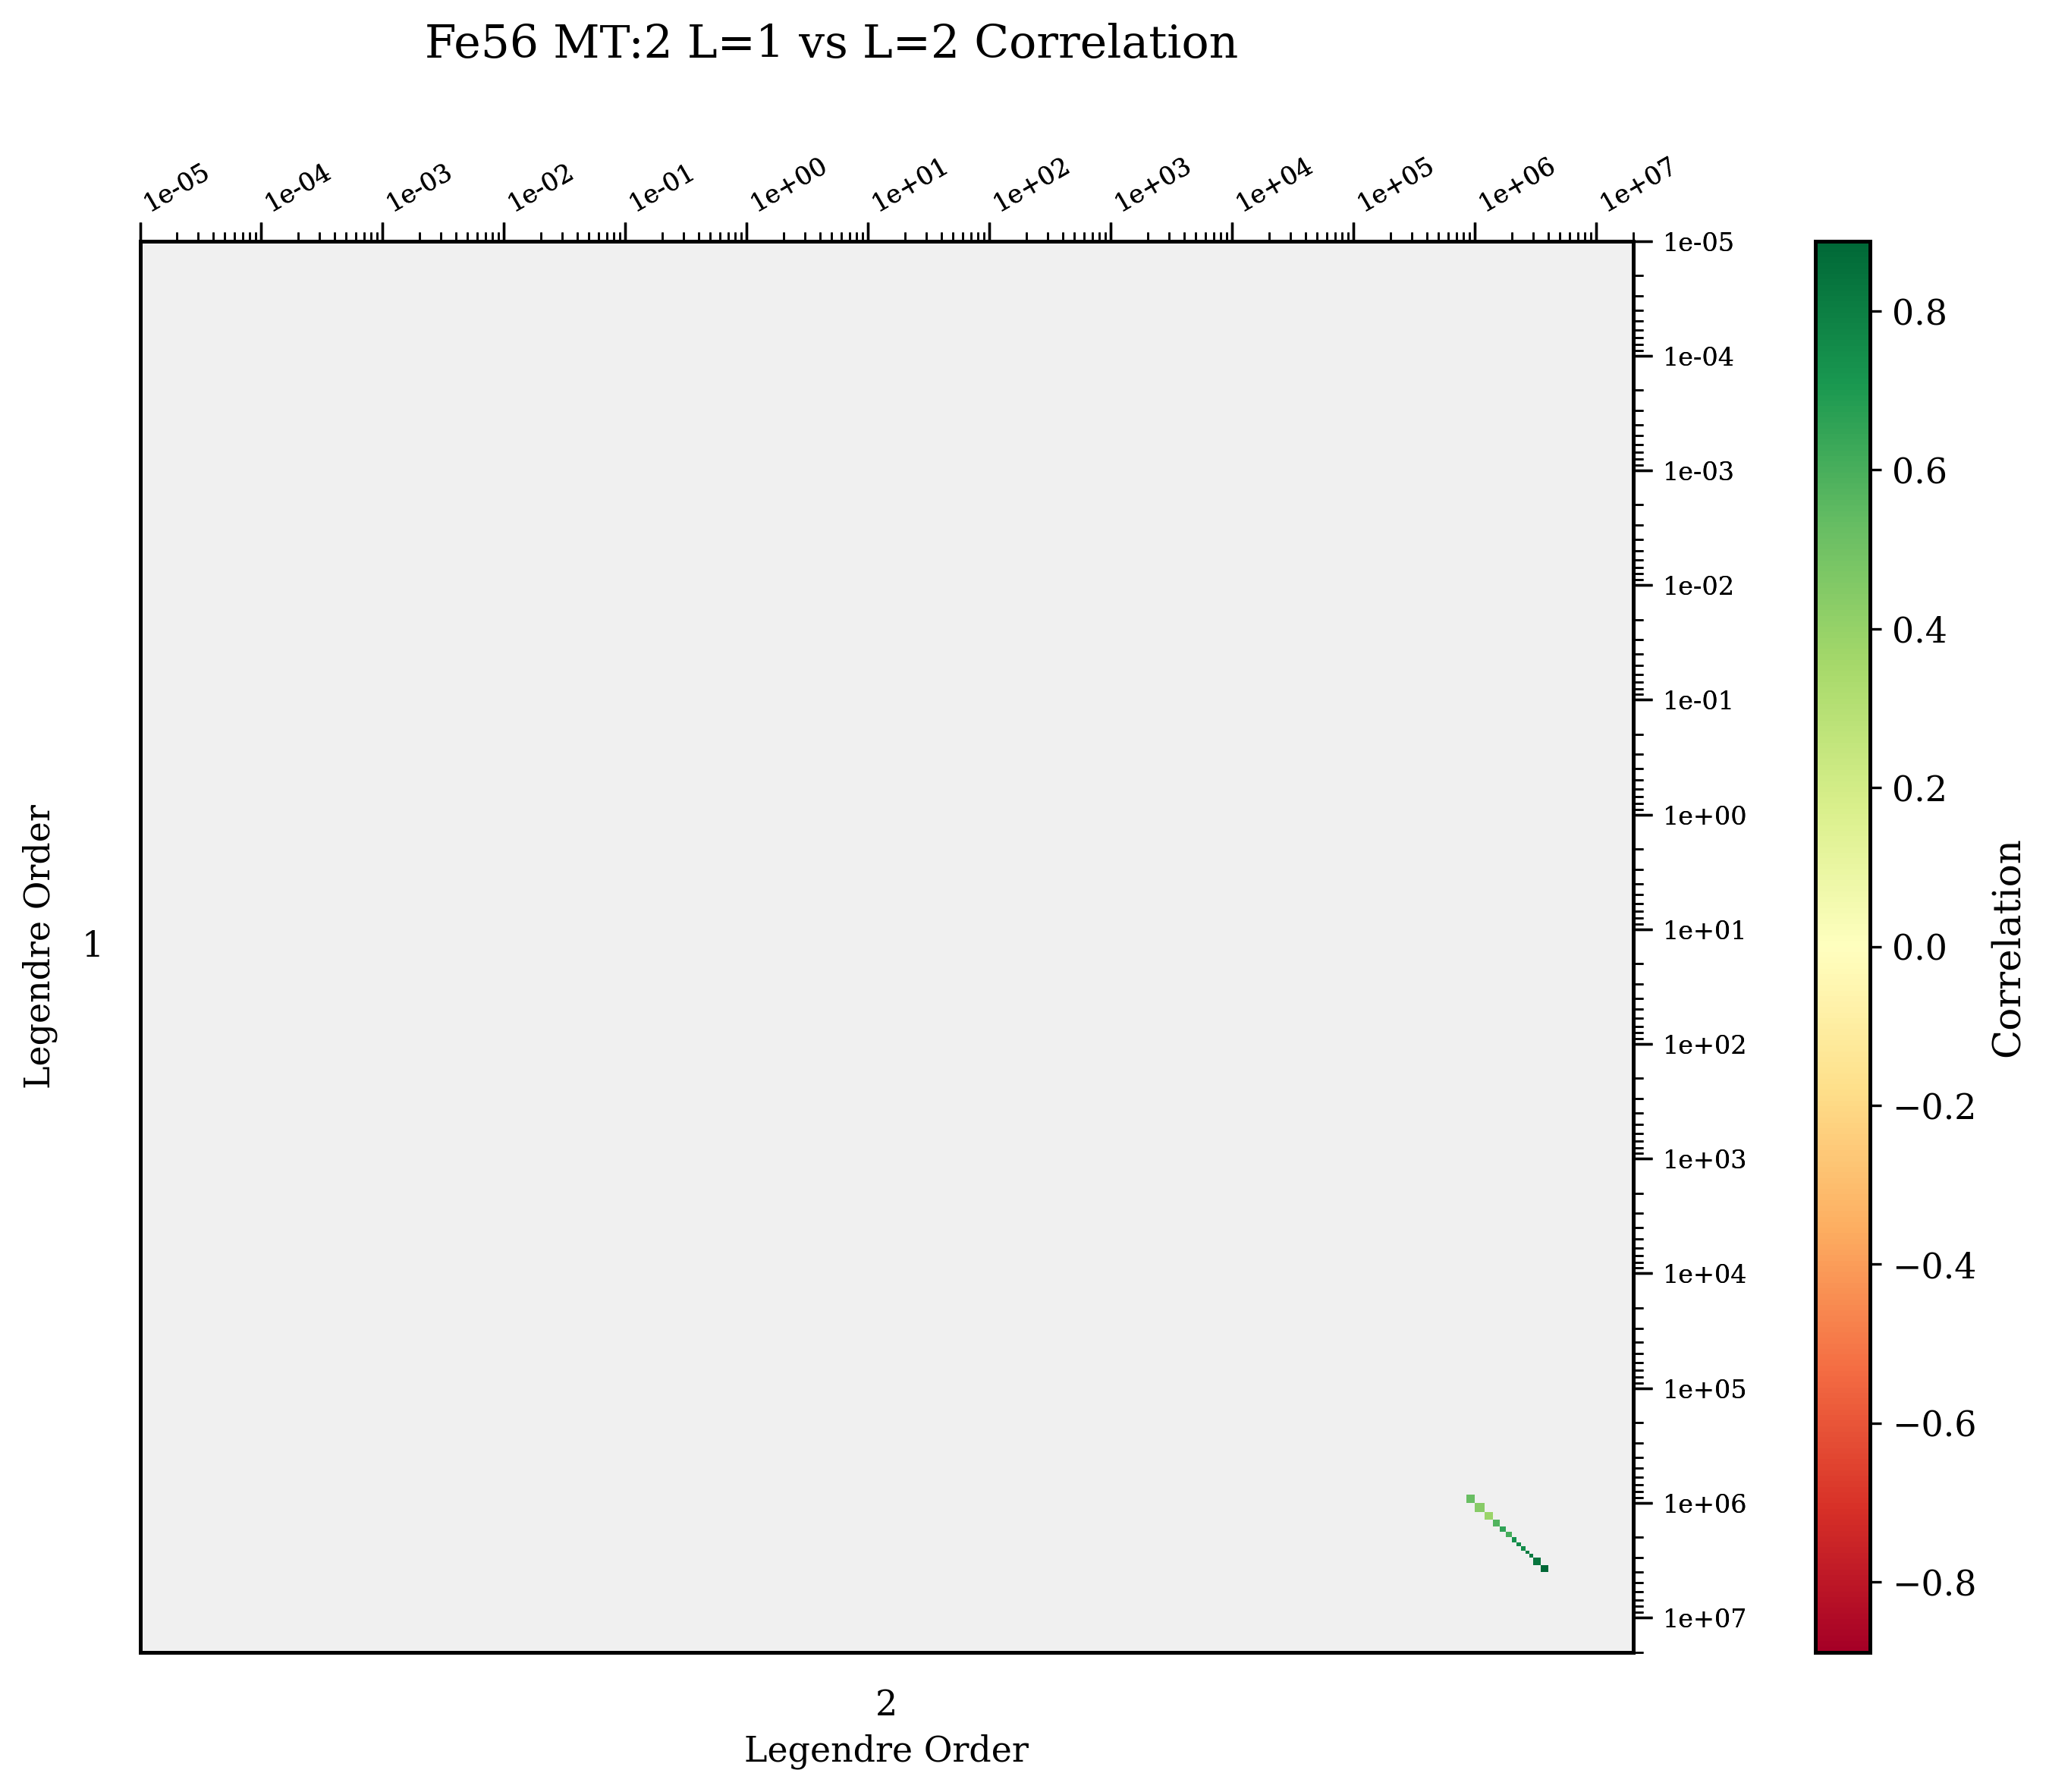

In [36]:
if len(mf34_test_legendre) >= 2:
    fig = plot_mf34_covariance_heatmap(
        mf34_covmat,
        nuclide=mf34_test_zaid,
        mt=mf34_test_mt,
        legendre_coeffs=(mf34_test_legendre[0], mf34_test_legendre[1]),  # Tuple
    )
    print(f"✓ Test 2.13 passed: Off-diagonal Legendre block L={mf34_test_legendre[0]} vs L={mf34_test_legendre[1]}")
else:
    print("⊘ Test 2.13 skipped: Need at least 2 Legendre coefficients")

## Test 2.14: Using Nuclide String

✓ Test 2.14 passed: Using nuclide string 'Fe56'


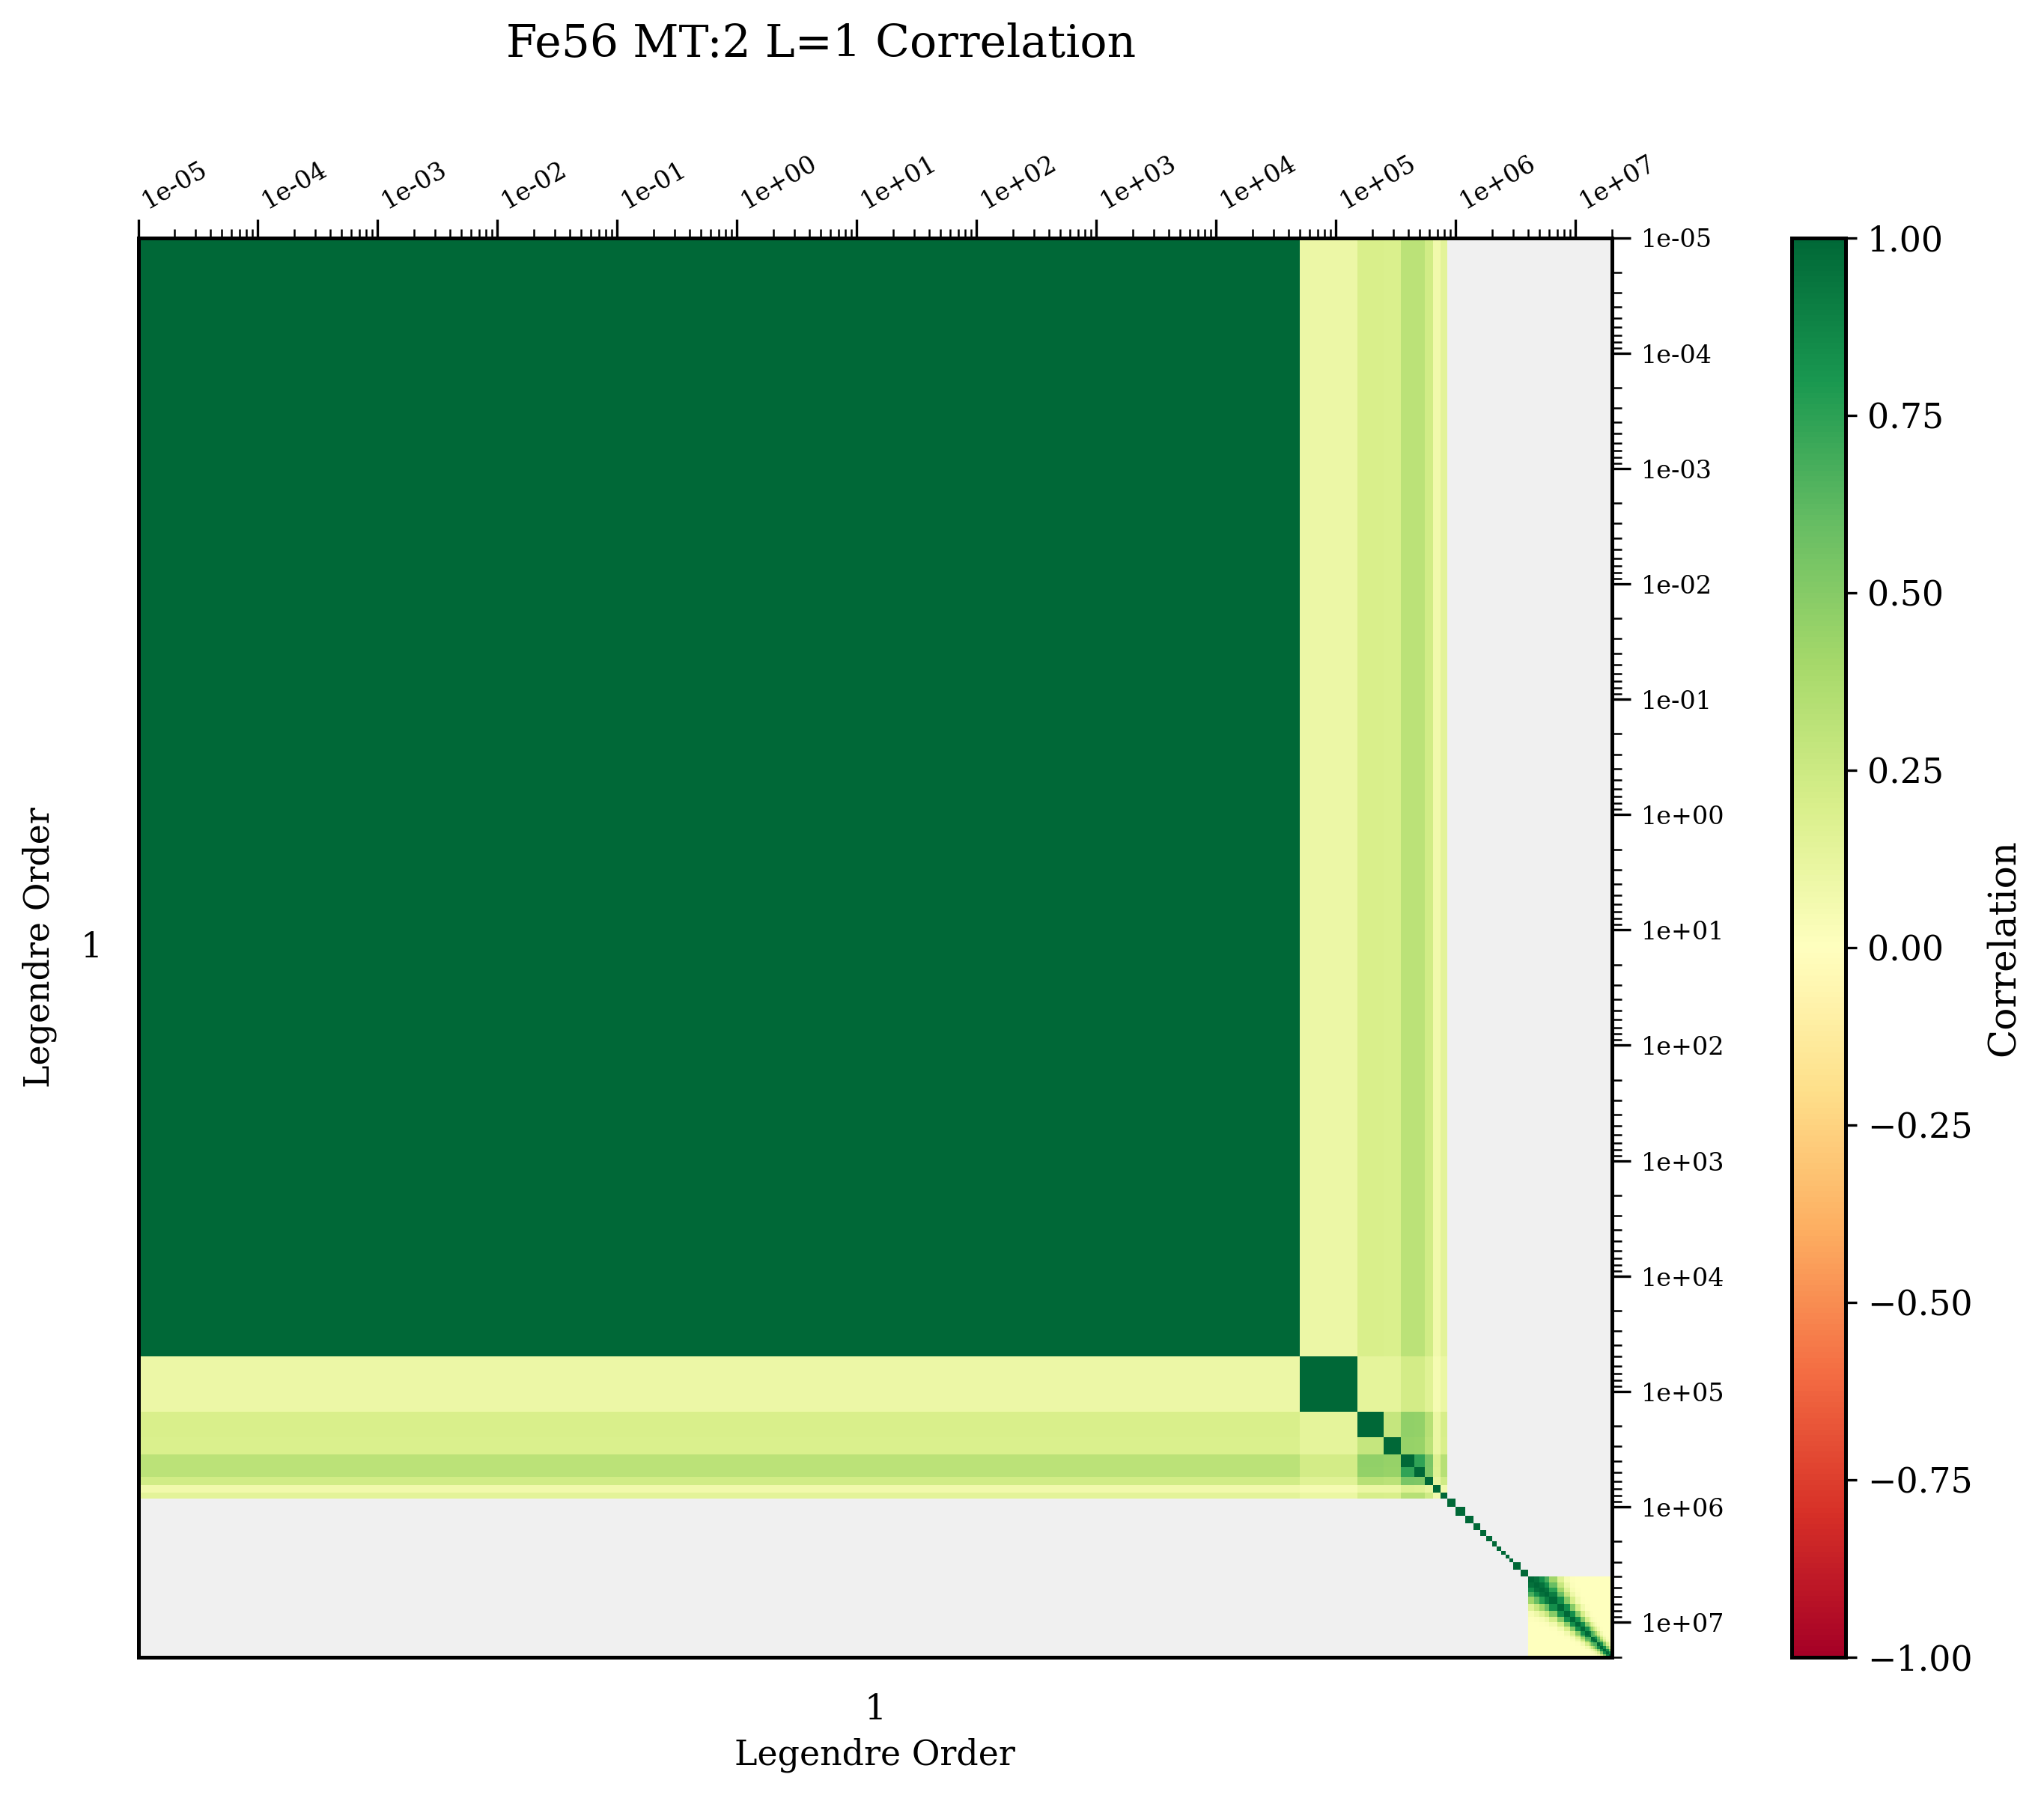

In [37]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide='Fe56',  # String identifier
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
)
print(f"✓ Test 2.14 passed: Using nuclide string 'Fe56'")

## Test 2.15: Custom Font Sizes

✓ Test 2.15 passed: Multiple Legendre with custom font sizes


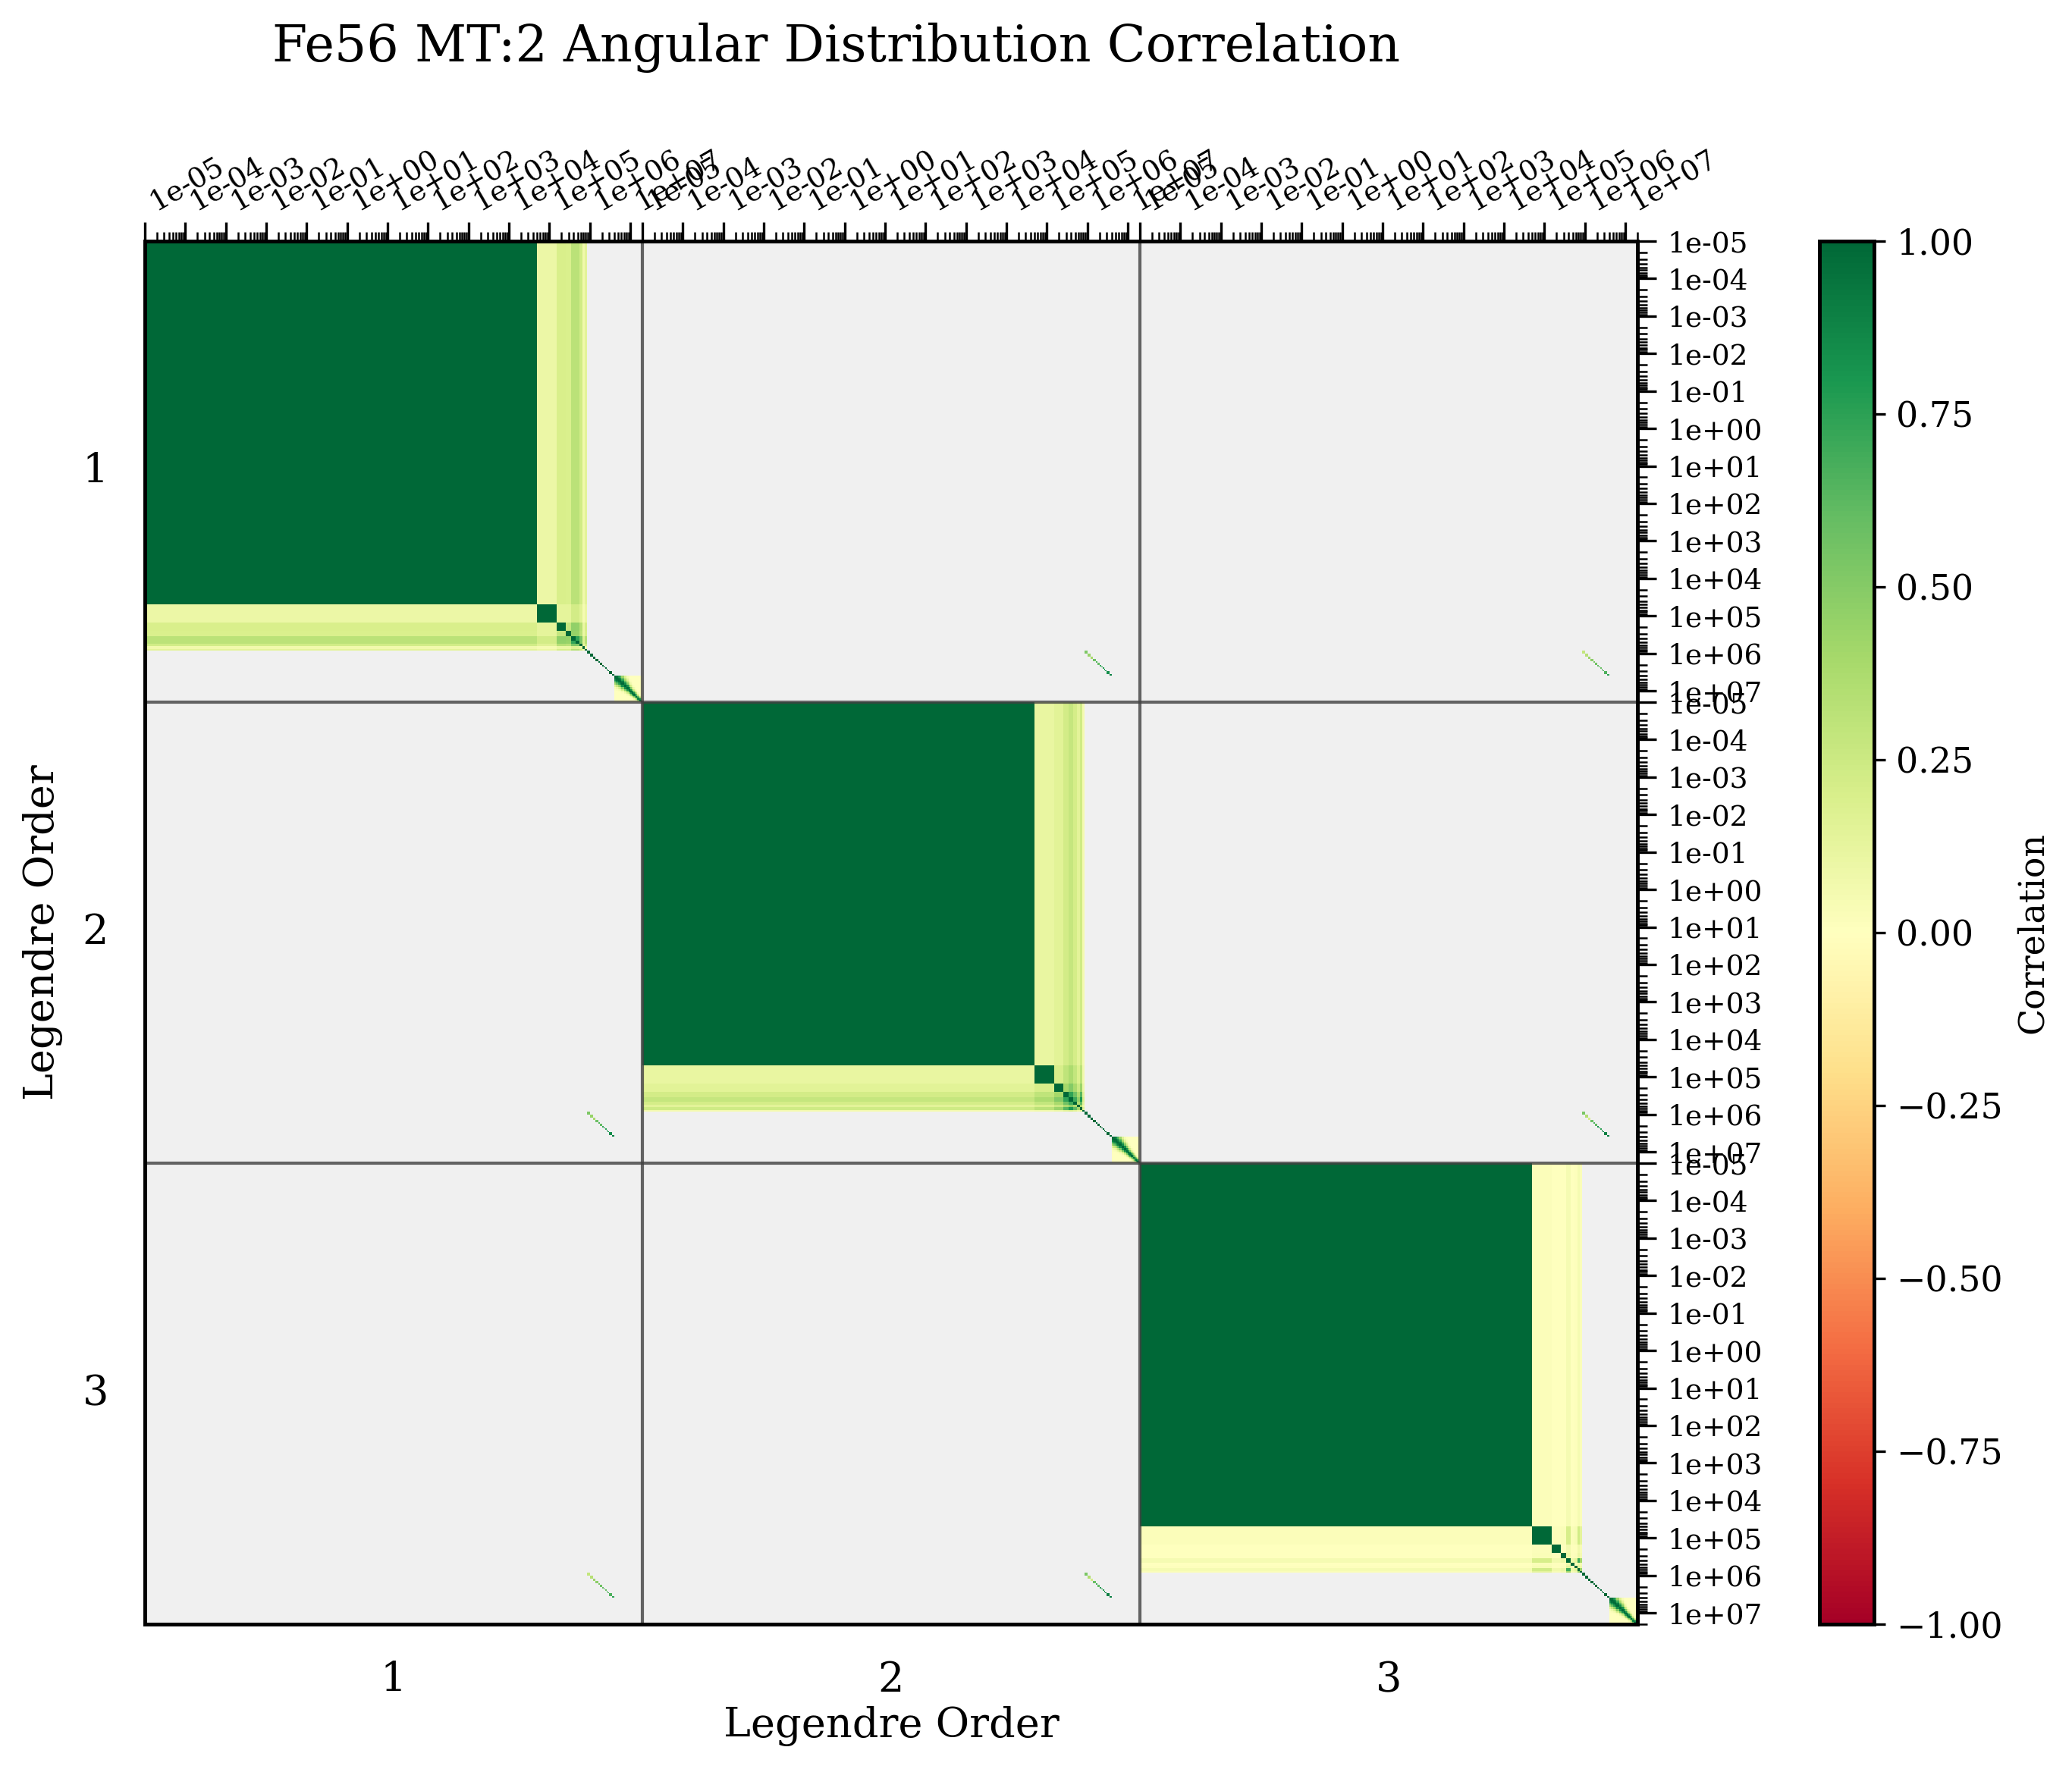

In [38]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre,
    title_fontsize=16,
    tick_fontsize=11,
    energy_tick_fontsize=9,
    block_label_fontsize=13,
    colorbar_fontsize=11,
)
print(f"✓ Test 2.15 passed: Multiple Legendre with custom font sizes")

## Test 2.16: Custom Colormap

✓ Test 2.16 passed: Custom colormap 'viridis'


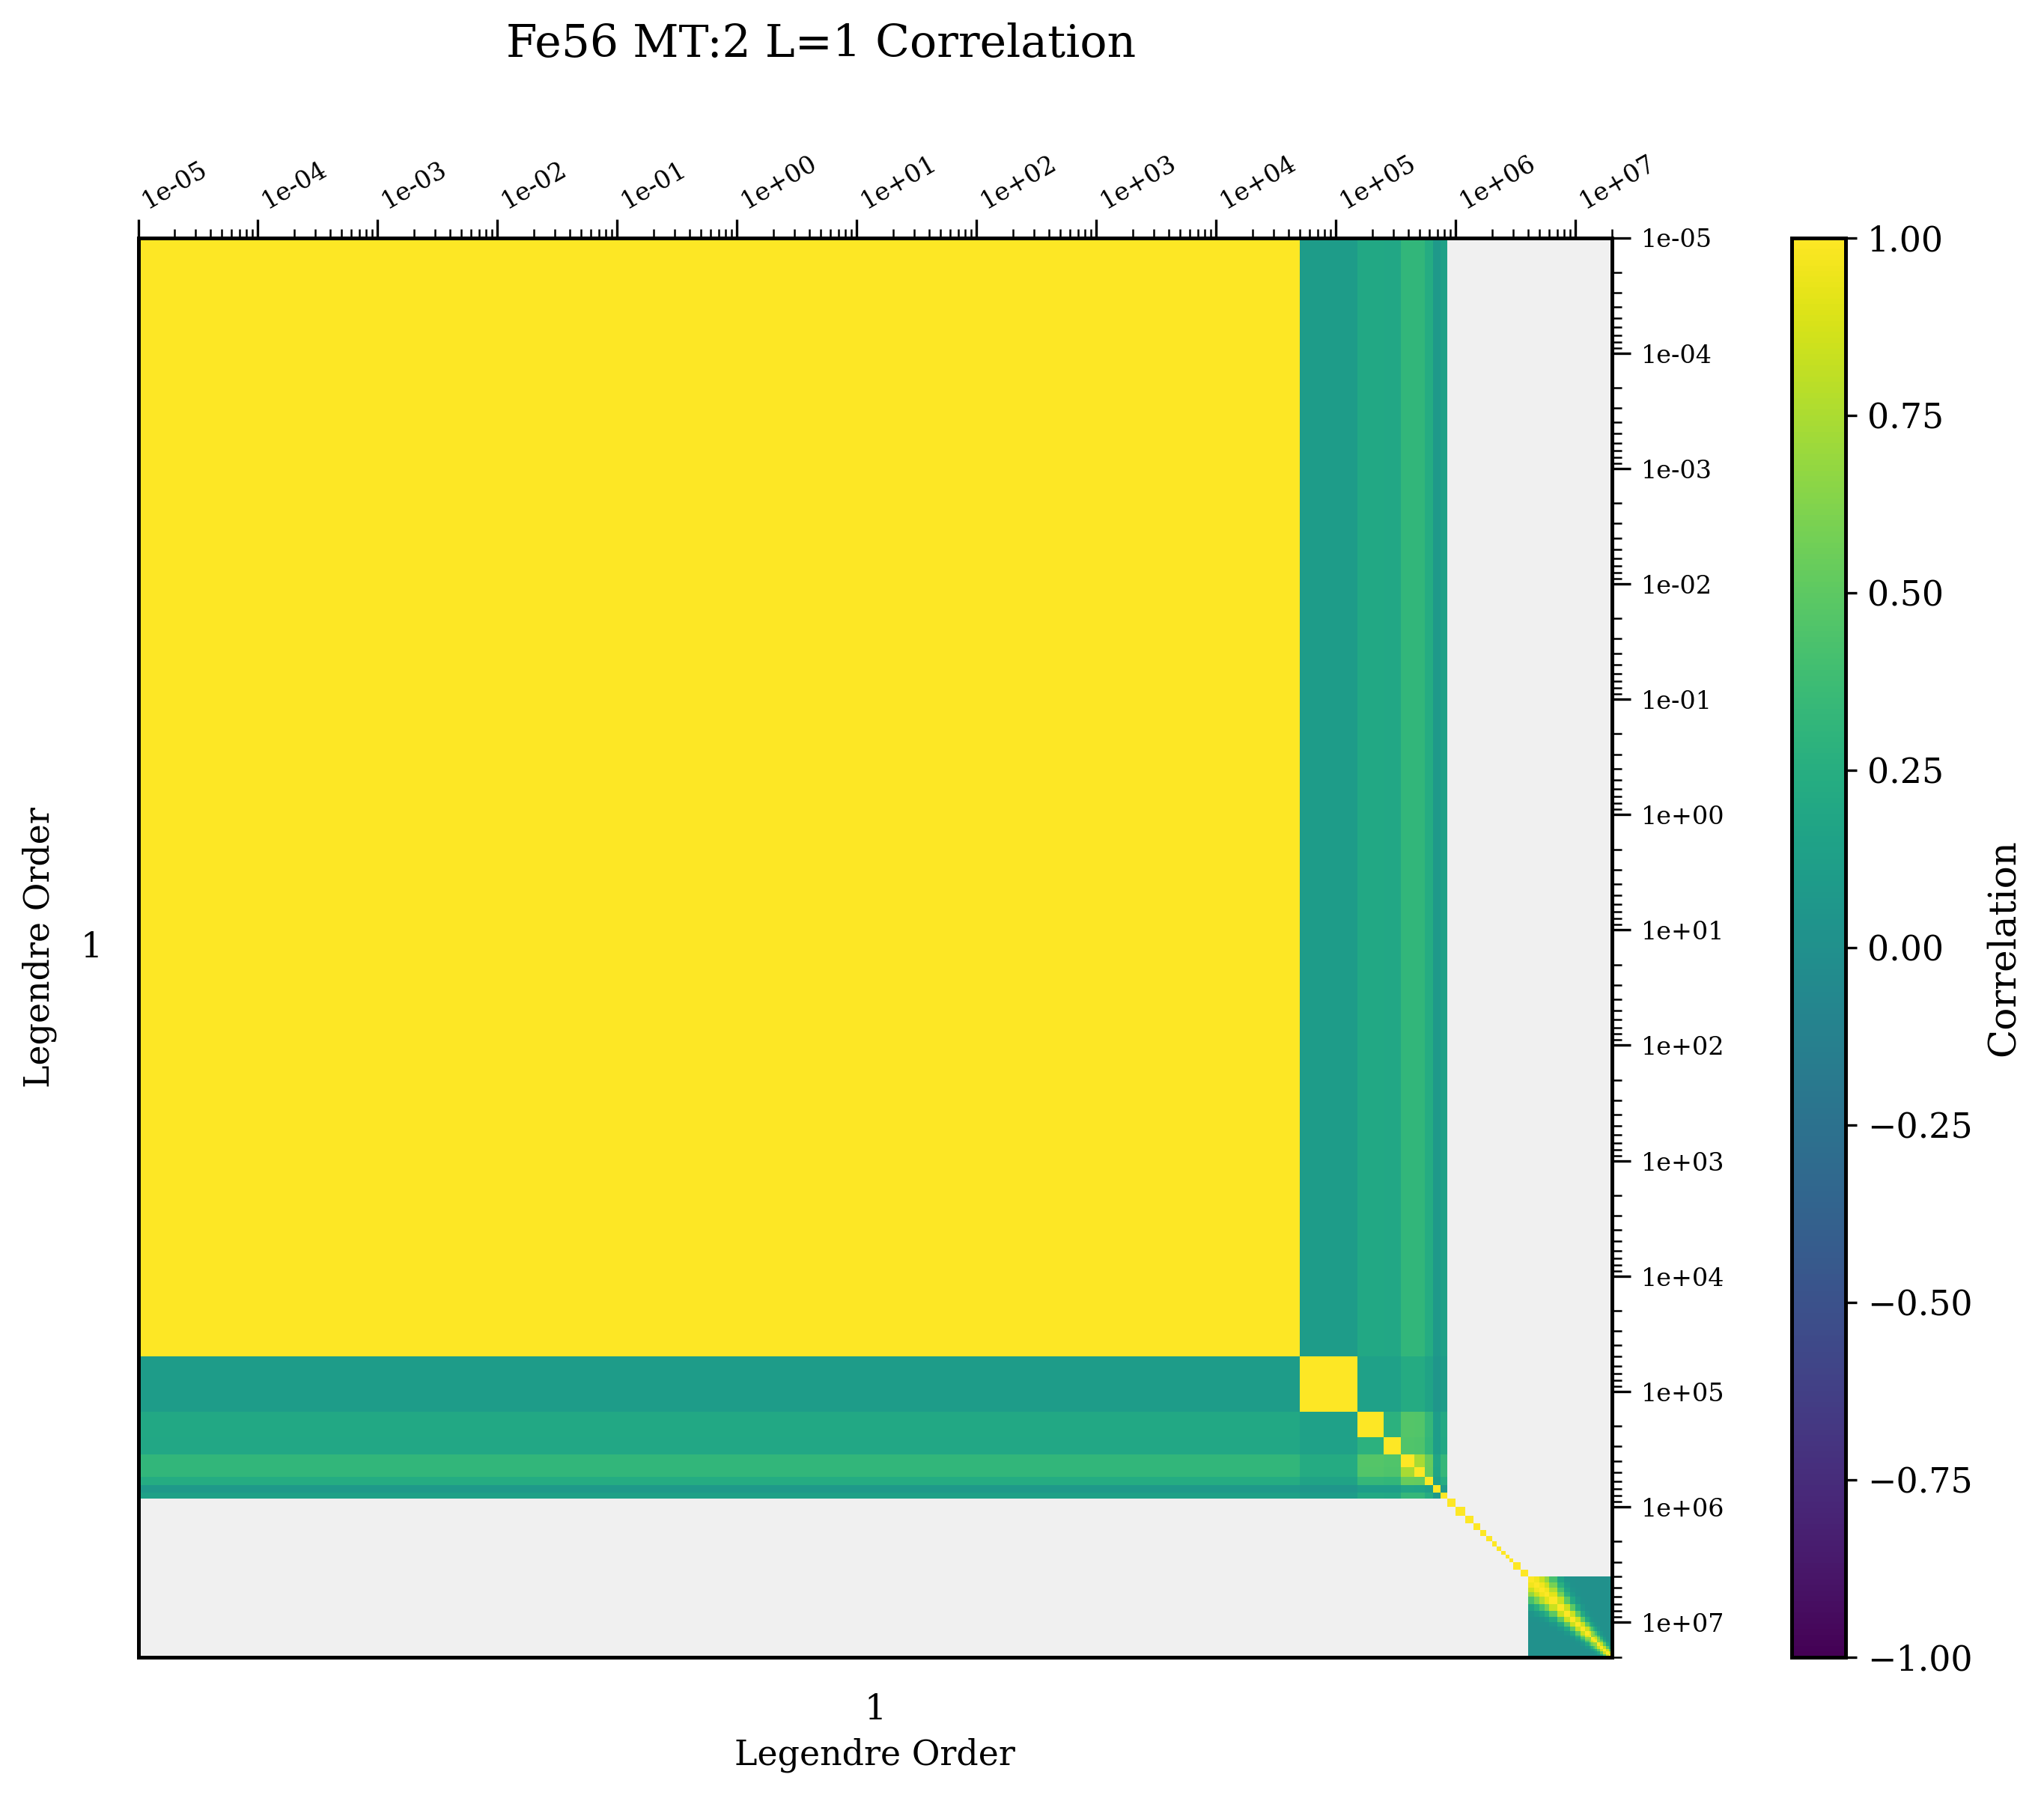

In [39]:
fig = plot_mf34_covariance_heatmap(
    mf34_covmat,
    nuclide=mf34_test_zaid,
    mt=mf34_test_mt,
    legendre_coeffs=mf34_test_legendre[0],
    cmap='viridis',
)
print(f"✓ Test 2.16 passed: Custom colormap 'viridis'")

---
# Part 3: `plot_uncertainties()` Tests

Testing uncertainty plotting functions.

## Test 3.1: Single Nuclide/MT Uncertainty

✓ Test 3.1 passed: Single nuclide/MT uncertainty, 1-sigma


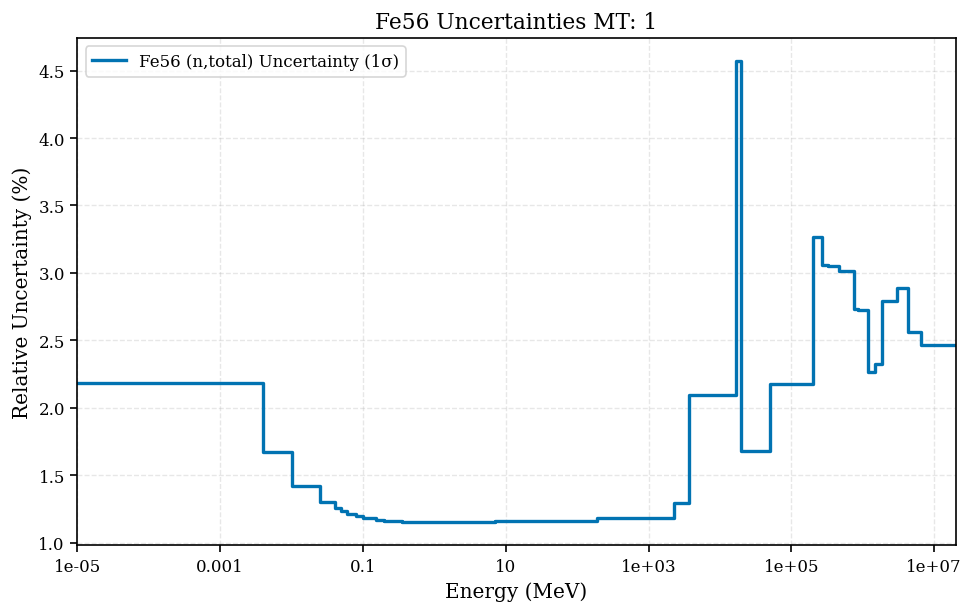

In [40]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    sigma=1.0,
    style='light',
    xscale='log',
    yscale='linear',
)
print(f"✓ Test 3.1 passed: Single nuclide/MT uncertainty, 1-sigma")

## Test 3.2: Single Nuclide/MT - 2-Sigma

✓ Test 3.2 passed: 2-sigma uncertainty


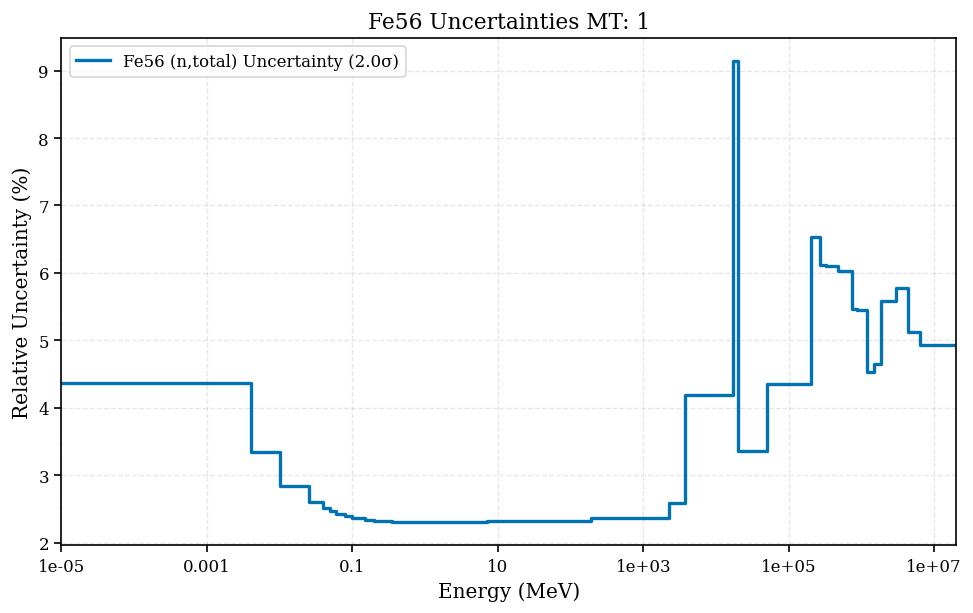

In [41]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    sigma=2.0,  # 2-sigma uncertainty
)
print(f"✓ Test 3.2 passed: 2-sigma uncertainty")

## Test 3.3: Multiple MTs on Same Plot

✓ Test 3.3 passed: Multiple MTs [1, 2, 4] on same plot


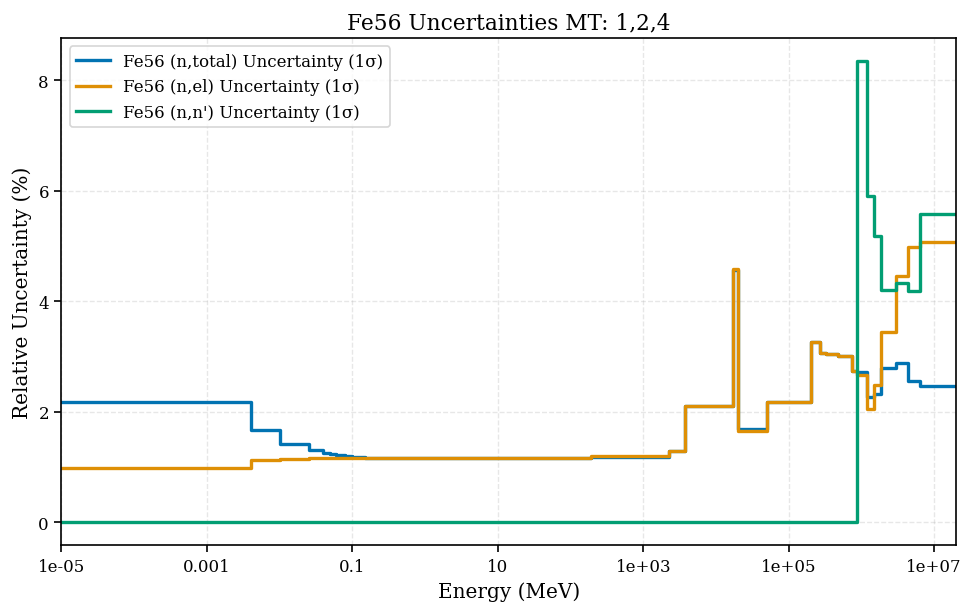

In [42]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],  # Multiple MTs
)
print(f"✓ Test 3.3 passed: Multiple MTs {test_mts[:3]} on same plot")

## Test 3.4: Linear X-Scale

✓ Test 3.4 passed: Linear x-scale


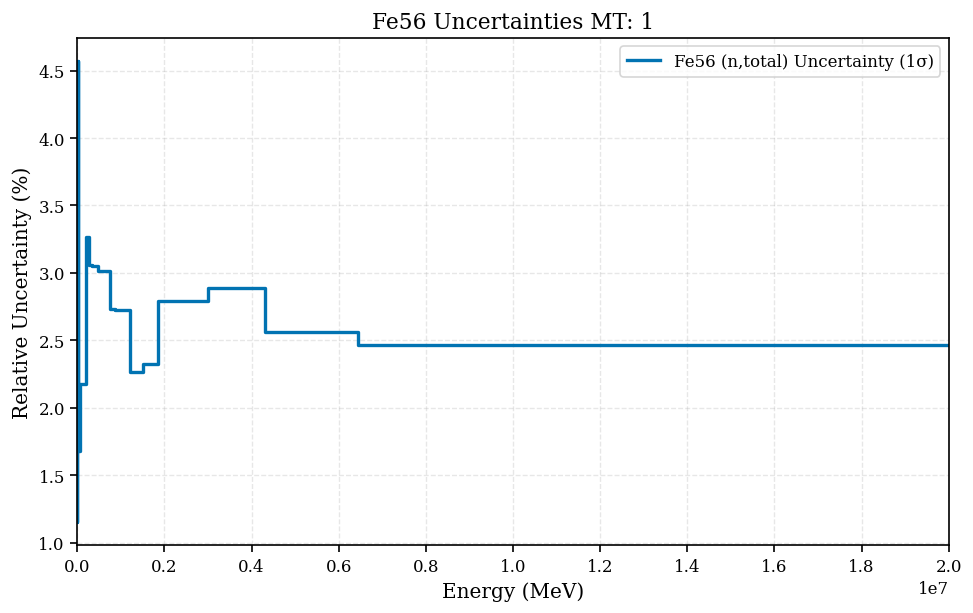

In [43]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    xscale='linear',  # Linear energy scale
)
print(f"✓ Test 3.4 passed: Linear x-scale")

## Test 3.5: Log Y-Scale

✓ Test 3.5 passed: Log y-scale


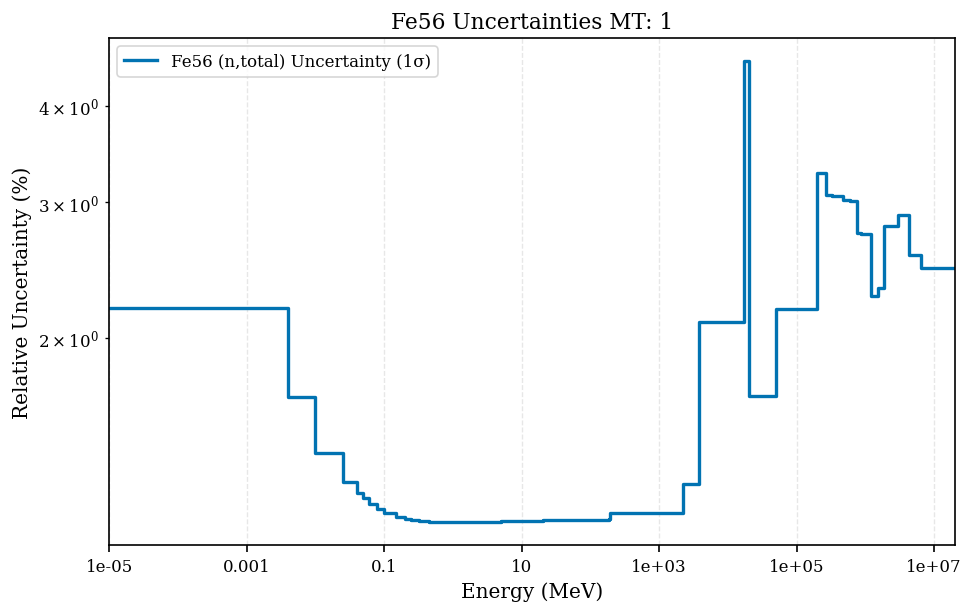

In [44]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    yscale='log',  # Log uncertainty scale
)
print(f"✓ Test 3.5 passed: Log y-scale")

## Test 3.6: Energy Range Filtering

✓ Test 3.6 passed: Energy range filtering (0.01-10 MeV)


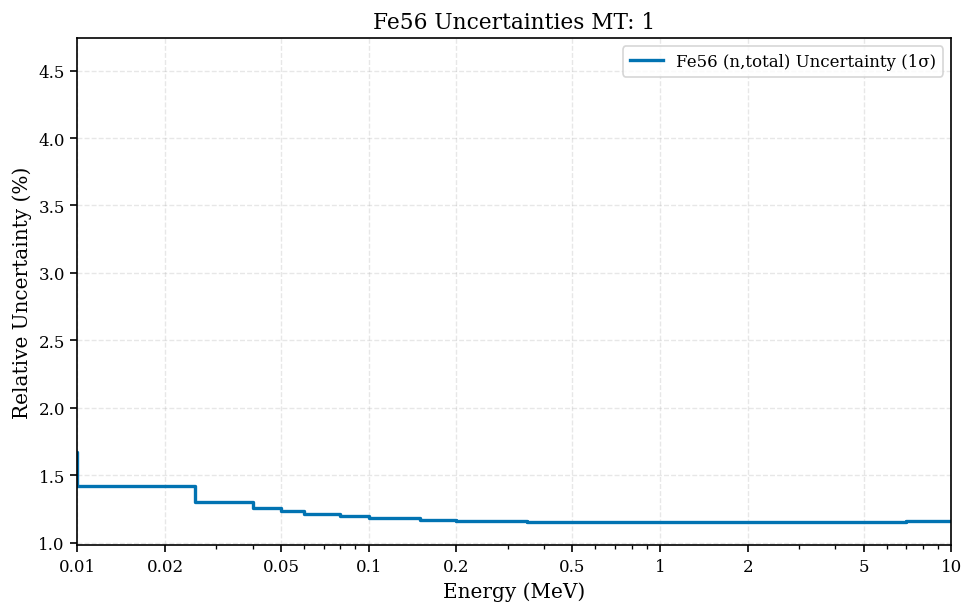

In [45]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    energy_range=(0.01, 10),  # 0.01 - 10 MeV
)
print(f"✓ Test 3.6 passed: Energy range filtering (0.01-10 MeV)")

## Test 3.7: Dark Style

✓ Test 3.7 passed: Dark style


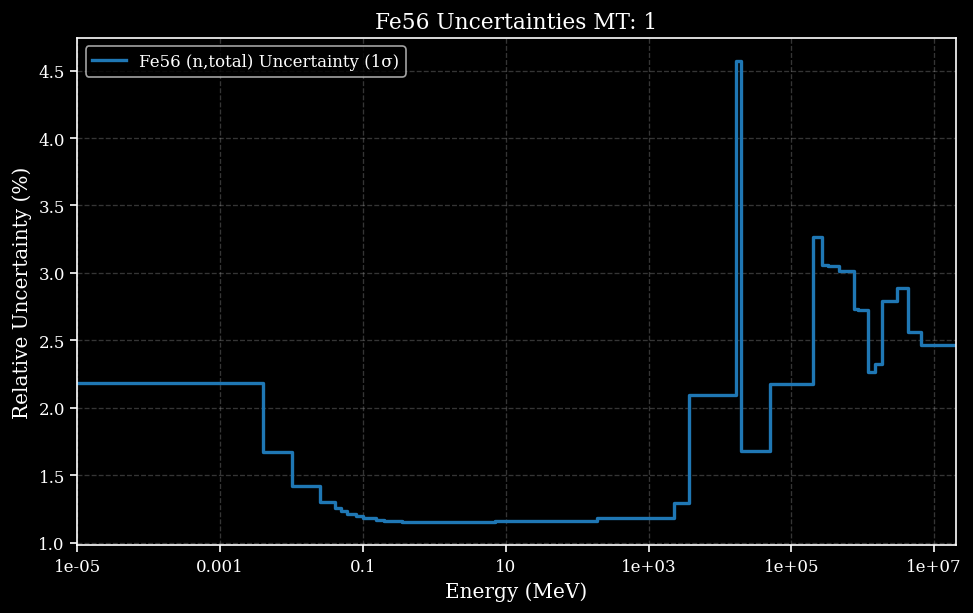

In [46]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    style='dark',
)
print(f"✓ Test 3.7 passed: Dark style")

## Test 3.8: Custom Title

✓ Test 3.8 passed: Custom title


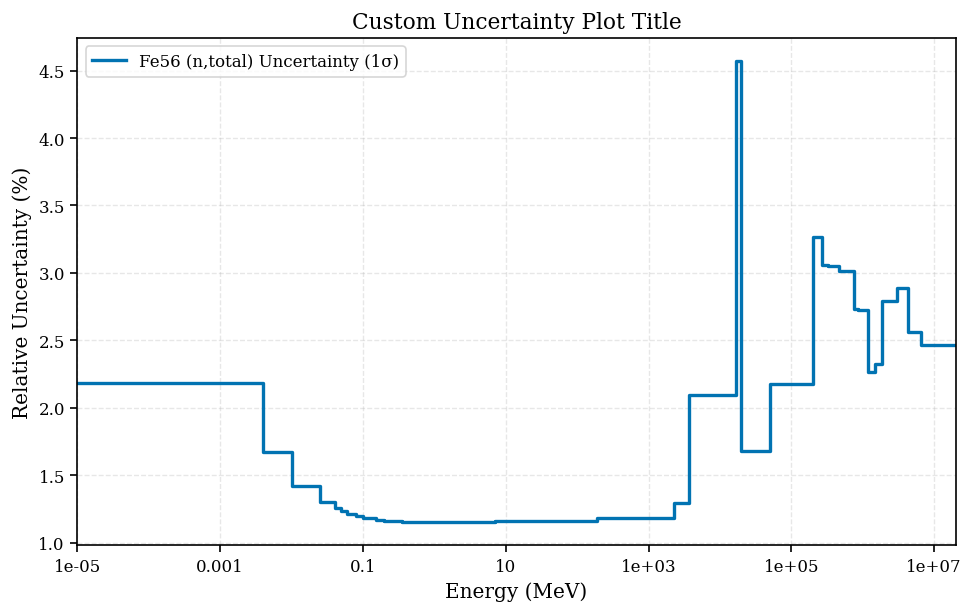

In [47]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title="Custom Uncertainty Plot Title",
)
print(f"✓ Test 3.8 passed: Custom title")

## Test 3.9: No Title

✓ Test 3.9 passed: No title


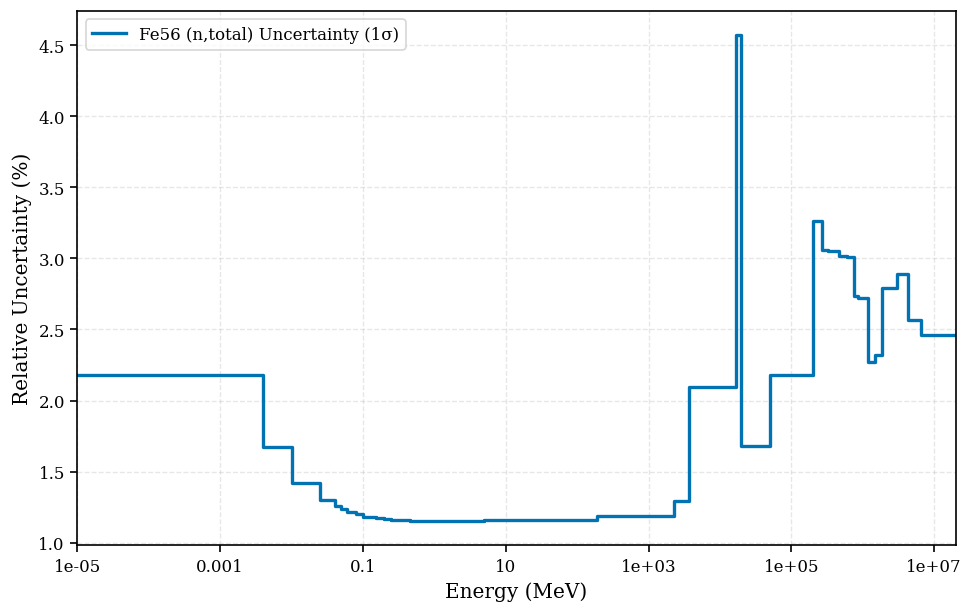

In [48]:
fig = plot_uncertainties(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title=None,
)
print(f"✓ Test 3.9 passed: No title")

## Test 3.10: Using Nuclide String

✓ Test 3.10 passed: Using nuclide string 'Fe56'


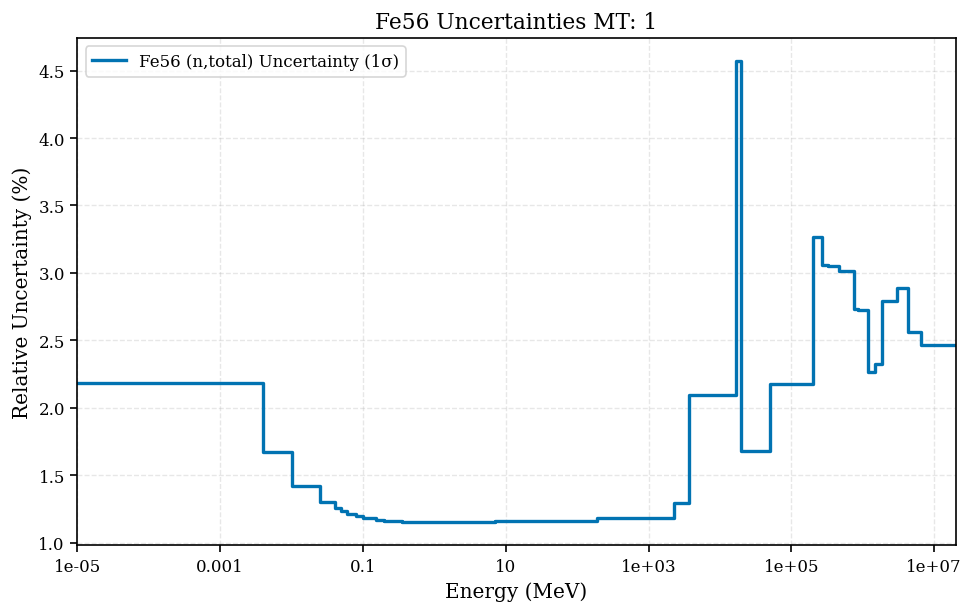

In [49]:
fig = plot_uncertainties(
    covmat,
    nuclide='Fe56',
    mt=test_mts[0],
)
print(f"✓ Test 3.10 passed: Using nuclide string 'Fe56'")

---
# Part 4: `plot_multigroup_xs()` Tests

Testing cross section plotting with optional uncertainty bands.

## Test 4.1: Single XS Without Uncertainties

✓ Test 4.1 passed: Single XS without uncertainties


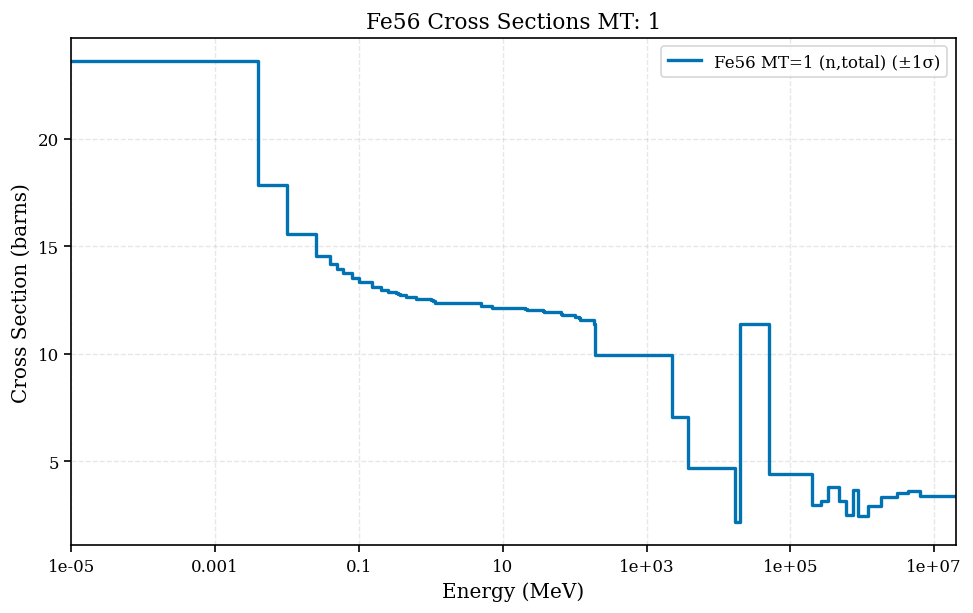

In [50]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    show_uncertainties=False,
    style='light',
)
print(f"✓ Test 4.1 passed: Single XS without uncertainties")

## Test 4.2: Single XS With 1-Sigma Uncertainty Bands

✓ Test 4.2 passed: Single XS with 1-sigma uncertainty bands


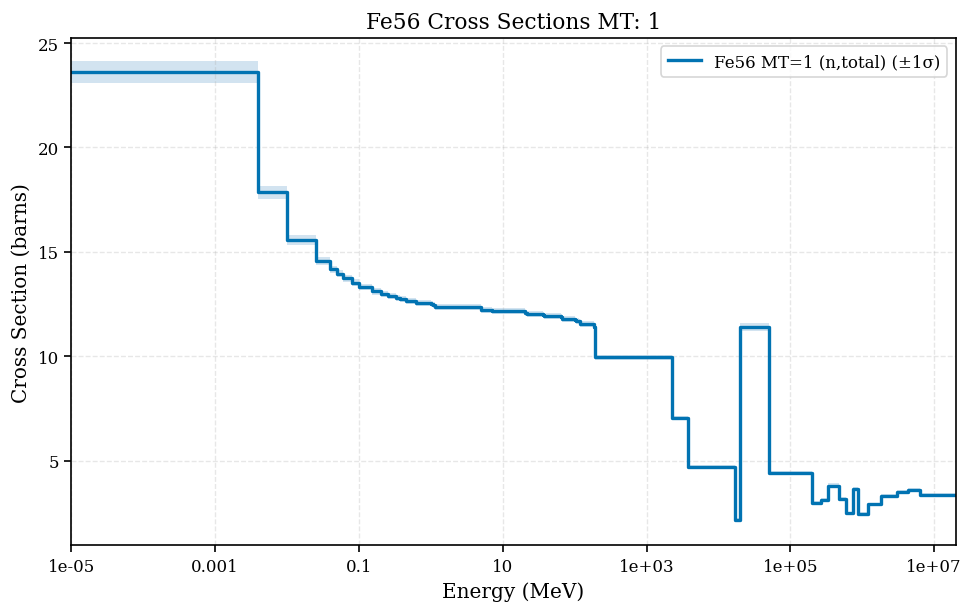

In [51]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    show_uncertainties=True,  # Show uncertainty bands
    sigma=1.0,
)
print(f"✓ Test 4.2 passed: Single XS with 1-sigma uncertainty bands")

## Test 4.3: Single XS With 2-Sigma Uncertainty Bands

✓ Test 4.3 passed: Single XS with 2-sigma uncertainty bands


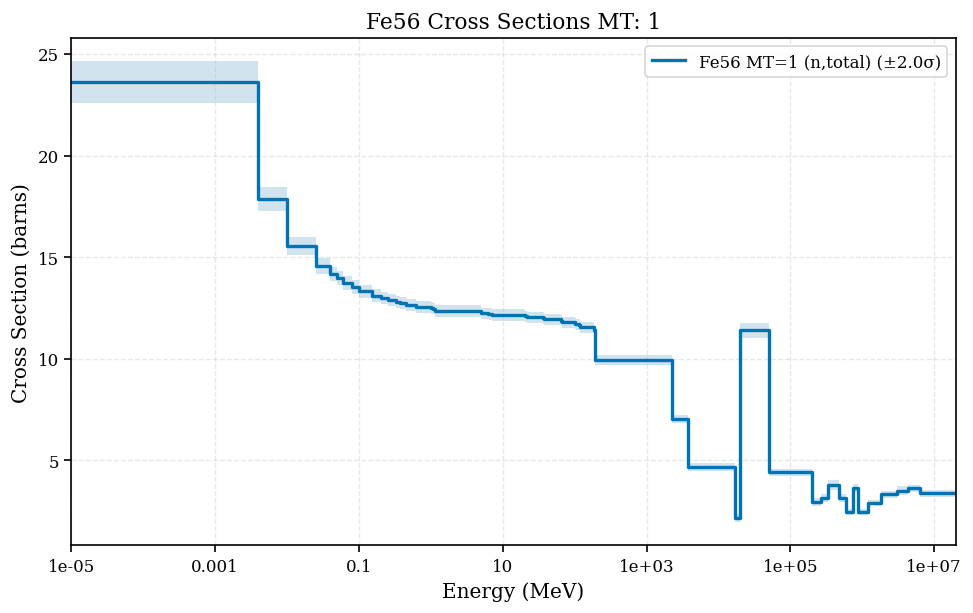

In [52]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    show_uncertainties=True,
    sigma=2.0,  # 2-sigma bands
)
print(f"✓ Test 4.3 passed: Single XS with 2-sigma uncertainty bands")

## Test 4.4: Multiple XS on Same Plot

✓ Test 4.4 passed: Multiple XS [1, 2, 4] on same plot


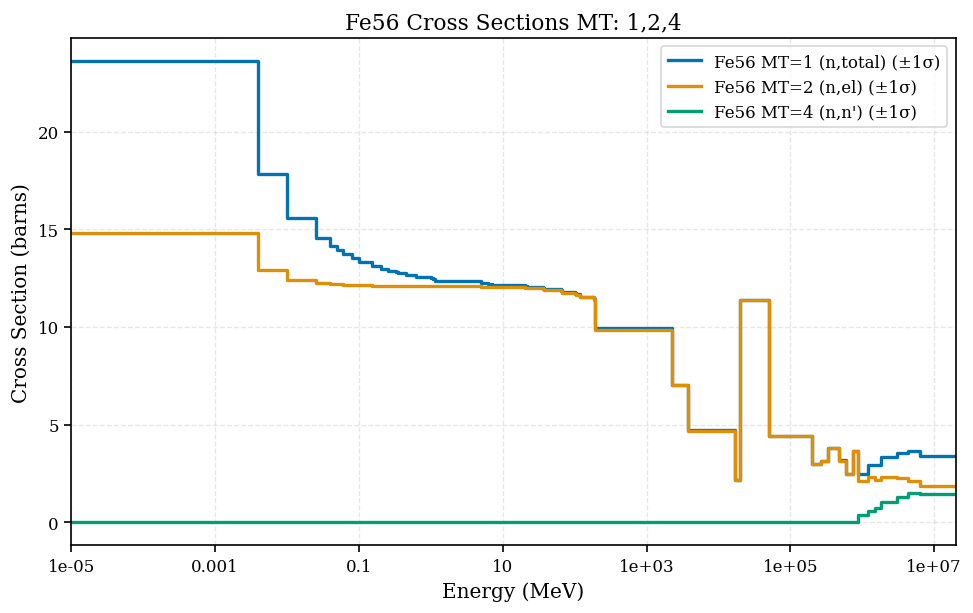

In [53]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],  # Multiple MTs
    show_uncertainties=False,
)
print(f"✓ Test 4.4 passed: Multiple XS {test_mts[:3]} on same plot")

## Test 4.5: Multiple XS With Uncertainty Bands

✓ Test 4.5 passed: Multiple XS with uncertainty bands


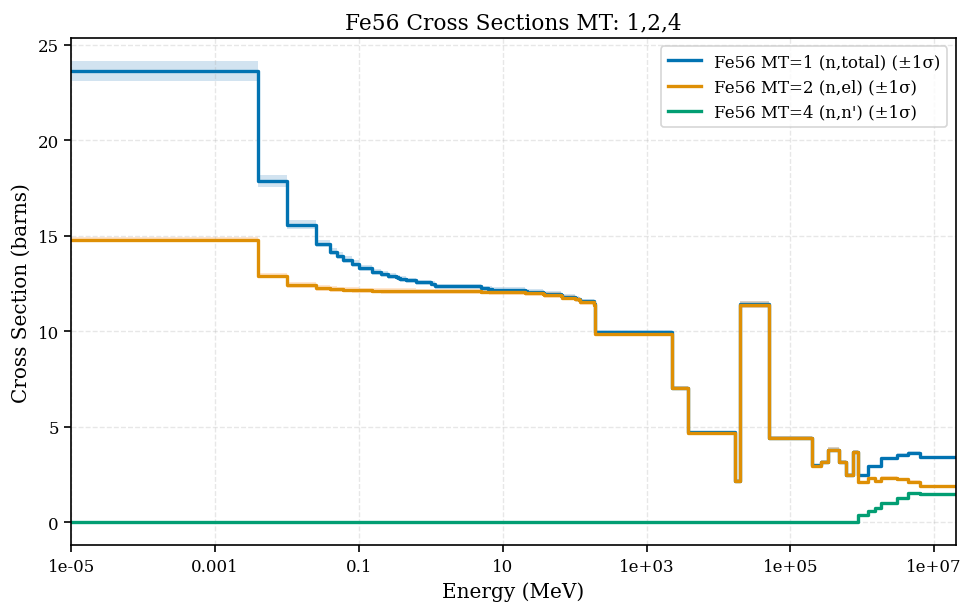

In [54]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[:3],
    show_uncertainties=True,  # Show bands for all
)
print(f"✓ Test 4.5 passed: Multiple XS with uncertainty bands")

## Test 4.6: Linear X-Scale

✓ Test 4.6 passed: Linear x-scale


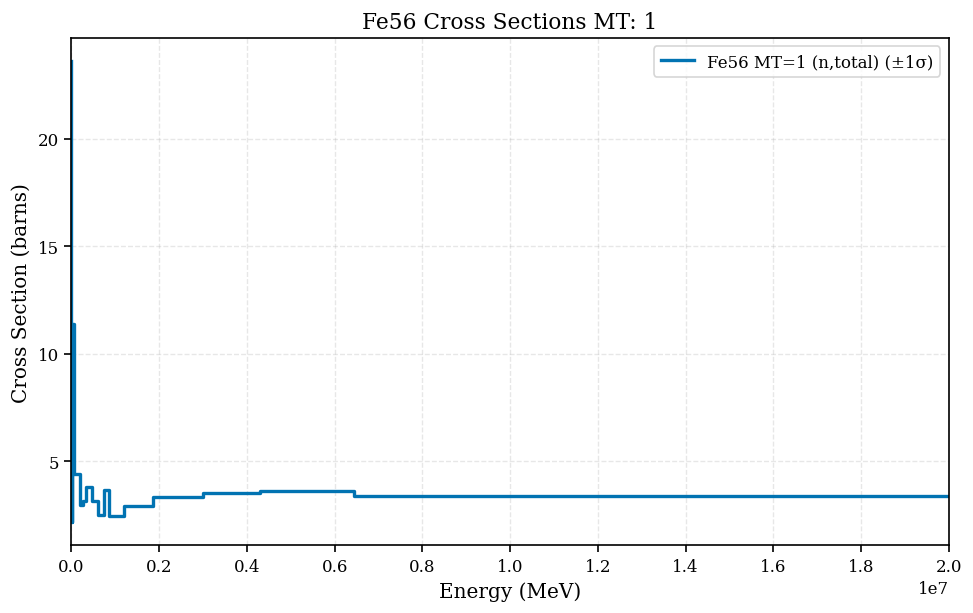

In [55]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    xscale='linear',
)
print(f"✓ Test 4.6 passed: Linear x-scale")

## Test 4.7: Log Y-Scale

✓ Test 4.7 passed: Log y-scale


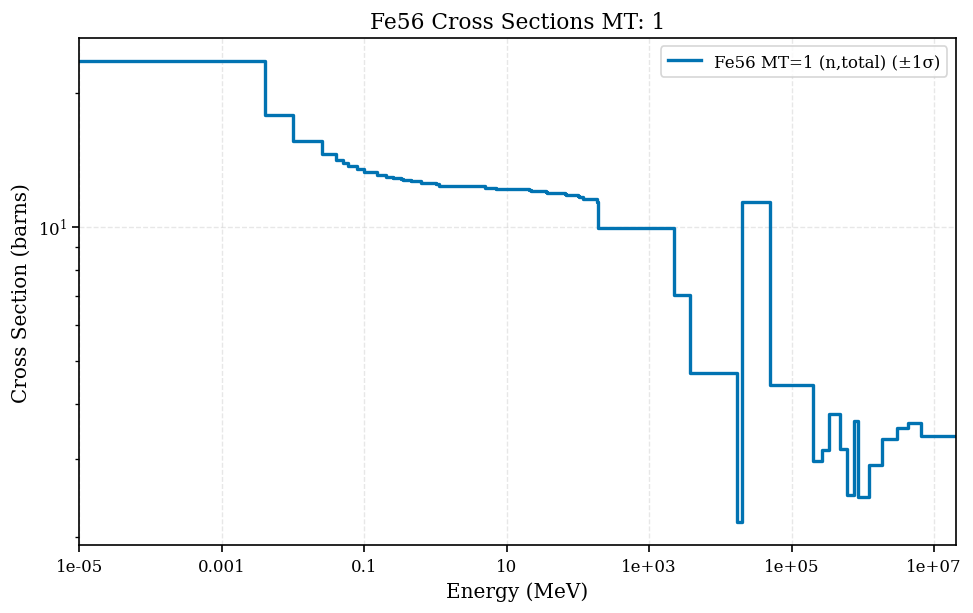

In [56]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    yscale='log',  # Log XS scale
)
print(f"✓ Test 4.7 passed: Log y-scale")

## Test 4.8: Energy Range Filtering

✓ Test 4.8 passed: Energy range filtering (0.1-5 MeV)


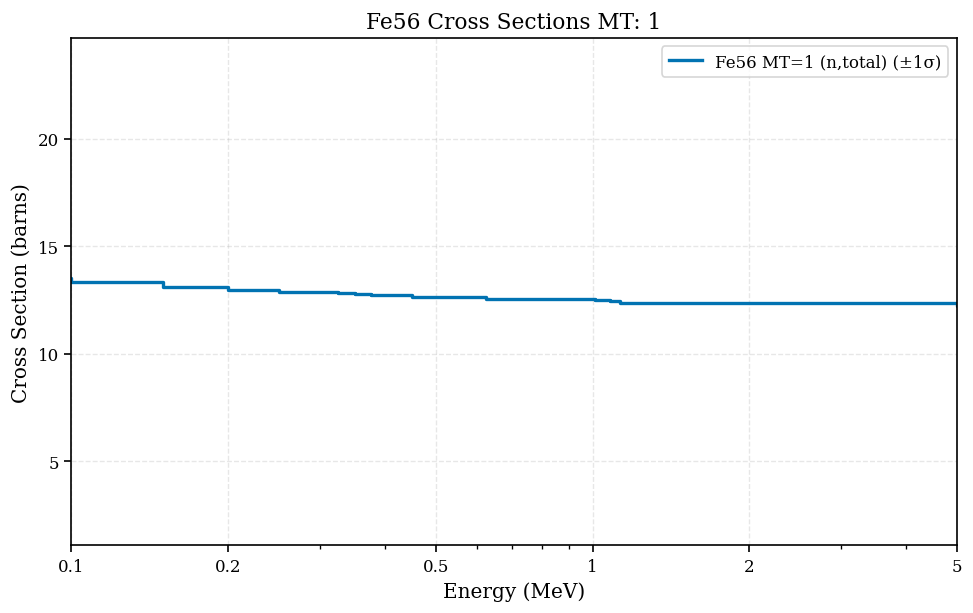

In [57]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    energy_range=(0.1, 5),  # 0.1 - 5 MeV
)
print(f"✓ Test 4.8 passed: Energy range filtering (0.1-5 MeV)")

## Test 4.9: Dark Style

✓ Test 4.9 passed: Dark style


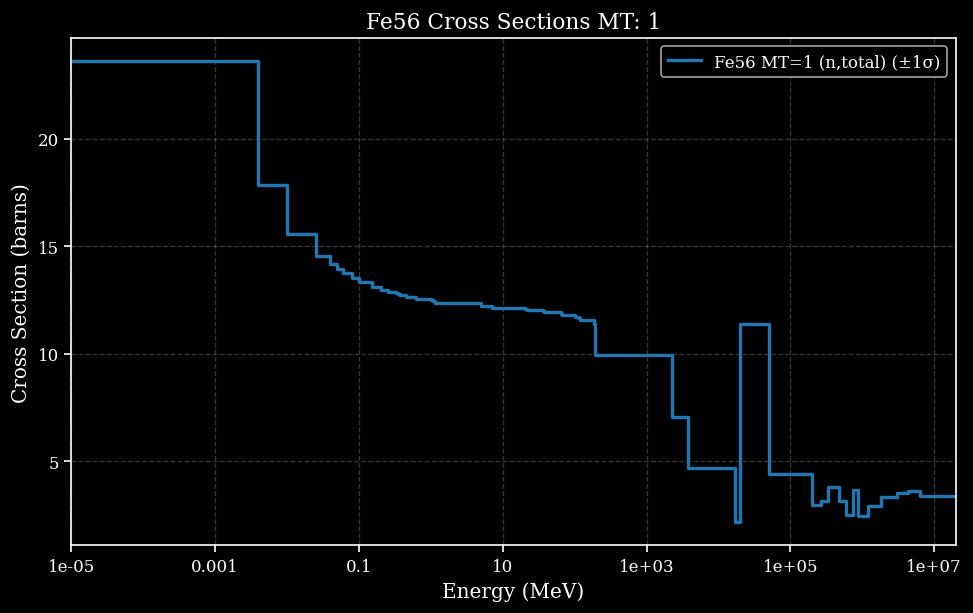

In [58]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    style='dark',
)
print(f"✓ Test 4.9 passed: Dark style")

## Test 4.10: Custom Title

✓ Test 4.10 passed: Custom title


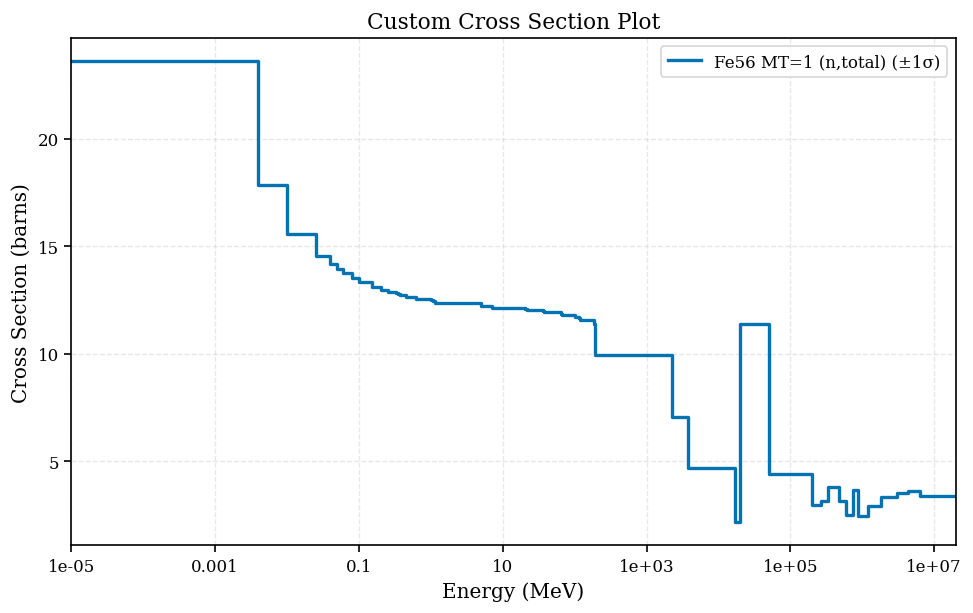

In [59]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title="Custom Cross Section Plot",
)
print(f"✓ Test 4.10 passed: Custom title")

## Test 4.11: No Title

✓ Test 4.11 passed: No title


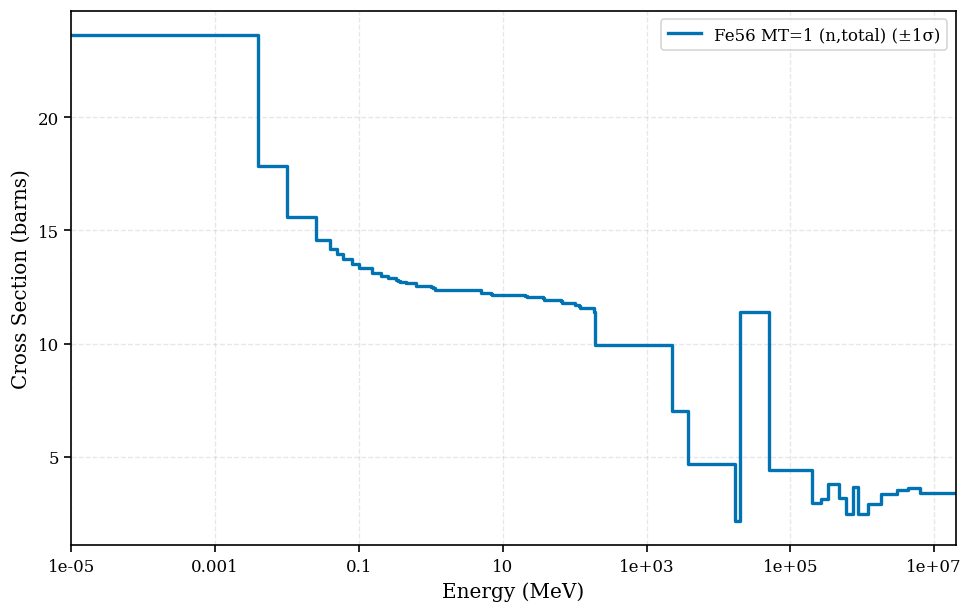

In [60]:
fig = plot_multigroup_xs(
    covmat,
    nuclide=test_zaid,
    mt=test_mts[0],
    title=None,
)
print(f"✓ Test 4.11 passed: No title")

## Test 4.12: Using Nuclide String

✓ Test 4.12 passed: Using nuclide string 'Fe56'


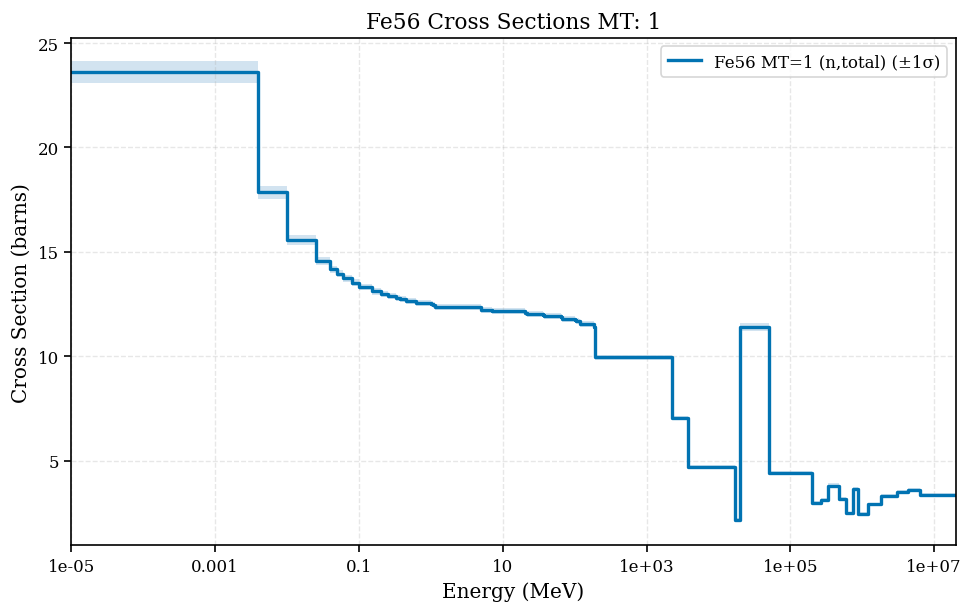

In [61]:
fig = plot_multigroup_xs(
    covmat,
    nuclide='Fe56',
    mt=test_mts[0],
    show_uncertainties=True,
)
print(f"✓ Test 4.12 passed: Using nuclide string 'Fe56'")

---
# Part 5: Edge Cases and Error Handling

## Test 5.1: Invalid Matrix Type (Should Raise Error)

In [62]:
try:
    fig = plot_covariance_heatmap(
        covmat,
        nuclide=test_zaid,
        mt=test_mts[0],
        matrix_type="invalid",  # Invalid type
    )
    print("✗ Test 5.1 FAILED: Should have raised ValueError")
except ValueError as e:
    print(f"✓ Test 5.1 passed: Correctly raised ValueError: {e}")

✓ Test 5.1 passed: Correctly raised ValueError: matrix_type must be 'corr'/'correlation' or 'cov'/'covariance', got 'invalid'


## Test 5.2: Invalid Scale (Should Raise Error)

In [63]:
try:
    fig = plot_covariance_heatmap(
        covmat,
        nuclide=test_zaid,
        mt=test_mts[0],
        scale="invalid_scale",  # Invalid scale
    )
    print("✗ Test 5.2 FAILED: Should have raised ValueError")
except ValueError as e:
    print(f"✓ Test 5.2 passed: Correctly raised ValueError: {e}")

✓ Test 5.2 passed: Correctly raised ValueError: scale must be 'log'/'logarithmic' or 'lin'/'linear', got 'invalid_scale'


## Test 5.3: Non-Existent MT (Should Handle Gracefully)

In [64]:
try:
    fig = plot_covariance_heatmap(
        covmat,
        nuclide=test_zaid,
        mt=9999,  # Non-existent MT
    )
    print("✗ Test 5.3 FAILED: Should have raised an error")
except (ValueError, KeyError) as e:
    print(f"✓ Test 5.3 passed: Correctly raised error: {e}")

✓ Test 5.3 passed: Correctly raised error: MT 9999 not found for isotope 26056


## Test 5.4: Invalid X-Scale for plot_uncertainties

✓ Test 5.4 passed: Correctly raised ValueError: Invalid xscale 'bad_scale'; expected 'log' or 'linear'


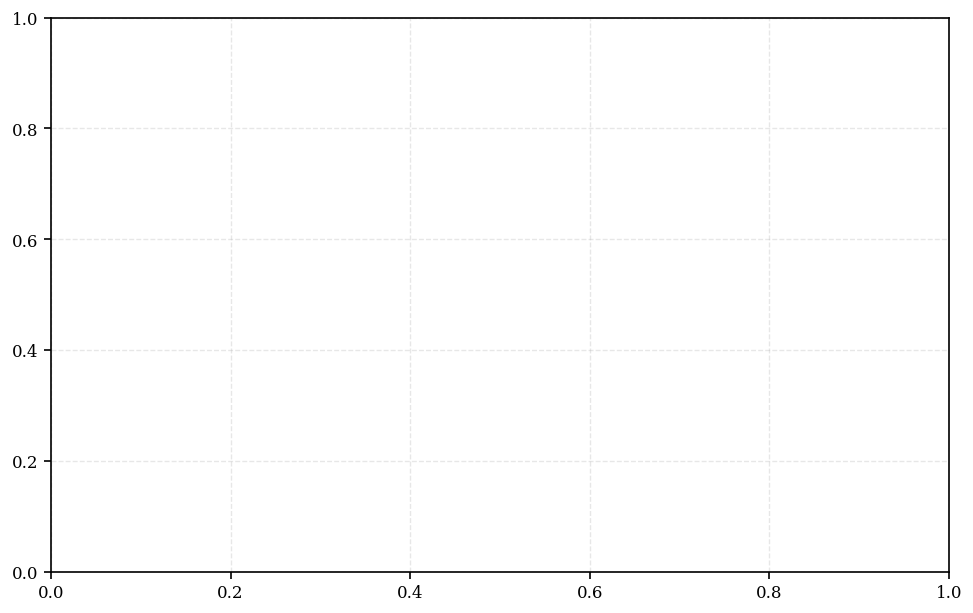

In [65]:
try:
    fig = plot_uncertainties(
        covmat,
        nuclide=test_zaid,
        mt=test_mts[0],
        xscale="bad_scale",
    )
    print("✗ Test 5.4 FAILED: Should have raised ValueError")
except ValueError as e:
    print(f"✓ Test 5.4 passed: Correctly raised ValueError: {e}")

---
# Summary

All tests completed! This notebook has systematically tested:

1. **`plot_covariance_heatmap()`**: 20 tests covering single/multiple MTs, diagonal/off-diagonal blocks, correlation/covariance matrices, log/linear scales, energy filtering, title options, display flags, font sizes, and colormap customization.

2. **`plot_mf34_covariance_heatmap()`**: 16 tests covering single/multiple Legendre coefficients, diagonal/off-diagonal blocks, all matrix types and scales, energy filtering, and customization options.

3. **`plot_uncertainties()`**: 10 tests covering single/multiple nuclides and MTs, sigma scaling, axis scales, energy filtering, styles, and title options.

4. **`plot_multigroup_xs()`**: 12 tests covering cross sections with/without uncertainty bands, sigma scaling, multiple reactions, axis scales, and styling.

5. **Error Handling**: 4 tests verifying proper error messages for invalid inputs.

**Total: 62 comprehensive tests**